# 28 — Metric and Region-Policy Ablation

**Origin:** New Notebook; includes alternatives prepared by Previous Notebook 26\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/28_metric_and_region_policy_ablation/`\
**Depends on:** Notebook 08 and Notebooks 13–27

## Purpose

Test whether the evaluation framework's model comparisons, case-priority ranks, operational flags, metric-disagreement findings, and main conclusions remain stable when reasonable evaluation-policy choices change.

The notebook performs four controlled sensitivity analyses:

- metric-family ablation;
- evaluation-region-policy ablation;
- operational threshold sensitivity;
- flag-aggregation-rule sensitivity.

It reuses validated upstream evidence. It does not run restoration inference, feature-model inference, or image-metric computation.

## Approved evidence populations

### Core ranking population

- 410 matched restoration cases;
- 1,230 primary candidates;
- OpenCV Telea, LaMa, and primary Stable Diffusion candidates;
- the same case population for every eligible cross-model ranking scenario.

### Flag-stability population

- 1,785 candidates from the complete Notebook 27 union;
- 11 independent trustworthiness flags;
- 14 transparent failure categories;
- 10 bounded SDXL candidates retained only in separate flag-policy diagnostics.

### Region-policy evidence

Notebook 08 defines 143 metric-region policy rows and seven ablation policies:

- full image only;
- content region only;
- masked pixels where valid;
- mask-bounding-box crop only;
- boundary regions;
- outside-mask regions;
- complete approved region policy.

## Approved ablations

The notebook evaluates exactly 23 scenarios:

- one complete-framework baseline;
- eleven alternative metric-family configurations;
- six alternative region policies;
- two alternative threshold policies;
- three alternative aggregation rules.

Metric-family scenarios include:

- without classical metrics;
- without LPIPS;
- without CLIP;
- without DINOv2-derived evidence;
- without texture;
- without colour;
- without seam evidence;
- without uncertainty;
- classical metrics only;
- perceptual metrics only;
- semantic and feature evidence only.

## Ranking policy

Model and case ranks remain transparent ordinal sensitivity diagnostics.

- one equal contribution is retained per evidence family;
- runtime does not enter quality ranking;
- uncertainty does not enter the cross-model rank because Telea and LaMa are deterministic;
- removing uncertainty may change stochastic candidate flags but must not change the three-model quality rank;
- no continuous combined quality, case-trust, or universal trust score is retained.

## Flag-stability policy

Flag stability is stored as one compact candidate-by-scenario row rather than an unnecessary candidate-by-scenario-by-flag grid.

Every row records:

- baseline and scenario triggered-flag counts;
- baseline and scenario critical counts;
- changed flag identifiers;
- newly triggered and no-longer-triggered flags;
- new and resolved insufficient-evidence states;
- flag-state agreement;
- triggered-set Jaccard agreement;
- maximum severity transition;
- the principal reason for the change.

Missing evidence never counts as improvement or passing evidence.

## Interpretation limits

- Rank changes show evaluation-policy sensitivity, not universal model superiority.
- Operational thresholds identify relative outliers, not calibrated failure probabilities.
- CLIP and DINOv2 remain diagnostic pretrained-feature proxies.
- Repeated-seed variation is empirical generative uncertainty, not calibrated confidence.
- Five-painting extension experiments provide controlled descriptive evidence, not broad style effects.
- SDXL remains a bounded ten-case diagnostic subset.
- Computational flags are not human, historical, museum, or conservation ground truth.
- No result establishes historical authenticity, physical conservation suitability, or museum approval.

## Thesis-question alignment

- **RQ1:** test whether complementary evidence families contribute information beyond traditional similarity metrics;
- **RQ2:** determine whether comparative model conclusions survive reasonable metric and region-policy changes;
- **RQ3 scope extension:** test how removing supported uncertainty evidence changes candidate-level screening without assigning artificial uncertainty to deterministic models;
- **Practical output:** identify which findings are stable enough to support review and which remain evaluation-policy dependent.

## Canonical outputs

- `metrics/ablation_results.csv`
- `metrics/flag_stability.csv`
- `figures/ablation_ranking_changes.png`
- `figures/ablation_flag_changes.png`
- `reports/ablation_study.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

The HTML report is self-contained and must retain the approved twelve-section mock structure, two canonical figures, at least five analytical views, six diagnostic panels, and eighteen embedded diagnostic tiles.

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads the approved Notebook 28 configuration;
- declares the exact input and output contracts;
- creates only Notebook 28-owned output directories;
- checks the refreshed global inventory;
- verifies the roadmap, implementation guidelines, evidence audit, and machine-readable evidence contract;
- validates completion manifests for Notebook 08 and Notebooks 13–27;
- builds and validates the exact 23-scenario catalogue;
- validates all seven Notebook 08 region-ablation memberships;
- confirms the Notebook 26 quality-anchor and Notebook 27 indicator mappings;
- locks the 410-case ranking population and 1,785-candidate flag population;
- prohibits universal scores, missing-evidence improvements, artificial deterministic uncertainty, and full-dataset SDXL claims;
- locks the approved self-contained twelve-section report structure.

This batch does not load the large metric tables, recompute flags, calculate ranks, generate figures, write canonical tables, or build the final report.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.failure_taxonomy import (
    load_failure_taxonomy_config,
)
from restoration_eval.grouped_statistical_analysis import (
    load_grouped_statistical_analysis_config,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.metric_region_ablation import (
    ABLATION_RESULT_COLUMNS,
    ABLATION_RESULTS_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    FLAG_STABILITY_COLUMNS,
    FLAG_STABILITY_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    SCENARIO_COLUMNS,
    SCENARIO_SCHEMA_VERSION,
    atomic_write_csv,
    build_flag_stability,
    build_region_membership_table,
    build_scenario_catalog,
    coerce_ablation_results,
    load_metric_region_ablation_config,
    resolve_metric_region_ablation_inputs,
    scenario_failure_config,
    validate_ablation_report_html,
    validate_ablation_results,
    validate_flag_stability,
    validate_scenario_catalog,
    validate_upstream_completion,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one validation stage so its cell can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


print("Notebook 28 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 28 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.metric_region_ablation 1.0.0


In [2]:
BATCH_1_STAGE = "batch_1_preflight"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "metric_region_ablation.yaml"
)

ANALYSIS_CONFIG = load_metric_region_ablation_config(
    CONFIG_PATH
)
SETTINGS = ANALYSIS_CONFIG[
    "metric_region_ablation"
]

INPUT_PATHS = resolve_metric_region_ablation_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

OUTPUT_PATHS = {
    "ablation_results": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["ablation_results_path"]
    ),
    "flag_stability": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["flag_stability_path"]
    ),
    "ablation_ranking_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["ranking_figure_path"]
    ),
    "ablation_flag_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["flag_figure_path"]
    ),
    "ablation_report": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["report_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

CANONICAL_OUTPUT_PATHS = tuple(
    OUTPUT_PATHS.values()
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_OUTPUT_PATHS:
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

paths_inside_output_root = all(
    output_path.resolve().is_relative_to(
        OUTPUT_ROOT
    )
    for output_path in CANONICAL_OUTPUT_PATHS
)

configured_schema_versions = {
    "configuration": ANALYSIS_CONFIG[
        "config_schema_version"
    ],
    "scenarios": SETTINGS[
        "scenario_schema_version"
    ],
    "ablation_results": SETTINGS[
        "ablation_results_schema_version"
    ],
    "flag_stability": SETTINGS[
        "flag_stability_schema_version"
    ],
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "scenarios": SCENARIO_SCHEMA_VERSION,
    "ablation_results": (
        ABLATION_RESULTS_SCHEMA_VERSION
    ),
    "flag_stability": (
        FLAG_STABILITY_SCHEMA_VERSION
    ),
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description=(
        "Python uses an approved major and minor version."
    ),
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical schemas match "
        "the Notebook 28 helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 28 input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every output belongs to the exact "
        "Notebook 28 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_output_count",
    description=(
        "The output contract declares exactly "
        "eight canonical files."
    ),
    expected=8,
    observed=len(CANONICAL_OUTPUT_PATHS),
    passed=(
        len(CANONICAL_OUTPUT_PATHS)
        == SETTINGS["expected_counts"][
            "canonical_output_files"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 28 starts without pre-existing "
        "output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": (
                path.relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "exists_before_analysis": (
                path in preexisting_output_files
            ),
        }
        for artifact, path
        in OUTPUT_PATHS.items()
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(f"Canonical outputs: {len(OUTPUT_PATHS):,}")
print(f"Output root: {OUTPUT_ROOT}")

,artifact,relative_path,exists_before_analysis
0,ablation_results,outputs/28_metric_and_region_policy_ablation/metrics/ablation_results.csv,False
1,flag_stability,outputs/28_metric_and_region_policy_ablation/metrics/flag_stability.csv,False
2,ablation_ranking_figure,outputs/28_metric_and_region_policy_ablation/figures/ablation_ranking_changes.png,False
3,ablation_flag_figure,outputs/28_metric_and_region_policy_ablation/figures/ablation_flag_changes.png,False
4,ablation_report,outputs/28_metric_and_region_policy_ablation/reports/ablation_study.html,False
5,run_manifest,outputs/28_metric_and_region_policy_ablation/manifests/run_manifest.json,False
6,artifacts,outputs/28_metric_and_region_policy_ablation/manifests/artifacts.csv,False
7,validation,outputs/28_metric_and_region_policy_ablation/validation/checks.csv,False


Configuration and output contract validated.
Declared inputs: 55
Canonical outputs: 8
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\28_metric_and_region_policy_ablation


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(
        handle
    )

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(
        handle
    )

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_audit_path"
].read_text(encoding="utf-8-sig")

ROADMAP_TEXT = INPUT_PATHS[
    "roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    (
        "config/evaluation/"
        "metric_region_ablation.yaml"
    ),
    (
        "src/restoration_eval/"
        "metric_region_ablation.py"
    ),
    "tests/test_metric_region_ablation.py",
    (
        "notebooks/"
        "28_metric_and_region_policy_ablation.ipynb"
    ),
    "docs/final_notebook_roadmap.md",
    "docs/evidence_dependency_audit.md",
    (
        "docs/refactoring_"
        "implementation_guidelines.md"
    ),
    (
        "config/evaluation/"
        "evidence_coverage.yaml"
    ),
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N28_COVERAGE = planned_notebooks.get(
    "28",
    {},
)

inventory_status_ok = (
    INVENTORY_RUN.get("status")
    == "completed"
    and int(
        INVENTORY_RUN.get(
            "summary",
            {},
        ).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

legacy_notebook_path = (
    PROJECT_ROOT
    / "notebooks"
    / "28_final_controlled_50_"
    "evaluation_report_cleaned.ipynb"
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed "
        "without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get(
            "status"
        ),
        "read_error_count": (
            INVENTORY_RUN.get(
                "summary",
                {},
            ).get(
                "read_error_count"
            )
        ),
    },
    passed=inventory_status_ok,
)

missing_preparation_paths = sorted(
    required_preparation_paths
    - inventory_relative_paths
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains the "
        "Notebook 28 preparation layer."
    ),
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=not missing_preparation_paths,
    details={
        "missing": missing_preparation_paths,
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="legacy_notebook_removed",
    description=(
        "The obsolete pre-roadmap Notebook 28 "
        "file is absent."
    ),
    expected=False,
    observed=legacy_notebook_path.exists(),
    passed=not legacy_notebook_path.exists(),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="governing_documents_reference_n28",
    description=(
        "The roadmap, evidence audit, and "
        "machine-readable coverage contract "
        "contain the current Notebook 28 scope."
    ),
    expected=True,
    observed={
        "roadmap_heading": (
            "## 28 — Metric and Region-Policy Ablation"
            in ROADMAP_TEXT
        ),
        "audit_mapping": (
            "28 Metric/region ablation"
            in EVIDENCE_AUDIT_TEXT
        ),
        "coverage_stem": N28_COVERAGE.get(
            "stem"
        ),
        "coverage_status": N28_COVERAGE.get(
            "status"
        ),
    },
    passed=(
        "## 28 — Metric and Region-Policy Ablation"
        in ROADMAP_TEXT
        and "28 Metric/region ablation"
        in EVIDENCE_AUDIT_TEXT
        and N28_COVERAGE.get("stem")
        == "28_metric_and_region_policy_ablation"
        and N28_COVERAGE.get("status")
        == "planned_supported"
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="manual_notebook_editing_policy_present",
    description=(
        "The governing guidelines retain the "
        "manual notebook-editing rule."
    ),
    expected=True,
    observed=(
        "The assistant must not create, replace, "
        "patch, or otherwise edit an `.ipynb`"
        in IMPLEMENTATION_GUIDELINES_TEXT
    ),
    passed=(
        "The assistant must not create, replace, "
        "patch, or otherwise edit an `.ipynb`"
        in IMPLEMENTATION_GUIDELINES_TEXT
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="approved_mock_fidelity_policy_present",
    description=(
        "The report mock-to-final fidelity "
        "contract remains present."
    ),
    expected=True,
    observed=(
        "Approved mock-to-final fidelity contract"
        in IMPLEMENTATION_GUIDELINES_TEXT
    ),
    passed=(
        "Approved mock-to-final fidelity contract"
        in IMPLEMENTATION_GUIDELINES_TEXT
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="project_paths_registry_readable",
    description=(
        "The normalized project-path registry "
        "is a readable mapping."
    ),
    expected=True,
    observed={
        "type": type(
            PROJECT_PATHS_REGISTRY
        ).__name__,
        "artifact_records": len(
            PROJECT_PATHS_REGISTRY.get(
                "artifacts",
                [],
            )
        ),
    },
    passed=isinstance(
        PROJECT_PATHS_REGISTRY,
        dict,
    ),
)

governing_contract_summary = pd.DataFrame(
    [
        {
            "source": "inventory",
            "status": INVENTORY_RUN.get("status"),
            "detail": (
                f"{INVENTORY_RUN.get('summary', {}).get('file_count', 0):,} files"
            ),
        },
        {
            "source": "evidence coverage",
            "status": N28_COVERAGE.get("status"),
            "detail": N28_COVERAGE.get("stem"),
        },
        {
            "source": "roadmap",
            "status": "present",
            "detail": "28 — Metric and Region-Policy Ablation",
        },
        {
            "source": "implementation guidelines",
            "status": "present",
            "detail": "manual editing and approved mock fidelity",
        },
    ]
)

display(governing_contract_summary)

print("Inventory and governing-document checks complete.")
print(
    "Inventory files: "
    f"{INVENTORY_RUN.get('summary', {}).get('file_count', 0):,}"
)
print(
    "Inventory read errors: "
    f"{INVENTORY_RUN.get('summary', {}).get('read_error_count', 0):,}"
)

,source,status,detail
0,inventory,completed,"18,718 files"
1,evidence coverage,planned_supported,28_metric_and_region_policy_ablation
2,roadmap,present,28 — Metric and Region-Policy Ablation
3,implementation guidelines,present,manual editing and approved mock fidelity


Inventory and governing-document checks complete.
Inventory files: 18,718
Inventory read errors: 0


In [4]:
UPSTREAM_MANIFESTS = {
    "08": json.loads(
        INPUT_PATHS[
            "contracts_manifest_path"
        ].read_text(encoding="utf-8")
    )
}

UPSTREAM_MANIFESTS.update(
    {
        f"{number:02d}": json.loads(
            INPUT_PATHS[
                f"manifest_{number:02d}_path"
            ].read_text(encoding="utf-8")
        )
        for number in range(13, 28)
    }
)

UPSTREAM_COMPLETION = (
    validate_upstream_completion(
        UPSTREAM_MANIFESTS
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="upstream_completion_gates",
    description=(
        "Notebook 08 and Notebooks 13–27 "
        "have completed validated manifests."
    ),
    expected={
        "manifest_count": 16,
        "failed": 0,
    },
    observed={
        "manifest_count": len(
            UPSTREAM_COMPLETION
        ),
        "failed": int(
            (
                ~UPSTREAM_COMPLETION[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(UPSTREAM_COMPLETION) == 16
        and UPSTREAM_COMPLETION[
            "passed"
        ].all()
    ),
)

upstream_manifest_summary = pd.DataFrame(
    [
        {
            "notebook_id": notebook_id,
            "run_id": manifest.get("run_id"),
            "run_status": manifest.get(
                "run_status"
            ),
            "validation_status": manifest.get(
                "validation_status"
            ),
            "completion_gate_passed": (
                manifest.get(
                    "completion_gate_passed"
                )
            ),
        }
        for notebook_id, manifest
        in sorted(
            UPSTREAM_MANIFESTS.items()
        )
    ]
)

display(upstream_manifest_summary)
display(UPSTREAM_COMPLETION)

print("Upstream completion manifests validated.")
print(
    "Validated producers: "
    f"{int(UPSTREAM_COMPLETION['passed'].sum()):,}"
)
print(
    "Failed producer gates: "
    f"{int((~UPSTREAM_COMPLETION['passed']).sum()):,}"
)

,notebook_id,run_id,run_status,validation_status,completion_gate_passed
0,08,run_a3734bc2121f401b87de4894717366ab,completed,passed,True
1,13,run_5bbeb9a089d044fab465d5078aedab39,completed,passed,True
2,14,run_4ffd061c775a46f3944ad9e405613b34,completed,passed,True
3,15,run_2b08762834b1423b8a61ef159c2679dc,completed,passed,True
4,16,run_1181febbbd3d4e63bbd60bc565b2d0c9,completed,passed,True
5,17,run_a322000b2a0445c9b5b71a2e0502fdf0,completed,passed,True
6,18,run_a660cfa509e643a39708d762f18cae2b,completed,passed,True
7,19,run_bddab70b2b2c46aaa013f8c45a91fc23,completed,passed,True
8,20,run_cb24def4d3134cc3bb6d679d390b777e,completed,passed,True
9,21,run_2acbdc178f9a470f9c3a0ac4212956bb,completed,passed,True


,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed
0,08,True,completed,passed,True,True
1,13,True,completed,passed,True,True
2,14,True,completed,passed,True,True
3,15,True,completed,passed,True,True
4,16,True,completed,passed,True,True
5,17,True,completed,passed,True,True
6,18,True,completed,passed,True,True
7,19,True,completed,passed,True,True
8,20,True,completed,passed,True,True
9,21,True,completed,passed,True,True


Upstream completion manifests validated.
Validated producers: 16
Failed producer gates: 0


In [5]:
FAILURE_CONFIG = (
    load_failure_taxonomy_config(
        INPUT_PATHS[
            "failure_taxonomy_config_path"
        ]
    )
)

GROUPED_CONFIG = (
    load_grouped_statistical_analysis_config(
        INPUT_PATHS[
            "grouped_analysis_config_path"
        ]
    )
)

REGION_POLICY = pd.read_csv(
    INPUT_PATHS["region_policy_path"],
    low_memory=False,
)

REGION_MEMBERSHIPS = (
    build_region_membership_table(
        REGION_POLICY,
        config=ANALYSIS_CONFIG,
    )
)

SCENARIO_CATALOG = (
    build_scenario_catalog(
        ANALYSIS_CONFIG
    )
)

SCENARIO_CHECKS = (
    validate_scenario_catalog(
        SCENARIO_CATALOG,
        config=ANALYSIS_CONFIG,
    )
)

compatible_memberships = (
    REGION_MEMBERSHIPS.loc[
        REGION_MEMBERSHIPS[
            "compatible"
        ]
    ].copy()
)

observed_membership_counts = (
    compatible_memberships[
        "ablation_policy_id"
    ]
    .value_counts()
    .to_dict()
)

expected_membership_counts = {
    "full_image_only": 11,
    "content_region_only": 12,
    "masked_pixels_where_valid": 10,
    "mask_bbox_only": 12,
    "boundary_regions": 24,
    "outside_mask_only": 11,
    "complete_approved_policy": 86,
}

baseline_scenario = (
    SCENARIO_CATALOG.set_index(
        "scenario_id"
    ).loc[
        "complete_approved_framework"
    ]
)

baseline_anchor_ids = set(
    json.loads(
        baseline_scenario[
            "active_anchor_ids_json"
        ]
    )
)

baseline_indicator_ids = set(
    json.loads(
        baseline_scenario[
            "active_indicator_ids_json"
        ]
    )
)

n26_anchor_ids = {
    str(record["anchor_id"])
    for record
    in GROUPED_CONFIG[
        "grouped_statistical_analysis"
    ]["quality_anchors"]
}

n27_indicator_ids = {
    str(record["indicator_id"])
    for record
    in FAILURE_CONFIG[
        "failure_taxonomy"
    ]["indicators"]
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="scenario_catalog_contract",
    description=(
        "The exact ordered 23-scenario "
        "catalogue passes helper validation."
    ),
    expected={
        "rows": 23,
        "blocking_failures": 0,
    },
    observed={
        "rows": len(
            SCENARIO_CATALOG
        ),
        "blocking_failures": int(
            (
                ~SCENARIO_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(SCENARIO_CATALOG) == 23
        and SCENARIO_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="scenario_family_counts",
    description=(
        "Metric, region, threshold, and "
        "aggregation scenario counts are exact."
    ),
    expected={
        "metric": 12,
        "region": 6,
        "threshold": 2,
        "aggregation": 3,
    },
    observed=(
        SCENARIO_CATALOG[
            "scenario_family"
        ]
        .value_counts()
        .to_dict()
    ),
    passed=(
        SCENARIO_CATALOG[
            "scenario_family"
        ]
        .value_counts()
        .to_dict()
        == {
            "metric": 12,
            "region": 6,
            "aggregation": 3,
            "threshold": 2,
        }
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="ranking_scenario_count",
    description=(
        "Only metric and region scenarios "
        "participate in rank sensitivity."
    ),
    expected=18,
    observed=int(
        SCENARIO_CATALOG[
            "ranking_applicable"
        ].sum()
    ),
    passed=(
        int(
            SCENARIO_CATALOG[
                "ranking_applicable"
            ].sum()
        )
        == 18
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="region_policy_memberships",
    description=(
        "All seven Notebook 08 region-ablation "
        "policies have their exact compatible rows."
    ),
    expected=expected_membership_counts,
    observed=observed_membership_counts,
    passed=(
        observed_membership_counts
        == expected_membership_counts
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="n26_quality_anchor_mapping",
    description=(
        "The complete scenario covers every "
        "Notebook 26 quality anchor."
    ),
    expected=sorted(n26_anchor_ids),
    observed=sorted(
        baseline_anchor_ids
    ),
    passed=(
        baseline_anchor_ids
        == n26_anchor_ids
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="n27_indicator_mapping",
    description=(
        "The complete scenario covers every "
        "Notebook 27 operational indicator."
    ),
    expected=sorted(n27_indicator_ids),
    observed=sorted(
        baseline_indicator_ids
    ),
    passed=(
        baseline_indicator_ids
        == n27_indicator_ids
    ),
)

scenario_summary = (
    SCENARIO_CATALOG.groupby(
        [
            "scenario_family",
            "ranking_applicable",
            "flag_applicable",
        ],
        dropna=False,
    )
    .agg(
        scenarios=(
            "scenario_id",
            "nunique",
        )
    )
    .reset_index()
)

region_membership_summary = (
    compatible_memberships.groupby(
        "ablation_policy_id"
    )
    .agg(
        compatible_rows=(
            "policy_id",
            "size",
        ),
        metric_families=(
            "metric_family",
            "nunique",
        ),
        regions=(
            "region_id",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        "ablation_policy_id"
    )
)

display(
    SCENARIO_CATALOG[
        [
            "scenario_order",
            "scenario_id",
            "scenario_family",
            "display_name",
            "ranking_applicable",
            "expected_effect",
        ]
    ]
)
display(scenario_summary)
display(region_membership_summary)
display(SCENARIO_CHECKS)

print("Scenario and region-policy contracts validated.")
print(f"Scenarios: {len(SCENARIO_CATALOG):,}")
print(
    "Ranking scenarios: "
    f"{int(SCENARIO_CATALOG['ranking_applicable'].sum()):,}"
)
print(
    "Complete-framework anchors: "
    f"{len(baseline_anchor_ids):,}"
)
print(
    "Complete-framework indicators: "
    f"{len(baseline_indicator_ids):,}"
)

,scenario_order,scenario_id,scenario_family,display_name,ranking_applicable,expected_effect
0,1,complete_approved_framework,metric,Complete approved framework,True,metric_family_sensitivity
1,2,without_classical,metric,Without classical metrics,True,metric_family_sensitivity
2,3,without_lpips,metric,Without LPIPS,True,metric_family_sensitivity
3,4,without_clip,metric,Without CLIP,True,metric_family_sensitivity
4,5,without_dinov2,metric,Without DINOv2-derived evidence,True,metric_family_sensitivity
5,6,without_texture,metric,Without texture evidence,True,metric_family_sensitivity
6,7,without_colour,metric,Without colour evidence,True,metric_family_sensitivity
7,8,without_seam,metric,Without seam evidence,True,metric_family_sensitivity
8,9,without_uncertainty,metric,Without uncertainty evidence,True,cross_model_rank_unchanged_by_design_flags_recomputed
9,10,only_classical,metric,Classical metrics only,True,metric_family_sensitivity


,scenario_family,ranking_applicable,flag_applicable,scenarios
0,aggregation,False,True,3
1,metric,True,True,12
2,region,True,True,6
3,threshold,False,True,2


,ablation_policy_id,compatible_rows,metric_families,regions
0,boundary_regions,24,6,4
1,complete_approved_policy,86,13,11
2,content_region_only,12,12,1
3,full_image_only,11,11,1
4,mask_bbox_only,12,12,1
5,masked_pixels_where_valid,10,5,2
6,outside_mask_only,11,6,2


,check_id,passed,details
0,scenario_row_count,True,observed=23
1,scenario_ids_unique,True,unique=23
2,scenario_order_exact,True,one-based contiguous order
3,single_baseline,True,baseline_rows=1
4,baseline_identity,True,expected=complete_approved_framework
5,scenario_families,True,"observed=['aggregation', 'metric', 'region', 'threshold']"
6,ranking_scenario_count,True,observed=18
7,schema_version,True,metric_region_ablation_scenarios.v1
8,status_ok,True,bad=0


Scenario and region-policy contracts validated.
Scenarios: 23
Ranking scenarios: 18
Complete-framework anchors: 11
Complete-framework indicators: 36


In [6]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
RANKING_POLICY = SETTINGS["ranking"]
FLAG_POLICY = SETTINGS[
    "flag_stability"
]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS[
    "evidence_policy"
]
SUBGROUP_POLICY = SETTINGS[
    "subgroup_policy"
]

computed_model_rank_rows = (
    EXPECTED["ranking_scenarios"]
    * EXPECTED["core_models"]
)

computed_case_rank_rows = (
    EXPECTED["ranking_scenarios"]
    * EXPECTED["matched_cases"]
)

computed_flag_summary_rows = (
    EXPECTED["scenarios"]
    * EXPECTED["trust_flags"]
)

computed_flag_stability_rows = (
    EXPECTED["scenarios"]
    * EXPECTED["flag_candidates"]
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="population_contract",
    description=(
        "The ranking and flag populations are exact."
    ),
    expected={
        "matched_cases": 410,
        "core_candidates": 1230,
        "flag_candidates": 1785,
        "bounded_sdxl": 10,
    },
    observed={
        "matched_cases": POPULATION[
            "matched_case_count"
        ],
        "core_candidates": POPULATION[
            "core_candidate_count"
        ],
        "flag_candidates": POPULATION[
            "flag_candidate_count"
        ],
        "bounded_sdxl": POPULATION[
            "bounded_sdxl_candidate_count"
        ],
    },
    passed=(
        int(
            POPULATION[
                "matched_case_count"
            ]
        )
        == 410
        and int(
            POPULATION[
                "core_candidate_count"
            ]
        )
        == 1230
        and int(
            POPULATION[
                "flag_candidate_count"
            ]
        )
        == 1785
        and int(
            POPULATION[
                "bounded_sdxl_candidate_count"
            ]
        )
        == 10
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_row_arithmetic",
    description=(
        "Model-rank, case-rank, flag-summary, "
        "and compact flag-stability arithmetic "
        "is exact."
    ),
    expected={
        "model_rank_rows": 54,
        "case_rank_rows": 7380,
        "flag_summary_rows": 253,
        "flag_stability_rows": 41055,
    },
    observed={
        "model_rank_rows": (
            computed_model_rank_rows
        ),
        "case_rank_rows": (
            computed_case_rank_rows
        ),
        "flag_summary_rows": (
            computed_flag_summary_rows
        ),
        "flag_stability_rows": (
            computed_flag_stability_rows
        ),
    },
    passed=(
        computed_model_rank_rows == 54
        and computed_case_rank_rows == 7380
        and computed_flag_summary_rows == 253
        and computed_flag_stability_rows == 41055
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="compact_flag_storage_policy",
    description=(
        "Flag stability uses one candidate-scenario "
        "row and does not persist the expanded "
        "candidate-scenario-flag grid."
    ),
    expected={
        "comparison_unit": "candidate_scenario",
        "expanded_grid": False,
    },
    observed={
        "comparison_unit": FLAG_POLICY[
            "comparison_unit"
        ],
        "expanded_grid": FLAG_POLICY[
            "persist_candidate_flag_grid"
        ],
    },
    passed=(
        FLAG_POLICY[
            "comparison_unit"
        ]
        == "candidate_scenario"
        and not FLAG_POLICY[
            "persist_candidate_flag_grid"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="ranking_scope_protections",
    description=(
        "Runtime, deterministic artificial "
        "uncertainty, SDXL full ranking, and "
        "continuous combined scores are prohibited."
    ),
    expected=True,
    observed={
        "runtime_in_quality_ranking": (
            POPULATION[
                "runtime_in_quality_ranking"
            ]
        ),
        "uncertainty_in_cross_model_ranking": (
            POPULATION[
                "uncertainty_in_cross_model_ranking"
            ]
        ),
        "continuous_quality_score": (
            RANKING_POLICY[
                "retain_continuous_combined_quality_score"
            ]
        ),
        "continuous_case_trust_score": (
            RANKING_POLICY[
                "retain_continuous_case_trust_score"
            ]
        ),
        "bounded_sdxl_in_full_ranking": (
            EVIDENCE_POLICY[
                "bounded_sdxl_in_full_ranking"
            ]
        ),
    },
    passed=(
        not POPULATION[
            "runtime_in_quality_ranking"
        ]
        and not POPULATION[
            "uncertainty_in_cross_model_ranking"
        ]
        and not RANKING_POLICY[
            "retain_continuous_combined_quality_score"
        ]
        and not RANKING_POLICY[
            "retain_continuous_case_trust_score"
        ]
        and not EVIDENCE_POLICY[
            "bounded_sdxl_in_full_ranking"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="missing_evidence_policy",
    description=(
        "Missing evidence cannot count as a pass "
        "or as improvement."
    ),
    expected=True,
    observed={
        "may_count_as_pass": (
            FLAG_POLICY[
                "missing_evidence_may_count_as_pass"
            ]
        ),
        "may_count_as_improvement": (
            EVIDENCE_POLICY[
                "missing_evidence_may_count_as_improvement"
            ]
        ),
    },
    passed=(
        not FLAG_POLICY[
            "missing_evidence_may_count_as_pass"
        ]
        and not EVIDENCE_POLICY[
            "missing_evidence_may_count_as_improvement"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="subgroup_independence_policy",
    description=(
        "Subgroup analysis requires at least five "
        "independent paintings and reports "
        "category-painting confounding."
    ),
    expected={
        "minimum_paintings": 5,
        "report_confounding": True,
    },
    observed={
        "minimum_paintings": (
            SUBGROUP_POLICY[
                "minimum_independent_paintings"
            ]
        ),
        "report_confounding": (
            SUBGROUP_POLICY[
                "category_painting_confounding_must_be_reported"
            ]
        ),
    },
    passed=(
        int(
            SUBGROUP_POLICY[
                "minimum_independent_paintings"
            ]
        )
        == 5
        and SUBGROUP_POLICY[
            "category_painting_confounding_must_be_reported"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="report_contract_locked",
    description=(
        "The approved twelve-section self-contained "
        "report and visual-density contract is locked."
    ),
    expected={
        "sections": 12,
        "canonical_figures": 2,
        "analytical_views": 5,
        "diagnostic_panels": 6,
        "diagnostic_tiles": 18,
        "external_images": 0,
    },
    observed={
        "sections": len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ),
        "canonical_figures": (
            REPORT_POLICY[
                "canonical_figure_count"
            ]
        ),
        "analytical_views": (
            REPORT_POLICY[
                "minimum_embedded_analytical_views"
            ]
        ),
        "diagnostic_panels": (
            REPORT_POLICY[
                "diagnostic_panel_count"
            ]
        ),
        "diagnostic_tiles": (
            REPORT_POLICY[
                "diagnostic_tile_count"
            ]
        ),
        "external_images": (
            REPORT_POLICY[
                "external_image_dependency_count"
            ]
        ),
    },
    passed=(
        len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        )
        == 12
        and int(
            REPORT_POLICY[
                "canonical_figure_count"
            ]
        )
        == 2
        and int(
            REPORT_POLICY[
                "minimum_embedded_analytical_views"
            ]
        )
        >= 5
        and int(
            REPORT_POLICY[
                "diagnostic_panel_count"
            ]
        )
        == 6
        and int(
            REPORT_POLICY[
                "diagnostic_tile_count"
            ]
        )
        == 18
        and int(
            REPORT_POLICY[
                "external_image_dependency_count"
            ]
        )
        == 0
        and REPORT_POLICY[
            "self_contained_html"
        ]
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

population_contract = pd.DataFrame(
    [
        {
            "population": "matched ranking cases",
            "count": POPULATION[
                "matched_case_count"
            ],
            "role": "model and case-rank sensitivity",
        },
        {
            "population": "core primary candidates",
            "count": POPULATION[
                "core_candidate_count"
            ],
            "role": "three-model matched comparison",
        },
        {
            "population": "flag candidate union",
            "count": POPULATION[
                "flag_candidate_count"
            ],
            "role": "candidate-level flag stability",
        },
        {
            "population": "bounded SDXL candidates",
            "count": POPULATION[
                "bounded_sdxl_candidate_count"
            ],
            "role": "separate flag diagnostic only",
        },
    ]
)

canonical_row_contract = pd.DataFrame(
    [
        {
            "result_kind": "model ranks",
            "expected_rows": computed_model_rank_rows,
        },
        {
            "result_kind": "case ranks",
            "expected_rows": computed_case_rank_rows,
        },
        {
            "result_kind": "scenario-by-flag summaries",
            "expected_rows": computed_flag_summary_rows,
        },
        {
            "result_kind": "candidate-scenario flag stability",
            "expected_rows": computed_flag_stability_rows,
        },
    ]
)

report_contract = pd.DataFrame(
    [
        {
            "element": "numbered sections",
            "required": len(
                REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
        },
        {
            "element": "canonical figures",
            "required": REPORT_POLICY[
                "canonical_figure_count"
            ],
        },
        {
            "element": "analytical views",
            "required": REPORT_POLICY[
                "minimum_embedded_analytical_views"
            ],
        },
        {
            "element": "diagnostic panels",
            "required": REPORT_POLICY[
                "diagnostic_panel_count"
            ],
        },
        {
            "element": "diagnostic image tiles",
            "required": REPORT_POLICY[
                "diagnostic_tile_count"
            ],
        },
        {
            "element": "external image dependencies",
            "required": REPORT_POLICY[
                "external_image_dependency_count"
            ],
        },
    ]
)

display(population_contract)
display(canonical_row_contract)
display(report_contract)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_1_ROWS = (
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].eq(BATCH_1_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_1_ROWS)

BATCH_1_SUMMARY = VALIDATION.summary()

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{len(BATCH_1_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_1_ROWS['passed']).sum()):,}"
)
print(
    "Approved scenarios: "
    f"{EXPECTED['scenarios']:,}"
)
print(
    "Ranking scenarios: "
    f"{EXPECTED['ranking_scenarios']:,}"
)
print(
    "Expected flag-stability rows: "
    f"{EXPECTED['flag_stability_rows']:,}"
)

VALIDATION.raise_for_blocking()

,population,count,role
0,matched ranking cases,410,model and case-rank sensitivity
1,core primary candidates,1230,three-model matched comparison
2,flag candidate union,1785,candidate-level flag stability
3,bounded SDXL candidates,10,separate flag diagnostic only


,result_kind,expected_rows
0,model ranks,54
1,case ranks,7380
2,scenario-by-flag summaries,253
3,candidate-scenario flag stability,41055


,element,required
0,numbered sections,12
1,canonical figures,2
2,analytical views,5
3,diagnostic panels,6
4,diagnostic image tiles,18
5,external image dependencies,0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_and_schema_versions,Configuration and canonical schemas match the Notebook 28 helper.,blocking,"{""ablation_results"": ""metric_region_ablation_results.v1"", ""configuration"": ""metric_region_ablation_config.v1"", ""flag_stability"": ""ablation_flag_stability.v1"", ""scenarios"": ""met...","{""ablation_results"": ""metric_region_ablation_results.v1"", ""configuration"": ""metric_region_ablation_config.v1"", ""flag_stability"": ""ablation_flag_stability.v1"", ""scenarios"": ""met...",True,
2,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 28 input exists.,blocking,55,55,True,
3,batch_1_preflight,output_root_is_notebook_owned,Every output belongs to the exact Notebook 28 output root.,blocking,True,True,True,
4,batch_1_preflight,canonical_output_count,The output contract declares exactly eight canonical files.,blocking,8,8,True,
5,batch_1_preflight,fresh_output_root,Notebook 28 starts without pre-existing output files.,blocking,0,0,True,
6,batch_1_preflight,inventory_run_completed,The refreshed inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""read_error_count"": 0, ""status"": ""completed""}",True,
7,batch_1_preflight,preparation_files_in_inventory,The refreshed inventory contains the Notebook 28 preparation layer.,blocking,"[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/metric_region_ablation.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/refac...","[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/metric_region_ablation.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/refac...",True,"{""missing"": []}"
8,batch_1_preflight,legacy_notebook_removed,The obsolete pre-roadmap Notebook 28 file is absent.,blocking,False,False,True,
9,batch_1_preflight,governing_documents_reference_n28,"The roadmap, evidence audit, and machine-readable coverage contract contain the current Notebook 28 scope.",blocking,True,"{""audit_mapping"": true, ""coverage_status"": ""planned_supported"", ""coverage_stem"": ""28_metric_and_region_policy_ablation"", ""roadmap_heading"": true}",True,


Batch 1 contract and preflight complete.
Validation checks: 27
Blocking failures: 0
Approved scenarios: 23
Ranking scenarios: 18
Expected flag-stability rows: 41,055


## Batch 2 — Candidate population and baseline-evidence loading

This batch establishes the exact populations and validated upstream baselines used by every ablation.

It:

- loads the case, artwork, restoration-candidate, and repeated-seed identity sources;
- rebuilds the exact 1,785-candidate Notebook 27 population without inspecting metric outcomes;
- separates the 1,230 core primary candidates, 1,080 nonzero quality candidates, 150 zero-control candidates, 660 repeated-seed candidates, 545 uncertainty-only candidates, and 10 bounded SDXL candidates;
- validates the 130 canonical and 35 damage-size uncertainty groups;
- loads and validates the published Notebook 27 taxonomy, failure assignments, and trustworthiness flags;
- loads the compact Notebook 21 and Notebooks 23–26 analytical control tables needed for later comparisons;
- verifies the inventory-recorded schemas and row counts of the large Notebook 13–22 evidence tables without loading all large metric tables into memory;
- confirms that the baseline candidate-category and candidate-flag ledgers are rectangular and complete.

This batch does not recompute thresholds, assignments, flags, rankings, figures, or reports. It does not write canonical Notebook 28 outputs.

In [7]:
from restoration_eval.failure_taxonomy import (
    build_failure_candidate_population,
    uncertainty_group_memberships,
    validate_failure_assignments,
    validate_failure_taxonomy,
    validate_trustworthiness_flags,
)

BATCH_2_STAGE = "batch_2_input_loading"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)

CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)

OPENCV_CANDIDATES = pd.read_csv(
    INPUT_PATHS["opencv_candidates_path"],
    low_memory=False,
)

LAMA_CANDIDATES = pd.read_csv(
    INPUT_PATHS["lama_candidates_path"],
    low_memory=False,
)

STABLE_DIFFUSION_CANDIDATES = (
    pd.read_csv(
        INPUT_PATHS[
            "stable_diffusion_candidates_path"
        ],
        low_memory=False,
    )
)

SDXL_CANDIDATES = pd.read_csv(
    INPUT_PATHS["sdxl_candidates_path"],
    low_memory=False,
)

DAMAGE_SIZE_EXTENSION_CANDIDATES = (
    pd.read_csv(
        INPUT_PATHS[
            "damage_size_extension_candidates_path"
        ],
        low_memory=False,
    )
)

CANONICAL_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS[
        "canonical_uncertainty_metrics_path"
    ],
    low_memory=False,
)

DAMAGE_SIZE_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS[
        "damage_size_uncertainty_metrics_path"
    ],
    low_memory=False,
)

source_loading_summary = pd.DataFrame(
    [
        {
            "source": "Notebook 01 artworks",
            "rows": len(ARTWORKS),
            "unique_identity": (
                ARTWORKS["painting_id"].nunique()
            ),
        },
        {
            "source": "Notebook 08 cases",
            "rows": len(CASE_REGISTRY),
            "unique_identity": (
                CASE_REGISTRY["case_id"].nunique()
            ),
        },
        {
            "source": "Notebook 09 Telea",
            "rows": len(OPENCV_CANDIDATES),
            "unique_identity": (
                OPENCV_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": "Notebook 10 LaMa",
            "rows": len(LAMA_CANDIDATES),
            "unique_identity": (
                LAMA_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": "Notebook 11 Stable Diffusion",
            "rows": len(
                STABLE_DIFFUSION_CANDIDATES
            ),
            "unique_identity": (
                STABLE_DIFFUSION_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": "Notebook 12 SDXL",
            "rows": len(SDXL_CANDIDATES),
            "unique_identity": (
                SDXL_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": "Notebook 22 extension candidates",
            "rows": len(
                DAMAGE_SIZE_EXTENSION_CANDIDATES
            ),
            "unique_identity": (
                DAMAGE_SIZE_EXTENSION_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": "Notebook 18 uncertainty",
            "rows": len(
                CANONICAL_UNCERTAINTY
            ),
            "unique_identity": (
                CANONICAL_UNCERTAINTY[
                    "uncertainty_group_id"
                ].nunique()
            ),
        },
        {
            "source": "Notebook 22 uncertainty",
            "rows": len(
                DAMAGE_SIZE_UNCERTAINTY
            ),
            "unique_identity": (
                DAMAGE_SIZE_UNCERTAINTY[
                    "uncertainty_group_id"
                ].nunique()
            ),
        },
    ]
)

display(source_loading_summary)

print("Candidate and uncertainty sources loaded.")
print(
    "Restoration candidate records: "
    f"{len(OPENCV_CANDIDATES) + len(LAMA_CANDIDATES) + len(STABLE_DIFFUSION_CANDIDATES) + len(SDXL_CANDIDATES) + len(DAMAGE_SIZE_EXTENSION_CANDIDATES):,}"
)
print(
    "Uncertainty metric rows: "
    f"{len(CANONICAL_UNCERTAINTY) + len(DAMAGE_SIZE_UNCERTAINTY):,}"
)

,source,rows,unique_identity
0,Notebook 01 artworks,50,50
1,Notebook 08 cases,525,525
2,Notebook 09 Telea,410,410
3,Notebook 10 LaMa,410,410
4,Notebook 11 Stable Diffusion,1330,1330
5,Notebook 12 SDXL,10,10
6,Notebook 22 extension candidates,105,105
7,Notebook 18 uncertainty,20800,130
8,Notebook 22 uncertainty,4760,35


Candidate and uncertainty sources loaded.
Restoration candidate records: 2,265
Uncertainty metric rows: 25,560


In [8]:
CANDIDATE_POPULATION = (
    build_failure_candidate_population(
        CASE_REGISTRY,
        ARTWORKS,
        OPENCV_CANDIDATES,
        LAMA_CANDIDATES,
        STABLE_DIFFUSION_CANDIDATES,
        SDXL_CANDIDATES,
        DAMAGE_SIZE_EXTENSION_CANDIDATES,
        CANONICAL_UNCERTAINTY,
        DAMAGE_SIZE_UNCERTAINTY,
        grouped_config=GROUPED_CONFIG,
        config=FAILURE_CONFIG,
    )
)

PRIMARY_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "is_primary_candidate"
        ]
    ].copy()
)

CORE_PRIMARY_CANDIDATES = (
    PRIMARY_CANDIDATES.loc[
        PRIMARY_CANDIDATES[
            "model_id"
        ].isin(
            POPULATION["core_models"]
        )
    ].copy()
)

CORE_QUALITY_CANDIDATES = (
    CORE_PRIMARY_CANDIDATES.loc[
        CORE_PRIMARY_CANDIDATES[
            "quality_analysis_eligible"
        ]
    ].copy()
)

ZERO_CONTROL_CANDIDATES = (
    CORE_PRIMARY_CANDIDATES.loc[
        CORE_PRIMARY_CANDIDATES[
            "is_zero_control"
        ]
    ].copy()
)

REPEATED_SEED_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "is_uncertainty_candidate"
        ]
    ].copy()
)

UNCERTAINTY_ONLY_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "population_role"
        ].eq("uncertainty_only")
    ].copy()
)

BOUNDED_SDXL_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "population_role"
        ].eq("bounded_sdxl")
    ].copy()
)

CANONICAL_UNCERTAINTY_MEMBERS = (
    uncertainty_group_memberships(
        CANONICAL_UNCERTAINTY
    )
)

DAMAGE_SIZE_UNCERTAINTY_MEMBERS = (
    uncertainty_group_memberships(
        DAMAGE_SIZE_UNCERTAINTY
    )
)

population_observed = {
    "union_candidates": len(
        CANDIDATE_POPULATION
    ),
    "primary_candidates": int(
        CANDIDATE_POPULATION[
            "is_primary_candidate"
        ].sum()
    ),
    "core_primary_candidates": len(
        CORE_PRIMARY_CANDIDATES
    ),
    "quality_core_candidates": len(
        CORE_QUALITY_CANDIDATES
    ),
    "quality_cases": (
        CORE_QUALITY_CANDIDATES[
            "case_id"
        ].nunique()
    ),
    "zero_control_candidates": len(
        ZERO_CONTROL_CANDIDATES
    ),
    "zero_control_cases": (
        ZERO_CONTROL_CANDIDATES[
            "case_id"
        ].nunique()
    ),
    "repeated_seed_candidates": int(
        CANDIDATE_POPULATION[
            "is_uncertainty_candidate"
        ].sum()
    ),
    "primary_repeated_overlap": int(
        (
            CANDIDATE_POPULATION[
                "is_primary_candidate"
            ]
            & CANDIDATE_POPULATION[
                "is_uncertainty_candidate"
            ]
        ).sum()
    ),
    "uncertainty_only_candidates": len(
        UNCERTAINTY_ONLY_CANDIDATES
    ),
    "bounded_sdxl_candidates": len(
        BOUNDED_SDXL_CANDIDATES
    ),
    "canonical_uncertainty_groups": (
        CANONICAL_UNCERTAINTY_MEMBERS[
            "uncertainty_group_id"
        ].nunique()
    ),
    "damage_size_uncertainty_groups": (
        DAMAGE_SIZE_UNCERTAINTY_MEMBERS[
            "uncertainty_group_id"
        ].nunique()
    ),
}

population_expected = {
    "union_candidates": 1785,
    "primary_candidates": 1240,
    "core_primary_candidates": 1230,
    "quality_core_candidates": 1080,
    "quality_cases": 360,
    "zero_control_candidates": 150,
    "zero_control_cases": 50,
    "repeated_seed_candidates": 660,
    "primary_repeated_overlap": 115,
    "uncertainty_only_candidates": 545,
    "bounded_sdxl_candidates": 10,
    "canonical_uncertainty_groups": 130,
    "damage_size_uncertainty_groups": 35,
}

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_population_arithmetic",
    description=(
        "The primary, quality, zero-control, "
        "repeated-seed, uncertainty-only, and "
        "bounded populations are exact."
    ),
    expected=population_expected,
    observed=population_observed,
    passed=(
        population_observed
        == population_expected
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_ids_unique",
    description=(
        "The complete candidate union has one "
        "row per candidate identifier."
    ),
    expected=1785,
    observed=(
        CANDIDATE_POPULATION[
            "candidate_id"
        ].nunique()
    ),
    passed=(
        len(CANDIDATE_POPULATION)
        == CANDIDATE_POPULATION[
            "candidate_id"
        ].nunique()
        == 1785
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="core_case_model_grid",
    description=(
        "Every one of the 410 matched cases has "
        "exactly one candidate for each core model."
    ),
    expected={
        "cases": 410,
        "models_per_case": 3,
        "rows": 1230,
    },
    observed={
        "cases": (
            CORE_PRIMARY_CANDIDATES[
                "case_id"
            ].nunique()
        ),
        "models_per_case_min": int(
            CORE_PRIMARY_CANDIDATES.groupby(
                "case_id"
            )["model_id"].nunique().min()
        ),
        "models_per_case_max": int(
            CORE_PRIMARY_CANDIDATES.groupby(
                "case_id"
            )["model_id"].nunique().max()
        ),
        "rows": len(
            CORE_PRIMARY_CANDIDATES
        ),
    },
    passed=(
        CORE_PRIMARY_CANDIDATES[
            "case_id"
        ].nunique()
        == 410
        and CORE_PRIMARY_CANDIDATES.groupby(
            "case_id"
        )["model_id"].nunique().eq(3).all()
        and len(
            CORE_PRIMARY_CANDIDATES
        )
        == 1230
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="uncertainty_group_membership",
    description=(
        "Every supported uncertainty group contains "
        "exactly four candidates."
    ),
    expected={
        "canonical_groups": 130,
        "damage_size_groups": 35,
        "members_per_group": 4,
    },
    observed={
        "canonical_groups": (
            CANONICAL_UNCERTAINTY_MEMBERS[
                "uncertainty_group_id"
            ].nunique()
        ),
        "damage_size_groups": (
            DAMAGE_SIZE_UNCERTAINTY_MEMBERS[
                "uncertainty_group_id"
            ].nunique()
        ),
        "canonical_member_counts": sorted(
            CANONICAL_UNCERTAINTY_MEMBERS.groupby(
                "uncertainty_group_id"
            ).size().unique().tolist()
        ),
        "damage_size_member_counts": sorted(
            DAMAGE_SIZE_UNCERTAINTY_MEMBERS.groupby(
                "uncertainty_group_id"
            ).size().unique().tolist()
        ),
    },
    passed=(
        CANONICAL_UNCERTAINTY_MEMBERS.groupby(
            "uncertainty_group_id"
        ).size().eq(4).all()
        and DAMAGE_SIZE_UNCERTAINTY_MEMBERS.groupby(
            "uncertainty_group_id"
        ).size().eq(4).all()
    ),
)

candidate_role_summary = (
    CANDIDATE_POPULATION.groupby(
        [
            "model_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

experiment_population_summary = (
    CANDIDATE_POPULATION.groupby(
        [
            "experiment_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(candidate_role_summary)
display(experiment_population_summary)

print("Candidate population rebuilt and validated.")
print(
    "Candidate union: "
    f"{len(CANDIDATE_POPULATION):,}"
)
print(
    "Core primary candidates: "
    f"{len(CORE_PRIMARY_CANDIDATES):,}"
)
print(
    "Nonzero core quality candidates: "
    f"{len(CORE_QUALITY_CANDIDATES):,}"
)
print(
    "Zero-control candidates retained separately: "
    f"{len(ZERO_CONTROL_CANDIDATES):,}"
)

,model_id,population_role,candidates,cases,paintings
0,lama,primary_comparison,410,410,50
1,opencv_telea,primary_comparison,410,410,50
2,sdxl_inpainting,bounded_sdxl,10,10,5
3,stable_diffusion_inpainting,primary_and_uncertainty,115,115,50
4,stable_diffusion_inpainting,primary_comparison,295,295,50
5,stable_diffusion_inpainting,uncertainty_only,545,115,50


,experiment_id,population_role,candidates,cases,paintings
0,canonical_missing_region,bounded_sdxl,4,4,4
1,canonical_missing_region,primary_and_uncertainty,80,80,50
2,canonical_missing_region,primary_comparison,670,250,50
3,canonical_missing_region,uncertainty_only,440,80,50
4,damage_size_sensitivity,primary_and_uncertainty,35,35,5
5,damage_size_sensitivity,primary_comparison,70,35,5
6,damage_size_sensitivity,uncertainty_only,105,35,5
7,mask_robustness,primary_comparison,225,75,5
8,synthetic_degradation,bounded_sdxl,6,6,5
9,synthetic_degradation,primary_comparison,150,50,5


Candidate population rebuilt and validated.
Candidate union: 1,785
Core primary candidates: 1,230
Nonzero core quality candidates: 1,080
Zero-control candidates retained separately: 150


In [9]:
BASELINE_TAXONOMY = pd.read_csv(
    INPUT_PATHS["failure_taxonomy_path"],
    low_memory=False,
)

BASELINE_ASSIGNMENTS = pd.read_csv(
    INPUT_PATHS["failure_assignments_path"],
    low_memory=False,
)

BASELINE_FLAGS = pd.read_csv(
    INPUT_PATHS["trustworthiness_flags_path"],
    low_memory=False,
)

BASELINE_TAXONOMY_CHECKS = (
    validate_failure_taxonomy(
        BASELINE_TAXONOMY,
        config=FAILURE_CONFIG,
    )
)

BASELINE_ASSIGNMENT_CHECKS = (
    validate_failure_assignments(
        BASELINE_ASSIGNMENTS,
        CANDIDATE_POPULATION,
        config=FAILURE_CONFIG,
    )
)

BASELINE_FLAG_CHECKS = (
    validate_trustworthiness_flags(
        BASELINE_FLAGS,
        CANDIDATE_POPULATION,
        config=FAILURE_CONFIG,
    )
)

population_candidate_ids = set(
    CANDIDATE_POPULATION[
        "candidate_id"
    ].astype(str)
)

assignment_candidate_ids = set(
    BASELINE_ASSIGNMENTS[
        "candidate_id"
    ].astype(str)
)

flag_candidate_ids = set(
    BASELINE_FLAGS[
        "candidate_id"
    ].astype(str)
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="baseline_ledgers_exact",
    description=(
        "The published N27 taxonomy, assignment, "
        "and flag ledgers retain their exact grids."
    ),
    expected={
        "taxonomy_rows": 14,
        "assignment_rows": 24990,
        "flag_rows": 19635,
    },
    observed={
        "taxonomy_rows": len(
            BASELINE_TAXONOMY
        ),
        "assignment_rows": len(
            BASELINE_ASSIGNMENTS
        ),
        "flag_rows": len(
            BASELINE_FLAGS
        ),
    },
    passed=(
        len(BASELINE_TAXONOMY) == 14
        and len(
            BASELINE_ASSIGNMENTS
        )
        == 24990
        and len(BASELINE_FLAGS) == 19635
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="baseline_candidate_identity",
    description=(
        "Assignments and flags cover the exact "
        "1,785-candidate union."
    ),
    expected=1785,
    observed={
        "population": len(
            population_candidate_ids
        ),
        "assignments": len(
            assignment_candidate_ids
        ),
        "flags": len(
            flag_candidate_ids
        ),
    },
    passed=(
        population_candidate_ids
        == assignment_candidate_ids
        == flag_candidate_ids
        and len(
            population_candidate_ids
        )
        == 1785
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="baseline_helper_validation",
    description=(
        "Every published N27 canonical table "
        "passes its producer helper validation."
    ),
    expected=0,
    observed={
        "taxonomy_failures": int(
            (
                ~BASELINE_TAXONOMY_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
        "assignment_failures": int(
            (
                ~BASELINE_ASSIGNMENT_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
        "flag_failures": int(
            (
                ~BASELINE_FLAG_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        BASELINE_TAXONOMY_CHECKS[
            "passed"
        ].all()
        and BASELINE_ASSIGNMENT_CHECKS[
            "passed"
        ].all()
        and BASELINE_FLAG_CHECKS[
            "passed"
        ].all()
    ),
)

baseline_assignment_states = (
    BASELINE_ASSIGNMENTS[
        "assignment_status"
    ]
    .value_counts()
    .rename_axis("assignment_status")
    .reset_index(name="rows")
)

baseline_flag_states = (
    BASELINE_FLAGS[
        "flag_status"
    ]
    .value_counts()
    .rename_axis("flag_status")
    .reset_index(name="rows")
)

baseline_flag_summary = (
    BASELINE_FLAGS.groupby(
        [
            "flag_id",
            "flag_status",
        ],
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

display(BASELINE_TAXONOMY)
display(baseline_assignment_states)
display(baseline_flag_states)
display(baseline_flag_summary)
display(BASELINE_TAXONOMY_CHECKS)
display(BASELINE_ASSIGNMENT_CHECKS)
display(BASELINE_FLAG_CHECKS)

print("Published Notebook 27 baselines loaded and validated.")
print(
    "Failure assignments: "
    f"{len(BASELINE_ASSIGNMENTS):,}"
)
print(
    "Trustworthiness flags: "
    f"{len(BASELINE_FLAGS):,}"
)
print(
    "Triggered baseline flags: "
    f"{int(BASELINE_FLAGS['flag_status'].eq('triggered').sum()):,}"
)

,category_id,display_name,definition,is_proxy,applicable_to,indicator_ids_json,evidence_families_json,affected_regions_json,threshold_policy_id,trigger_rule,severity_interpretation,recommended_action,limitations,schema_version,status,issue
0,residual_masked_error,Residual masked-region error,Reference error remains high inside the intended repair region.,False,all_candidates,"[""masked_error_p95"",""masked_mae""]","[""classical"",""spatial""]","[""masked_region""]",experiment_stratified_operational_outlier_rules.v1,one critical indicator or two distinct warning components,rule_strength_and_review_priority_not_conservation_severity,Inspect the repaired region against the clean reference and error map.,"Failure assignments are transparent operational screening rules, not human-labelled or conservation-validated failures. Warning and critical percentiles identify relative outli...",failure_taxonomy.v1,ok,NaN
1,excessive_blur,Excessive blur,Local edges or surface variation are reduced beyond the operational screening threshold.,False,all_candidates,"[""edge_density_error"",""gradient_magnitude_error"",""smoothing_fraction""]","[""local""]","[""mask_bbox_crop""]",experiment_stratified_operational_outlier_rules.v1,one critical indicator or two distinct warning components,rule_strength_and_review_priority_not_conservation_severity,Inspect edges and brushwork inside the repair crop.,"Failure assignments are transparent operational screening rules, not human-labelled or conservation-validated failures. Warning and critical percentiles identify relative outli...",failure_taxonomy.v1,ok,NaN
2,structural_collapse_proxy,Structural-collapse proxy,Feature-affinity evidence indicates a possible loss or displacement of structural layout.,True,semantic_evidence_candidates,"[""affinity_centroid_shift"",""affinity_js_divergence"",""affinity_map_correlation""]","[""semantic""]","[""content_region""]",experiment_stratified_operational_outlier_rules.v1,one critical indicator or two distinct warning components,rule_strength_and_review_priority_not_conservation_severity,Inspect major contours and spatial layout; seek specialist review when critical.,"Failure assignments are transparent operational screening rules, not human-labelled or conservation-validated failures. Warning and critical percentiles identify relative outli...",failure_taxonomy.v1,ok,NaN
3,semantic_inconsistency_proxy,Semantic-inconsistency proxy,Local feature evidence is less compatible with the clean reference inside the repair crop.,True,semantic_evidence_candidates,"[""local_dino_similarity"",""local_patch_worsened_fraction""]","[""semantic""]","[""mask_bbox_crop""]",experiment_stratified_operational_outlier_rules.v1,one critical indicator or two distinct warning components,rule_strength_and_review_priority_not_conservation_severity,Inspect whether repaired structures remain compatible with surrounding content.,"Failure assignments are transparent operational screening rules, not human-labelled or conservation-validated failures. Warning and critical percentiles identify relative outli...",failure_taxonomy.v1,ok,NaN
4,repeated_texture_proxy,Repeated-texture proxy,Periodicity or generated-detail evidence indicates potentially artificial repeated texture.,True,local_evidence_candidates,"[""hallucinated_detail_fraction"",""periodicity_excess""]","[""local""]","[""mask_bbox_crop"",""masked_region""]",experiment_stratified_operational_outlier_rules.v1,one critical indicator or two distinct warning components,rule_strength_and_review_priority_not_conservation_severity,Inspect repeated motifs and generated-looking surface detail.,"Failure assignments are transparent operational screening rules, not human-labelled or conservation-validated failures. Warning and critical percentiles identify relative outli...",failure_taxonomy.v1,ok,NaN
5,texture_smoothing,Texture smoothing,Local texture variation appears flatter than the clean reference.,False,local_evidence_candidates,"[""edge_density_er

,assignment_status,rows
0,not_triggered,17526
1,insufficient_evidence,4378
2,triggered,2266
3,not_applicable,820


,flag_status,rows
0,not_triggered,9358
1,triggered,5486
2,insufficient_evidence,3151
3,not_applicable,1640


,flag_id,flag_status,rows
0,colour_inconsistency,insufficient_evidence,1416
1,colour_inconsistency,not_triggered,132
2,colour_inconsistency,triggered,237
3,high_generative_uncertainty,insufficient_evidence,305
4,high_generative_uncertainty,not_applicable,820
5,high_generative_uncertainty,not_triggered,560
6,high_generative_uncertainty,triggered,100
7,insufficient_evidence,not_triggered,232
8,insufficient_evidence,triggered,1553
9,manual_review_required,not_triggered,82


,check_id,passed,severity,detail
0,taxonomy_columns,True,blocking,Canonical column order
1,taxonomy_rows,True,blocking,Exactly fourteen categories
2,taxonomy_ids_unique,True,blocking,Category IDs are unique
3,taxonomy_schema,True,blocking,Schema version is exact
4,taxonomy_no_trust_score,True,blocking,No combined trust score


,check_id,passed,severity,detail
0,assignment_columns,True,blocking,Canonical column order
1,assignment_rows,True,blocking,Complete candidate-category grid
2,assignment_ids_unique,True,blocking,Assignment IDs are unique
3,assignment_pairs_unique,True,blocking,Candidate-category pairs are unique
4,assignment_states,True,blocking,"Allowed states only: ['insufficient_evidence', 'not_applicable', 'not_triggered', 'triggered']"
5,assignment_schema,True,blocking,Schema version is exact
6,missing_not_pass,True,blocking,Missing evidence never passes
7,trigger_has_evidence,True,blocking,Triggered assignments cite adverse evidence
8,assignment_no_trust_score,True,blocking,No combined trust score


,check_id,passed,severity,detail
0,flag_columns,True,blocking,Canonical column order
1,flag_rows,True,blocking,Complete candidate-flag grid
2,flag_ids_unique,True,blocking,Flag assignment IDs are unique
3,flag_pairs_unique,True,blocking,Candidate-flag pairs are unique
4,flag_states,True,blocking,"Allowed states only: ['insufficient_evidence', 'not_applicable', 'not_triggered', 'triggered']"
5,flag_schema,True,blocking,Schema version is exact
6,recommendations_allowed,True,blocking,Only approved recommendation categories
7,one_recommendation_per_candidate,True,blocking,Each candidate has one recommendation
8,combined_score_false,True,blocking,No combined score rows
9,flag_no_trust_score,True,blocking,No combined trust score


Published Notebook 27 baselines loaded and validated.
Failure assignments: 24,990
Trustworthiness flags: 19,635
Triggered baseline flags: 5,486


In [10]:
METRIC_DISAGREEMENT = pd.read_csv(
    INPUT_PATHS[
        "disagreement_metrics_path"
    ],
    low_memory=False,
)

REPRESENTATIVE_CASES = pd.read_csv(
    INPUT_PATHS[
        "representative_cases_path"
    ],
    low_memory=False,
)

DAMAGE_SIZE_ANALYSIS = pd.read_csv(
    INPUT_PATHS[
        "damage_size_analysis_path"
    ],
    low_memory=False,
)

MASK_ROBUSTNESS_ANALYSIS = pd.read_csv(
    INPUT_PATHS[
        "mask_robustness_analysis_path"
    ],
    low_memory=False,
)

DEGRADATION_ANALYSIS = pd.read_csv(
    INPUT_PATHS[
        "degradation_analysis_path"
    ],
    low_memory=False,
)

STATISTICAL_RESULTS = pd.read_csv(
    INPUT_PATHS[
        "statistical_results_path"
    ],
    low_memory=False,
)

METRIC_CORRELATIONS = pd.read_csv(
    INPUT_PATHS[
        "metric_correlations_path"
    ],
    low_memory=False,
)

RANKING_STABILITY = pd.read_csv(
    INPUT_PATHS[
        "ranking_stability_path"
    ],
    low_memory=False,
)

compact_control_counts = {
    "metric_disagreement": len(
        METRIC_DISAGREEMENT
    ),
    "representative_cases": len(
        REPRESENTATIVE_CASES
    ),
    "damage_size_analysis": len(
        DAMAGE_SIZE_ANALYSIS
    ),
    "mask_robustness_analysis": len(
        MASK_ROBUSTNESS_ANALYSIS
    ),
    "degradation_analysis": len(
        DEGRADATION_ANALYSIS
    ),
    "statistical_results": len(
        STATISTICAL_RESULTS
    ),
    "metric_correlations": len(
        METRIC_CORRELATIONS
    ),
    "ranking_stability": len(
        RANKING_STABILITY
    ),
}

expected_compact_control_counts = {
    "metric_disagreement": 839,
    "representative_cases": 76,
    "damage_size_analysis": 1901,
    "mask_robustness_analysis": 5373,
    "degradation_analysis": 4695,
    "statistical_results": 4174,
    "metric_correlations": 504,
    "ranking_stability": 258,
}

add_check(
    stage=BATCH_2_STAGE,
    check_id="compact_control_table_counts",
    description=(
        "Notebook 21 and Notebooks 23–26 "
        "compact control tables retain their "
        "validated row counts."
    ),
    expected=expected_compact_control_counts,
    observed=compact_control_counts,
    passed=(
        compact_control_counts
        == expected_compact_control_counts
    ),
)

required_ranking_kinds = {
    "baseline_rank",
    "leave_one_painting_out",
    "leave_one_evidence_family_out",
    "region_policy_sensitivity",
    "zero_control_sensitivity",
    "bootstrap_winner_stability",
}

observed_ranking_kinds = set(
    RANKING_STABILITY[
        "ranking_kind"
    ].astype(str)
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="n26_prepared_sensitivity_kinds",
    description=(
        "Notebook 26 retains every prepared "
        "ranking-sensitivity control."
    ),
    expected=sorted(
        required_ranking_kinds
    ),
    observed=sorted(
        observed_ranking_kinds
    ),
    passed=(
        observed_ranking_kinds
        == required_ranking_kinds
    ),
)

large_evidence_keys = {
    "classical_metrics": (
        "classical_metrics_path"
    ),
    "lpips_metrics": (
        "lpips_metrics_path"
    ),
    "feature_metrics": (
        "feature_metrics_path"
    ),
    "spatial_metrics": (
        "spatial_metrics_path"
    ),
    "local_metrics": (
        "local_metrics_path"
    ),
    "canonical_uncertainty": (
        "canonical_uncertainty_metrics_path"
    ),
    "semantic_metrics": (
        "semantic_metrics_path"
    ),
    "damage_size_uncertainty": (
        "damage_size_uncertainty_metrics_path"
    ),
    "model_comparison": (
        "comparison_metrics_path"
    ),
}

expected_large_source_rows = {
    "classical_metrics": 63018,
    "lpips_metrics": 4170,
    "feature_metrics": 8340,
    "spatial_metrics": 18896,
    "local_metrics": 271988,
    "canonical_uncertainty": 20800,
    "semantic_metrics": 58980,
    "damage_size_uncertainty": 4760,
    "model_comparison": 86531,
}

inventory_by_path = (
    INVENTORY.set_index(
        INVENTORY[
            "relative_path"
        ]
        .astype(str)
        .str.replace(
            "\\",
            "/",
            regex=False,
        )
    )
)

large_source_records = []

for source_name, input_key in (
    large_evidence_keys.items()
):
    source_path = INPUT_PATHS[input_key]
    relative_path = (
        source_path.relative_to(
            PROJECT_ROOT
        ).as_posix()
    )

    inventory_row = (
        inventory_by_path.loc[
            relative_path
        ]
    )

    header = pd.read_csv(
        source_path,
        nrows=0,
    )

    large_source_records.append(
        {
            "source": source_name,
            "relative_path": relative_path,
            "rows": int(
                inventory_row[
                    "tabular_row_count"
                ]
            ),
            "columns": int(
                inventory_row[
                    "tabular_column_count"
                ]
            ),
            "header_columns": len(
                header.columns
            ),
            "size_mib": (
                int(
                    inventory_row[
                        "size_bytes"
                    ]
                )
                / (1024 ** 2)
            ),
        }
    )

LARGE_SOURCE_CATALOG = pd.DataFrame(
    large_source_records
)

observed_large_source_rows = {
    record["source"]: int(
        record["rows"]
    )
    for record
    in large_source_records
}

add_check(
    stage=BATCH_2_STAGE,
    check_id="large_evidence_inventory_counts",
    description=(
        "Large upstream evidence tables retain "
        "their validated inventory row counts."
    ),
    expected=expected_large_source_rows,
    observed=observed_large_source_rows,
    passed=(
        observed_large_source_rows
        == expected_large_source_rows
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="large_evidence_header_widths",
    description=(
        "Inventory column counts match direct "
        "header-only reads for every large table."
    ),
    expected=True,
    observed=(
        LARGE_SOURCE_CATALOG[
            [
                "source",
                "columns",
                "header_columns",
            ]
        ].to_dict("records")
    ),
    passed=(
        LARGE_SOURCE_CATALOG[
            "columns"
        ].eq(
            LARGE_SOURCE_CATALOG[
                "header_columns"
            ]
        ).all()
    ),
)

compact_control_summary = pd.DataFrame(
    [
        {
            "source": source,
            "rows": rows,
        }
        for source, rows
        in compact_control_counts.items()
    ]
)

display(compact_control_summary)
display(LARGE_SOURCE_CATALOG)
display(
    RANKING_STABILITY[
        [
            "ranking_kind",
            "analysis_family_id",
            "scope_type",
            "evidence_family",
            "region_policy_id",
            "model_id",
            "baseline_rank",
            "sensitivity_rank",
            "rank_change",
            "winner_retained",
        ]
    ].head(20)
)

print("Compact analysis controls and large-source schemas validated.")
print(
    "Compact control rows: "
    f"{sum(compact_control_counts.values()):,}"
)
print(
    "Large source rows declared: "
    f"{sum(observed_large_source_rows.values()):,}"
)
print(
    "Large metric tables remain unloaded "
    "except for the two uncertainty sources "
    "needed to construct population identity."
)

,source,rows
0,metric_disagreement,839
1,representative_cases,76
2,damage_size_analysis,1901
3,mask_robustness_analysis,5373
4,degradation_analysis,4695
5,statistical_results,4174
6,metric_correlations,504
7,ranking_stability,258


,source,relative_path,rows,columns,header_columns,size_mib
0,classical_metrics,outputs/13_classical_metrics/metrics/classical_metrics.csv,63018,16,16,17.903571
1,lpips_metrics,outputs/14_lpips_metrics/metrics/lpips_metrics.csv,4170,26,26,1.737451
2,feature_metrics,outputs/15_feature_similarity/metrics/feature_metrics.csv,8340,30,30,5.005769
3,spatial_metrics,outputs/16_difference_maps_and_spatial_diagnostics/metrics/spatial_diagnostics.csv,18896,42,42,10.316092
4,local_metrics,outputs/17_local_consistency_metrics/metrics/local_consistency.csv,271988,35,35,143.975345
5,canonical_uncertainty,outputs/18_diffusion_uncertainty_analysis/metrics/uncertainty_metrics.csv,20800,40,40,12.694295
6,semantic_metrics,outputs/20_semantic_and_structural_consistency/metrics/semantic_structural_metrics.csv,58980,40,40,39.414156
7,damage_size_uncertainty,outputs/22_damage_size_diffusion_uncertainty_extension/metrics/damage_size_uncertainty.csv,4760,40,40,2.923494
8,model_comparison,outputs/21_multi_model_comparison/metrics/model_comparison.csv,86531,44,44,43.852962


,ranking_kind,analysis_family_id,scope_type,evidence_family,region_policy_id,model_id,baseline_rank,sensitivity_rank,rank_change,winner_retained
0,baseline_rank,all_nonzero_core_family_balanced,population,all_balanced_families,approved_anchor_regions,lama,1.0,1.0,0.0,True
1,baseline_rank,all_nonzero_core_family_balanced,population,all_balanced_families,approved_anchor_regions,opencv_telea,2.0,2.0,0.0,True
2,baseline_rank,all_nonzero_core_family_balanced,population,all_balanced_families,approved_anchor_regions,stable_diffusion_inpainting,3.0,3.0,0.0,True
3,bootstrap_winner_stability,painting_cluster_bootstrap,painting_cluster_bootstrap,all_balanced_families,approved_anchor_regions,lama,1.0,1.0,0.0,True
4,bootstrap_winner_stability,painting_cluster_bootstrap,painting_cluster_bootstrap,all_balanced_families,approved_anchor_regions,opencv_telea,2.0,2.0,0.0,True
5,bootstrap_winner_stability,painting_cluster_bootstrap,painting_cluster_bootstrap,all_balanced_families,approved_anchor_regions,stable_diffusion_inpainting,3.0,3.0,0.0,True
6,leave_one_evidence_family_out,evidence_family_sensitivity,leave_one_evidence_family_out,all_except_omitted,approved_anchor_regions,lama,1.0,1.0,0.0,True
7,leave_one_evidence_family_out,evidence_family_sensitivity,leave_one_evidence_family_out,all_except_omitted,approved_anchor_regions,opencv_telea,2.0,2.0,0.0,True
8,leave_one_evidence_family_out,evidence_family_sensitivity,leave_one_evidence_family_out,all_except_omitted,approved_anchor_regions,stable_diffusion_inpainting,3.0,3.0,0.0,True
9,leave_one_evidence_family_out,evidence_family_sensitivity,leave_one_evidence_family_out,all_except_omitted,approved_anchor_regions,lama,1.0,1.0,0.0,True


Compact analysis controls and large-source schemas validated.
Compact control rows: 17,820
Large source rows declared: 537,483
Large metric tables remain unloaded except for the two uncertainty sources needed to construct population identity.


In [11]:
candidate_set_matches = (
    population_candidate_ids
    == assignment_candidate_ids
    == flag_candidate_ids
)

baseline_grid_arithmetic = {
    "assignments": (
        len(CANDIDATE_POPULATION)
        * len(BASELINE_TAXONOMY)
    ),
    "flags": (
        len(CANDIDATE_POPULATION)
        * BASELINE_FLAGS[
            "flag_id"
        ].nunique()
    ),
}

add_check(
    stage=BATCH_2_STAGE,
    check_id="baseline_grid_arithmetic",
    description=(
        "The published candidate-category and "
        "candidate-flag grids match direct "
        "population arithmetic."
    ),
    expected={
        "assignments": 24990,
        "flags": 19635,
    },
    observed=baseline_grid_arithmetic,
    passed=(
        baseline_grid_arithmetic
        == {
            "assignments": 24990,
            "flags": 19635,
        }
        and candidate_set_matches
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="prompt_arm_identity_preserved",
    description=(
        "Every candidate retains at most one "
        "prompt variant and uncertainty membership "
        "does not merge prompt arms."
    ),
    expected=True,
    observed={
        "candidate_duplicates": int(
            CANDIDATE_POPULATION[
                "candidate_id"
            ].duplicated().sum()
        ),
        "prompt_variants": sorted(
            value
            for value in
            CANDIDATE_POPULATION[
                "prompt_variant_id"
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
            if value
        ),
    },
    passed=(
        not CANDIDATE_POPULATION[
            "candidate_id"
        ].duplicated().any()
    ),
)

current_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="no_early_canonical_writes",
    description=(
        "Input loading writes no canonical "
        "Notebook 28 output files."
    ),
    expected=0,
    observed=len(
        current_output_files
    ),
    passed=not current_output_files,
)

BATCH_2_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_2_ROWS = (
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].eq(BATCH_2_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_2_ROWS)

print("Batch 2 input loading and normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_2_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_2_ROWS['passed']).sum()):,}"
)
print(
    "Candidate population: "
    f"{len(CANDIDATE_POPULATION):,}"
)
print(
    "Baseline assignment rows: "
    f"{len(BASELINE_ASSIGNMENTS):,}"
)
print(
    "Baseline flag rows: "
    f"{len(BASELINE_FLAGS):,}"
)
print(
    "Canonical N28 files written: "
    f"{len(current_output_files):,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,candidate_population_arithmetic,"The primary, quality, zero-control, repeated-seed, uncertainty-only, and bounded populations are exact.",blocking,"{""bounded_sdxl_candidates"": 10, ""canonical_uncertainty_groups"": 130, ""core_primary_candidates"": 1230, ""damage_size_uncertainty_groups"": 35, ""primary_candidates"": 1240, ""primary...","{""bounded_sdxl_candidates"": 10, ""canonical_uncertainty_groups"": 130, ""core_primary_candidates"": 1230, ""damage_size_uncertainty_groups"": 35, ""primary_candidates"": 1240, ""primary...",True,
1,batch_2_input_loading,candidate_ids_unique,The complete candidate union has one row per candidate identifier.,blocking,1785,1785,True,
2,batch_2_input_loading,core_case_model_grid,Every one of the 410 matched cases has exactly one candidate for each core model.,blocking,"{""cases"": 410, ""models_per_case"": 3, ""rows"": 1230}","{""cases"": 410, ""models_per_case_max"": 3, ""models_per_case_min"": 3, ""rows"": 1230}",True,
3,batch_2_input_loading,uncertainty_group_membership,Every supported uncertainty group contains exactly four candidates.,blocking,"{""canonical_groups"": 130, ""damage_size_groups"": 35, ""members_per_group"": 4}","{""canonical_groups"": 130, ""canonical_member_counts"": [4], ""damage_size_groups"": 35, ""damage_size_member_counts"": [4]}",True,
4,batch_2_input_loading,baseline_ledgers_exact,"The published N27 taxonomy, assignment, and flag ledgers retain their exact grids.",blocking,"{""assignment_rows"": 24990, ""flag_rows"": 19635, ""taxonomy_rows"": 14}","{""assignment_rows"": 24990, ""flag_rows"": 19635, ""taxonomy_rows"": 14}",True,
5,batch_2_input_loading,baseline_candidate_identity,"Assignments and flags cover the exact 1,785-candidate union.",blocking,1785,"{""assignments"": 1785, ""flags"": 1785, ""population"": 1785}",True,
6,batch_2_input_loading,baseline_helper_validation,Every published N27 canonical table passes its producer helper validation.,blocking,0,"{""assignment_failures"": 0, ""flag_failures"": 0, ""taxonomy_failures"": 0}",True,
7,batch_2_input_loading,compact_control_table_counts,Notebook 21 and Notebooks 23–26 compact control tables retain their validated row counts.,blocking,"{""damage_size_analysis"": 1901, ""degradation_analysis"": 4695, ""mask_robustness_analysis"": 5373, ""metric_correlations"": 504, ""metric_disagreement"": 839, ""ranking_stability"": 258,...","{""damage_size_analysis"": 1901, ""degradation_analysis"": 4695, ""mask_robustness_analysis"": 5373, ""metric_correlations"": 504, ""metric_disagreement"": 839, ""ranking_stability"": 258,...",True,
8,batch_2_input_loading,n26_prepared_sensitivity_kinds,Notebook 26 retains every prepared ranking-sensitivity control.,blocking,"[""baseline_rank"", ""bootstrap_winner_stability"", ""leave_one_evidence_family_out"", ""leave_one_painting_out"", ""region_policy_sensitivity"", ""zero_control_sensitivity""]","[""baseline_rank"", ""bootstrap_winner_stability"", ""leave_one_evidence_family_out"", ""leave_one_painting_out"", ""region_policy_sensitivity"", ""zero_control_sensitivity""]",True,
9,batch_2_input_loading,large_evidence_inventory_counts,Large upstream evidence tables retain their validated inventory row counts.,blocking,"{""canonical_uncertainty"": 20800, ""classical_metrics"": 63018, ""damage_size_uncertainty"": 4760, ""feature_metrics"": 8340, ""local_metrics"": 271988, ""lpips_metrics"": 4170, ""model_co...","{""canonical_uncertainty"": 20800, ""classical_metrics"": 63018, ""damage_size_uncertainty"": 4760, ""feature_metrics"": 8340, ""local_metrics"": 271988, ""lpips_metrics"": 4170, ""model_co...",True,


Batch 2 input loading and normalization complete.
Validation checks: 14
Blocking failures: 0
Candidate population: 1,785
Baseline assignment rows: 24,990
Baseline flag rows: 19,635
Canonical N28 files written: 0


## Batch 3 — Representative smoke test

This batch tests the ablation machinery before the large evidence tables are processed.

It verifies:

- isolated metric, region, threshold, and aggregation configuration changes;
- an exact baseline flag round trip across all 1,785 candidates;
- known flag-state transitions using a small structural fixture;
- prepared Notebook 26 ranking-sensitivity evidence;
- inline visual rendering without writing canonical outputs.

The controlled transition fixture tests software behaviour only. Its deliberately changed flag states are not scientific findings and are never persisted.

In [12]:
BATCH_3_STAGE = "batch_3_representative_smoke_test"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)

SCENARIOS_BY_ID = SCENARIO_CATALOG.set_index(
    "scenario_id",
    drop=False,
)

BASE_FAILURE_SNAPSHOT = json.dumps(
    FAILURE_CONFIG,
    sort_keys=True,
)

# This deliberately small table tests region rewriting only.
# Complete indicator-to-region availability is constructed from
# the real evidence tables during the full analysis.
SMOKE_REGION_AVAILABILITY = pd.DataFrame(
    [
        {
            "indicator_id": "masked_mae",
            "region_id": "full_image",
            "available": True,
        },
        {
            "indicator_id": "crop_ssim",
            "region_id": "full_image",
            "available": True,
        },
        {
            "indicator_id": "crop_lpips",
            "region_id": "full_image",
            "available": True,
        },
    ]
)

SMOKE_SCENARIO_IDS = [
    "complete_approved_framework",
    "without_texture",
    "full_image_only",
    "more_sensitive_thresholds",
    "critical_only",
]

SMOKE_SCENARIO_CONFIGS = {}
scenario_config_records = []

for scenario_id in SMOKE_SCENARIO_IDS:
    scenario = SCENARIOS_BY_ID.loc[scenario_id]

    availability = (
        SMOKE_REGION_AVAILABILITY
        if scenario["scenario_family"] == "region"
        else None
    )

    scenario_config = scenario_failure_config(
        FAILURE_CONFIG,
        scenario,
        ablation_config=ANALYSIS_CONFIG,
        indicator_region_availability=availability,
    )

    SMOKE_SCENARIO_CONFIGS[scenario_id] = scenario_config

    scenario_settings = scenario_config.get(
        "failure_taxonomy",
        scenario_config,
    )

    threshold_policy = scenario_settings[
        "threshold_policy"
    ]

    scenario_config_records.append(
        {
            "scenario_id": scenario_id,
            "scenario_family": scenario[
                "scenario_family"
            ],
            "active_indicators": len(
                scenario_settings["indicators"]
            ),
            "warning_quantile": threshold_policy[
                "warning_quantile"
            ],
            "critical_quantile": threshold_policy[
                "critical_quantile"
            ],
            "warnings_required": threshold_policy[
                "distinct_warning_components_required"
            ],
            "one_critical_triggers": threshold_policy[
                "one_critical_triggers"
            ],
        }
    )

SCENARIO_CONFIG_SMOKE = pd.DataFrame(
    scenario_config_records
)

complete_settings = SMOKE_SCENARIO_CONFIGS[
    "complete_approved_framework"
].get(
    "failure_taxonomy",
    SMOKE_SCENARIO_CONFIGS[
        "complete_approved_framework"
    ],
)

without_texture_settings = SMOKE_SCENARIO_CONFIGS[
    "without_texture"
].get(
    "failure_taxonomy",
    SMOKE_SCENARIO_CONFIGS[
        "without_texture"
    ],
)

full_image_settings = SMOKE_SCENARIO_CONFIGS[
    "full_image_only"
].get(
    "failure_taxonomy",
    SMOKE_SCENARIO_CONFIGS[
        "full_image_only"
    ],
)

sensitive_settings = SMOKE_SCENARIO_CONFIGS[
    "more_sensitive_thresholds"
].get(
    "failure_taxonomy",
    SMOKE_SCENARIO_CONFIGS[
        "more_sensitive_thresholds"
    ],
)

critical_only_settings = SMOKE_SCENARIO_CONFIGS[
    "critical_only"
].get(
    "failure_taxonomy",
    SMOKE_SCENARIO_CONFIGS[
        "critical_only"
    ],
)

complete_indicator_ids = {
    str(record["indicator_id"])
    for record in complete_settings["indicators"]
}

without_texture_indicator_ids = {
    str(record["indicator_id"])
    for record in without_texture_settings[
        "indicators"
    ]
}

expected_without_texture_ids = set(
    json.loads(
        SCENARIOS_BY_ID.loc[
            "without_texture",
            "active_indicator_ids_json",
        ]
    )
)

texture_indicator_ids = set(
    SETTINGS["component_groups"][
        "texture"
    ]["indicator_ids"]
)

full_image_indicator_regions = {
    str(record["indicator_id"]): str(
        record["region_id"]
    )
    for record in full_image_settings[
        "indicators"
    ]
}

add_check(
    stage=BATCH_3_STAGE,
    check_id="scenario_configs_are_isolated",
    description=(
        "Scenario construction does not mutate the "
        "published Notebook 27 baseline configuration."
    ),
    expected=True,
    observed=(
        json.dumps(
            FAILURE_CONFIG,
            sort_keys=True,
        )
        == BASE_FAILURE_SNAPSHOT
    ),
    passed=(
        json.dumps(
            FAILURE_CONFIG,
            sort_keys=True,
        )
        == BASE_FAILURE_SNAPSHOT
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="complete_configuration_preserved",
    description=(
        "The complete-framework configuration "
        "retains all 36 approved indicators."
    ),
    expected=36,
    observed=len(complete_indicator_ids),
    passed=len(complete_indicator_ids) == 36,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="texture_ablation_exact",
    description=(
        "The texture ablation removes exactly the "
        "indicators declared by the scenario catalogue."
    ),
    expected=sorted(
        expected_without_texture_ids
    ),
    observed=sorted(
        without_texture_indicator_ids
    ),
    passed=(
        without_texture_indicator_ids
        == expected_without_texture_ids
        and not (
            without_texture_indicator_ids
            & texture_indicator_ids
        )
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="region_rewrite_smoke_exact",
    description=(
        "The bounded region fixture retains only "
        "available indicators and rewrites all of "
        "them to the requested full-image region."
    ),
    expected={
        "crop_lpips": "full_image",
        "crop_ssim": "full_image",
        "masked_mae": "full_image",
    },
    observed=full_image_indicator_regions,
    passed=(
        full_image_indicator_regions
        == {
            "crop_lpips": "full_image",
            "crop_ssim": "full_image",
            "masked_mae": "full_image",
        }
    ),
)

sensitive_thresholds = sensitive_settings[
    "threshold_policy"
]

add_check(
    stage=BATCH_3_STAGE,
    check_id="sensitive_thresholds_exact",
    description=(
        "The more-sensitive scenario applies its "
        "declared warning and critical quantiles."
    ),
    expected={
        "warning_quantile": 0.80,
        "critical_quantile": 0.95,
    },
    observed={
        "warning_quantile": sensitive_thresholds[
            "warning_quantile"
        ],
        "critical_quantile": sensitive_thresholds[
            "critical_quantile"
        ],
    },
    passed=(
        sensitive_thresholds[
            "warning_quantile"
        ]
        == 0.80
        and sensitive_thresholds[
            "critical_quantile"
        ]
        == 0.95
    ),
)

critical_only_policy = critical_only_settings[
    "threshold_policy"
]

add_check(
    stage=BATCH_3_STAGE,
    check_id="critical_only_aggregation_exact",
    description=(
        "The critical-only scenario prevents warning "
        "components alone from triggering a flag."
    ),
    expected={
        "warnings_required": 999,
        "one_critical_triggers": True,
    },
    observed={
        "warnings_required": critical_only_policy[
            "distinct_warning_components_required"
        ],
        "one_critical_triggers": critical_only_policy[
            "one_critical_triggers"
        ],
    },
    passed=(
        critical_only_policy[
            "distinct_warning_components_required"
        ]
        == 999
        and bool(
            critical_only_policy[
                "one_critical_triggers"
            ]
        )
    ),
)

display(SCENARIO_CONFIG_SMOKE)

print("Scenario-configuration smoke test complete.")
print(
    "Scenarios tested: "
    f"{len(SMOKE_SCENARIO_IDS):,}"
)
print(
    "Baseline indicators: "
    f"{len(complete_indicator_ids):,}"
)
print(
    "Indicators after texture removal: "
    f"{len(without_texture_indicator_ids):,}"
)
print(
    "Bounded full-image indicators: "
    f"{len(full_image_indicator_regions):,}"
)

,scenario_id,scenario_family,active_indicators,warning_quantile,critical_quantile,warnings_required,one_critical_triggers
0,complete_approved_framework,metric,36,0.9,0.975,2,True
1,without_texture,metric,28,0.9,0.975,2,True
2,full_image_only,region,3,0.9,0.975,2,True
3,more_sensitive_thresholds,threshold,36,0.8,0.950,2,True
4,critical_only,aggregation,36,0.9,0.975,999,True


Scenario-configuration smoke test complete.
Scenarios tested: 5
Baseline indicators: 36
Indicators after texture removal: 28
Bounded full-image indicators: 3


In [13]:
BASELINE_ROUNDTRIP_STABILITY = (
    build_flag_stability(
        BASELINE_FLAGS,
        BASELINE_FLAGS.copy(),
        scenario_id=(
            "smoke_complete_framework_roundtrip"
        ),
        scenario_family="metric",
    )
)

BASELINE_ROUNDTRIP_CHECKS = (
    validate_flag_stability(
        BASELINE_ROUNDTRIP_STABILITY,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)


def first_matching_candidate(
    flag_id: str,
    flag_status: str,
    *,
    excluded: set[str] | None = None,
) -> str:
    """Choose one deterministic real candidate."""
    excluded = excluded or set()

    matches = BASELINE_FLAGS.loc[
        BASELINE_FLAGS["flag_id"].eq(flag_id)
        & BASELINE_FLAGS[
            "flag_status"
        ].eq(flag_status)
        & ~BASELINE_FLAGS[
            "candidate_id"
        ].astype(str).isin(excluded),
        "candidate_id",
    ].astype(str)

    candidates = sorted(matches.unique())

    if not candidates:
        raise RuntimeError(
            "No candidate satisfies smoke-test "
            f"condition {flag_id}={flag_status}."
        )

    return candidates[0]


texture_candidate_id = first_matching_candidate(
    "texture_inconsistency",
    "triggered",
)

uncertainty_candidate_id = first_matching_candidate(
    "high_generative_uncertainty",
    "insufficient_evidence",
    excluded={texture_candidate_id},
)

colour_candidate_id = first_matching_candidate(
    "colour_inconsistency",
    "not_triggered",
    excluded={
        texture_candidate_id,
        uncertainty_candidate_id,
    },
)

SMOKE_CANDIDATE_IDS = [
    texture_candidate_id,
    uncertainty_candidate_id,
    colour_candidate_id,
]

SMOKE_BASELINE_FLAGS = BASELINE_FLAGS.loc[
    BASELINE_FLAGS[
        "candidate_id"
    ].astype(str).isin(
        SMOKE_CANDIDATE_IDS
    )
].copy()

SMOKE_SCENARIO_FLAGS = (
    SMOKE_BASELINE_FLAGS.copy()
)

texture_mask = (
    SMOKE_SCENARIO_FLAGS[
        "candidate_id"
    ].astype(str).eq(texture_candidate_id)
    & SMOKE_SCENARIO_FLAGS[
        "flag_id"
    ].eq("texture_inconsistency")
)

uncertainty_mask = (
    SMOKE_SCENARIO_FLAGS[
        "candidate_id"
    ].astype(str).eq(
        uncertainty_candidate_id
    )
    & SMOKE_SCENARIO_FLAGS[
        "flag_id"
    ].eq(
        "high_generative_uncertainty"
    )
)

colour_mask = (
    SMOKE_SCENARIO_FLAGS[
        "candidate_id"
    ].astype(str).eq(colour_candidate_id)
    & SMOKE_SCENARIO_FLAGS[
        "flag_id"
    ].eq("colour_inconsistency")
)

SMOKE_SCENARIO_FLAGS.loc[
    texture_mask,
    ["flag_status", "flag_severity"],
] = [
    "insufficient_evidence",
    "not_assigned",
]

SMOKE_SCENARIO_FLAGS.loc[
    uncertainty_mask,
    ["flag_status", "flag_severity"],
] = [
    "not_triggered",
    "none",
]

SMOKE_SCENARIO_FLAGS.loc[
    colour_mask,
    ["flag_status", "flag_severity"],
] = [
    "triggered",
    "critical",
]

TRANSITION_FIXTURE_STABILITY = (
    build_flag_stability(
        SMOKE_BASELINE_FLAGS,
        SMOKE_SCENARIO_FLAGS,
        scenario_id=(
            "smoke_controlled_transition_fixture"
        ),
        scenario_family="metric",
    )
)

TRANSITION_FIXTURE_CHECKS = (
    validate_flag_stability(
        TRANSITION_FIXTURE_STABILITY,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)

transition_by_candidate = (
    TRANSITION_FIXTURE_STABILITY.set_index(
        "candidate_id"
    )
)


def transition_contains(
    candidate_id: str,
    column: str,
    flag_id: str,
) -> bool:
    values = json.loads(
        transition_by_candidate.loc[
            candidate_id,
            column,
        ]
    )
    return flag_id in values


expected_transition_behaviour = {
    "texture_removed_and_missing": (
        transition_contains(
            texture_candidate_id,
            "no_longer_triggered_flag_ids_json",
            "texture_inconsistency",
        )
        and transition_contains(
            texture_candidate_id,
            "new_insufficient_flag_ids_json",
            "texture_inconsistency",
        )
    ),
    "uncertainty_missingness_resolved": (
        transition_contains(
            uncertainty_candidate_id,
            "resolved_insufficient_flag_ids_json",
            "high_generative_uncertainty",
        )
    ),
    "colour_newly_triggered": (
        transition_contains(
            colour_candidate_id,
            "newly_triggered_flag_ids_json",
            "colour_inconsistency",
        )
    ),
}

add_check(
    stage=BATCH_3_STAGE,
    check_id="baseline_flag_roundtrip",
    description=(
        "Passing the full baseline flag ledger through "
        "the stability helper produces no changes."
    ),
    expected={
        "candidates": 1785,
        "changed_candidates": 0,
        "minimum_agreement": 1.0,
    },
    observed={
        "candidates": len(
            BASELINE_ROUNDTRIP_STABILITY
        ),
        "changed_candidates": int(
            BASELINE_ROUNDTRIP_STABILITY[
                "changed_flag_count"
            ].gt(0).sum()
        ),
        "minimum_agreement": float(
            BASELINE_ROUNDTRIP_STABILITY[
                "flag_state_agreement_fraction"
            ].min()
        ),
    },
    passed=(
        len(BASELINE_ROUNDTRIP_STABILITY)
        == 1785
        and BASELINE_ROUNDTRIP_STABILITY[
            "changed_flag_count"
        ].eq(0).all()
        and BASELINE_ROUNDTRIP_STABILITY[
            "flag_state_agreement_fraction"
        ].eq(1.0).all()
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="controlled_transitions_detected",
    description=(
        "The structural fixture detects removed, "
        "newly missing, resolved-missing, and newly "
        "triggered flag states exactly."
    ),
    expected={
        key: True
        for key in expected_transition_behaviour
    },
    observed=expected_transition_behaviour,
    passed=all(
        expected_transition_behaviour.values()
    ),
)

SMOKE_HELPER_CHECKS = pd.concat(
    [
        BASELINE_ROUNDTRIP_CHECKS.assign(
            validation_suite=(
                "baseline_roundtrip"
            )
        ),
        TRANSITION_FIXTURE_CHECKS.assign(
            validation_suite=(
                "transition_fixture"
            )
        ),
    ],
    ignore_index=True,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="flag_stability_helper_checks",
    description=(
        "Both bounded flag-stability tables pass "
        "the canonical helper validation."
    ),
    expected=0,
    observed=int(
        (
            ~SMOKE_HELPER_CHECKS["passed"]
        ).sum()
    ),
    passed=SMOKE_HELPER_CHECKS[
        "passed"
    ].all(),
)

display(
    SMOKE_BASELINE_FLAGS.loc[
        SMOKE_BASELINE_FLAGS[
            "candidate_id"
        ].astype(str).isin(
            SMOKE_CANDIDATE_IDS
        )
        & SMOKE_BASELINE_FLAGS[
            "flag_id"
        ].isin(
            [
                "texture_inconsistency",
                "high_generative_uncertainty",
                "colour_inconsistency",
            ]
        ),
        [
            "candidate_id",
            "case_id",
            "model_id",
            "flag_id",
            "flag_status",
            "flag_severity",
        ],
    ].sort_values(
        ["candidate_id", "flag_id"]
    )
)

display(
    TRANSITION_FIXTURE_STABILITY[
        [
            "candidate_id",
            "model_id",
            "baseline_triggered_flag_count",
            "scenario_triggered_flag_count",
            "baseline_insufficient_flag_count",
            "scenario_insufficient_flag_count",
            "changed_flag_count",
            "flag_state_agreement_fraction",
            "triggered_jaccard",
            "change_reason",
        ]
    ]
)

display(SMOKE_HELPER_CHECKS)

print("Flag-stability smoke test complete.")
print(
    "Full baseline candidates round-tripped: "
    f"{len(BASELINE_ROUNDTRIP_STABILITY):,}"
)
print(
    "Controlled fixture candidates: "
    f"{len(TRANSITION_FIXTURE_STABILITY):,}"
)
print(
    "Helper validation failures: "
    f"{int((~SMOKE_HELPER_CHECKS['passed']).sum()):,}"
)

,candidate_id,case_id,model_id,flag_id,flag_status,flag_severity
1489,candidate__lama__canonical__p003__loss_large__c00,canonical__p003__loss_large,lama,colour_inconsistency,insufficient_evidence,not_assigned
1485,candidate__lama__canonical__p003__loss_large__c00,canonical__p003__loss_large,lama,high_generative_uncertainty,not_applicable,not_assigned
1488,candidate__lama__canonical__p003__loss_large__c00,canonical__p003__loss_large,lama,texture_inconsistency,triggered,critical
5339,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,lama,colour_inconsistency,not_triggered,none
5335,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,lama,high_generative_uncertainty,not_applicable,not_assigned
5338,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,lama,texture_inconsistency,not_triggered,none
10586,sd15__p00__s2026__0324ae7ff925,canonical__p006__loss_large,stable_diffusion_inpainting,colour_inconsistency,insufficient_evidence,not_assigned
10582,sd15__p00__s2026__0324ae7ff925,canonical__p006__loss_large,stable_diffusion_inpainting,high_generative_uncertainty,insufficient_evidence,not_assigned
10585,sd15__p00__s2026__0324ae7ff925,canonical__p006__loss_large,stable_diffusion_inpainting,texture_inconsistency,not_triggered,none


,candidate_id,model_id,baseline_triggered_flag_count,scenario_triggered_flag_count,baseline_insufficient_flag_count,scenario_insufficient_flag_count,changed_flag_count,flag_state_agreement_fraction,triggered_jaccard,change_reason
0,candidate__lama__canonical__p003__loss_large__c00,lama,4,3,1,2,1,0.909091,0.75,no_longer_triggered|new_insufficient_evidence
1,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,lama,0,1,0,0,1,0.909091,0.00,newly_triggered
2,sd15__p00__s2026__0324ae7ff925,stable_diffusion_inpainting,2,2,3,2,1,0.909091,1.00,resolved_insufficient_evidence


,check_id,passed,details,validation_suite
0,flag_stability_rows,True,observed=1785 expected=41055,baseline_roundtrip
1,flag_stability_key_unique,True,duplicates=0,baseline_roundtrip
2,candidate_count,True,observed=1785,baseline_roundtrip
3,scenario_count,True,observed=1,baseline_roundtrip
4,agreement_bounds,True,"expected=[0,1]",baseline_roundtrip
5,jaccard_bounds,True,"expected=[0,1]",baseline_roundtrip
6,changed_count_bounds,True,"expected=[0,11]",baseline_roundtrip
7,schema_version,True,ablation_flag_stability.v1,baseline_roundtrip
8,status_ok,True,bad=0,baseline_roundtrip
9,flag_stability_rows,True,observed=3 expected=41055,transition_fixture


Flag-stability smoke test complete.
Full baseline candidates round-tripped: 1,785
Controlled fixture candidates: 3
Helper validation failures: 0


,smoke_view,model_id,baseline_rank,sensitivity_rank,display_rank,rank_change,winner_retained,n_paintings,n_cases
0,Complete framework,lama,1.0,1.0,1.0,0.0,True,50,360
1,Complete framework,opencv_telea,2.0,2.0,2.0,0.0,True,50,360
2,Complete framework,stable_diffusion_inpainting,3.0,3.0,3.0,0.0,True,50,360
3,N26 control: omit texture map,lama,1.0,1.0,1.0,0.0,True,50,360
4,N26 control: omit texture map,opencv_telea,2.0,2.0,2.0,0.0,True,50,360
5,N26 control: omit texture map,stable_diffusion_inpainting,3.0,3.0,3.0,0.0,True,50,360
6,N26 control: texture masked region,lama,1.0,1.0,1.0,0.0,True,50,360
7,N26 control: texture masked region,opencv_telea,2.0,2.0,2.0,0.0,True,50,360
8,N26 control: texture masked region,stable_diffusion_inpainting,3.0,3.0,3.0,0.0,True,50,360


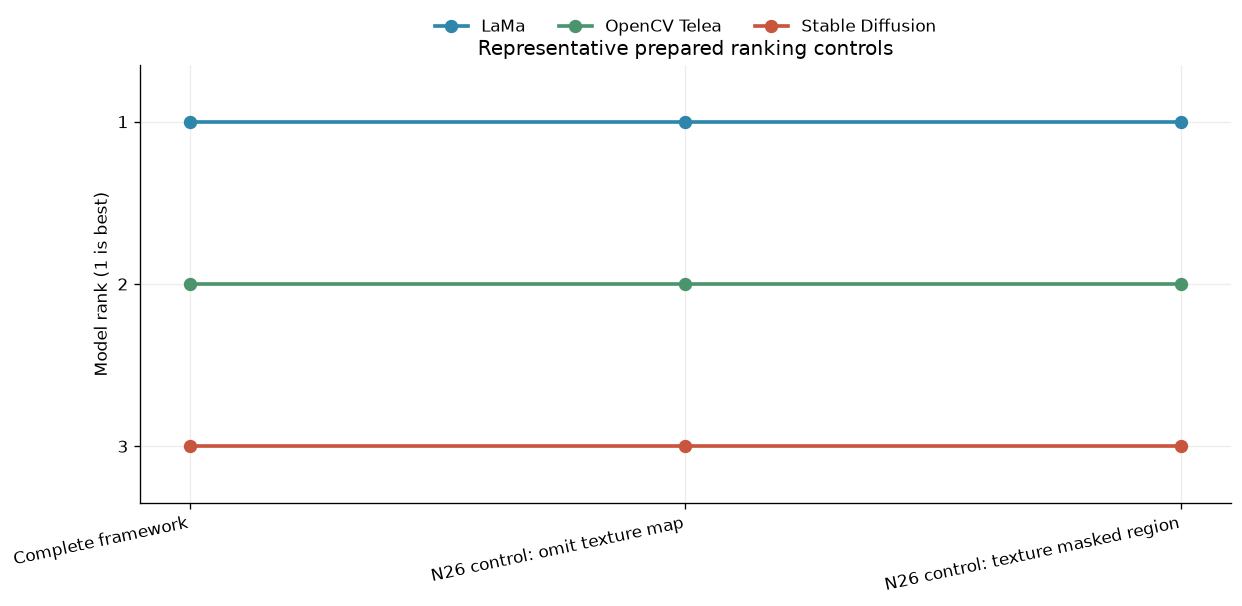

Prepared ranking-control smoke test complete.
Displayed ranking rows: 9
Representative views: 3
All three models present per view: True
These are upstream controls, not final Notebook 28 ablation results.


In [15]:
# Remove this cell's earlier validation record so rerunning
# the replacement remains idempotent.
preserved_checks = [
    check
    for check in VALIDATION.checks
    if not (
        check.validation_stage == BATCH_3_STAGE
        and check.check_id
        == "prepared_ranking_controls_complete"
    )
]

refreshed_validation = ValidationCollector()
refreshed_validation.extend(preserved_checks)
VALIDATION = refreshed_validation

baseline_rank_view = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].eq("baseline_rank")
    ]
    .assign(
        smoke_view="Complete framework"
    )
)

texture_omission_view = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].eq(
            "leave_one_evidence_family_out"
        )
        & RANKING_STABILITY[
            "omitted_unit_id"
        ].eq("texture_map")
    ]
    .assign(
        smoke_view=(
            "N26 control: omit texture map"
        )
    )
)

texture_region_view = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].eq("region_policy_sensitivity")
        & RANKING_STABILITY[
            "region_policy_id"
        ].eq(
            "texture_crop_p95__masked_region"
        )
    ]
    .assign(
        smoke_view=(
            "N26 control: texture masked region"
        )
    )
)

RANKING_CONTROL_SMOKE = pd.concat(
    [
        baseline_rank_view,
        texture_omission_view,
        texture_region_view,
    ],
    ignore_index=True,
)

RANKING_CONTROL_SMOKE[
    "display_rank"
] = pd.to_numeric(
    RANKING_CONTROL_SMOKE[
        "sensitivity_rank"
    ].fillna(
        RANKING_CONTROL_SMOKE[
            "baseline_rank"
        ]
    ),
    errors="coerce",
)

smoke_view_order = [
    "Complete framework",
    "N26 control: omit texture map",
    "N26 control: texture masked region",
]

model_order = [
    "lama",
    "opencv_telea",
    "stable_diffusion_inpainting",
]

ranking_grid = (
    RANKING_CONTROL_SMOKE.pivot(
        index="model_id",
        columns="smoke_view",
        values="display_rank",
    )
    .reindex(
        index=model_order,
        columns=smoke_view_order,
    )
)

ranking_panel_counts = (
    RANKING_CONTROL_SMOKE.groupby(
        "smoke_view"
    )["model_id"]
    .nunique()
    .reindex(smoke_view_order)
)

ranking_controls_complete = (
    len(RANKING_CONTROL_SMOKE) == 9
    and ranking_panel_counts.eq(3).all()
    and ranking_grid.notna().all().all()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="prepared_ranking_controls_complete",
    description=(
        "The representative Notebook 26 ranking "
        "controls contain all three core models."
    ),
    expected={
        view: 3
        for view in smoke_view_order
    },
    observed={
        str(view): int(count)
        for view, count
        in ranking_panel_counts.items()
    },
    passed=ranking_controls_complete,
)

ranking_display = (
    RANKING_CONTROL_SMOKE.sort_values(
        ["smoke_view", "display_rank"]
    )[
        [
            "smoke_view",
            "model_id",
            "baseline_rank",
            "sensitivity_rank",
            "display_rank",
            "rank_change",
            "winner_retained",
            "n_paintings",
            "n_cases",
        ]
    ]
    .reset_index(drop=True)
)

display(ranking_display)

fig, ax = plt.subplots(
    figsize=(10.5, 5.2)
)

x_positions = np.arange(
    len(smoke_view_order)
)

model_colours = {
    "lama": "#2E86AB",
    "opencv_telea": "#4C956C",
    "stable_diffusion_inpainting": "#C8553D",
}

model_labels = {
    "lama": "LaMa",
    "opencv_telea": "OpenCV Telea",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
}

for model_id in model_order:
    ranks = ranking_grid.loc[
        model_id
    ].to_numpy(dtype=float)

    ax.plot(
        x_positions,
        ranks,
        marker="o",
        linewidth=2.2,
        markersize=7,
        color=model_colours[model_id],
        label=model_labels[model_id],
    )

ax.set_xticks(
    x_positions,
    smoke_view_order,
    rotation=12,
    ha="right",
)

ax.set_yticks([1, 2, 3])
ax.set_ylim(3.35, 0.65)
ax.set_ylabel("Model rank (1 is best)")
ax.set_title(
    "Representative prepared ranking controls"
)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
)

fig.tight_layout()
plt.show()
plt.close(fig)

print("Prepared ranking-control smoke test complete.")
print(
    "Displayed ranking rows: "
    f"{len(RANKING_CONTROL_SMOKE):,}"
)
print(
    "Representative views: "
    f"{len(smoke_view_order):,}"
)
print(
    "All three models present per view: "
    f"{ranking_controls_complete}"
)
print(
    "These are upstream controls, not final "
    "Notebook 28 ablation results."
)

In [16]:
current_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_test_no_canonical_writes",
    description=(
        "The representative smoke test writes no "
        "canonical Notebook 28 artifacts."
    ),
    expected=0,
    observed=len(current_output_files),
    passed=not current_output_files,
)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_3_ROWS = (
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_3_ROWS)

print("Batch 3 representative smoke test complete.")
print(
    "Validation checks: "
    f"{len(BATCH_3_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_3_ROWS['passed']).sum()):,}"
)
print(
    "Baseline candidates round-tripped: "
    f"{len(BASELINE_ROUNDTRIP_STABILITY):,}"
)
print(
    "Controlled transitions tested: "
    f"{len(TRANSITION_FIXTURE_STABILITY):,}"
)
print(
    "Canonical N28 files written: "
    f"{len(current_output_files):,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_representative_smoke_test,scenario_configs_are_isolated,Scenario construction does not mutate the published Notebook 27 baseline configuration.,blocking,True,True,True,
1,batch_3_representative_smoke_test,complete_configuration_preserved,The complete-framework configuration retains all 36 approved indicators.,blocking,36,36,True,
2,batch_3_representative_smoke_test,texture_ablation_exact,The texture ablation removes exactly the indicators declared by the scenario catalogue.,blocking,"[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...",True,
3,batch_3_representative_smoke_test,region_rewrite_smoke_exact,The bounded region fixture retains only available indicators and rewrites all of them to the requested full-image region.,blocking,"{""crop_lpips"": ""full_image"", ""crop_ssim"": ""full_image"", ""masked_mae"": ""full_image""}","{""crop_lpips"": ""full_image"", ""crop_ssim"": ""full_image"", ""masked_mae"": ""full_image""}",True,
4,batch_3_representative_smoke_test,sensitive_thresholds_exact,The more-sensitive scenario applies its declared warning and critical quantiles.,blocking,"{""critical_quantile"": 0.95, ""warning_quantile"": 0.8}","{""critical_quantile"": 0.95, ""warning_quantile"": 0.8}",True,
5,batch_3_representative_smoke_test,critical_only_aggregation_exact,The critical-only scenario prevents warning components alone from triggering a flag.,blocking,"{""one_critical_triggers"": true, ""warnings_required"": 999}","{""one_critical_triggers"": true, ""warnings_required"": 999}",True,
6,batch_3_representative_smoke_test,baseline_flag_roundtrip,Passing the full baseline flag ledger through the stability helper produces no changes.,blocking,"{""candidates"": 1785, ""changed_candidates"": 0, ""minimum_agreement"": 1.0}","{""candidates"": 1785, ""changed_candidates"": 0, ""minimum_agreement"": 1.0}",True,
7,batch_3_representative_smoke_test,controlled_transitions_detected,"The structural fixture detects removed, newly missing, resolved-missing, and newly triggered flag states exactly.",blocking,"{""colour_newly_triggered"": true, ""texture_removed_and_missing"": true, ""uncertainty_missingness_resolved"": true}","{""colour_newly_triggered"": true, ""texture_removed_and_missing"": true, ""uncertainty_missingness_resolved"": true}",True,
8,batch_3_representative_smoke_test,flag_stability_helper_checks,Both bounded flag-stability tables pass the canonical helper validation.,blocking,0,0,True,
9,batch_3_representative_smoke_test,prepared_ranking_controls_complete,The representative Notebook 26 ranking controls contain all three core models.,blocking,"{""Complete framework"": 3, ""N26 control: omit texture map"": 3, ""N26 control: texture masked region"": 3}","{""Complete framework"": 3, ""N26 control: omit texture map"": 3, ""N26 control: texture masked region"": 3}",True,


Batch 3 representative smoke test complete.
Validation checks: 11
Blocking failures: 0
Baseline candidates round-tripped: 1,785
Controlled transitions tested: 3
Canonical N28 files written: 0


## Batch 4 — Full evidence normalization and baseline reconstruction

This batch loads the six candidate-level metric tables and reconstructs the complete Notebook 27 baseline from source evidence.

It:

- normalizes all 36 approved indicators;
- retains uncertainty from the canonical and damage-size repeated-seed experiments;
- recalibrates the published baseline thresholds;
- reconstructs all 24,990 failure assignments;
- reconstructs all 19,635 trustworthiness-flag rows;
- compares the reconstructed decisions with the published Notebook 27 ledgers.

Ablation results are not accepted unless this baseline reconstruction is exact. This batch remains in memory and writes no canonical Notebook 28 files.

In [17]:
import time

from restoration_eval.failure_taxonomy import (
    build_failure_assignments,
    build_trustworthiness_flags,
    calibrate_operational_thresholds,
    classify_evidence_against_thresholds,
    normalise_failure_evidence,
)

BATCH_4_STAGE = (
    "batch_4_baseline_reconstruction"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

FAILURE_SETTINGS = FAILURE_CONFIG[
    "failure_taxonomy"
]

metric_source_specs = [
    (
        "classical",
        "classical_metrics_path",
    ),
    (
        "perceptual",
        "lpips_metrics_path",
    ),
    (
        "feature",
        "feature_metrics_path",
    ),
    (
        "spatial",
        "spatial_metrics_path",
    ),
    (
        "local",
        "local_metrics_path",
    ),
    (
        "semantic",
        "semantic_metrics_path",
    ),
]

EVIDENCE_SOURCES = {}

loading_started = time.perf_counter()

for source_number, (
    source_name,
    input_key,
) in enumerate(
    metric_source_specs,
    start=1,
):
    print(
        f"[{source_number}/"
        f"{len(metric_source_specs)}] "
        f"Loading {source_name} evidence..."
    )

    EVIDENCE_SOURCES[source_name] = (
        pd.read_csv(
            INPUT_PATHS[input_key],
            low_memory=False,
        )
    )

    print(
        f"    rows: "
        f"{len(EVIDENCE_SOURCES[source_name]):,}"
    )

metric_loading_seconds = (
    time.perf_counter()
    - loading_started
)

expected_metric_source_rows = {
    "classical": 63018,
    "perceptual": 4170,
    "feature": 8340,
    "spatial": 18896,
    "local": 271988,
    "semantic": 58980,
}

observed_metric_source_rows = {
    source_name: len(frame)
    for source_name, frame
    in EVIDENCE_SOURCES.items()
}

metric_source_summary = pd.DataFrame(
    [
        {
            "source": source_name,
            "rows": len(frame),
            "candidate_ids": (
                frame["candidate_id"].nunique()
            ),
            "status_values": json.dumps(
                sorted(
                    frame["status"]
                    .dropna()
                    .astype(str)
                    .unique()
                    .tolist()
                )
            ),
        }
        for source_name, frame
        in EVIDENCE_SOURCES.items()
    ]
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="full_metric_source_rows",
    description=(
        "All six raw metric sources retain their "
        "validated upstream row counts."
    ),
    expected=expected_metric_source_rows,
    observed=observed_metric_source_rows,
    passed=(
        observed_metric_source_rows
        == expected_metric_source_rows
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="configured_baseline_indicators",
    description=(
        "The Notebook 27 configuration retains all "
        "36 approved operational indicators."
    ),
    expected=36,
    observed=len(
        FAILURE_SETTINGS["indicators"]
    ),
    passed=(
        len(
            FAILURE_SETTINGS["indicators"]
        )
        == 36
    ),
)

display(metric_source_summary)

print("Full metric sources loaded.")
print(
    "Total raw metric rows: "
    f"{sum(observed_metric_source_rows.values()):,}"
)
print(
    "Loading time: "
    f"{metric_loading_seconds:.2f} seconds"
)

[1/6] Loading classical evidence...
    rows: 63,018
[2/6] Loading perceptual evidence...
    rows: 4,170
[3/6] Loading feature evidence...
    rows: 8,340
[4/6] Loading spatial evidence...
    rows: 18,896
[5/6] Loading local evidence...
    rows: 271,988
[6/6] Loading semantic evidence...
    rows: 58,980


,source,rows,candidate_ids,status_values
0,classical,63018,2160,"[""ok""]"
1,perceptual,4170,2160,"[""ok""]"
2,feature,8340,2160,"[""ok""]"
3,spatial,18896,2160,"[""ok""]"
4,local,271988,2160,"[""not_applicable"", ""ok""]"
5,semantic,58980,2160,"[""ok""]"


Full metric sources loaded.
Total raw metric rows: 425,392
Loading time: 7.49 seconds


In [18]:
print(
    "Normalizing the complete evidence ledger. "
    "This is the longest cell in Batch 4."
)

normalization_started = time.perf_counter()

BASELINE_FULL_EVIDENCE = (
    normalise_failure_evidence(
        EVIDENCE_SOURCES,
        CANDIDATE_POPULATION,
        CANONICAL_UNCERTAINTY,
        DAMAGE_SIZE_UNCERTAINTY,
        config=FAILURE_CONFIG,
    )
)

normalization_seconds = (
    time.perf_counter()
    - normalization_started
)

BASELINE_FULL_EVIDENCE[
    "raw_value"
] = pd.to_numeric(
    BASELINE_FULL_EVIDENCE["raw_value"],
    errors="coerce",
)

BASELINE_FULL_EVIDENCE[
    "adverse_value"
] = pd.to_numeric(
    BASELINE_FULL_EVIDENCE[
        "adverse_value"
    ],
    errors="coerce",
)

baseline_evidence_source_summary = (
    BASELINE_FULL_EVIDENCE.groupby(
        [
            "source",
            "source_notebook_id",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
        finite_values=(
            "raw_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

baseline_indicator_summary = (
    BASELINE_FULL_EVIDENCE.groupby(
        [
            "indicator_id",
            "source",
            "region_id",
            "direction",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
    )
    .reset_index()
)

configured_indicator_ids = {
    str(record["indicator_id"])
    for record
    in FAILURE_SETTINGS["indicators"]
}

observed_indicator_ids = set(
    BASELINE_FULL_EVIDENCE[
        "indicator_id"
    ].astype(str)
)

finite_baseline_evidence = bool(
    np.isfinite(
        BASELINE_FULL_EVIDENCE[
            "raw_value"
        ].to_numpy(dtype=float)
    ).all()
    and np.isfinite(
        BASELINE_FULL_EVIDENCE[
            "adverse_value"
        ].to_numpy(dtype=float)
    ).all()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="normalized_baseline_evidence_rows",
    description=(
        "The normalized baseline evidence ledger "
        "reproduces its exact validated row count."
    ),
    expected=51276,
    observed=len(
        BASELINE_FULL_EVIDENCE
    ),
    passed=(
        len(BASELINE_FULL_EVIDENCE)
        == 51276
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="normalized_candidate_coverage",
    description=(
        "Normalized evidence represents the entire "
        "1,785-candidate union."
    ),
    expected=1785,
    observed=(
        BASELINE_FULL_EVIDENCE[
            "candidate_id"
        ].nunique()
    ),
    passed=(
        BASELINE_FULL_EVIDENCE[
            "candidate_id"
        ].nunique()
        == 1785
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="normalized_indicator_coverage",
    description=(
        "Every configured baseline indicator appears "
        "in the normalized evidence ledger."
    ),
    expected=sorted(
        configured_indicator_ids
    ),
    observed=sorted(
        observed_indicator_ids
    ),
    passed=(
        observed_indicator_ids
        == configured_indicator_ids
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="normalized_evidence_ids_unique",
    description=(
        "Every normalized evidence identifier is "
        "unique."
    ),
    expected=0,
    observed=int(
        BASELINE_FULL_EVIDENCE[
            "evidence_id"
        ].duplicated().sum()
    ),
    passed=(
        not BASELINE_FULL_EVIDENCE[
            "evidence_id"
        ].duplicated().any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="normalized_values_finite",
    description=(
        "All retained raw and adverse evidence "
        "values are finite."
    ),
    expected=True,
    observed=finite_baseline_evidence,
    passed=finite_baseline_evidence,
)

display(
    baseline_evidence_source_summary
)
display(
    baseline_indicator_summary
)

print("Complete baseline evidence normalized.")
print(
    "Evidence rows: "
    f"{len(BASELINE_FULL_EVIDENCE):,}"
)
print(
    "Candidates represented: "
    f"{BASELINE_FULL_EVIDENCE['candidate_id'].nunique():,}"
)
print(
    "Indicators represented: "
    f"{BASELINE_FULL_EVIDENCE['indicator_id'].nunique():,}"
)
print(
    "Normalization time: "
    f"{normalization_seconds:.2f} seconds"
)

Normalizing the complete evidence ledger. This is the longest cell in Batch 4.


,source,source_notebook_id,evidence_rows,candidates,indicators,experiments,finite_values
0,classical,13,4590,1530,3,4,4590
1,feature,15,3060,1530,2,4,3060
2,local,17,23106,1530,16,4,23106
3,perceptual,14,1530,1530,1,4,1530
4,semantic,20,11460,1680,7,4,11460
5,spatial,16,4890,1680,3,4,4890
6,uncertainty,18,2080,520,4,1,2080
7,uncertainty,22,560,140,4,1,560


,indicator_id,source,region_id,direction,evidence_rows,candidates,experiments
0,affinity_centroid_shift,semantic,content_region,higher_is_worse,1680,1680,4
1,affinity_js_divergence,semantic,content_region,higher_is_worse,1680,1680,4
2,affinity_map_correlation,semantic,content_region,lower_is_worse,1680,1680,4
3,boundary_gradient_mismatch,local,boundary_ring,higher_is_worse,1530,1530,4
4,boundary_orientation_mismatch,local,boundary_ring,higher_is_worse,1530,1530,4
5,boundary_spillover_p95,local,outside_boundary_ring,higher_is_worse,1530,1530,4
6,boundary_ssim_error,local,boundary_ring,higher_is_worse,1530,1530,4
7,content_psnr,classical,content_region,lower_is_worse,1530,1530,4
8,crop_clip_similarity,feature,mask_bbox_crop,lower_is_worse,1530,1530,4
9,crop_dino_similarity,feature,mask_bbox_crop,lower_is_worse,1530,1530,4


Complete baseline evidence normalized.
Evidence rows: 51,276
Candidates represented: 1,785
Indicators represented: 36
Normalization time: 31.08 seconds


In [19]:
threshold_started = time.perf_counter()

BASELINE_OPERATIONAL_THRESHOLDS = (
    calibrate_operational_thresholds(
        BASELINE_FULL_EVIDENCE,
        CANDIDATE_POPULATION,
        config=FAILURE_CONFIG,
    )
)

BASELINE_CLASSIFIED_EVIDENCE = (
    classify_evidence_against_thresholds(
        BASELINE_FULL_EVIDENCE,
        BASELINE_OPERATIONAL_THRESHOLDS,
    )
)

threshold_seconds = (
    time.perf_counter()
    - threshold_started
)

threshold_source_lookup = {
    str(record["indicator_id"]): str(
        record["source"]
    )
    for record
    in FAILURE_SETTINGS["indicators"]
}

BASELINE_OPERATIONAL_THRESHOLDS[
    "source"
] = (
    BASELINE_OPERATIONAL_THRESHOLDS[
        "indicator_id"
    ]
    .astype(str)
    .map(threshold_source_lookup)
)

baseline_threshold_summary = (
    BASELINE_OPERATIONAL_THRESHOLDS.groupby(
        [
            "source",
            "fitting_scope",
            "threshold_mode",
            "direction",
        ],
        dropna=False,
    )
    .agg(
        threshold_rows=(
            "threshold_id",
            "size",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
        minimum_fitting_count=(
            "n_fitting_candidates",
            "min",
        ),
        maximum_fitting_count=(
            "n_fitting_candidates",
            "max",
        ),
    )
    .reset_index()
)

baseline_evidence_state_summary = (
    BASELINE_CLASSIFIED_EVIDENCE.groupby(
        [
            "source",
            "evidence_state",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
    )
    .reset_index()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="baseline_threshold_rows",
    description=(
        "Baseline calibration reproduces the exact "
        "137 operational threshold strata."
    ),
    expected=137,
    observed=len(
        BASELINE_OPERATIONAL_THRESHOLDS
    ),
    passed=(
        len(
            BASELINE_OPERATIONAL_THRESHOLDS
        )
        == 137
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="baseline_threshold_indicator_coverage",
    description=(
        "Every one of the 36 indicators receives "
        "an operational threshold."
    ),
    expected=36,
    observed=(
        BASELINE_OPERATIONAL_THRESHOLDS[
            "indicator_id"
        ].nunique()
    ),
    passed=(
        BASELINE_OPERATIONAL_THRESHOLDS[
            "indicator_id"
        ].nunique()
        == 36
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="baseline_classification_complete",
    description=(
        "Every normalized evidence row receives "
        "exactly one evidence state."
    ),
    expected=51276,
    observed=len(
        BASELINE_CLASSIFIED_EVIDENCE
    ),
    passed=(
        len(BASELINE_CLASSIFIED_EVIDENCE)
        == len(BASELINE_FULL_EVIDENCE)
        == 51276
        and BASELINE_CLASSIFIED_EVIDENCE[
            "evidence_id"
        ].is_unique
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="baseline_critical_evidence_count",
    description=(
        "Baseline classification reproduces the "
        "published critical-evidence count."
    ),
    expected=2104,
    observed=int(
        BASELINE_CLASSIFIED_EVIDENCE[
            "evidence_state"
        ].eq("critical").sum()
    ),
    passed=(
        int(
            BASELINE_CLASSIFIED_EVIDENCE[
                "evidence_state"
            ].eq("critical").sum()
        )
        == 2104
    ),
)

display(baseline_threshold_summary)
display(baseline_evidence_state_summary)

print("Baseline thresholds and evidence states reconstructed.")
print(
    "Threshold rows: "
    f"{len(BASELINE_OPERATIONAL_THRESHOLDS):,}"
)
print(
    "Classified evidence rows: "
    f"{len(BASELINE_CLASSIFIED_EVIDENCE):,}"
)
print(
    "Critical evidence rows: "
    f"{int(BASELINE_CLASSIFIED_EVIDENCE['evidence_state'].eq('critical').sum()):,}"
)
print(
    "Threshold and classification time: "
    f"{threshold_seconds:.2f} seconds"
)

,source,fitting_scope,threshold_mode,direction,threshold_rows,indicators,experiments,minimum_fitting_count,maximum_fitting_count
0,classical,experiment,quantile,higher_is_worse,4,1,4,105,600
1,classical,experiment,quantile,lower_is_worse,8,2,4,105,600
2,feature,experiment,quantile,lower_is_worse,8,2,4,105,600
3,local,experiment,quantile,higher_is_worse,61,16,4,105,600
4,perceptual,experiment,quantile,higher_is_worse,4,1,4,105,600
5,semantic,experiment,quantile,higher_is_worse,16,4,4,105,600
6,semantic,experiment,quantile,lower_is_worse,12,3,4,105,600
7,spatial,experiment,absolute_tolerance,higher_is_worse,8,2,4,105,600
8,spatial,experiment,quantile,higher_is_worse,4,1,4,105,600
9,uncertainty,experiment_prompt,quantile,higher_is_worse,12,4,2,35,80


,source,evidence_state,evidence_rows,candidates,indicators
0,classical,critical,174,147,3
1,classical,favourable,870,401,3
2,classical,neutral,3124,1278,3
3,classical,warning,422,337,3
4,feature,critical,61,49,2
5,feature,favourable,604,366,2
6,feature,neutral,2212,1202,2
7,feature,warning,183,140,2
8,local,critical,1233,385,15
9,local,favourable,6455,1530,16


Baseline thresholds and evidence states reconstructed.
Threshold rows: 137
Classified evidence rows: 51,276
Critical evidence rows: 2,104
Threshold and classification time: 2.81 seconds


In [20]:
decision_started = time.perf_counter()

RECONSTRUCTED_ASSIGNMENTS = (
    build_failure_assignments(
        CANDIDATE_POPULATION,
        BASELINE_CLASSIFIED_EVIDENCE,
        config=FAILURE_CONFIG,
    )
)

RECONSTRUCTED_FLAGS = (
    build_trustworthiness_flags(
        CANDIDATE_POPULATION,
        RECONSTRUCTED_ASSIGNMENTS,
        BASELINE_CLASSIFIED_EVIDENCE,
        config=FAILURE_CONFIG,
    )
)

decision_seconds = (
    time.perf_counter()
    - decision_started
)

RECONSTRUCTED_ASSIGNMENT_CHECKS = (
    validate_failure_assignments(
        RECONSTRUCTED_ASSIGNMENTS,
        CANDIDATE_POPULATION,
        config=FAILURE_CONFIG,
    )
)

RECONSTRUCTED_FLAG_CHECKS = (
    validate_trustworthiness_flags(
        RECONSTRUCTED_FLAGS,
        CANDIDATE_POPULATION,
        config=FAILURE_CONFIG,
    )
)


def comparable_decision_frame(
    frame: pd.DataFrame,
    *,
    index_columns: list[str],
    value_columns: list[str],
) -> pd.DataFrame:
    """Normalize decision fields for exact comparison."""
    result = (
        frame[
            index_columns + value_columns
        ]
        .copy()
        .set_index(index_columns)
        .sort_index()
    )

    for column in value_columns:
        result[column] = (
            result[column]
            .astype("string")
            .fillna("<NA>")
        )

    return result


assignment_value_columns = [
    "assignment_id",
    "assignment_status",
    "rule_severity",
    "triggered_indicator_count",
    "warning_indicator_count",
    "critical_indicator_count",
    "required_evidence_count",
    "available_evidence_count",
    "evidence_coverage_status",
    "indicator_states_json",
    "supporting_evidence_ids_json",
    "source_notebook_ids_json",
    "affected_regions_json",
    "threshold_policy_id",
    "schema_version",
    "status",
]

flag_value_columns = [
    "flag_assignment_id",
    "flag_status",
    "flag_severity",
    "supporting_category_ids_json",
    "supporting_assignment_ids_json",
    "supporting_evidence_ids_json",
    "source_notebook_ids_json",
    "affected_regions_json",
    "evidence_coverage_status",
    "recommendation_category",
    "manual_review_required",
    "is_combined_score",
    "schema_version",
    "status",
]

published_assignment_comparison = (
    comparable_decision_frame(
        BASELINE_ASSIGNMENTS,
        index_columns=[
            "candidate_id",
            "category_id",
        ],
        value_columns=assignment_value_columns,
    )
)

reconstructed_assignment_comparison = (
    comparable_decision_frame(
        RECONSTRUCTED_ASSIGNMENTS,
        index_columns=[
            "candidate_id",
            "category_id",
        ],
        value_columns=assignment_value_columns,
    )
)

published_flag_comparison = (
    comparable_decision_frame(
        BASELINE_FLAGS,
        index_columns=[
            "candidate_id",
            "flag_id",
        ],
        value_columns=flag_value_columns,
    )
)

reconstructed_flag_comparison = (
    comparable_decision_frame(
        RECONSTRUCTED_FLAGS,
        index_columns=[
            "candidate_id",
            "flag_id",
        ],
        value_columns=flag_value_columns,
    )
)

assignment_keys_match = (
    published_assignment_comparison.index.equals(
        reconstructed_assignment_comparison.index
    )
)

flag_keys_match = (
    published_flag_comparison.index.equals(
        reconstructed_flag_comparison.index
    )
)

if assignment_keys_match:
    assignment_difference_matrix = (
        published_assignment_comparison.ne(
            reconstructed_assignment_comparison
        )
    )
    assignment_mismatch_rows = int(
        assignment_difference_matrix.any(
            axis=1
        ).sum()
    )
    assignment_mismatch_cells = int(
        assignment_difference_matrix.sum().sum()
    )
else:
    assignment_mismatch_rows = max(
        len(published_assignment_comparison),
        len(reconstructed_assignment_comparison),
    )
    assignment_mismatch_cells = (
        assignment_mismatch_rows
        * len(assignment_value_columns)
    )

if flag_keys_match:
    flag_difference_matrix = (
        published_flag_comparison.ne(
            reconstructed_flag_comparison
        )
    )
    flag_mismatch_rows = int(
        flag_difference_matrix.any(
            axis=1
        ).sum()
    )
    flag_mismatch_cells = int(
        flag_difference_matrix.sum().sum()
    )
else:
    flag_mismatch_rows = max(
        len(published_flag_comparison),
        len(reconstructed_flag_comparison),
    )
    flag_mismatch_cells = (
        flag_mismatch_rows
        * len(flag_value_columns)
    )

assignment_state_summary = (
    RECONSTRUCTED_ASSIGNMENTS[
        "assignment_status"
    ]
    .value_counts()
    .rename_axis("assignment_status")
    .reset_index(name="rows")
)

flag_state_summary = (
    RECONSTRUCTED_FLAGS[
        "flag_status"
    ]
    .value_counts()
    .rename_axis("flag_status")
    .reset_index(name="rows")
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="reconstructed_assignment_grid",
    description=(
        "Baseline reconstruction produces the "
        "complete candidate-category grid."
    ),
    expected=24990,
    observed=len(
        RECONSTRUCTED_ASSIGNMENTS
    ),
    passed=(
        len(RECONSTRUCTED_ASSIGNMENTS)
        == 24990
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="reconstructed_flag_grid",
    description=(
        "Baseline reconstruction produces the "
        "complete candidate-flag grid."
    ),
    expected=19635,
    observed=len(
        RECONSTRUCTED_FLAGS
    ),
    passed=(
        len(RECONSTRUCTED_FLAGS)
        == 19635
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="assignment_baseline_reproduced",
    description=(
        "Reconstructed assignment decisions and "
        "provenance match the published Notebook 27 "
        "ledger exactly."
    ),
    expected={
        "key_match": True,
        "mismatch_rows": 0,
        "mismatch_cells": 0,
    },
    observed={
        "key_match": assignment_keys_match,
        "mismatch_rows": (
            assignment_mismatch_rows
        ),
        "mismatch_cells": (
            assignment_mismatch_cells
        ),
    },
    passed=(
        assignment_keys_match
        and assignment_mismatch_rows == 0
        and assignment_mismatch_cells == 0
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="flag_baseline_reproduced",
    description=(
        "Reconstructed flag decisions and provenance "
        "match the published Notebook 27 ledger exactly."
    ),
    expected={
        "key_match": True,
        "mismatch_rows": 0,
        "mismatch_cells": 0,
    },
    observed={
        "key_match": flag_keys_match,
        "mismatch_rows": flag_mismatch_rows,
        "mismatch_cells": flag_mismatch_cells,
    },
    passed=(
        flag_keys_match
        and flag_mismatch_rows == 0
        and flag_mismatch_cells == 0
    ),
)

helper_failure_count = int(
    (
        ~RECONSTRUCTED_ASSIGNMENT_CHECKS[
            "passed"
        ]
    ).sum()
    + (
        ~RECONSTRUCTED_FLAG_CHECKS[
            "passed"
        ]
    ).sum()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="reconstructed_helper_validation",
    description=(
        "Both reconstructed ledgers pass their "
        "canonical producer-helper validation."
    ),
    expected=0,
    observed=helper_failure_count,
    passed=helper_failure_count == 0,
)

display(assignment_state_summary)
display(flag_state_summary)
display(
    RECONSTRUCTED_ASSIGNMENT_CHECKS.assign(
        validation_suite="assignments"
    )
)
display(
    RECONSTRUCTED_FLAG_CHECKS.assign(
        validation_suite="flags"
    )
)

print("Baseline decision ledgers reconstructed.")
print(
    "Assignment rows: "
    f"{len(RECONSTRUCTED_ASSIGNMENTS):,}"
)
print(
    "Assignment mismatch rows: "
    f"{assignment_mismatch_rows:,}"
)
print(
    "Flag rows: "
    f"{len(RECONSTRUCTED_FLAGS):,}"
)
print(
    "Flag mismatch rows: "
    f"{flag_mismatch_rows:,}"
)
print(
    "Decision reconstruction time: "
    f"{decision_seconds:.2f} seconds"
)

,assignment_status,rows
0,not_triggered,17526
1,insufficient_evidence,4378
2,triggered,2266
3,not_applicable,820


,flag_status,rows
0,not_triggered,9358
1,triggered,5486
2,insufficient_evidence,3151
3,not_applicable,1640


,check_id,passed,severity,detail,validation_suite
0,assignment_columns,True,blocking,Canonical column order,assignments
1,assignment_rows,True,blocking,Complete candidate-category grid,assignments
2,assignment_ids_unique,True,blocking,Assignment IDs are unique,assignments
3,assignment_pairs_unique,True,blocking,Candidate-category pairs are unique,assignments
4,assignment_states,True,blocking,"Allowed states only: ['insufficient_evidence', 'not_applicable', 'not_triggered', 'triggered']",assignments
5,assignment_schema,True,blocking,Schema version is exact,assignments
6,missing_not_pass,True,blocking,Missing evidence never passes,assignments
7,trigger_has_evidence,True,blocking,Triggered assignments cite adverse evidence,assignments
8,assignment_no_trust_score,True,blocking,No combined trust score,assignments


,check_id,passed,severity,detail,validation_suite
0,flag_columns,True,blocking,Canonical column order,flags
1,flag_rows,True,blocking,Complete candidate-flag grid,flags
2,flag_ids_unique,True,blocking,Flag assignment IDs are unique,flags
3,flag_pairs_unique,True,blocking,Candidate-flag pairs are unique,flags
4,flag_states,True,blocking,"Allowed states only: ['insufficient_evidence', 'not_applicable', 'not_triggered', 'triggered']",flags
5,flag_schema,True,blocking,Schema version is exact,flags
6,recommendations_allowed,True,blocking,Only approved recommendation categories,flags
7,one_recommendation_per_candidate,True,blocking,Each candidate has one recommendation,flags
8,combined_score_false,True,blocking,No combined score rows,flags
9,flag_no_trust_score,True,blocking,No combined trust score,flags


Baseline decision ledgers reconstructed.
Assignment rows: 24,990
Assignment mismatch rows: 0
Flag rows: 19,635
Flag mismatch rows: 0
Decision reconstruction time: 146.11 seconds


In [21]:
current_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="baseline_reconstruction_no_writes",
    description=(
        "Full baseline reconstruction writes no "
        "canonical Notebook 28 files."
    ),
    expected=0,
    observed=len(current_output_files),
    passed=not current_output_files,
)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_4_ROWS = (
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].eq(BATCH_4_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_4_ROWS)

print("Batch 4 baseline reconstruction complete.")
print(
    "Validation checks: "
    f"{len(BATCH_4_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_4_ROWS['passed']).sum()):,}"
)
print(
    "Normalized evidence rows: "
    f"{len(BASELINE_FULL_EVIDENCE):,}"
)
print(
    "Assignment mismatch rows: "
    f"{assignment_mismatch_rows:,}"
)
print(
    "Flag mismatch rows: "
    f"{flag_mismatch_rows:,}"
)
print(
    "Canonical N28 files written: "
    f"{len(current_output_files):,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_baseline_reconstruction,full_metric_source_rows,All six raw metric sources retain their validated upstream row counts.,blocking,"{""classical"": 63018, ""feature"": 8340, ""local"": 271988, ""perceptual"": 4170, ""semantic"": 58980, ""spatial"": 18896}","{""classical"": 63018, ""feature"": 8340, ""local"": 271988, ""perceptual"": 4170, ""semantic"": 58980, ""spatial"": 18896}",True,
1,batch_4_baseline_reconstruction,configured_baseline_indicators,The Notebook 27 configuration retains all 36 approved operational indicators.,blocking,36,36,True,
2,batch_4_baseline_reconstruction,normalized_baseline_evidence_rows,The normalized baseline evidence ledger reproduces its exact validated row count.,blocking,51276,51276,True,
3,batch_4_baseline_reconstruction,normalized_candidate_coverage,"Normalized evidence represents the entire 1,785-candidate union.",blocking,1785,1785,True,
4,batch_4_baseline_reconstruction,normalized_indicator_coverage,Every configured baseline indicator appears in the normalized evidence ledger.,blocking,"[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...",True,
5,batch_4_baseline_reconstruction,normalized_evidence_ids_unique,Every normalized evidence identifier is unique.,blocking,0,0,True,
6,batch_4_baseline_reconstruction,normalized_values_finite,All retained raw and adverse evidence values are finite.,blocking,True,True,True,
7,batch_4_baseline_reconstruction,baseline_threshold_rows,Baseline calibration reproduces the exact 137 operational threshold strata.,blocking,137,137,True,
8,batch_4_baseline_reconstruction,baseline_threshold_indicator_coverage,Every one of the 36 indicators receives an operational threshold.,blocking,36,36,True,
9,batch_4_baseline_reconstruction,baseline_classification_complete,Every normalized evidence row receives exactly one evidence state.,blocking,51276,51276,True,


Batch 4 baseline reconstruction complete.
Validation checks: 17
Blocking failures: 0
Normalized evidence rows: 51,276
Assignment mismatch rows: 0
Flag mismatch rows: 0
Canonical N28 files written: 0


## Batch 5 — Full flag-ablation execution

This batch executes all 23 approved scenarios against the validated baseline:

- 12 metric scenarios, including the complete framework;
- 6 region-policy scenarios;
- 2 threshold scenarios;
- 3 aggregation scenarios.

Region alternatives are allowed only when both conditions hold:

1. Notebook 08 declares the metric family compatible with the region.
2. The upstream metric table contains finite evidence for that exact indicator and region.

Unavailable evidence remains explicitly missing. It is never converted into a favourable or passing result.

The batch checkpoints compact scenario summaries and candidate-level flag stability under `work/`. It does not yet write either canonical Notebook 28 metric table.

In [24]:
BATCH_5_STAGE = "batch_5_flag_ablation"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

# Maps every operational indicator to the metric-family
# semantics approved by Notebook 08.
INDICATOR_REGION_FAMILY_MAP = {
    "masked_mae": "classical_pixel",
    "crop_ssim": "ssim",
    "content_psnr": "classical_pixel",
    "crop_lpips": "lpips",
    "crop_clip_similarity": "clip",
    "crop_dino_similarity": "dinov2",
    "masked_error_p95": "spatial_diagnostics",
    "smoothing_fraction": "texture_map",
    "gradient_magnitude_error": "texture_descriptor",
    "edge_density_error": "texture_descriptor",
    "affinity_map_correlation": "dinov2",
    "affinity_js_divergence": "dinov2",
    "affinity_centroid_shift": "dinov2",
    "local_dino_similarity": "semantic_patch",
    "local_patch_worsened_fraction": "semantic_patch",
    "periodicity_excess": "texture_descriptor",
    "hallucinated_detail_fraction": "texture_map",
    "local_texture_error_p95": "texture_map",
    "transition_roughness_mismatch": "seam",
    "local_gradient_mismatch": "seam",
    "cross_boundary_colour_error": "seam",
    "boundary_spillover_p95": "seam",
    "masked_delta_e_mean": "colour",
    "masked_delta_e_p95": "colour",
    "masked_hue_shift": "colour",
    "boundary_gradient_mismatch": "seam",
    "boundary_orientation_mismatch": "seam",
    "boundary_ssim_error": "seam",
    "outside_mask_change_fraction": "spatial_diagnostics",
    "outside_mask_change_max": "spatial_diagnostics",
    "outside_context_feature_change": "semantic_patch",
    "global_feature_similarity": "dinov2",
    "uncertainty_pixel_std_p95": "uncertainty_pixelwise",
    "uncertainty_pairwise_lpips": "uncertainty_perceptual",
    "uncertainty_pairwise_dino": "uncertainty_perceptual",
    "uncertainty_pairwise_rgb": "uncertainty_pixelwise",
}

UNCERTAINTY_SOURCE_ROWS = pd.concat(
    [
        CANONICAL_UNCERTAINTY,
        DAMAGE_SIZE_UNCERTAINTY,
    ],
    ignore_index=True,
)


def indicator_rows_by_region(
    indicator: dict,
) -> pd.DataFrame:
    """Count finite source evidence by region.

    Candidate-level sources are restricted directly to the
    Notebook 28 population. Uncertainty sources are stored at
    group-summary or candidate-pair level and are therefore
    counted through uncertainty_group_id instead.
    """
    source = str(indicator["source"])

    if source == "uncertainty":
        frame = UNCERTAINTY_SOURCE_ROWS
    else:
        frame = EVIDENCE_SOURCES[source]

    subset = frame

    if "status" in subset.columns:
        subset = subset.loc[
            subset["status"]
            .astype(str)
            .eq("ok")
        ]

    if (
        source != "spatial"
        and "metric_name" in subset.columns
    ):
        subset = subset.loc[
            subset["metric_name"]
            .astype(str)
            .eq(
                str(indicator["metric_name"])
            )
        ]

    feature_model_id = indicator.get(
        "feature_model_id"
    )

    if (
        feature_model_id
        and "feature_model_id"
        in subset.columns
    ):
        subset = subset.loc[
            subset["feature_model_id"]
            .astype(str)
            .eq(str(feature_model_id))
        ]

    if "summary_statistic" in subset.columns:
        requested_summary = str(
            indicator["summary_statistic"]
        )

        matching_summary = (
            subset["summary_statistic"]
            .astype(str)
            .eq(requested_summary)
        )

        # Notebook 18/22 pairwise metrics use pair_value,
        # while their N27 adapter declares source aggregation.
        # Match the requested statistic when it exists; otherwise
        # retain the metric's validated observation-level rows.
        if (
            source != "uncertainty"
            or matching_summary.any()
        ):
            subset = subset.loc[
                matching_summary
            ]

    value_column = str(
        indicator["value_column"]
    )

    numeric_values = pd.to_numeric(
        subset[value_column],
        errors="coerce",
    )

    subset = subset.loc[
        np.isfinite(numeric_values)
    ]

    if source == "uncertainty":
        # These rows are group summaries or unordered seed
        # pairs. candidate_id is intentionally empty and the
        # producer helper later expands each group to its four
        # candidate members.
        subset = subset.loc[
            subset["uncertainty_group_id"]
            .notna()
            & subset["uncertainty_group_id"]
            .astype(str)
            .str.len()
            .gt(0)
        ]
    else:
        subset = subset.loc[
            subset["candidate_id"]
            .astype(str)
            .isin(population_candidate_ids)
        ]

    if subset.empty:
        return pd.DataFrame(
            columns=[
                "region_id",
                "source_rows",
                "candidate_count",
            ]
        )

    if source == "uncertainty":
        result = (
            subset.groupby(
                "region_id",
                dropna=False,
            )
            .agg(
                source_rows=(
                    "uncertainty_group_id",
                    "size",
                ),
                candidate_count=(
                    "uncertainty_group_id",
                    "nunique",
                ),
            )
            .reset_index()
        )
    else:
        result = (
            subset.groupby(
                "region_id",
                dropna=False,
            )
            .agg(
                source_rows=(
                    "candidate_id",
                    "size",
                ),
                candidate_count=(
                    "candidate_id",
                    "nunique",
                ),
            )
            .reset_index()
        )

    return result


configured_indicators = {
    str(record["indicator_id"]): record
    for record
    in FAILURE_SETTINGS["indicators"]
}

available_policy_families = set(
    compatible_memberships[
        "metric_family"
    ].astype(str)
)

availability_records = []
original_region_records = []

for indicator_id, indicator in (
    configured_indicators.items()
):
    family = INDICATOR_REGION_FAMILY_MAP[
        indicator_id
    ]

    source_region_counts = (
        indicator_rows_by_region(indicator)
    )

    source_region_lookup = {
        str(record["region_id"]): {
            "source_rows": int(
                record["source_rows"]
            ),
            "candidate_count": int(
                record["candidate_count"]
            ),
        }
        for record
        in source_region_counts.to_dict(
            "records"
        )
    }

    original_region = str(
        indicator["region_id"]
    )

    original_region_records.append(
        {
            "indicator_id": indicator_id,
            "metric_family": family,
            "original_region_id": original_region,
            "source_rows": (
                source_region_lookup.get(
                    original_region,
                    {},
                ).get("source_rows", 0)
            ),
            "available": (
                original_region
                in source_region_lookup
            ),
        }
    )

    compatible_regions = (
        compatible_memberships.loc[
            compatible_memberships[
                "metric_family"
            ].astype(str).eq(family),
            "region_id",
        ]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    for region_id in compatible_regions:
        source_counts = (
            source_region_lookup.get(
                region_id,
                {},
            )
        )

        availability_records.append(
            {
                "indicator_id": indicator_id,
                "metric_family": family,
                "region_id": region_id,
                "available": (
                    region_id
                    in source_region_lookup
                ),
                "source_rows": int(
                    source_counts.get(
                        "source_rows",
                        0,
                    )
                ),
                "candidate_count": int(
                    source_counts.get(
                        "candidate_count",
                        0,
                    )
                ),
            }
        )

INDICATOR_REGION_AVAILABILITY = (
    pd.DataFrame(availability_records)
    .sort_values(
        [
            "indicator_id",
            "region_id",
        ]
    )
    .reset_index(drop=True)
)

ORIGINAL_REGION_AVAILABILITY = (
    pd.DataFrame(original_region_records)
    .sort_values("indicator_id")
    .reset_index(drop=True)
)

region_scenario_records = []

for scenario in (
    SCENARIO_CATALOG.loc[
        SCENARIO_CATALOG[
            "scenario_family"
        ].eq("region")
    ].to_dict("records")
):
    scenario_config = scenario_failure_config(
        FAILURE_CONFIG,
        scenario,
        ablation_config=ANALYSIS_CONFIG,
        indicator_region_availability=(
            INDICATOR_REGION_AVAILABILITY
        ),
    )

    scenario_settings = scenario_config.get(
        "failure_taxonomy",
        scenario_config,
    )

    selected_regions = {
        str(record["indicator_id"]): str(
            record["region_id"]
        )
        for record
        in scenario_settings["indicators"]
    }

    preferred_regions = json.loads(
        scenario["preferred_regions_json"]
    )

    omitted_indicator_ids = sorted(
        configured_indicator_ids
        - selected_regions.keys()
    )

    region_scenario_records.append(
        {
            "scenario_id": scenario[
                "scenario_id"
            ],
            "preferred_regions": (
                scenario[
                    "preferred_regions_json"
                ]
            ),
            "active_indicators": len(
                selected_regions
            ),
            "omitted_indicators": len(
                omitted_indicator_ids
            ),
            "all_selected_regions_preferred": (
                set(
                    selected_regions.values()
                ).issubset(
                    set(preferred_regions)
                )
            ),
            "selected_regions_json": (
                json.dumps(
                    selected_regions,
                    sort_keys=True,
                )
            ),
            "omitted_indicator_ids_json": (
                json.dumps(
                    omitted_indicator_ids
                )
            ),
        }
    )

REGION_SCENARIO_CONFIGURATION = (
    pd.DataFrame(region_scenario_records)
)

mapped_indicator_ids = set(
    INDICATOR_REGION_FAMILY_MAP
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="indicator_region_family_map_exact",
    description=(
        "Every one of the 36 operational indicators "
        "has one approved Notebook 08 metric-family "
        "mapping."
    ),
    expected=sorted(
        configured_indicator_ids
    ),
    observed=sorted(
        mapped_indicator_ids
    ),
    passed=(
        mapped_indicator_ids
        == set(configured_indicator_ids)
        and set(
            INDICATOR_REGION_FAMILY_MAP.values()
        ).issubset(
            available_policy_families
        )
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="original_indicator_regions_available",
    description=(
        "Every baseline indicator retains finite "
        "evidence in its original approved region."
    ),
    expected=36,
    observed=int(
        ORIGINAL_REGION_AVAILABILITY[
            "available"
        ].sum()
    ),
    passed=(
        len(ORIGINAL_REGION_AVAILABILITY)
        == 36
        and ORIGINAL_REGION_AVAILABILITY[
            "available"
        ].all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="indicator_region_keys_unique",
    description=(
        "Every indicator-region compatibility key "
        "appears at most once."
    ),
    expected=0,
    observed=int(
        INDICATOR_REGION_AVAILABILITY
        .duplicated(
            [
                "indicator_id",
                "region_id",
            ]
        )
        .sum()
    ),
    passed=(
        not INDICATOR_REGION_AVAILABILITY
        .duplicated(
            [
                "indicator_id",
                "region_id",
            ]
        )
        .any()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="six_region_scenarios_resolved",
    description=(
        "All six region scenarios retain at least "
        "one evidence-backed indicator."
    ),
    expected=6,
    observed={
        "scenarios": len(
            REGION_SCENARIO_CONFIGURATION
        ),
        "minimum_active_indicators": int(
            REGION_SCENARIO_CONFIGURATION[
                "active_indicators"
            ].min()
        ),
    },
    passed=(
        len(
            REGION_SCENARIO_CONFIGURATION
        )
        == 6
        and REGION_SCENARIO_CONFIGURATION[
            "active_indicators"
        ].gt(0).all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="region_preferences_respected",
    description=(
        "Every selected alternative region belongs "
        "to its scenario's declared preference list."
    ),
    expected=True,
    observed=bool(
        REGION_SCENARIO_CONFIGURATION[
            "all_selected_regions_preferred"
        ].all()
    ),
    passed=bool(
        REGION_SCENARIO_CONFIGURATION[
            "all_selected_regions_preferred"
        ].all()
    ),
)

display(ORIGINAL_REGION_AVAILABILITY)
display(
    INDICATOR_REGION_AVAILABILITY.loc[
        INDICATOR_REGION_AVAILABILITY[
            "available"
        ]
    ]
)
display(REGION_SCENARIO_CONFIGURATION)

print("Indicator-region availability constructed.")
print(
    "Mapped indicators: "
    f"{len(mapped_indicator_ids):,}"
)
print(
    "Evidence-backed compatible pairs: "
    f"{int(INDICATOR_REGION_AVAILABILITY['available'].sum()):,}"
)
print(
    "Region scenarios resolved: "
    f"{len(REGION_SCENARIO_CONFIGURATION):,}"
)

VALIDATION.raise_for_blocking()

,indicator_id,metric_family,original_region_id,source_rows,available
0,affinity_centroid_shift,dinov2,content_region,1680,True
1,affinity_js_divergence,dinov2,content_region,1680,True
2,affinity_map_correlation,dinov2,content_region,1680,True
3,boundary_gradient_mismatch,seam,boundary_ring,1530,True
4,boundary_orientation_mismatch,seam,boundary_ring,1530,True
5,boundary_spillover_p95,seam,outside_boundary_ring,1530,True
6,boundary_ssim_error,seam,boundary_ring,1530,True
7,content_psnr,classical_pixel,content_region,1530,True
8,crop_clip_similarity,clip,mask_bbox_crop,1530,True
9,crop_dino_similarity,dinov2,mask_bbox_crop,1530,True


,indicator_id,metric_family,region_id,available,source_rows,candidate_count
0,affinity_centroid_shift,dinov2,content_region,True,1680,1680
4,affinity_js_divergence,dinov2,content_region,True,1680,1680
8,affinity_map_correlation,dinov2,content_region,True,1680,1680
12,boundary_gradient_mismatch,seam,boundary_ring,True,1530,1530
16,boundary_orientation_mismatch,seam,boundary_ring,True,1530,1530
...,...,...,...,...,...,...
222,uncertainty_pixel_std_p95,uncertainty_pixelwise,content_region,True,165,165
224,uncertainty_pixel_std_p95,uncertainty_pixelwise,full_image,True,165,165
226,uncertainty_pixel_std_p95,uncertainty_pixelwise,mask_bbox_crop,True,165,165
227,uncertainty_pixel_std_p95,uncertainty_pixelwise,masked_region,True,165,165


,scenario_id,preferred_regions,active_indicators,omitted_indicators,all_selected_regions_preferred,selected_regions_json,omitted_indicator_ids_json
0,full_image_only,"[""full_image""]",11,25,True,"{""content_psnr"": ""full_image"", ""crop_ssim"": ""full_image"", ""masked_delta_e_mean"": ""full_image"", ""masked_delta_e_p95"": ""full_image"", ""masked_error_p95"": ""full_image"", ""masked_hue...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun..."
1,content_region_only,"[""content_region""]",22,14,True,"{""affinity_centroid_shift"": ""content_region"", ""affinity_js_divergence"": ""content_region"", ""affinity_map_correlation"": ""content_region"", ""content_psnr"": ""content_region"", ""crop_...","[""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boundary_ssim_error"", ""cross_boundary_colour_error"", ""edge_density_error"", ""gradient_..."
2,masked_pixels_where_valid,"[""degradation_support"",""masked_region""]",13,23,True,"{""content_psnr"": ""degradation_support"", ""hallucinated_detail_fraction"": ""degradation_support"", ""local_texture_error_p95"": ""degradation_support"", ""masked_delta_e_mean"": ""degrada...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun..."
3,mask_bbox_only,"[""mask_bbox_crop""]",24,12,True,"{""content_psnr"": ""mask_bbox_crop"", ""crop_clip_similarity"": ""mask_bbox_crop"", ""crop_dino_similarity"": ""mask_bbox_crop"", ""crop_lpips"": ""mask_bbox_crop"", ""crop_ssim"": ""mask_bbox_c...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun..."
4,boundary_regions,"[""boundary_ring"",""inner_boundary_band"",""outer_boundary_band"",""outside_boundary_ring""]",20,16,True,"{""boundary_gradient_mismatch"": ""boundary_ring"", ""boundary_orientation_mismatch"": ""boundary_ring"", ""boundary_spillover_p95"": ""outside_boundary_ring"", ""boundary_ssim_error"": ""bou...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""crop_clip_similarity"", ""crop_dino_similarity"", ""crop_lpips"", ""crop_ssim"", ""edge_density_error..."
5,outside_mask_only,"[""outside_boundary_ring"",""outside_mask_content""]",14,22,True,"{""boundary_spillover_p95"": ""outside_boundary_ring"", ""content_psnr"": ""outside_boundary_ring"", ""hallucinated_detail_fraction"": ""outside_boundary_ring"", ""local_texture_error_p95"":...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_ssim_error"", ""crop_cl..."


Indicator-region availability constructed.
Mapped indicators: 36
Evidence-backed compatible pairs: 145
Region scenarios resolved: 6


In [25]:
BASELINE_SOURCE_FAMILY_COUNTS = (
    BASELINE_CLASSIFIED_EVIDENCE.groupby(
        "candidate_id"
    )["source"]
    .nunique()
    .to_dict()
)

BASELINE_UNCERTAINTY_CANDIDATES = set(
    BASELINE_CLASSIFIED_EVIDENCE.loc[
        BASELINE_CLASSIFIED_EVIDENCE[
            "source"
        ].eq("uncertainty"),
        "candidate_id",
    ].astype(str)
)


def apply_scenario_missingness_guards(
    scenario_flags: pd.DataFrame,
    scenario_evidence: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Prevent evidence removed by an ablation from becoming a pass."""
    guarded = scenario_flags.copy()

    scenario_source_counts = (
        scenario_evidence.groupby(
            "candidate_id"
        )["source"]
        .nunique()
        .to_dict()
    )

    scenario_uncertainty_candidates = set(
        scenario_evidence.loc[
            scenario_evidence[
                "source"
            ].eq("uncertainty"),
            "candidate_id",
        ].astype(str)
    )

    lost_multi_family_support = {
        str(candidate_id)
        for candidate_id, baseline_count
        in BASELINE_SOURCE_FAMILY_COUNTS.items()
        if int(baseline_count) >= 2
        and int(
            scenario_source_counts.get(
                candidate_id,
                0,
            )
        )
        < 2
    }

    lost_uncertainty_support = (
        BASELINE_UNCERTAINTY_CANDIDATES
        - scenario_uncertainty_candidates
    )

    disagreement_mask = (
        guarded["candidate_id"]
        .astype(str)
        .isin(lost_multi_family_support)
        & guarded["flag_id"]
        .eq("metric_disagreement")
        & guarded["flag_status"]
        .eq("not_triggered")
    )

    instability_mask = (
        guarded["candidate_id"]
        .astype(str)
        .isin(lost_uncertainty_support)
        & guarded["flag_id"]
        .eq("restoration_instability")
        & guarded["flag_status"]
        .isin(
            [
                "not_triggered",
                "triggered",
            ]
        )
    )

    guarded.loc[
        disagreement_mask,
        [
            "flag_status",
            "flag_severity",
            "evidence_coverage_status",
            "explanation",
        ],
    ] = [
        "insufficient_evidence",
        "not_assigned",
        "insufficient",
        (
            "The ablation leaves fewer than two "
            "independent evidence families, so metric "
            "disagreement cannot be treated as passing."
        ),
    ]

    guarded.loc[
        instability_mask,
        [
            "flag_status",
            "flag_severity",
            "evidence_coverage_status",
            "explanation",
        ],
    ] = [
        "insufficient_evidence",
        "not_assigned",
        "insufficient",
        (
            "Repeated-seed evidence available in the "
            "baseline was removed by this ablation, so "
            "restoration instability cannot be treated "
            "as passing."
        ),
    ]

    return guarded, {
        "metric_disagreement_guards": int(
            disagreement_mask.sum()
        ),
        "restoration_instability_guards": int(
            instability_mask.sum()
        ),
    }


def execute_flag_scenario(
    scenario: dict,
) -> dict[str, object]:
    """Execute one scenario and return its temporary ledgers."""
    scenario_id = str(
        scenario["scenario_id"]
    )
    scenario_family = str(
        scenario["scenario_family"]
    )

    if bool(scenario["is_baseline"]):
        return {
            "config": FAILURE_CONFIG,
            "evidence": BASELINE_FULL_EVIDENCE,
            "thresholds": (
                BASELINE_OPERATIONAL_THRESHOLDS
            ),
            "classified": (
                BASELINE_CLASSIFIED_EVIDENCE
            ),
            "assignments": (
                RECONSTRUCTED_ASSIGNMENTS
            ),
            "flags": RECONSTRUCTED_FLAGS,
            "missingness_guards": {
                "metric_disagreement_guards": 0,
                "restoration_instability_guards": 0,
            },
        }

    scenario_config = scenario_failure_config(
        FAILURE_CONFIG,
        scenario,
        ablation_config=ANALYSIS_CONFIG,
        indicator_region_availability=(
            INDICATOR_REGION_AVAILABILITY
            if scenario_family == "region"
            else None
        ),
    )

    scenario_settings = scenario_config.get(
        "failure_taxonomy",
        scenario_config,
    )

    active_indicator_ids = {
        str(record["indicator_id"])
        for record
        in scenario_settings["indicators"]
    }

    if scenario_family == "region":
        scenario_evidence = (
            normalise_failure_evidence(
                EVIDENCE_SOURCES,
                CANDIDATE_POPULATION,
                CANONICAL_UNCERTAINTY,
                DAMAGE_SIZE_UNCERTAINTY,
                config=scenario_config,
            )
        )
    else:
        scenario_evidence = (
            BASELINE_FULL_EVIDENCE.loc[
                BASELINE_FULL_EVIDENCE[
                    "indicator_id"
                ].isin(active_indicator_ids)
            ]
            .copy()
        )

    if scenario_family == "aggregation":
        scenario_thresholds = (
            BASELINE_OPERATIONAL_THRESHOLDS
        )
        scenario_classified = (
            BASELINE_CLASSIFIED_EVIDENCE
        )
    else:
        scenario_thresholds = (
            calibrate_operational_thresholds(
                scenario_evidence,
                CANDIDATE_POPULATION,
                config=scenario_config,
            )
        )

        scenario_classified = (
            classify_evidence_against_thresholds(
                scenario_evidence,
                scenario_thresholds,
            )
        )

    scenario_assignments = (
        build_failure_assignments(
            CANDIDATE_POPULATION,
            scenario_classified,
            config=scenario_config,
        )
    )

    scenario_flags = (
        build_trustworthiness_flags(
            CANDIDATE_POPULATION,
            scenario_assignments,
            scenario_classified,
            config=scenario_config,
        )
    )

    scenario_flags, guard_counts = (
        apply_scenario_missingness_guards(
            scenario_flags,
            scenario_classified,
        )
    )

    assignment_checks = (
        validate_failure_assignments(
            scenario_assignments,
            CANDIDATE_POPULATION,
            config=scenario_config,
        )
    )

    flag_checks = (
        validate_trustworthiness_flags(
            scenario_flags,
            CANDIDATE_POPULATION,
            config=scenario_config,
        )
    )

    if (
        not assignment_checks["passed"].all()
        or not flag_checks["passed"].all()
    ):
        raise RuntimeError(
            "Scenario helper validation failed for "
            f"{scenario_id}."
        )

    return {
        "config": scenario_config,
        "evidence": scenario_evidence,
        "thresholds": scenario_thresholds,
        "classified": scenario_classified,
        "assignments": scenario_assignments,
        "flags": scenario_flags,
        "missingness_guards": guard_counts,
    }


print("Scenario execution functions prepared.")
print(
    "Baseline candidates with uncertainty evidence: "
    f"{len(BASELINE_UNCERTAINTY_CANDIDATES):,}"
)
print(
    "No scenario has been executed by this cell."
)

Scenario execution functions prepared.
Baseline candidates with uncertainty evidence: 660
No scenario has been executed by this cell.


In [26]:
WORK_ROOT = OUTPUT_ROOT / "work"
WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FLAG_STABILITY_CHECKPOINT_PATH = (
    WORK_ROOT
    / "flag_stability_checkpoint.csv"
)

FLAG_SUMMARY_CHECKPOINT_PATH = (
    WORK_ROOT
    / "flag_summary_checkpoint.csv"
)

SCENARIO_SUMMARY_CHECKPOINT_PATH = (
    WORK_ROOT
    / "scenario_summary_checkpoint.csv"
)

SCENARIO_FLAG_SUMMARY_COLUMNS = [
    "scenario_id",
    "scenario_family",
    "flag_id",
    "candidates",
    "triggered_candidates",
    "not_triggered_candidates",
    "insufficient_candidates",
    "not_applicable_candidates",
    "critical_candidates",
    "baseline_triggered_candidates",
    "triggered_candidate_delta",
]

SCENARIO_EXECUTION_COLUMNS = [
    "scenario_id",
    "scenario_family",
    "scenario_order",
    "ranking_applicable",
    "active_indicator_count",
    "active_anchor_count",
    "evidence_rows",
    "threshold_rows",
    "assignment_rows",
    "flag_rows",
    "triggered_flag_rows",
    "changed_candidates",
    "mean_flag_agreement",
    "mean_triggered_jaccard",
    "metric_disagreement_guards",
    "restoration_instability_guards",
    "runtime_seconds",
    "status",
]

if (
    FLAG_STABILITY_CHECKPOINT_PATH.exists()
    and FLAG_SUMMARY_CHECKPOINT_PATH.exists()
    and SCENARIO_SUMMARY_CHECKPOINT_PATH.exists()
):
    SCENARIO_FLAG_STABILITY = pd.read_csv(
        FLAG_STABILITY_CHECKPOINT_PATH,
        low_memory=False,
    )

    SCENARIO_FLAG_SUMMARY = pd.read_csv(
        FLAG_SUMMARY_CHECKPOINT_PATH,
        low_memory=False,
    )

    SCENARIO_EXECUTION_SUMMARY = pd.read_csv(
        SCENARIO_SUMMARY_CHECKPOINT_PATH,
        low_memory=False,
    )

    valid_completed_scenarios = {
        scenario_id
        for scenario_id
        in set(
            SCENARIO_FLAG_STABILITY[
                "scenario_id"
            ].astype(str)
        )
        & set(
            SCENARIO_FLAG_SUMMARY[
                "scenario_id"
            ].astype(str)
        )
        & set(
            SCENARIO_EXECUTION_SUMMARY[
                "scenario_id"
            ].astype(str)
        )
        if (
            SCENARIO_FLAG_STABILITY.loc[
                SCENARIO_FLAG_STABILITY[
                    "scenario_id"
                ].astype(str).eq(
                    scenario_id
                )
            ].shape[0]
            == 1785
            and SCENARIO_FLAG_SUMMARY.loc[
                SCENARIO_FLAG_SUMMARY[
                    "scenario_id"
                ].astype(str).eq(
                    scenario_id
                )
            ].shape[0]
            == 11
            and SCENARIO_EXECUTION_SUMMARY.loc[
                SCENARIO_EXECUTION_SUMMARY[
                    "scenario_id"
                ].astype(str).eq(
                    scenario_id
                )
            ].shape[0]
            == 1
        )
    }

    SCENARIO_FLAG_STABILITY = (
        SCENARIO_FLAG_STABILITY.loc[
            SCENARIO_FLAG_STABILITY[
                "scenario_id"
            ].astype(str).isin(
                valid_completed_scenarios
            )
        ].copy()
    )

    SCENARIO_FLAG_SUMMARY = (
        SCENARIO_FLAG_SUMMARY.loc[
            SCENARIO_FLAG_SUMMARY[
                "scenario_id"
            ].astype(str).isin(
                valid_completed_scenarios
            )
        ].copy()
    )

    SCENARIO_EXECUTION_SUMMARY = (
        SCENARIO_EXECUTION_SUMMARY.loc[
            SCENARIO_EXECUTION_SUMMARY[
                "scenario_id"
            ].astype(str).isin(
                valid_completed_scenarios
            )
        ].copy()
    )

    print(
        "Valid checkpoint scenarios found: "
        f"{len(valid_completed_scenarios):,}"
    )
else:
    SCENARIO_FLAG_STABILITY = pd.DataFrame(
        columns=FLAG_STABILITY_COLUMNS
    )

    SCENARIO_FLAG_SUMMARY = pd.DataFrame(
        columns=SCENARIO_FLAG_SUMMARY_COLUMNS
    )

    SCENARIO_EXECUTION_SUMMARY = pd.DataFrame(
        columns=SCENARIO_EXECUTION_COLUMNS
    )

    valid_completed_scenarios = set()

baseline_trigger_counts = (
    BASELINE_FLAGS.loc[
        BASELINE_FLAGS[
            "flag_status"
        ].eq("triggered")
    ]
    .groupby("flag_id")
    ["candidate_id"]
    .nunique()
    .to_dict()
)

scenario_records = (
    SCENARIO_CATALOG.sort_values(
        "scenario_order"
    )
    .to_dict("records")
)

batch_execution_started = (
    time.perf_counter()
)

for scenario_number, scenario in enumerate(
    scenario_records,
    start=1,
):
    scenario_id = str(
        scenario["scenario_id"]
    )

    if scenario_id in valid_completed_scenarios:
        print(
            f"[{scenario_number}/23] "
            f"{scenario_id}: resumed from checkpoint"
        )
        continue

    print(
        f"[{scenario_number}/23] "
        f"{scenario_id}: running..."
    )

    scenario_started = time.perf_counter()

    scenario_result = execute_flag_scenario(
        scenario
    )

    scenario_flags = scenario_result[
        "flags"
    ]

    scenario_stability = (
        build_flag_stability(
            BASELINE_FLAGS,
            scenario_flags,
            scenario_id=scenario_id,
            scenario_family=str(
                scenario[
                    "scenario_family"
                ]
            ),
        )
    )

    scenario_flag_records = []

    for flag_id, flag_rows in (
        scenario_flags.groupby(
            "flag_id",
            sort=True,
        )
    ):
        triggered_count = int(
            flag_rows[
                "flag_status"
            ].eq("triggered").sum()
        )

        scenario_flag_records.append(
            {
                "scenario_id": scenario_id,
                "scenario_family": scenario[
                    "scenario_family"
                ],
                "flag_id": flag_id,
                "candidates": len(flag_rows),
                "triggered_candidates": (
                    triggered_count
                ),
                "not_triggered_candidates": int(
                    flag_rows[
                        "flag_status"
                    ].eq(
                        "not_triggered"
                    ).sum()
                ),
                "insufficient_candidates": int(
                    flag_rows[
                        "flag_status"
                    ].eq(
                        "insufficient_evidence"
                    ).sum()
                ),
                "not_applicable_candidates": int(
                    flag_rows[
                        "flag_status"
                    ].eq(
                        "not_applicable"
                    ).sum()
                ),
                "critical_candidates": int(
                    flag_rows[
                        "flag_severity"
                    ].eq("critical").sum()
                ),
                "baseline_triggered_candidates": int(
                    baseline_trigger_counts.get(
                        flag_id,
                        0,
                    )
                ),
                "triggered_candidate_delta": (
                    triggered_count
                    - int(
                        baseline_trigger_counts.get(
                            flag_id,
                            0,
                        )
                    )
                ),
            }
        )

    scenario_runtime_seconds = (
        time.perf_counter()
        - scenario_started
    )

    scenario_config = scenario_result[
        "config"
    ]

    scenario_settings = scenario_config.get(
        "failure_taxonomy",
        scenario_config,
    )

    scenario_execution_record = {
        "scenario_id": scenario_id,
        "scenario_family": scenario[
            "scenario_family"
        ],
        "scenario_order": int(
            scenario["scenario_order"]
        ),
        "ranking_applicable": bool(
            scenario["ranking_applicable"]
        ),
        "active_indicator_count": len(
            scenario_settings["indicators"]
        ),
        "active_anchor_count": len(
            json.loads(
                scenario[
                    "active_anchor_ids_json"
                ]
            )
        ),
        "evidence_rows": len(
            scenario_result["evidence"]
        ),
        "threshold_rows": len(
            scenario_result["thresholds"]
        ),
        "assignment_rows": len(
            scenario_result["assignments"]
        ),
        "flag_rows": len(
            scenario_flags
        ),
        "triggered_flag_rows": int(
            scenario_flags[
                "flag_status"
            ].eq("triggered").sum()
        ),
        "changed_candidates": int(
            scenario_stability[
                "changed_flag_count"
            ].gt(0).sum()
        ),
        "mean_flag_agreement": float(
            scenario_stability[
                "flag_state_agreement_fraction"
            ].mean()
        ),
        "mean_triggered_jaccard": float(
            scenario_stability[
                "triggered_jaccard"
            ].mean()
        ),
        "metric_disagreement_guards": int(
            scenario_result[
                "missingness_guards"
            ][
                "metric_disagreement_guards"
            ]
        ),
        "restoration_instability_guards": int(
            scenario_result[
                "missingness_guards"
            ][
                "restoration_instability_guards"
            ]
        ),
        "runtime_seconds": float(
            scenario_runtime_seconds
        ),
        "status": "ok",
    }

    SCENARIO_FLAG_STABILITY = pd.concat(
        [
            SCENARIO_FLAG_STABILITY.loc[
                ~SCENARIO_FLAG_STABILITY[
                    "scenario_id"
                ].astype(str).eq(
                    scenario_id
                )
            ],
            scenario_stability,
        ],
        ignore_index=True,
    )

    SCENARIO_FLAG_SUMMARY = pd.concat(
        [
            SCENARIO_FLAG_SUMMARY.loc[
                ~SCENARIO_FLAG_SUMMARY[
                    "scenario_id"
                ].astype(str).eq(
                    scenario_id
                )
            ],
            pd.DataFrame(
                scenario_flag_records,
                columns=(
                    SCENARIO_FLAG_SUMMARY_COLUMNS
                ),
            ),
        ],
        ignore_index=True,
    )

    SCENARIO_EXECUTION_SUMMARY = pd.concat(
        [
            SCENARIO_EXECUTION_SUMMARY.loc[
                ~SCENARIO_EXECUTION_SUMMARY[
                    "scenario_id"
                ].astype(str).eq(
                    scenario_id
                )
            ],
            pd.DataFrame(
                [scenario_execution_record],
                columns=(
                    SCENARIO_EXECUTION_COLUMNS
                ),
            ),
        ],
        ignore_index=True,
    )

    atomic_write_csv(
        SCENARIO_FLAG_STABILITY,
        FLAG_STABILITY_CHECKPOINT_PATH,
    )

    atomic_write_csv(
        SCENARIO_FLAG_SUMMARY,
        FLAG_SUMMARY_CHECKPOINT_PATH,
    )

    atomic_write_csv(
        SCENARIO_EXECUTION_SUMMARY,
        SCENARIO_SUMMARY_CHECKPOINT_PATH,
    )

    print(
        "    completed in "
        f"{scenario_runtime_seconds:.2f} seconds; "
        f"changed candidates: "
        f"{scenario_execution_record['changed_candidates']:,}"
    )

scenario_order_lookup = (
    SCENARIO_CATALOG.set_index(
        "scenario_id"
    )["scenario_order"].to_dict()
)

SCENARIO_FLAG_STABILITY[
    "_scenario_order"
] = (
    SCENARIO_FLAG_STABILITY[
        "scenario_id"
    ].map(scenario_order_lookup)
)

SCENARIO_FLAG_STABILITY = (
    SCENARIO_FLAG_STABILITY.sort_values(
        [
            "_scenario_order",
            "candidate_id",
        ]
    )
    .drop(columns="_scenario_order")
    .reset_index(drop=True)
)

SCENARIO_FLAG_SUMMARY[
    "_scenario_order"
] = (
    SCENARIO_FLAG_SUMMARY[
        "scenario_id"
    ].map(scenario_order_lookup)
)

SCENARIO_FLAG_SUMMARY = (
    SCENARIO_FLAG_SUMMARY.sort_values(
        [
            "_scenario_order",
            "flag_id",
        ]
    )
    .drop(columns="_scenario_order")
    .reset_index(drop=True)
)

SCENARIO_EXECUTION_SUMMARY = (
    SCENARIO_EXECUTION_SUMMARY.sort_values(
        "scenario_order"
    )
    .reset_index(drop=True)
)

batch_execution_seconds = (
    time.perf_counter()
    - batch_execution_started
)

display(SCENARIO_EXECUTION_SUMMARY)
display(
    SCENARIO_FLAG_SUMMARY.loc[
        SCENARIO_FLAG_SUMMARY[
            "triggered_candidate_delta"
        ].ne(0)
    ]
)

print("All flag-ablation scenarios executed.")
print(
    "Scenario stability rows: "
    f"{len(SCENARIO_FLAG_STABILITY):,}"
)
print(
    "Scenario flag-summary rows: "
    f"{len(SCENARIO_FLAG_SUMMARY):,}"
)
print(
    "Scenario execution rows: "
    f"{len(SCENARIO_EXECUTION_SUMMARY):,}"
)
print(
    "This invocation took: "
    f"{batch_execution_seconds:.2f} seconds"
)

[1/23] complete_approved_framework: running...


E:\HFCache\tmp\ipykernel_44744\3525869815.py:394: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SCENARIO_FLAG_STABILITY = pd.concat(
E:\HFCache\tmp\ipykernel_44744\3525869815.py:427: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SCENARIO_EXECUTION_SUMMARY = pd.concat(


    completed in 9.94 seconds; changed candidates: 0
[2/23] without_classical: running...
    completed in 154.38 seconds; changed candidates: 266
[3/23] without_lpips: running...
    completed in 156.55 seconds; changed candidates: 607
[4/23] without_clip: running...
    completed in 156.00 seconds; changed candidates: 10
[5/23] without_dinov2: running...
    completed in 144.10 seconds; changed candidates: 1,773
[6/23] without_texture: running...
    completed in 143.24 seconds; changed candidates: 1,530
[7/23] without_colour: running...
    completed in 152.05 seconds; changed candidates: 375
[8/23] without_seam: running...
    completed in 149.60 seconds; changed candidates: 1,530
[9/23] without_uncertainty: running...
    completed in 153.47 seconds; changed candidates: 660
[10/23] only_classical: running...
    completed in 112.50 seconds; changed candidates: 1,785
[11/23] only_perceptual: running...
    completed in 111.78 seconds; changed candidates: 1,785
[12/23] only_semantic

,scenario_id,scenario_family,scenario_order,ranking_applicable,active_indicator_count,active_anchor_count,evidence_rows,threshold_rows,assignment_rows,flag_rows,triggered_flag_rows,changed_candidates,mean_flag_agreement,mean_triggered_jaccard,metric_disagreement_guards,restoration_instability_guards,runtime_seconds,status
0,complete_approved_framework,metric,1,True,36,11,51276,137,24990,19635,5486,0,1.000000,1.000000,0,0,9.935436,ok
1,without_classical,metric,2,True,33,9,46686,125,24990,19635,5689,266,0.982022,0.935484,0,0,154.379573,ok
2,without_lpips,metric,3,True,34,10,49086,130,24990,19635,5530,607,0.964451,0.985258,0,0,156.546487,ok
3,without_clip,metric,4,True,35,10,49746,133,24990,19635,5476,10,0.999491,0.998067,0,0,156.000959,ok
4,without_dinov2,metric,5,True,27,8,37626,102,24990,19635,5225,1773,0.778508,0.865686,150,0,144.100837,ok
5,without_texture,metric,6,True,28,10,39036,105,24990,19635,5416,1530,0.904304,0.901048,0,0,143.238500,ok
6,without_colour,metric,7,True,32,10,46530,124,24990,19635,5555,375,0.964808,0.917797,0,0,152.045689,ok
7,without_seam,metric,8,True,32,10,45156,121,24990,19635,5367,1530,0.819862,0.891997,0,0,149.602183,ok
8,without_uncertainty,metric,9,True,32,11,48636,125,24990,19635,5449,660,0.926305,0.973521,0,660,153.474389,ok
9,only_classical,metric,10,True,3,2,4590,12,24990,19635,3570,1785,0.415177,0.683804,1680,660,112.501825,ok


,scenario_id,scenario_family,flag_id,candidates,triggered_candidates,not_triggered_candidates,insufficient_candidates,not_applicable_candidates,critical_candidates,baseline_triggered_candidates,triggered_candidate_delta
13,without_classical,metric,insufficient_evidence,1785,1749,36,0,0,0,1553,196
14,without_classical,metric,manual_review_required,1785,1785,0,0,0,631,1703,82
15,without_classical,metric,metric_disagreement,1785,567,1218,0,0,0,642,-75
23,without_lpips,metric,high_generative_uncertainty,1785,68,0,897,820,36,100,-32
24,without_lpips,metric,insufficient_evidence,1785,1643,142,0,0,0,1553,90
...,...,...,...,...,...,...,...,...,...,...,...
245,critical_only,aggregation,manual_review_required,1785,1704,81,0,0,633,1703,1
249,critical_only,aggregation,semantic_inconsistency,1785,48,1482,255,0,48,102,-54
250,critical_only,aggregation,structural_inconsistency,1785,297,1383,105,0,297,358,-61
251,critical_only,aggregation,texture_inconsistency,1785,309,1221,255,0,309,349,-40


All flag-ablation scenarios executed.
Scenario stability rows: 41,055
Scenario flag-summary rows: 253
Scenario execution rows: 23
This invocation took: 3226.27 seconds


In [27]:
FLAG_STABILITY_VALIDATION = (
    validate_flag_stability(
        SCENARIO_FLAG_STABILITY,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

baseline_stability_rows = (
    SCENARIO_FLAG_STABILITY.loc[
        SCENARIO_FLAG_STABILITY[
            "scenario_id"
        ].eq(
            "complete_approved_framework"
        )
    ]
)

without_uncertainty_instability = (
    SCENARIO_FLAG_SUMMARY.loc[
        SCENARIO_FLAG_SUMMARY[
            "scenario_id"
        ].eq("without_uncertainty")
        & SCENARIO_FLAG_SUMMARY[
            "flag_id"
        ].eq("restoration_instability")
    ]
)

scenario_ids_observed = set(
    SCENARIO_EXECUTION_SUMMARY[
        "scenario_id"
    ].astype(str)
)

scenario_ids_expected = set(
    SCENARIO_CATALOG[
        "scenario_id"
    ].astype(str)
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="all_scenarios_executed",
    description=(
        "All 23 approved scenarios completed "
        "exactly once."
    ),
    expected=sorted(
        scenario_ids_expected
    ),
    observed=sorted(
        scenario_ids_observed
    ),
    passed=(
        len(SCENARIO_EXECUTION_SUMMARY)
        == 23
        and scenario_ids_observed
        == scenario_ids_expected
        and SCENARIO_EXECUTION_SUMMARY[
            "status"
        ].eq("ok").all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="flag_stability_grid_exact",
    description=(
        "The compact stability ledger contains one "
        "row for every candidate and scenario."
    ),
    expected={
        "rows": 41055,
        "candidates": 1785,
        "scenarios": 23,
    },
    observed={
        "rows": len(
            SCENARIO_FLAG_STABILITY
        ),
        "candidates": (
            SCENARIO_FLAG_STABILITY[
                "candidate_id"
            ].nunique()
        ),
        "scenarios": (
            SCENARIO_FLAG_STABILITY[
                "scenario_id"
            ].nunique()
        ),
    },
    passed=(
        len(SCENARIO_FLAG_STABILITY)
        == 41055
        and SCENARIO_FLAG_STABILITY[
            "candidate_id"
        ].nunique()
        == 1785
        and SCENARIO_FLAG_STABILITY[
            "scenario_id"
        ].nunique()
        == 23
        and not SCENARIO_FLAG_STABILITY
        .duplicated(
            [
                "scenario_id",
                "candidate_id",
            ]
        )
        .any()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="flag_summary_grid_exact",
    description=(
        "Every scenario contains summaries for all "
        "eleven transparent trustworthiness flags."
    ),
    expected=253,
    observed=len(
        SCENARIO_FLAG_SUMMARY
    ),
    passed=(
        len(SCENARIO_FLAG_SUMMARY)
        == 253
        and SCENARIO_FLAG_SUMMARY.groupby(
            "scenario_id"
        )["flag_id"].nunique().eq(11).all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="baseline_scenario_unchanged",
    description=(
        "The complete-framework scenario remains "
        "identical to the published baseline."
    ),
    expected={
        "changed_candidates": 0,
        "minimum_agreement": 1.0,
    },
    observed={
        "changed_candidates": int(
            baseline_stability_rows[
                "changed_flag_count"
            ].gt(0).sum()
        ),
        "minimum_agreement": float(
            baseline_stability_rows[
                "flag_state_agreement_fraction"
            ].min()
        ),
    },
    passed=(
        len(baseline_stability_rows)
        == 1785
        and baseline_stability_rows[
            "changed_flag_count"
        ].eq(0).all()
        and baseline_stability_rows[
            "flag_state_agreement_fraction"
        ].eq(1.0).all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="removed_uncertainty_not_pass",
    description=(
        "Removing uncertainty evidence cannot turn "
        "restoration instability into a passing "
        "not-triggered result."
    ),
    expected=0,
    observed=(
        int(
            without_uncertainty_instability[
                "not_triggered_candidates"
            ].iloc[0]
        )
        if len(
            without_uncertainty_instability
        )
        == 1
        else -1
    ),
    passed=(
        len(
            without_uncertainty_instability
        )
        == 1
        and int(
            without_uncertainty_instability[
                "not_triggered_candidates"
            ].iloc[0]
        )
        == 0
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="canonical_flag_stability_validation",
    description=(
        "The complete compact stability ledger "
        "passes its canonical helper validation."
    ),
    expected=0,
    observed=int(
        (
            ~FLAG_STABILITY_VALIDATION[
                "passed"
            ]
        ).sum()
    ),
    passed=FLAG_STABILITY_VALIDATION[
        "passed"
    ].all(),
)

canonical_files_written = [
    path
    for path in CANONICAL_OUTPUT_PATHS
    if path.is_file()
]

work_checkpoint_files = sorted(
    path
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="only_temporary_checkpoints_written",
    description=(
        "Scenario execution writes only the three "
        "resumable work checkpoints and no canonical "
        "Notebook 28 artifacts."
    ),
    expected={
        "canonical_files": 0,
        "work_files": 3,
    },
    observed={
        "canonical_files": len(
            canonical_files_written
        ),
        "work_files": len(
            work_checkpoint_files
        ),
    },
    passed=(
        not canonical_files_written
        and len(work_checkpoint_files) == 3
    ),
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_5_ROWS = (
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].eq(BATCH_5_STAGE)
    ]
    .reset_index(drop=True)
)

display(FLAG_STABILITY_VALIDATION)
display(BATCH_5_ROWS)

print("Batch 5 flag-ablation execution complete.")
print(
    "Validation checks: "
    f"{len(BATCH_5_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_5_ROWS['passed']).sum()):,}"
)
print(
    "Completed scenarios: "
    f"{len(SCENARIO_EXECUTION_SUMMARY):,}/23"
)
print(
    "Flag-stability rows: "
    f"{len(SCENARIO_FLAG_STABILITY):,}"
)
print(
    "Canonical files written: "
    f"{len(canonical_files_written):,}"
)
print(
    "Temporary checkpoint files: "
    f"{len(work_checkpoint_files):,}"
)

VALIDATION.raise_for_blocking()

,check_id,passed,details
0,flag_stability_rows,True,observed=41055 expected=41055
1,flag_stability_key_unique,True,duplicates=0
2,candidate_count,True,observed=1785
3,scenario_count,True,observed=23
4,agreement_bounds,True,"expected=[0,1]"
5,jaccard_bounds,True,"expected=[0,1]"
6,changed_count_bounds,True,"expected=[0,11]"
7,schema_version,True,ablation_flag_stability.v1
8,status_ok,True,bad=0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_flag_ablation,indicator_region_family_map_exact,Every one of the 36 operational indicators has one approved Notebook 08 metric-family mapping.,blocking,"[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...",True,
1,batch_5_flag_ablation,original_indicator_regions_available,Every baseline indicator retains finite evidence in its original approved region.,blocking,36,36,True,
2,batch_5_flag_ablation,indicator_region_keys_unique,Every indicator-region compatibility key appears at most once.,blocking,0,0,True,
3,batch_5_flag_ablation,six_region_scenarios_resolved,All six region scenarios retain at least one evidence-backed indicator.,blocking,6,"{""minimum_active_indicators"": 11, ""scenarios"": 6}",True,
4,batch_5_flag_ablation,region_preferences_respected,Every selected alternative region belongs to its scenario's declared preference list.,blocking,True,True,True,
5,batch_5_flag_ablation,all_scenarios_executed,All 23 approved scenarios completed exactly once.,blocking,"[""boundary_regions"", ""complete_approved_framework"", ""content_region_only"", ""critical_only"", ""full_image_only"", ""mask_bbox_only"", ""masked_pixels_where_valid"", ""more_sensitive_th...","[""boundary_regions"", ""complete_approved_framework"", ""content_region_only"", ""critical_only"", ""full_image_only"", ""mask_bbox_only"", ""masked_pixels_where_valid"", ""more_sensitive_th...",True,
6,batch_5_flag_ablation,flag_stability_grid_exact,The compact stability ledger contains one row for every candidate and scenario.,blocking,"{""candidates"": 1785, ""rows"": 41055, ""scenarios"": 23}","{""candidates"": 1785, ""rows"": 41055, ""scenarios"": 23}",True,
7,batch_5_flag_ablation,flag_summary_grid_exact,Every scenario contains summaries for all eleven transparent trustworthiness flags.,blocking,253,253,True,
8,batch_5_flag_ablation,baseline_scenario_unchanged,The complete-framework scenario remains identical to the published baseline.,blocking,"{""changed_candidates"": 0, ""minimum_agreement"": 1.0}","{""changed_candidates"": 0, ""minimum_agreement"": 1.0}",True,
9,batch_5_flag_ablation,removed_uncertainty_not_pass,Removing uncertainty evidence cannot turn restoration instability into a passing not-triggered result.,blocking,0,0,True,


Batch 5 flag-ablation execution complete.
Validation checks: 12
Blocking failures: 0
Completed scenarios: 23/23
Flag-stability rows: 41,055
Canonical files written: 0
Temporary checkpoint files: 3


## Batch 6 — Model- and case-ranking sensitivity

Reconstruct the approved Notebook 26 quality-anchor population and evaluate all 18 ranking-applicable metric and region-policy scenarios.

Model rankings preserve Notebook 26's painting-level, family-balanced method. Case rankings are diagnostic ordinal difficulty rankings, not continuous quality or trust scores.

Zero-damage controls remain explicit and are not assigned artificial quality ranks.

In [28]:
from scipy.stats import kendalltau, spearmanr

from restoration_eval.grouped_statistical_analysis import (
    family_balanced_ranks,
    normalise_quality_evidence,
    select_primary_candidate_population,
    select_quality_anchor_values,
)


BATCH_6_STAGE = "batch_6_ranking_sensitivity"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)

print(
    "Loading and normalizing the complete "
    "Notebook 13–17 and 20 quality evidence."
)

QUALITY_SOURCE_TABLES = {
    "classical": pd.read_csv(
        INPUT_PATHS["classical_metrics_path"],
        low_memory=False,
    ),
    "perceptual": pd.read_csv(
        INPUT_PATHS["lpips_metrics_path"],
        low_memory=False,
    ),
    "feature": pd.read_csv(
        INPUT_PATHS["feature_metrics_path"],
        low_memory=False,
    ),
    "spatial": pd.read_csv(
        INPUT_PATHS["spatial_metrics_path"],
        low_memory=False,
    ),
    "local_consistency": pd.read_csv(
        INPUT_PATHS["local_metrics_path"],
        low_memory=False,
    ),
    "semantic_structural": pd.read_csv(
        INPUT_PATHS["semantic_metrics_path"],
        low_memory=False,
    ),
}

N26_SELECTED_CANDIDATES = (
    select_primary_candidate_population(
        CASE_REGISTRY,
        ARTWORKS,
        OPENCV_CANDIDATES,
        LAMA_CANDIDATES,
        STABLE_DIFFUSION_CANDIDATES,
        SDXL_CANDIDATES,
        config=GROUPED_CONFIG,
    )
)

n26_candidate_ids = set(
    N26_SELECTED_CANDIDATES[
        "candidate_id"
    ].astype(str)
)

n28_primary_candidate_ids = set(
    PRIMARY_CANDIDATES[
        "candidate_id"
    ].astype(str)
)

if n26_candidate_ids != n28_primary_candidate_ids:
    raise RuntimeError(
        "Notebook 26 and Notebook 28 selected-candidate "
        "populations do not match."
    )

NORMALIZED_QUALITY_EVIDENCE = (
    normalise_quality_evidence(
        QUALITY_SOURCE_TABLES,
        N26_SELECTED_CANDIDATES,
        config=GROUPED_CONFIG,
    )
)

ALL_QUALITY_ANCHORS = (
    select_quality_anchor_values(
        NORMALIZED_QUALITY_EVIDENCE,
        spatial_source=(
            QUALITY_SOURCE_TABLES["spatial"]
        ),
        config=GROUPED_CONFIG,
    )
)

CORE_BASELINE_ANCHORS = (
    ALL_QUALITY_ANCHORS.loc[
        ALL_QUALITY_ANCHORS[
            "model_id"
        ].astype(str).isin(
            POPULATION["core_models"]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

QUALITY_ANCHOR_SPECS = pd.DataFrame(
    GROUPED_CONFIG[
        "grouped_statistical_analysis"
    ]["quality_anchors"]
)

CORE_CASE_INDEX = (
    CORE_PRIMARY_CANDIDATES[
        [
            "case_id",
            "painting_id",
            "experiment_id",
            "is_zero_control",
        ]
    ]
    .drop_duplicates("case_id")
    .sort_values("case_id", kind="stable")
    .reset_index(drop=True)
)

quality_loading_summary = pd.DataFrame(
    [
        {
            "object": "selected candidates",
            "rows": len(
                N26_SELECTED_CANDIDATES
            ),
            "expected": 1240,
        },
        {
            "object": "normalized evidence",
            "rows": len(
                NORMALIZED_QUALITY_EVIDENCE
            ),
            "expected": 369720,
        },
        {
            "object": "all nonzero anchor rows",
            "rows": len(
                ALL_QUALITY_ANCHORS
            ),
            "expected": 11990,
        },
        {
            "object": "core nonzero anchor rows",
            "rows": len(
                CORE_BASELINE_ANCHORS
            ),
            "expected": 11880,
        },
        {
            "object": "matched case index",
            "rows": len(CORE_CASE_INDEX),
            "expected": 410,
        },
    ]
)

display(quality_loading_summary)

print("Ranking evidence normalized.")
print(
    "Normalized evidence rows: "
    f"{len(NORMALIZED_QUALITY_EVIDENCE):,}"
)
print(
    "Core anchor rows: "
    f"{len(CORE_BASELINE_ANCHORS):,}"
)
print(
    "Quality anchors: "
    f"{CORE_BASELINE_ANCHORS['anchor_id'].nunique():,}"
)
print(
    "Nonzero cases: "
    f"{CORE_BASELINE_ANCHORS['case_id'].nunique():,}"
)

Loading and normalizing the complete Notebook 13–17 and 20 quality evidence.


,object,rows,expected
0,selected candidates,1240,1240
1,normalized evidence,369720,369720
2,all nonzero anchor rows,11990,11990
3,core nonzero anchor rows,11880,11880
4,matched case index,410,410


Ranking evidence normalized.
Normalized evidence rows: 369,720
Core anchor rows: 11,880
Quality anchors: 11
Nonzero cases: 360


In [29]:
ANCHOR_POLICY_FAMILY_MAP = {
    "classical_masked_mae": "classical_pixel",
    "structural_crop_ssim": "ssim",
    "perceptual_crop_lpips": "lpips",
    "feature_clip_crop": "clip",
    "feature_dino_crop": "dinov2",
    "spatial_masked_error": "spatial_diagnostics",
    "texture_crop_p95": "texture_map",
    "colour_masked_delta_e": "colour",
    "seam_boundary_gradient": "seam",
    "semantic_local_dino": "semantic_patch",
    "structural_affinity_correlation": "dinov2",
}

CORE_MODEL_IDS = list(
    map(
        str,
        POPULATION["core_models"],
    )
)

EXPECTED_QUALITY_CANDIDATES = 1080

ANCHOR_REGION_ROWS = {}
availability_records = []


def select_anchor_region_rows(
    anchor_specification: dict,
    region_id: str,
) -> pd.DataFrame:
    """Select one finite alternative-region value per core candidate."""

    mask = (
        NORMALIZED_QUALITY_EVIDENCE[
            "model_id"
        ].astype(str).isin(
            CORE_MODEL_IDS
        )
        & ~NORMALIZED_QUALITY_EVIDENCE[
            "is_zero_control"
        ].fillna(False).astype(bool)
        & NORMALIZED_QUALITY_EVIDENCE[
            "status"
        ].astype(str).isin(
            {"ok", "passed"}
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "evidence_family"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "evidence_family"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "metric_name"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "metric_name"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "summary_statistic"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "summary_statistic"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "region_id"
        ].astype(str).eq(
            str(region_id)
        )
    )

    feature_model_id = (
        anchor_specification.get(
            "feature_model_id"
        )
    )

    if (
        feature_model_id is not None
        and pd.notna(feature_model_id)
        and str(feature_model_id).strip()
    ):
        mask &= (
            NORMALIZED_QUALITY_EVIDENCE[
                "feature_model_id"
            ].astype(str).eq(
                str(feature_model_id)
            )
        )

    selected = (
        NORMALIZED_QUALITY_EVIDENCE.loc[
            mask
        ]
        .copy()
        .reset_index(drop=True)
    )

    selected["comparison_value"] = (
        pd.to_numeric(
            selected["comparison_value"],
            errors="coerce",
        )
    )

    selected["directional_utility"] = np.where(
        selected[
            "comparison_direction"
        ].astype(str).eq(
            "higher_is_better"
        ),
        selected["comparison_value"],
        -selected["comparison_value"],
    )

    selected["anchor_id"] = str(
        anchor_specification["anchor_id"]
    )

    return selected


compatible_region_pairs = {
    (
        str(row.metric_family),
        str(row.region_id),
    )
    for row in compatible_memberships.itertuples(
        index=False
    )
}

for anchor_specification in (
    QUALITY_ANCHOR_SPECS.to_dict(
        orient="records"
    )
):
    anchor_id = str(
        anchor_specification["anchor_id"]
    )

    policy_family = (
        ANCHOR_POLICY_FAMILY_MAP[
            anchor_id
        ]
    )

    candidate_regions = sorted(
        {
            str(region_id)
            for metric_family, region_id
            in compatible_region_pairs
            if metric_family == policy_family
        }
    )

    for region_id in candidate_regions:
        selected = select_anchor_region_rows(
            anchor_specification,
            region_id,
        )

        duplicate_candidates = int(
            selected.duplicated(
                "candidate_id",
                keep=False,
            ).sum()
        )

        finite_values = int(
            np.isfinite(
                selected[
                    "comparison_value"
                ].to_numpy(dtype=float)
            ).sum()
        )

        unique_candidates = int(
            selected[
                "candidate_id"
            ].nunique()
        )

        available = (
            len(selected)
            == EXPECTED_QUALITY_CANDIDATES
            and unique_candidates
            == EXPECTED_QUALITY_CANDIDATES
            and duplicate_candidates == 0
            and finite_values
            == EXPECTED_QUALITY_CANDIDATES
        )

        availability_records.append(
            {
                "anchor_id": anchor_id,
                "policy_metric_family": (
                    policy_family
                ),
                "region_id": region_id,
                "rows": len(selected),
                "unique_candidates": (
                    unique_candidates
                ),
                "duplicate_candidates": (
                    duplicate_candidates
                ),
                "finite_values": finite_values,
                "available": available,
            }
        )

        if available:
            ANCHOR_REGION_ROWS[
                (
                    anchor_id,
                    region_id,
                )
            ] = selected

ANCHOR_REGION_AVAILABILITY = (
    pd.DataFrame(
        availability_records
    )
    .sort_values(
        [
            "anchor_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

RANKING_SCENARIOS = (
    SCENARIO_CATALOG.loc[
        SCENARIO_CATALOG[
            "ranking_applicable"
        ].astype(bool)
    ]
    .sort_values(
        "scenario_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

SCENARIO_RANKING_INPUTS = {}
ranking_input_records = []

anchor_spec_by_id = {
    str(record["anchor_id"]): record
    for record in QUALITY_ANCHOR_SPECS.to_dict(
        orient="records"
    )
}

for scenario in RANKING_SCENARIOS.itertuples(
    index=False
):
    scenario_id = str(
        scenario.scenario_id
    )

    selected_frames = []
    selected_region_map = {}

    if str(
        scenario.scenario_family
    ) == "metric":
        active_anchor_ids = list(
            map(
                str,
                json.loads(
                    scenario.active_anchor_ids_json
                ),
            )
        )

        for anchor_id in active_anchor_ids:
            anchor_rows = (
                CORE_BASELINE_ANCHORS.loc[
                    CORE_BASELINE_ANCHORS[
                        "anchor_id"
                    ].astype(str).eq(
                        anchor_id
                    )
                ]
                .copy()
            )

            selected_frames.append(
                anchor_rows
            )

            selected_region_map[
                anchor_id
            ] = str(
                anchor_spec_by_id[
                    anchor_id
                ]["region_id"]
            )

    elif str(
        scenario.scenario_family
    ) == "region":
        preferred_regions = list(
            map(
                str,
                json.loads(
                    scenario.preferred_regions_json
                ),
            )
        )

        region_policy_id = str(
            scenario.region_policy_id
        )

        scenario_compatible_pairs = {
            (
                str(row.metric_family),
                str(row.region_id),
            )
            for row in compatible_memberships.loc[
                compatible_memberships[
                    "ablation_policy_id"
                ].astype(str).eq(
                    region_policy_id
                )
            ].itertuples(index=False)
        }

        for anchor_id in (
            QUALITY_ANCHOR_SPECS[
                "anchor_id"
            ].astype(str)
        ):
            policy_family = (
                ANCHOR_POLICY_FAMILY_MAP[
                    anchor_id
                ]
            )

            selected_region_id = None

            for region_id in preferred_regions:
                pair = (
                    policy_family,
                    region_id,
                )

                if (
                    pair
                    in scenario_compatible_pairs
                    and (
                        anchor_id,
                        region_id,
                    )
                    in ANCHOR_REGION_ROWS
                ):
                    selected_region_id = (
                        region_id
                    )
                    break

            if selected_region_id is None:
                continue

            selected_frames.append(
                ANCHOR_REGION_ROWS[
                    (
                        anchor_id,
                        selected_region_id,
                    )
                ].copy()
            )

            selected_region_map[
                anchor_id
            ] = selected_region_id

    else:
        raise RuntimeError(
            "A non-ranking scenario reached "
            f"Batch 6: {scenario_id}"
        )

    if not selected_frames:
        raise RuntimeError(
            "No evidence-backed ranking anchors "
            f"were resolved for {scenario_id}."
        )

    scenario_input = (
        pd.concat(
            selected_frames,
            ignore_index=True,
            sort=False,
        )
    )

    active_anchor_count = int(
        scenario_input[
            "anchor_id"
        ].nunique()
    )

    available_family_count = int(
        scenario_input[
            "evidence_family"
        ].nunique()
    )

    expected_rows = (
        active_anchor_count
        * EXPECTED_QUALITY_CANDIDATES
    )

    if (
        len(scenario_input) != expected_rows
        or scenario_input.duplicated(
            [
                "candidate_id",
                "anchor_id",
            ]
        ).any()
    ):
        raise RuntimeError(
            "Scenario ranking input is not a complete "
            f"candidate-anchor grid: {scenario_id}"
        )

    SCENARIO_RANKING_INPUTS[
        scenario_id
    ] = scenario_input

    ranking_input_records.append(
        {
            "scenario_order": int(
                scenario.scenario_order
            ),
            "scenario_id": scenario_id,
            "scenario_family": str(
                scenario.scenario_family
            ),
            "active_anchor_count": (
                active_anchor_count
            ),
            "available_family_count": (
                available_family_count
            ),
            "candidate_count": int(
                scenario_input[
                    "candidate_id"
                ].nunique()
            ),
            "case_count": int(
                scenario_input[
                    "case_id"
                ].nunique()
            ),
            "painting_count": int(
                scenario_input[
                    "painting_id"
                ].nunique()
            ),
            "selected_regions_json": (
                json.dumps(
                    selected_region_map,
                    sort_keys=True,
                    separators=(",", ":"),
                )
            ),
            "rows": len(
                scenario_input
            ),
        }
    )

SCENARIO_RANKING_CONFIGURATION = (
    pd.DataFrame(
        ranking_input_records
    )
    .sort_values(
        "scenario_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

display(
    ANCHOR_REGION_AVAILABILITY.loc[
        ANCHOR_REGION_AVAILABILITY[
            "available"
        ]
    ]
)
display(
    SCENARIO_RANKING_CONFIGURATION
)

print("Evidence-backed ranking scenarios resolved.")
print(
    "Ranking scenarios: "
    f"{len(SCENARIO_RANKING_INPUTS):,}"
)
print(
    "Available anchor-region pairs: "
    f"{int(ANCHOR_REGION_AVAILABILITY['available'].sum()):,}"
)
print(
    "Minimum active anchors: "
    f"{int(SCENARIO_RANKING_CONFIGURATION['active_anchor_count'].min()):,}"
)

,anchor_id,policy_metric_family,region_id,rows,unique_candidates,duplicate_candidates,finite_values,available
0,classical_masked_mae,classical_pixel,boundary_ring,1080,1080,0,1080,True
1,classical_masked_mae,classical_pixel,content_region,1080,1080,0,1080,True
3,classical_masked_mae,classical_pixel,full_image,1080,1080,0,1080,True
4,classical_masked_mae,classical_pixel,inner_boundary_band,1080,1080,0,1080,True
5,classical_masked_mae,classical_pixel,mask_bbox_crop,1080,1080,0,1080,True
6,classical_masked_mae,classical_pixel,masked_region,1080,1080,0,1080,True
7,classical_masked_mae,classical_pixel,outer_boundary_band,1080,1080,0,1080,True
8,classical_masked_mae,classical_pixel,outside_boundary_ring,1080,1080,0,1080,True
9,classical_masked_mae,classical_pixel,outside_mask_content,1080,1080,0,1080,True
11,colour_masked_delta_e,colour,boundary_ring,1080,1080,0,1080,True


,scenario_order,scenario_id,scenario_family,active_anchor_count,available_family_count,candidate_count,case_count,painting_count,selected_regions_json,rows
0,1,complete_approved_framework,metric,11,10,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips...",11880
1,2,without_classical,metric,9,8,1080,360,50,"{""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips"":""mask_bbox_crop"",""seam_boundary_gradi...",9720
2,3,without_lpips,metric,10,9,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""seam_boundary_gradien...",10800
3,4,without_clip,metric,10,10,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips"":""mask_bbox_crop"",""seam_boundary_gra...",10800
4,5,without_dinov2,metric,8,8,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""perceptual_crop_lpips"":""mask_bbox_crop"",""seam_boundary_gra...",8640
5,6,without_texture,metric,10,9,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips...",10800
6,7,without_colour,metric,10,9,1080,360,50,"{""classical_masked_mae"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips"":""mask_bbox_crop"",""seam_boundary_gradie...",10800
7,8,without_seam,metric,10,9,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips...",10800
8,9,without_uncertainty,metric,11,10,1080,360,50,"{""classical_masked_mae"":""masked_region"",""colour_masked_delta_e"":""masked_region"",""feature_clip_crop"":""mask_bbox_crop"",""feature_dino_crop"":""mask_bbox_crop"",""perceptual_crop_lpips...",11880
9,10,only_classical,metric,2,2,1080,360,50,"{""classical_masked_mae"":""masked_region"",""structural_crop_ssim"":""mask_bbox_crop""}",2160


Evidence-backed ranking scenarios resolved.
Ranking scenarios: 18
Available anchor-region pairs: 46
Minimum active anchors: 1


In [30]:
RANKING_INPUT_COLUMNS = [
    "painting_id",
    "model_id",
    "evidence_family",
    "anchor_id",
    "comparison_direction",
    "comparison_value",
]


def build_model_ranking(
    anchor_rows: pd.DataFrame,
) -> pd.DataFrame:
    """Apply the exact Notebook 26 painting-level ranking method."""

    painting_level = (
        anchor_rows.groupby(
            [
                "painting_id",
                "model_id",
                "evidence_family",
                "anchor_id",
                "comparison_direction",
            ],
            dropna=False,
        )["comparison_value"]
        .median()
        .reset_index()
    )

    _, overall = family_balanced_ranks(
        painting_level[
            RANKING_INPUT_COLUMNS
        ],
        rank_method=str(
            RANKING_POLICY["method"]
        ),
    )

    return overall.reset_index(
        drop=True
    )


def build_case_priority_ranking(
    anchor_rows: pd.DataFrame,
) -> pd.DataFrame:
    """Build ordinal case difficulty without retaining a combined score."""

    working = anchor_rows[
        [
            "case_id",
            "painting_id",
            "experiment_id",
            "model_id",
            "evidence_family",
            "anchor_id",
            "comparison_direction",
            "comparison_value",
        ]
    ].copy()

    working[
        "diagnostic_component_rank"
    ] = np.nan

    groups = working.groupby(
        [
            "model_id",
            "anchor_id",
            "comparison_direction",
        ],
        dropna=False,
    ).groups

    for (
        model_id,
        anchor_id,
        comparison_direction,
    ), indices in groups.items():
        positions = list(indices)

        values = pd.to_numeric(
            working.loc[
                positions,
                "comparison_value",
            ],
            errors="coerce",
        )

        if not np.isfinite(
            values.to_numpy(dtype=float)
        ).all():
            raise RuntimeError(
                "Non-finite case-ranking values for "
                f"{model_id}, {anchor_id}."
            )

        # Rank 1 means more difficult/worse evidence.
        ascending = (
            str(comparison_direction)
            == "higher_is_better"
        )

        working.loc[
            positions,
            "diagnostic_component_rank",
        ] = values.rank(
            method=str(
                RANKING_POLICY["method"]
            ),
            ascending=ascending,
        ).to_numpy()

    family_level = (
        working.groupby(
            [
                "case_id",
                "evidence_family",
            ],
            dropna=False,
        )[
            "diagnostic_component_rank"
        ]
        .mean()
        .reset_index(
            name="family_difficulty_rank"
        )
    )

    # This temporary value is used only to derive an ordinal rank.
    # It is not persisted as a quality or trust score.
    case_level = (
        family_level.groupby(
            "case_id",
            dropna=False,
        )[
            "family_difficulty_rank"
        ]
        .mean()
        .reset_index(
            name="_temporary_difficulty_order"
        )
    )

    case_level["case_rank"] = (
        case_level[
            "_temporary_difficulty_order"
        ]
        .rank(
            method=str(
                RANKING_POLICY["method"]
            ),
            ascending=True,
        )
    )

    case_level = case_level[
        [
            "case_id",
            "case_rank",
        ]
    ]

    return (
        CORE_CASE_INDEX.merge(
            case_level,
            on="case_id",
            how="left",
            validate="one_to_one",
        )
        .sort_values(
            "case_id",
            kind="stable",
        )
        .reset_index(drop=True)
    )


def model_rank_map(
    frame: pd.DataFrame,
) -> dict[str, float]:
    """Return the model-to-rank mapping."""

    return {
        str(model_id): float(rank_value)
        for model_id, rank_value in zip(
            frame["model_id"],
            frame["overall_rank"],
        )
    }


def rank_winners(
    frame: pd.DataFrame,
) -> list[str]:
    """Return every model tied at the best rank."""

    ranks = pd.to_numeric(
        frame["overall_rank"],
        errors="coerce",
    )

    minimum_rank = float(
        ranks.min()
    )

    return sorted(
        frame.loc[
            np.isclose(
                ranks,
                minimum_rank,
                rtol=0,
                atol=float(
                    RANKING_POLICY[
                        "winner_tie_tolerance"
                    ]
                ),
            ),
            "model_id",
        ].astype(str)
    )


def rank_agreement(
    baseline_values,
    scenario_values,
) -> tuple[float, float]:
    """Return Kendall and Spearman rank agreement."""

    baseline_array = np.asarray(
        baseline_values,
        dtype=float,
    )

    scenario_array = np.asarray(
        scenario_values,
        dtype=float,
    )

    if np.allclose(
        baseline_array,
        scenario_array,
        rtol=0,
        atol=1e-12,
    ):
        return 1.0, 1.0

    kendall_result = kendalltau(
        baseline_array,
        scenario_array,
    )

    spearman_result = spearmanr(
        baseline_array,
        scenario_array,
    )

    return (
        float(kendall_result.statistic),
        float(spearman_result.statistic),
    )


BASELINE_SCENARIO_ID = (
    "complete_approved_framework"
)

BASELINE_MODEL_RANKING = (
    build_model_ranking(
        SCENARIO_RANKING_INPUTS[
            BASELINE_SCENARIO_ID
        ]
    )
)

BASELINE_CASE_RANKING = (
    build_case_priority_ranking(
        SCENARIO_RANKING_INPUTS[
            BASELINE_SCENARIO_ID
        ]
    )
)

BASELINE_MODEL_RANK_MAP = (
    model_rank_map(
        BASELINE_MODEL_RANKING
    )
)

BASELINE_WINNERS = rank_winners(
    BASELINE_MODEL_RANKING
)

BASELINE_CASE_RANK_MAP = {
    str(case_id): float(case_rank)
    for case_id, case_rank in zip(
        BASELINE_CASE_RANKING.loc[
            ~BASELINE_CASE_RANKING[
                "is_zero_control"
            ].astype(bool),
            "case_id",
        ],
        BASELINE_CASE_RANKING.loc[
            ~BASELINE_CASE_RANKING[
                "is_zero_control"
            ].astype(bool),
            "case_rank",
        ],
    )
}

published_baseline = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "baseline_rank"
        ),
        [
            "model_id",
            "baseline_rank",
        ],
    ]
    .drop_duplicates("model_id")
)

PUBLISHED_BASELINE_RANK_MAP = {
    str(model_id): float(rank_value)
    for model_id, rank_value in zip(
        published_baseline["model_id"],
        published_baseline[
            "baseline_rank"
        ],
    )
}

MODEL_RANK_RECORDS = []
CASE_RANK_RECORDS = []
SCENARIO_MODEL_RANKINGS = {}
SCENARIO_CASE_RANKINGS = {}

for scenario_number, scenario in enumerate(
    RANKING_SCENARIOS.itertuples(
        index=False
    ),
    start=1,
):
    scenario_id = str(
        scenario.scenario_id
    )

    scenario_input = (
        SCENARIO_RANKING_INPUTS[
            scenario_id
        ]
    )

    configuration = (
        SCENARIO_RANKING_CONFIGURATION
        .set_index("scenario_id")
        .loc[scenario_id]
    )

    model_ranking = (
        build_model_ranking(
            scenario_input
        )
    )

    case_ranking = (
        build_case_priority_ranking(
            scenario_input
        )
    )

    SCENARIO_MODEL_RANKINGS[
        scenario_id
    ] = model_ranking

    SCENARIO_CASE_RANKINGS[
        scenario_id
    ] = case_ranking

    scenario_model_rank_map = (
        model_rank_map(
            model_ranking
        )
    )

    scenario_winners = rank_winners(
        model_ranking
    )

    model_tau, model_rho = (
        rank_agreement(
            [
                BASELINE_MODEL_RANK_MAP[
                    model_id
                ]
                for model_id
                in CORE_MODEL_IDS
            ],
            [
                scenario_model_rank_map[
                    model_id
                ]
                for model_id
                in CORE_MODEL_IDS
            ],
        )
    )

    supported_case_rows = (
        case_ranking.loc[
            ~case_ranking[
                "is_zero_control"
            ].astype(bool)
        ]
        .copy()
    )

    supported_case_rank_map = {
        str(case_id): float(case_rank)
        for case_id, case_rank in zip(
            supported_case_rows[
                "case_id"
            ],
            supported_case_rows[
                "case_rank"
            ],
        )
    }

    ordered_supported_case_ids = sorted(
        BASELINE_CASE_RANK_MAP
    )

    case_tau, case_rho = (
        rank_agreement(
            [
                BASELINE_CASE_RANK_MAP[
                    case_id
                ]
                for case_id
                in ordered_supported_case_ids
            ],
            [
                supported_case_rank_map[
                    case_id
                ]
                for case_id
                in ordered_supported_case_ids
            ],
        )
    )

    winner_retained = set(
        BASELINE_WINNERS
    ).issubset(
        set(scenario_winners)
    )

    for model_id in CORE_MODEL_IDS:
        baseline_rank = (
            BASELINE_MODEL_RANK_MAP[
                model_id
            ]
        )

        scenario_rank = (
            scenario_model_rank_map[
                model_id
            ]
        )

        MODEL_RANK_RECORDS.append(
            {
                "scenario_id": scenario_id,
                "scenario_family": str(
                    scenario.scenario_family
                ),
                "result_kind": "model_rank",
                "analysis_scope": (
                    "core_model_family_balanced_ranking"
                ),
                "scope_value": (
                    "all_nonzero_core_cases"
                ),
                "entity_type": "model",
                "entity_id": model_id,
                "model_id": model_id,
                "baseline_rank": baseline_rank,
                "scenario_rank": scenario_rank,
                "rank_change": (
                    scenario_rank
                    - baseline_rank
                ),
                "baseline_winner_id": (
                    "|".join(
                        BASELINE_WINNERS
                    )
                ),
                "scenario_winner_id": (
                    "|".join(
                        scenario_winners
                    )
                ),
                "winner_retained": (
                    winner_retained
                ),
                "kendalls_tau": model_tau,
                "spearman_rho": model_rho,
                "available_family_count": int(
                    configuration[
                        "available_family_count"
                    ]
                ),
                "available_anchor_count": int(
                    configuration[
                        "active_anchor_count"
                    ]
                ),
                "n_paintings": 50,
                "n_cases": 360,
                "n_candidates": 1080,
                "independent_unit": "painting",
                "applicability_status": (
                    "supported"
                ),
                "interpretation_status": (
                    "painting_level_family_balanced_descriptive_ranking"
                ),
                "status": "ok",
                "issue": "",
            }
        )

    for case_row in case_ranking.itertuples(
        index=False
    ):
        case_id = str(
            case_row.case_id
        )

        is_zero_control = bool(
            case_row.is_zero_control
        )

        if is_zero_control:
            baseline_rank = pd.NA
            scenario_rank = pd.NA
            rank_change = pd.NA
            applicability_status = (
                "not_applicable_zero_control"
            )
            interpretation_status = (
                "zero_damage_control_retained_without_artificial_quality_rank"
            )
        else:
            baseline_rank = (
                BASELINE_CASE_RANK_MAP[
                    case_id
                ]
            )
            scenario_rank = float(
                case_row.case_rank
            )
            rank_change = (
                scenario_rank
                - baseline_rank
            )
            applicability_status = (
                "supported"
            )
            interpretation_status = (
                "diagnostic_ordinal_difficulty_not_trust_score"
            )

        CASE_RANK_RECORDS.append(
            {
                "scenario_id": scenario_id,
                "scenario_family": str(
                    scenario.scenario_family
                ),
                "result_kind": (
                    "case_priority_rank"
                ),
                "analysis_scope": (
                    "matched_case_diagnostic_priority"
                ),
                "scope_value": case_id,
                "entity_type": "case",
                "entity_id": case_id,
                "model_id": "",
                "baseline_rank": baseline_rank,
                "scenario_rank": scenario_rank,
                "rank_change": rank_change,
                "kendalls_tau": (
                    case_tau
                    if not is_zero_control
                    else pd.NA
                ),
                "spearman_rho": (
                    case_rho
                    if not is_zero_control
                    else pd.NA
                ),
                "available_family_count": int(
                    configuration[
                        "available_family_count"
                    ]
                ),
                "available_anchor_count": int(
                    configuration[
                        "active_anchor_count"
                    ]
                ),
                "n_paintings": 50,
                "n_cases": 360,
                "n_candidates": 1080,
                "independent_unit": "painting",
                "applicability_status": (
                    applicability_status
                ),
                "interpretation_status": (
                    interpretation_status
                ),
                "status": "ok",
                "issue": "",
            }
        )

    print(
        "Ranking scenario "
        f"{scenario_number:02d}/"
        f"{len(RANKING_SCENARIOS):02d}: "
        f"{scenario_id} | "
        f"winner={'|'.join(scenario_winners)} | "
        f"model tau={model_tau:.3f} | "
        f"case rho={case_rho:.3f}"
    )

print("All ranking-applicable scenarios completed.")
print(
    "Model-rank records: "
    f"{len(MODEL_RANK_RECORDS):,}"
)
print(
    "Case-rank records: "
    f"{len(CASE_RANK_RECORDS):,}"
)

Ranking scenario 01/18: complete_approved_framework | winner=lama | model tau=1.000 | case rho=1.000
Ranking scenario 02/18: without_classical | winner=lama | model tau=1.000 | case rho=0.998
Ranking scenario 03/18: without_lpips | winner=lama | model tau=1.000 | case rho=0.998
Ranking scenario 04/18: without_clip | winner=lama | model tau=1.000 | case rho=1.000
Ranking scenario 05/18: without_dinov2 | winner=lama | model tau=1.000 | case rho=0.991
Ranking scenario 06/18: without_texture | winner=lama | model tau=1.000 | case rho=0.997
Ranking scenario 07/18: without_colour | winner=lama | model tau=1.000 | case rho=0.997
Ranking scenario 08/18: without_seam | winner=lama | model tau=1.000 | case rho=0.994
Ranking scenario 09/18: without_uncertainty | winner=lama | model tau=1.000 | case rho=1.000
Ranking scenario 10/18: only_classical | winner=lama|opencv_telea | model tau=0.816 | case rho=0.974
Ranking scenario 11/18: only_perceptual | winner=lama | model tau=1.000 | case rho=0.928
R

In [31]:
MODEL_RANK_RESULTS = (
    coerce_ablation_results(
        MODEL_RANK_RECORDS
    )
)

CASE_RANK_RESULTS = (
    coerce_ablation_results(
        CASE_RANK_RECORDS
    )
)

RANKING_ABLATION_RESULTS = (
    pd.concat(
        [
            MODEL_RANK_RESULTS,
            CASE_RANK_RESULTS,
        ],
        ignore_index=True,
    )
)

RANKING_RESULT_CHECKS = (
    validate_ablation_results(
        RANKING_ABLATION_RESULTS,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)

observed_baseline_rank_map = (
    MODEL_RANK_RESULTS.loc[
        MODEL_RANK_RESULTS[
            "scenario_id"
        ].astype(str).eq(
            BASELINE_SCENARIO_ID
        )
    ]
    .set_index("model_id")[
        "scenario_rank"
    ]
    .astype(float)
    .to_dict()
)

without_uncertainty_ranks = (
    MODEL_RANK_RESULTS.loc[
        MODEL_RANK_RESULTS[
            "scenario_id"
        ].astype(str).eq(
            "without_uncertainty"
        ),
        "rank_change",
    ]
)

nonzero_case_results = (
    CASE_RANK_RESULTS.loc[
        CASE_RANK_RESULTS[
            "applicability_status"
        ].astype(str).eq(
            "supported"
        )
    ]
)

zero_control_case_results = (
    CASE_RANK_RESULTS.loc[
        CASE_RANK_RESULTS[
            "applicability_status"
        ].astype(str).eq(
            "not_applicable_zero_control"
        )
    ]
)

model_rank_values = pd.to_numeric(
    MODEL_RANK_RESULTS[
        "scenario_rank"
    ],
    errors="coerce",
)

case_rank_values = pd.to_numeric(
    nonzero_case_results[
        "scenario_rank"
    ],
    errors="coerce",
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="ranking_evidence_population",
    description=(
        "The Notebook 26 normalization and "
        "quality-anchor populations are exact."
    ),
    expected={
        "selected_candidates": 1240,
        "normalized_rows": 369720,
        "all_anchor_rows": 11990,
        "core_anchor_rows": 11880,
        "core_quality_cases": 360,
    },
    observed={
        "selected_candidates": len(
            N26_SELECTED_CANDIDATES
        ),
        "normalized_rows": len(
            NORMALIZED_QUALITY_EVIDENCE
        ),
        "all_anchor_rows": len(
            ALL_QUALITY_ANCHORS
        ),
        "core_anchor_rows": len(
            CORE_BASELINE_ANCHORS
        ),
        "core_quality_cases": (
            CORE_BASELINE_ANCHORS[
                "case_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            N26_SELECTED_CANDIDATES
        )
        == 1240
        and len(
            NORMALIZED_QUALITY_EVIDENCE
        )
        == 369720
        and len(
            ALL_QUALITY_ANCHORS
        )
        == 11990
        and len(
            CORE_BASELINE_ANCHORS
        )
        == 11880
        and CORE_BASELINE_ANCHORS[
            "case_id"
        ].nunique()
        == 360
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="ranking_scenario_coverage",
    description=(
        "All 18 metric and region ranking "
        "scenarios have evidence-backed inputs."
    ),
    expected=18,
    observed={
        "scenario_inputs": len(
            SCENARIO_RANKING_INPUTS
        ),
        "configuration_rows": len(
            SCENARIO_RANKING_CONFIGURATION
        ),
        "minimum_families": int(
            SCENARIO_RANKING_CONFIGURATION[
                "available_family_count"
            ].min()
        ),
    },
    passed=(
        len(
            SCENARIO_RANKING_INPUTS
        )
        == 18
        and len(
            SCENARIO_RANKING_CONFIGURATION
        )
        == 18
        and SCENARIO_RANKING_CONFIGURATION[
            "available_family_count"
        ].ge(1).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="published_baseline_reproduced",
    description=(
        "The complete-framework model ranking "
        "exactly reproduces Notebook 26."
    ),
    expected=(
        PUBLISHED_BASELINE_RANK_MAP
    ),
    observed=(
        observed_baseline_rank_map
    ),
    passed=(
        observed_baseline_rank_map
        == PUBLISHED_BASELINE_RANK_MAP
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="model_rank_row_contract",
    description=(
        "Each of the 18 ranking scenarios contains "
        "one row for each of the three core models."
    ),
    expected={
        "rows": 54,
        "scenarios": 18,
        "models_per_scenario": 3,
    },
    observed={
        "rows": len(
            MODEL_RANK_RESULTS
        ),
        "scenarios": (
            MODEL_RANK_RESULTS[
                "scenario_id"
            ].nunique()
        ),
        "models_per_scenario": sorted(
            MODEL_RANK_RESULTS.groupby(
                "scenario_id"
            )["model_id"].nunique().unique()
        ),
    },
    passed=(
        len(MODEL_RANK_RESULTS) == 54
        and MODEL_RANK_RESULTS[
            "scenario_id"
        ].nunique()
        == 18
        and MODEL_RANK_RESULTS.groupby(
            "scenario_id"
        )["model_id"].nunique().eq(3).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="case_rank_row_contract",
    description=(
        "Each ranking scenario retains all 410 "
        "matched cases, including explicit zero controls."
    ),
    expected={
        "rows": 7380,
        "scenarios": 18,
        "cases_per_scenario": 410,
    },
    observed={
        "rows": len(
            CASE_RANK_RESULTS
        ),
        "scenarios": (
            CASE_RANK_RESULTS[
                "scenario_id"
            ].nunique()
        ),
        "cases_per_scenario": sorted(
            CASE_RANK_RESULTS.groupby(
                "scenario_id"
            )["entity_id"].nunique().unique()
        ),
    },
    passed=(
        len(CASE_RANK_RESULTS) == 7380
        and CASE_RANK_RESULTS[
            "scenario_id"
        ].nunique()
        == 18
        and CASE_RANK_RESULTS.groupby(
            "scenario_id"
        )["entity_id"].nunique().eq(410).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="zero_control_rank_policy",
    description=(
        "All 50 zero controls per scenario remain "
        "explicitly not applicable and unranked."
    ),
    expected={
        "rows": 900,
        "ranks_missing": True,
    },
    observed={
        "rows": len(
            zero_control_case_results
        ),
        "nonmissing_baseline_ranks": int(
            zero_control_case_results[
                "baseline_rank"
            ].notna().sum()
        ),
        "nonmissing_scenario_ranks": int(
            zero_control_case_results[
                "scenario_rank"
            ].notna().sum()
        ),
    },
    passed=(
        len(
            zero_control_case_results
        )
        == 900
        and zero_control_case_results[
            "baseline_rank"
        ].isna().all()
        and zero_control_case_results[
            "scenario_rank"
        ].isna().all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="supported_case_rank_policy",
    description=(
        "Every nonzero case receives one finite "
        "ordinal rank per ranking scenario."
    ),
    expected={
        "rows": 6480,
        "finite": True,
        "rank_bounds": [1, 360],
    },
    observed={
        "rows": len(
            nonzero_case_results
        ),
        "finite": bool(
            np.isfinite(
                case_rank_values.to_numpy(
                    dtype=float
                )
            ).all()
        ),
        "minimum": float(
            case_rank_values.min()
        ),
        "maximum": float(
            case_rank_values.max()
        ),
    },
    passed=(
        len(
            nonzero_case_results
        )
        == 6480
        and np.isfinite(
            case_rank_values.to_numpy(
                dtype=float
            )
        ).all()
        and case_rank_values.between(
            1,
            360,
        ).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="model_rank_bounds",
    description=(
        "Every model rank is finite and remains "
        "inside the three-model rank range."
    ),
    expected=[1, 3],
    observed={
        "minimum": float(
            model_rank_values.min()
        ),
        "maximum": float(
            model_rank_values.max()
        ),
        "finite": bool(
            np.isfinite(
                model_rank_values.to_numpy(
                    dtype=float
                )
            ).all()
        ),
    },
    passed=(
        np.isfinite(
            model_rank_values.to_numpy(
                dtype=float
            )
        ).all()
        and model_rank_values.between(
            1,
            3,
        ).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="uncertainty_exclusion_rank_invariance",
    description=(
        "Removing uncertainty leaves cross-model "
        "quality rankings unchanged because uncertainty "
        "is not part of that ranking."
    ),
    expected=0,
    observed=float(
        pd.to_numeric(
            without_uncertainty_ranks,
            errors="coerce",
        ).abs().max()
    ),
    passed=(
        pd.to_numeric(
            without_uncertainty_ranks,
            errors="coerce",
        ).fillna(0).abs().le(
            1e-12
        ).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="ranking_result_schema",
    description=(
        "The model and case ranking fragment "
        "passes canonical structural validation."
    ),
    expected=0,
    observed=int(
        (
            ~RANKING_RESULT_CHECKS[
                "passed"
            ]
        ).sum()
    ),
    passed=bool(
        RANKING_RESULT_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="ranking_result_ids_unique",
    description=(
        "Every model- and case-ranking result "
        "has a unique deterministic identifier."
    ),
    expected=7434,
    observed=(
        RANKING_ABLATION_RESULTS[
            "result_id"
        ].nunique()
    ),
    passed=(
        len(
            RANKING_ABLATION_RESULTS
        )
        == RANKING_ABLATION_RESULTS[
            "result_id"
        ].nunique()
        == 7434
    ),
)

forbidden_rank_columns = {
    "combined_quality_score",
    "continuous_case_trust_score",
    "universal_trust_score",
}

add_check(
    stage=BATCH_6_STAGE,
    check_id="no_combined_score_persisted",
    description=(
        "The ranking outputs contain ordinal ranks "
        "without a combined quality or trust score."
    ),
    expected=[],
    observed=sorted(
        forbidden_rank_columns.intersection(
            RANKING_ABLATION_RESULTS.columns
        )
    ),
    passed=not forbidden_rank_columns.intersection(
        RANKING_ABLATION_RESULTS.columns
    ),
)

MODEL_RANK_CHECKPOINT_PATH = (
    WORK_ROOT
    / "model_rank_checkpoint.csv"
)

CASE_RANK_CHECKPOINT_PATH = (
    WORK_ROOT
    / "case_rank_checkpoint.csv"
)

atomic_write_csv(
    MODEL_RANK_RESULTS,
    MODEL_RANK_CHECKPOINT_PATH,
)

atomic_write_csv(
    CASE_RANK_RESULTS,
    CASE_RANK_CHECKPOINT_PATH,
)

model_rank_display = (
    MODEL_RANK_RESULTS[
        [
            "scenario_id",
            "scenario_family",
            "model_id",
            "baseline_rank",
            "scenario_rank",
            "rank_change",
            "scenario_winner_id",
            "winner_retained",
            "kendalls_tau",
            "spearman_rho",
            "available_family_count",
            "available_anchor_count",
        ]
    ]
    .sort_values(
        [
            "scenario_id",
            "scenario_rank",
            "model_id",
        ],
        kind="stable",
    )
)

case_rank_change_summary = (
    nonzero_case_results.assign(
        absolute_rank_change=lambda frame: (
            pd.to_numeric(
                frame["rank_change"],
                errors="coerce",
            ).abs()
        )
    )
    .groupby(
        [
            "scenario_id",
            "scenario_family",
        ],
        dropna=False,
    )
    .agg(
        cases=(
            "entity_id",
            "nunique",
        ),
        unchanged_cases=(
            "rank_change",
            lambda values: int(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).fillna(0).abs().le(
                    1e-12
                ).sum()
            ),
        ),
        median_absolute_rank_change=(
            "absolute_rank_change",
            "median",
        ),
        maximum_absolute_rank_change=(
            "absolute_rank_change",
            "max",
        ),
        spearman_rho=(
            "spearman_rho",
            "first",
        ),
    )
    .reset_index()
)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
    .reset_index(drop=True)
)

display(model_rank_display)
display(case_rank_change_summary)
display(RANKING_RESULT_CHECKS)
display(BATCH_6_VALIDATION)

VALIDATION.raise_for_blocking()

print("Batch 6 ranking sensitivity passed.")
print(
    "Ranking scenarios: "
    f"{RANKING_SCENARIOS['scenario_id'].nunique():,}"
)
print(
    "Model-rank rows: "
    f"{len(MODEL_RANK_RESULTS):,}"
)
print(
    "Case-rank rows: "
    f"{len(CASE_RANK_RESULTS):,}"
)
print(
    "Combined ranking fragment: "
    f"{len(RANKING_ABLATION_RESULTS):,}"
)
print(
    "Baseline winner: "
    f"{'|'.join(BASELINE_WINNERS)}"
)
print(
    "Temporary ranking checkpoints: "
    f"{MODEL_RANK_CHECKPOINT_PATH.name}, "
    f"{CASE_RANK_CHECKPOINT_PATH.name}"
)
print(
    "No canonical Batch 6 output files were written."
)

,scenario_id,scenario_family,model_id,baseline_rank,scenario_rank,rank_change,scenario_winner_id,winner_retained,kendalls_tau,spearman_rho,available_family_count,available_anchor_count
49,boundary_regions,region,lama,1.0,1.0,0.0,lama,True,1.000000,1.000000,5,5
48,boundary_regions,region,opencv_telea,2.0,2.0,0.0,lama,True,1.000000,1.000000,5,5
50,boundary_regions,region,stable_diffusion_inpainting,3.0,3.0,0.0,lama,True,1.000000,1.000000,5,5
1,complete_approved_framework,metric,lama,1.0,1.0,0.0,lama,True,1.000000,1.000000,10,11
0,complete_approved_framework,metric,opencv_telea,2.0,2.0,0.0,lama,True,1.000000,1.000000,10,11
2,complete_approved_framework,metric,stable_diffusion_inpainting,3.0,3.0,0.0,lama,True,1.000000,1.000000,10,11
40,content_region_only,region,lama,1.0,1.0,0.0,lama,True,1.000000,1.000000,8,9
39,content_region_only,region,opencv_telea,2.0,2.0,0.0,lama,True,1.000000,1.000000,8,9
41,content_region_only,region,stable_diffusion_inpainting,3.0,3.0,0.0,lama,True,1.000000,1.000000,8,9
37,full_image_only,region,lama,1.0,1.0,0.0,lama,True,1.000000,1.000000,4,4


,scenario_id,scenario_family,cases,unchanged_cases,median_absolute_rank_change,maximum_absolute_rank_change,spearman_rho
0,boundary_regions,region,360,1,83.25,265.5,0.381285
1,complete_approved_framework,metric,360,360,0.00,0.0,1.0
2,content_region_only,region,360,5,22.75,182.0,0.92401
3,full_image_only,region,360,6,28.00,170.0,0.910043
4,mask_bbox_only,region,360,6,18.00,98.0,0.953387
5,masked_pixels_where_valid,region,360,3,29.25,195.0,0.871652
6,only_classical,metric,360,10,14.00,105.0,0.973979
7,only_perceptual,metric,360,5,27.00,116.0,0.927686
8,only_semantic_feature,metric,360,5,31.00,150.0,0.912238
9,outside_mask_only,region,360,3,109.25,305.0,0.097122


,check_id,passed,details
0,minimum_result_rows,True,observed=7434 minimum=7710
1,result_id_unique,True,unique=7434
2,scenario_ids_present,True,non-empty
3,no_universal_score,True,forbidden=[]
4,winner_retention_boolean_or_missing,True,boolean or missing
5,schema_version,True,metric_region_ablation_results.v1
6,status_ok,True,bad=0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_ranking_sensitivity,ranking_evidence_population,The Notebook 26 normalization and quality-anchor populations are exact.,blocking,"{""all_anchor_rows"": 11990, ""core_anchor_rows"": 11880, ""core_quality_cases"": 360, ""normalized_rows"": 369720, ""selected_candidates"": 1240}","{""all_anchor_rows"": 11990, ""core_anchor_rows"": 11880, ""core_quality_cases"": 360, ""normalized_rows"": 369720, ""selected_candidates"": 1240}",True,
1,batch_6_ranking_sensitivity,ranking_scenario_coverage,All 18 metric and region ranking scenarios have evidence-backed inputs.,blocking,18,"{""configuration_rows"": 18, ""minimum_families"": 1, ""scenario_inputs"": 18}",True,
2,batch_6_ranking_sensitivity,published_baseline_reproduced,The complete-framework model ranking exactly reproduces Notebook 26.,blocking,"{""lama"": 1.0, ""opencv_telea"": 2.0, ""stable_diffusion_inpainting"": 3.0}","{""lama"": 1.0, ""opencv_telea"": 2.0, ""stable_diffusion_inpainting"": 3.0}",True,
3,batch_6_ranking_sensitivity,model_rank_row_contract,Each of the 18 ranking scenarios contains one row for each of the three core models.,blocking,"{""models_per_scenario"": 3, ""rows"": 54, ""scenarios"": 18}","{""models_per_scenario"": [""3""], ""rows"": 54, ""scenarios"": 18}",True,
4,batch_6_ranking_sensitivity,case_rank_row_contract,"Each ranking scenario retains all 410 matched cases, including explicit zero controls.",blocking,"{""cases_per_scenario"": 410, ""rows"": 7380, ""scenarios"": 18}","{""cases_per_scenario"": [""410""], ""rows"": 7380, ""scenarios"": 18}",True,
5,batch_6_ranking_sensitivity,zero_control_rank_policy,All 50 zero controls per scenario remain explicitly not applicable and unranked.,blocking,"{""ranks_missing"": true, ""rows"": 900}","{""nonmissing_baseline_ranks"": 0, ""nonmissing_scenario_ranks"": 0, ""rows"": 900}",True,
6,batch_6_ranking_sensitivity,supported_case_rank_policy,Every nonzero case receives one finite ordinal rank per ranking scenario.,blocking,"{""finite"": true, ""rank_bounds"": [1, 360], ""rows"": 6480}","{""finite"": true, ""maximum"": 360.0, ""minimum"": 1.0, ""rows"": 6480}",True,
7,batch_6_ranking_sensitivity,model_rank_bounds,Every model rank is finite and remains inside the three-model rank range.,blocking,"[1, 3]","{""finite"": true, ""maximum"": 3.0, ""minimum"": 1.0}",True,
8,batch_6_ranking_sensitivity,uncertainty_exclusion_rank_invariance,Removing uncertainty leaves cross-model quality rankings unchanged because uncertainty is not part of that ranking.,blocking,0,0.0,True,
9,batch_6_ranking_sensitivity,ranking_result_schema,The model and case ranking fragment passes canonical structural validation.,blocking,0,0,True,


Batch 6 ranking sensitivity passed.
Ranking scenarios: 18
Model-rank rows: 54
Case-rank rows: 7,380
Combined ranking fragment: 7,434
Baseline winner: lama
Temporary ranking checkpoints: model_rank_checkpoint.csv, case_rank_checkpoint.csv
No canonical Batch 6 output files were written.


## Batch 7 — Canonical persistence and scientific validation

Construct the complete canonical ablation-results table from:

- model-ranking sensitivity;
- case-priority sensitivity;
- scenario-by-flag sensitivity;
- scenario-level conclusions.

Persist and reload both canonical metric tables before performing exact schema, identity, population, missing-evidence, and scientific-scope validation.

In [32]:
BATCH_7_STAGE = (
    "batch_7_persistence_and_scientific_validation"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)


def parse_json_list(value) -> list[str]:
    """Return a normalized list from a JSON-list field."""

    if isinstance(value, list):
        return list(map(str, value))

    if value is None or pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    parsed = json.loads(text)

    if not isinstance(parsed, list):
        raise TypeError(
            "Expected a JSON list, received "
            f"{type(parsed).__name__}."
        )

    return list(map(str, parsed))


changed_flag_memberships = (
    SCENARIO_FLAG_STABILITY[
        [
            "scenario_id",
            "candidate_id",
            "changed_flag_ids_json",
        ]
    ]
    .copy()
)

changed_flag_memberships["flag_id"] = (
    changed_flag_memberships[
        "changed_flag_ids_json"
    ].map(parse_json_list)
)

changed_flag_memberships = (
    changed_flag_memberships.explode(
        "flag_id"
    )
)

changed_flag_memberships = (
    changed_flag_memberships.loc[
        changed_flag_memberships[
            "flag_id"
        ].notna()
        & changed_flag_memberships[
            "flag_id"
        ].astype(str).str.len().gt(0)
    ]
    .copy()
)

CHANGED_FLAG_COUNTS = (
    changed_flag_memberships.groupby(
        [
            "scenario_id",
            "flag_id",
        ],
        dropna=False,
    )["candidate_id"]
    .nunique()
    .to_dict()
)

FLAG_POPULATION_CASES = int(
    CANDIDATE_POPULATION[
        "case_id"
    ].nunique()
)

FLAG_POPULATION_PAINTINGS = int(
    CANDIDATE_POPULATION[
        "painting_id"
    ].nunique()
)

scenario_catalog_lookup = (
    SCENARIO_CATALOG.set_index(
        "scenario_id"
    )
)

FLAG_SUMMARY_RECORDS = []

for flag_row in (
    SCENARIO_FLAG_SUMMARY.itertuples(
        index=False
    )
):
    scenario_id = str(
        flag_row.scenario_id
    )

    flag_id = str(
        flag_row.flag_id
    )

    baseline_triggered = int(
        flag_row.baseline_triggered_candidates
    )

    scenario_triggered = int(
        flag_row.triggered_candidates
    )

    triggered_delta = (
        scenario_triggered
        - baseline_triggered
    )

    changed_count = int(
        CHANGED_FLAG_COUNTS.get(
            (
                scenario_id,
                flag_id,
            ),
            0,
        )
    )

    relative_change = (
        triggered_delta
        / baseline_triggered
        if baseline_triggered > 0
        else pd.NA
    )

    scenario_definition = (
        scenario_catalog_lookup.loc[
            scenario_id
        ]
    )

    FLAG_SUMMARY_RECORDS.append(
        {
            "scenario_id": scenario_id,
            "scenario_family": str(
                flag_row.scenario_family
            ),
            "result_kind": (
                "flag_summary"
            ),
            "analysis_scope": (
                "candidate_level_flag_sensitivity"
            ),
            "scope_value": flag_id,
            "entity_type": "flag",
            "entity_id": flag_id,
            "model_id": "",
            "flag_id": flag_id,
            "baseline_value": (
                baseline_triggered
            ),
            "scenario_value": (
                scenario_triggered
            ),
            "absolute_change": (
                triggered_delta
            ),
            "relative_change": (
                relative_change
            ),
            "baseline_triggered_count": (
                baseline_triggered
            ),
            "scenario_triggered_count": (
                scenario_triggered
            ),
            "changed_count": changed_count,
            "changed_fraction": (
                changed_count
                / int(
                    POPULATION[
                        "flag_candidate_count"
                    ]
                )
            ),
            "insufficient_evidence_count": int(
                flag_row.insufficient_candidates
            ),
            "available_anchor_count": len(
                json.loads(
                    scenario_definition[
                        "active_anchor_ids_json"
                    ]
                )
            ),
            "n_paintings": (
                FLAG_POPULATION_PAINTINGS
            ),
            "n_cases": (
                FLAG_POPULATION_CASES
            ),
            "n_candidates": int(
                flag_row.candidates
            ),
            "independent_unit": "painting",
            "applicability_status": (
                "supported_with_explicit_missing_states"
            ),
            "interpretation_status": (
                "operational_flag_sensitivity_not_human_ground_truth"
            ),
            "status": "ok",
            "issue": "",
        }
    )

FLAG_SUMMARY_RESULTS = (
    coerce_ablation_results(
        FLAG_SUMMARY_RECORDS
    )
)

flag_result_preview = (
    FLAG_SUMMARY_RESULTS.loc[
        pd.to_numeric(
            FLAG_SUMMARY_RESULTS[
                "changed_count"
            ],
            errors="coerce",
        ).gt(0)
    ]
    [
        [
            "scenario_id",
            "scenario_family",
            "flag_id",
            "baseline_triggered_count",
            "scenario_triggered_count",
            "absolute_change",
            "changed_count",
            "changed_fraction",
            "insufficient_evidence_count",
        ]
    ]
    .sort_values(
        [
            "changed_count",
            "scenario_id",
            "flag_id",
        ],
        ascending=[
            False,
            True,
            True,
        ],
        kind="stable",
    )
)

display(flag_result_preview.head(40))

print("Scenario-by-flag results constructed.")
print(
    "Flag-summary rows: "
    f"{len(FLAG_SUMMARY_RESULTS):,}"
)
print(
    "Changed scenario-flag combinations: "
    f"{len(flag_result_preview):,}"
)
print(
    "Candidate-flag state changes: "
    f"{len(changed_flag_memberships):,}"
)

,scenario_id,scenario_family,flag_id,baseline_triggered_count,scenario_triggered_count,absolute_change,changed_count,changed_fraction,insufficient_evidence_count
184,boundary_regions,region,structural_inconsistency,358,0,-358,1680,0.941176,1785
140,full_image_only,region,structural_inconsistency,358,0,-358,1680,0.941176,1785
173,mask_bbox_only,region,structural_inconsistency,358,0,-358,1680,0.941176,1785
162,masked_pixels_where_valid,region,structural_inconsistency,358,0,-358,1680,0.941176,1785
103,only_classical,metric,metric_disagreement,642,0,-642,1680,0.941176,1680
107,only_classical,metric,structural_inconsistency,358,0,-358,1680,0.941176,1785
118,only_perceptual,metric,structural_inconsistency,358,0,-358,1680,0.941176,1785
195,outside_mask_only,region,structural_inconsistency,358,0,-358,1680,0.941176,1785
52,without_dinov2,metric,structural_inconsistency,358,0,-358,1680,0.941176,1785
158,masked_pixels_where_valid,region,metric_disagreement,642,3,-639,1575,0.882353,1524


Scenario-by-flag results constructed.
Flag-summary rows: 253
Changed scenario-flag combinations: 173
Candidate-flag state changes: 99,647


In [33]:
RANKING_SCENARIO_METADATA = (
    MODEL_RANK_RESULTS.groupby(
        [
            "scenario_id",
            "scenario_family",
        ],
        dropna=False,
    )
    .agg(
        baseline_winner_id=(
            "baseline_winner_id",
            "first",
        ),
        scenario_winner_id=(
            "scenario_winner_id",
            "first",
        ),
        winner_retained=(
            "winner_retained",
            "first",
        ),
        kendalls_tau=(
            "kendalls_tau",
            "first",
        ),
        spearman_rho=(
            "spearman_rho",
            "first",
        ),
        available_family_count=(
            "available_family_count",
            "first",
        ),
        available_anchor_count=(
            "available_anchor_count",
            "first",
        ),
    )
    .reset_index()
    .set_index("scenario_id")
)

BASELINE_EXECUTION_ROW = (
    SCENARIO_EXECUTION_SUMMARY.loc[
        SCENARIO_EXECUTION_SUMMARY[
            "scenario_id"
        ].astype(str).eq(
            BASELINE_SCENARIO_ID
        )
    ]
)

if len(BASELINE_EXECUTION_ROW) != 1:
    raise RuntimeError(
        "Expected exactly one complete-framework "
        "execution summary."
    )

BASELINE_TRIGGERED_FLAG_ROWS = int(
    BASELINE_EXECUTION_ROW[
        "triggered_flag_rows"
    ].iloc[0]
)

anchor_family_lookup = (
    QUALITY_ANCHOR_SPECS.set_index(
        "anchor_id"
    )["evidence_family"]
    .astype(str)
    .to_dict()
)

SCENARIO_SUMMARY_RECORDS = []

for execution_row in (
    SCENARIO_EXECUTION_SUMMARY.itertuples(
        index=False
    )
):
    scenario_id = str(
        execution_row.scenario_id
    )

    scenario_definition = (
        scenario_catalog_lookup.loc[
            scenario_id
        ]
    )

    active_anchor_ids = list(
        map(
            str,
            json.loads(
                scenario_definition[
                    "active_anchor_ids_json"
                ]
            ),
        )
    )

    configured_anchor_families = {
        anchor_family_lookup[
            anchor_id
        ]
        for anchor_id
        in active_anchor_ids
        if anchor_id
        in anchor_family_lookup
    }

    ranking_supported = (
        scenario_id
        in RANKING_SCENARIO_METADATA.index
    )

    if ranking_supported:
        ranking_metadata = (
            RANKING_SCENARIO_METADATA.loc[
                scenario_id
            ]
        )

        baseline_winner_id = (
            ranking_metadata[
                "baseline_winner_id"
            ]
        )

        scenario_winner_id = (
            ranking_metadata[
                "scenario_winner_id"
            ]
        )

        winner_retained = bool(
            ranking_metadata[
                "winner_retained"
            ]
        )

        kendalls_tau_value = float(
            ranking_metadata[
                "kendalls_tau"
            ]
        )

        spearman_rho_value = float(
            ranking_metadata[
                "spearman_rho"
            ]
        )

        available_family_count = int(
            ranking_metadata[
                "available_family_count"
            ]
        )

        available_anchor_count = int(
            ranking_metadata[
                "available_anchor_count"
            ]
        )
    else:
        baseline_winner_id = pd.NA
        scenario_winner_id = pd.NA
        winner_retained = pd.NA
        kendalls_tau_value = pd.NA
        spearman_rho_value = pd.NA
        available_family_count = len(
            configured_anchor_families
        )
        available_anchor_count = len(
            active_anchor_ids
        )

    scenario_flag_rows = (
        SCENARIO_FLAG_SUMMARY.loc[
            SCENARIO_FLAG_SUMMARY[
                "scenario_id"
            ].astype(str).eq(
                scenario_id
            )
        ]
    )

    insufficient_count = int(
        pd.to_numeric(
            scenario_flag_rows[
                "insufficient_candidates"
            ],
            errors="coerce",
        ).fillna(0).sum()
    )

    scenario_triggered = int(
        execution_row.triggered_flag_rows
    )

    triggered_delta = (
        scenario_triggered
        - BASELINE_TRIGGERED_FLAG_ROWS
    )

    SCENARIO_SUMMARY_RECORDS.append(
        {
            "scenario_id": scenario_id,
            "scenario_family": str(
                execution_row.scenario_family
            ),
            "result_kind": (
                "scenario_summary"
            ),
            "analysis_scope": (
                "complete_ablation_scenario"
            ),
            "scope_value": scenario_id,
            "entity_type": "scenario",
            "entity_id": scenario_id,
            "model_id": "",
            "flag_id": "",
            "baseline_value": (
                BASELINE_TRIGGERED_FLAG_ROWS
            ),
            "scenario_value": (
                scenario_triggered
            ),
            "absolute_change": (
                triggered_delta
            ),
            "relative_change": (
                triggered_delta
                / BASELINE_TRIGGERED_FLAG_ROWS
            ),
            "baseline_winner_id": (
                baseline_winner_id
            ),
            "scenario_winner_id": (
                scenario_winner_id
            ),
            "winner_retained": (
                winner_retained
            ),
            "kendalls_tau": (
                kendalls_tau_value
            ),
            "spearman_rho": (
                spearman_rho_value
            ),
            "baseline_triggered_count": (
                BASELINE_TRIGGERED_FLAG_ROWS
            ),
            "scenario_triggered_count": (
                scenario_triggered
            ),
            "changed_count": int(
                execution_row.changed_candidates
            ),
            "changed_fraction": (
                int(
                    execution_row.changed_candidates
                )
                / int(
                    POPULATION[
                        "flag_candidate_count"
                    ]
                )
            ),
            "insufficient_evidence_count": (
                insufficient_count
            ),
            "available_family_count": (
                available_family_count
            ),
            "available_anchor_count": (
                available_anchor_count
            ),
            "n_paintings": (
                FLAG_POPULATION_PAINTINGS
            ),
            "n_cases": (
                FLAG_POPULATION_CASES
            ),
            "n_candidates": int(
                POPULATION[
                    "flag_candidate_count"
                ]
            ),
            "independent_unit": "painting",
            "applicability_status": (
                "supported"
            ),
            "interpretation_status": (
                "scenario_level_sensitivity_summary"
                if ranking_supported
                else "flag_only_sensitivity_summary"
            ),
            "status": "ok",
            "issue": "",
        }
    )

SCENARIO_SUMMARY_RESULTS = (
    coerce_ablation_results(
        SCENARIO_SUMMARY_RECORDS
    )
)

ABLATION_RESULTS = (
    pd.concat(
        [
            MODEL_RANK_RESULTS,
            CASE_RANK_RESULTS,
            FLAG_SUMMARY_RESULTS,
            SCENARIO_SUMMARY_RESULTS,
        ],
        ignore_index=True,
    )
)

scenario_order_map = (
    SCENARIO_CATALOG.set_index(
        "scenario_id"
    )["scenario_order"]
    .astype(int)
    .to_dict()
)

result_kind_order = {
    "scenario_summary": 1,
    "model_rank": 2,
    "case_priority_rank": 3,
    "flag_summary": 4,
}

ABLATION_RESULTS[
    "_scenario_order"
] = (
    ABLATION_RESULTS[
        "scenario_id"
    ].map(scenario_order_map)
)

ABLATION_RESULTS[
    "_result_kind_order"
] = (
    ABLATION_RESULTS[
        "result_kind"
    ].map(result_kind_order)
)

ABLATION_RESULTS = (
    ABLATION_RESULTS.sort_values(
        [
            "_scenario_order",
            "_result_kind_order",
            "entity_id",
            "model_id",
            "flag_id",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_scenario_order",
            "_result_kind_order",
        ]
    )
    .reset_index(drop=True)
)

ABLATION_RESULTS_VALIDATION = (
    validate_ablation_results(
        ABLATION_RESULTS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

ablation_result_kind_summary = (
    ABLATION_RESULTS[
        "result_kind"
    ]
    .value_counts()
    .rename_axis("result_kind")
    .reset_index(name="rows")
)

scenario_conclusion_summary = (
    SCENARIO_SUMMARY_RESULTS[
        [
            "scenario_id",
            "scenario_family",
            "scenario_triggered_count",
            "absolute_change",
            "changed_count",
            "changed_fraction",
            "scenario_winner_id",
            "winner_retained",
            "kendalls_tau",
            "spearman_rho",
            "insufficient_evidence_count",
        ]
    ]
    .sort_values(
        "changed_count",
        ascending=False,
        kind="stable",
    )
)

display(ablation_result_kind_summary)
display(scenario_conclusion_summary)
display(ABLATION_RESULTS_VALIDATION)

print("Complete canonical ablation table assembled.")
print(
    "Canonical result rows: "
    f"{len(ABLATION_RESULTS):,}"
)
print(
    "Scenarios: "
    f"{ABLATION_RESULTS['scenario_id'].nunique():,}"
)
print(
    "Result kinds: "
    f"{ABLATION_RESULTS['result_kind'].nunique():,}"
)

E:\HFCache\tmp\ipykernel_44744\3627490783.py:310: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(


,result_kind,rows
0,case_priority_rank,7380
1,flag_summary,253
2,model_rank,54
3,scenario_summary,23


,scenario_id,scenario_family,scenario_triggered_count,absolute_change,changed_count,changed_fraction,scenario_winner_id,winner_retained,kendalls_tau,spearman_rho,insufficient_evidence_count
9,only_classical,metric,3570,-1916,1785,1.000000,lama|opencv_telea,True,0.816497,0.866025,14320
10,only_perceptual,metric,3590,-1896,1785,1.000000,lama,True,1.0,1.0,13085
11,only_semantic_feature,metric,4050,-1436,1785,1.000000,lama,True,1.0,1.0,8900
17,outside_mask_only,region,3815,-1671,1785,1.000000,lama,True,1.0,1.0,10371
12,full_image_only,region,5318,-168,1782,0.998319,lama,True,1.0,1.0,10262
16,boundary_regions,region,6518,1032,1782,0.998319,lama,True,1.0,1.0,7118
14,masked_pixels_where_valid,region,3825,-1661,1776,0.994958,lama,True,1.0,1.0,13264
4,without_dinov2,metric,5225,-261,1773,0.993277,lama,True,1.0,1.0,7095
13,content_region_only,region,5886,400,1701,0.952941,lama,True,1.0,1.0,7789
15,mask_bbox_only,region,5797,311,1686,0.944538,lama,True,1.0,1.0,8093


,check_id,passed,details
0,minimum_result_rows,True,observed=7710 minimum=7710
1,result_id_unique,True,unique=7710
2,scenario_ids_present,True,non-empty
3,no_universal_score,True,forbidden=[]
4,winner_retention_boolean_or_missing,True,boolean or missing
5,schema_version,True,metric_region_ablation_results.v1
6,status_ok,True,bad=0


Complete canonical ablation table assembled.
Canonical result rows: 7,710
Scenarios: 23
Result kinds: 4


In [34]:
atomic_write_csv(
    ABLATION_RESULTS,
    OUTPUT_PATHS[
        "ablation_results"
    ],
)

atomic_write_csv(
    SCENARIO_FLAG_STABILITY,
    OUTPUT_PATHS[
        "flag_stability"
    ],
)

RELOADED_ABLATION_RESULTS = (
    pd.read_csv(
        OUTPUT_PATHS[
            "ablation_results"
        ],
        low_memory=False,
    )
)

RELOADED_FLAG_STABILITY = (
    pd.read_csv(
        OUTPUT_PATHS[
            "flag_stability"
        ],
        low_memory=False,
    )
)

RELOADED_ABLATION_VALIDATION = (
    validate_ablation_results(
        RELOADED_ABLATION_RESULTS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

RELOADED_FLAG_VALIDATION = (
    validate_flag_stability(
        RELOADED_FLAG_STABILITY,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

ablation_id_roundtrip = (
    set(
        ABLATION_RESULTS[
            "result_id"
        ].astype(str)
    )
    == set(
        RELOADED_ABLATION_RESULTS[
            "result_id"
        ].astype(str)
    )
)

stability_id_roundtrip = (
    set(
        SCENARIO_FLAG_STABILITY[
            "stability_id"
        ].astype(str)
    )
    == set(
        RELOADED_FLAG_STABILITY[
            "stability_id"
        ].astype(str)
    )
)

canonical_files_after_batch_7 = sorted(
    path.relative_to(
        OUTPUT_ROOT
    ).as_posix()
    for path in CANONICAL_OUTPUT_PATHS
    if path.is_file()
)

canonical_metric_summary = pd.DataFrame(
    [
        {
            "artifact": (
                "ablation_results"
            ),
            "path": (
                OUTPUT_PATHS[
                    "ablation_results"
                ].relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "rows": len(
                RELOADED_ABLATION_RESULTS
            ),
            "unique_ids": (
                RELOADED_ABLATION_RESULTS[
                    "result_id"
                ].nunique()
            ),
            "size_mib": (
                OUTPUT_PATHS[
                    "ablation_results"
                ].stat().st_size
                / (1024 ** 2)
            ),
        },
        {
            "artifact": (
                "flag_stability"
            ),
            "path": (
                OUTPUT_PATHS[
                    "flag_stability"
                ].relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "rows": len(
                RELOADED_FLAG_STABILITY
            ),
            "unique_ids": (
                RELOADED_FLAG_STABILITY[
                    "stability_id"
                ].nunique()
            ),
            "size_mib": (
                OUTPUT_PATHS[
                    "flag_stability"
                ].stat().st_size
                / (1024 ** 2)
            ),
        },
    ]
)

display(canonical_metric_summary)
display(RELOADED_ABLATION_VALIDATION)
display(RELOADED_FLAG_VALIDATION)

print("Canonical metric tables persisted and reloaded.")
print(
    "Ablation-result rows: "
    f"{len(RELOADED_ABLATION_RESULTS):,}"
)
print(
    "Flag-stability rows: "
    f"{len(RELOADED_FLAG_STABILITY):,}"
)
print(
    "Canonical files currently written: "
    f"{len(canonical_files_after_batch_7):,}"
)

,artifact,path,rows,unique_ids,size_mib
0,ablation_results,outputs/28_metric_and_region_policy_ablation/metrics/ablation_results.csv,7710,7710,2.751116
1,flag_stability,outputs/28_metric_and_region_policy_ablation/metrics/flag_stability.csv,41055,41055,20.213672


,check_id,passed,details
0,minimum_result_rows,True,observed=7710 minimum=7710
1,result_id_unique,True,unique=7710
2,scenario_ids_present,True,non-empty
3,no_universal_score,True,forbidden=[]
4,winner_retention_boolean_or_missing,True,boolean or missing
5,schema_version,True,metric_region_ablation_results.v1
6,status_ok,True,bad=0


,check_id,passed,details
0,flag_stability_rows,True,observed=41055 expected=41055
1,flag_stability_key_unique,True,duplicates=0
2,candidate_count,True,observed=1785
3,scenario_count,True,observed=23
4,agreement_bounds,True,"expected=[0,1]"
5,jaccard_bounds,True,"expected=[0,1]"
6,changed_count_bounds,True,"expected=[0,11]"
7,schema_version,True,ablation_flag_stability.v1
8,status_ok,True,bad=0


Canonical metric tables persisted and reloaded.
Ablation-result rows: 7,710
Flag-stability rows: 41,055
Canonical files currently written: 2


In [35]:
reloaded_result_kind_counts = (
    RELOADED_ABLATION_RESULTS[
        "result_kind"
    ].value_counts().to_dict()
)

expected_result_kind_counts = {
    "case_priority_rank": 7380,
    "flag_summary": 253,
    "model_rank": 54,
    "scenario_summary": 23,
}

reloaded_baseline_scenario = (
    RELOADED_ABLATION_RESULTS.loc[
        RELOADED_ABLATION_RESULTS[
            "scenario_id"
        ].astype(str).eq(
            BASELINE_SCENARIO_ID
        )
        & RELOADED_ABLATION_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "scenario_summary"
        )
    ]
)

reloaded_without_uncertainty_rank = (
    RELOADED_ABLATION_RESULTS.loc[
        RELOADED_ABLATION_RESULTS[
            "scenario_id"
        ].astype(str).eq(
            "without_uncertainty"
        )
        & RELOADED_ABLATION_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "model_rank"
        ),
        "rank_change",
    ]
)

reloaded_zero_controls = (
    RELOADED_ABLATION_RESULTS.loc[
        RELOADED_ABLATION_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "case_priority_rank"
        )
        & RELOADED_ABLATION_RESULTS[
            "applicability_status"
        ].astype(str).eq(
            "not_applicable_zero_control"
        )
    ]
)

reloaded_rank_scenario_summaries = (
    RELOADED_ABLATION_RESULTS.loc[
        RELOADED_ABLATION_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "scenario_summary"
        )
        & RELOADED_ABLATION_RESULTS[
            "scenario_id"
        ].astype(str).isin(
            set(
                RANKING_SCENARIOS[
                    "scenario_id"
                ].astype(str)
            )
        )
    ]
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_ablation_row_contract",
    description=(
        "The canonical ablation table contains "
        "the exact four approved result populations."
    ),
    expected={
        "rows": 7710,
        "result_kinds": (
            expected_result_kind_counts
        ),
        "scenarios": 23,
    },
    observed={
        "rows": len(
            RELOADED_ABLATION_RESULTS
        ),
        "result_kinds": (
            reloaded_result_kind_counts
        ),
        "scenarios": (
            RELOADED_ABLATION_RESULTS[
                "scenario_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            RELOADED_ABLATION_RESULTS
        )
        == 7710
        and reloaded_result_kind_counts
        == expected_result_kind_counts
        and RELOADED_ABLATION_RESULTS[
            "scenario_id"
        ].nunique()
        == 23
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_flag_stability_contract",
    description=(
        "The reloaded compact flag-stability table "
        "retains its exact candidate-scenario grid."
    ),
    expected={
        "rows": 41055,
        "candidates": 1785,
        "scenarios": 23,
    },
    observed={
        "rows": len(
            RELOADED_FLAG_STABILITY
        ),
        "candidates": (
            RELOADED_FLAG_STABILITY[
                "candidate_id"
            ].nunique()
        ),
        "scenarios": (
            RELOADED_FLAG_STABILITY[
                "scenario_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            RELOADED_FLAG_STABILITY
        )
        == 41055
        and RELOADED_FLAG_STABILITY[
            "candidate_id"
        ].nunique()
        == 1785
        and RELOADED_FLAG_STABILITY[
            "scenario_id"
        ].nunique()
        == 23
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_schema_validation",
    description=(
        "Both reloaded canonical tables pass "
        "their complete helper validations."
    ),
    expected=0,
    observed={
        "ablation_failures": int(
            (
                ~RELOADED_ABLATION_VALIDATION[
                    "passed"
                ]
            ).sum()
        ),
        "flag_failures": int(
            (
                ~RELOADED_FLAG_VALIDATION[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        RELOADED_ABLATION_VALIDATION[
            "passed"
        ].all()
        and RELOADED_FLAG_VALIDATION[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_identity_roundtrip",
    description=(
        "Every canonical row identifier survives "
        "CSV persistence and reload."
    ),
    expected=True,
    observed={
        "ablation_ids": (
            ablation_id_roundtrip
        ),
        "stability_ids": (
            stability_id_roundtrip
        ),
    },
    passed=(
        ablation_id_roundtrip
        and stability_id_roundtrip
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="baseline_scenario_integrity",
    description=(
        "The complete approved framework remains "
        "unchanged after canonical assembly."
    ),
    expected={
        "rows": 1,
        "trigger_change": 0,
        "changed_candidates": 0,
        "winner_retained": True,
    },
    observed={
        "rows": len(
            reloaded_baseline_scenario
        ),
        "trigger_change": (
            float(
                reloaded_baseline_scenario[
                    "absolute_change"
                ].iloc[0]
            )
            if len(
                reloaded_baseline_scenario
            )
            == 1
            else None
        ),
        "changed_candidates": (
            int(
                reloaded_baseline_scenario[
                    "changed_count"
                ].iloc[0]
            )
            if len(
                reloaded_baseline_scenario
            )
            == 1
            else None
        ),
        "winner_retained": (
            bool(
                reloaded_baseline_scenario[
                    "winner_retained"
                ].iloc[0]
            )
            if len(
                reloaded_baseline_scenario
            )
            == 1
            else None
        ),
    },
    passed=(
        len(
            reloaded_baseline_scenario
        )
        == 1
        and float(
            reloaded_baseline_scenario[
                "absolute_change"
            ].iloc[0]
        )
        == 0.0
        and int(
            reloaded_baseline_scenario[
                "changed_count"
            ].iloc[0]
        )
        == 0
        and bool(
            reloaded_baseline_scenario[
                "winner_retained"
            ].iloc[0]
        )
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="ranking_conclusion_stability",
    description=(
        "The complete-framework winner remains "
        "represented in every ranking scenario."
    ),
    expected={
        "ranking_scenarios": 18,
        "winner_retained": True,
    },
    observed={
        "ranking_scenarios": len(
            reloaded_rank_scenario_summaries
        ),
        "winner_retained_count": int(
            reloaded_rank_scenario_summaries[
                "winner_retained"
            ].astype(str).str.lower().eq(
                "true"
            ).sum()
        ),
    },
    passed=(
        len(
            reloaded_rank_scenario_summaries
        )
        == 18
        and reloaded_rank_scenario_summaries[
            "winner_retained"
        ].astype(str).str.lower().eq(
            "true"
        ).all()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_not_cross_model_rank",
    description=(
        "Excluding uncertainty does not alter "
        "the cross-model quality ranking."
    ),
    expected=0,
    observed=float(
        pd.to_numeric(
            reloaded_without_uncertainty_rank,
            errors="coerce",
        ).abs().max()
    ),
    passed=(
        len(
            reloaded_without_uncertainty_rank
        )
        == 3
        and pd.to_numeric(
            reloaded_without_uncertainty_rank,
            errors="coerce",
        ).fillna(0).abs().le(
            1e-12
        ).all()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="zero_controls_remain_unranked",
    description=(
        "Zero-damage controls remain explicit "
        "without artificial quality ranks."
    ),
    expected=900,
    observed={
        "rows": len(
            reloaded_zero_controls
        ),
        "baseline_rank_values": int(
            reloaded_zero_controls[
                "baseline_rank"
            ].notna().sum()
        ),
        "scenario_rank_values": int(
            reloaded_zero_controls[
                "scenario_rank"
            ].notna().sum()
        ),
    },
    passed=(
        len(
            reloaded_zero_controls
        )
        == 900
        and reloaded_zero_controls[
            "baseline_rank"
        ].isna().all()
        and reloaded_zero_controls[
            "scenario_rank"
        ].isna().all()
    ),
)

missing_evidence_text = " ".join(
    RELOADED_ABLATION_RESULTS[
        [
            "applicability_status",
            "interpretation_status",
            "issue",
        ]
    ]
    .fillna("")
    .astype(str)
    .to_numpy()
    .ravel()
).lower()

forbidden_result_text = " ".join(
    RELOADED_ABLATION_RESULTS[
        [
            "result_kind",
            "analysis_scope",
            "interpretation_status",
        ]
    ]
    .fillna("")
    .astype(str)
    .to_numpy()
    .ravel()
).lower()

add_check(
    stage=BATCH_7_STAGE,
    check_id="scientific_scope_protections",
    description=(
        "Canonical results preserve missing evidence, "
        "ordinal interpretation, and the prohibition "
        "on universal trust scores."
    ),
    expected=True,
    observed={
        "explicit_zero_control_state": (
            "not_applicable_zero_control"
            in set(
                RELOADED_ABLATION_RESULTS[
                    "applicability_status"
                ].astype(str)
            )
        ),
        "ordinal_case_interpretation": (
            "diagnostic_ordinal_difficulty_not_trust_score"
            in missing_evidence_text
        ),
        "forbidden_combined_score": any(
            term
            in forbidden_result_text
            for term in (
                "combined_quality_score",
                "continuous_case_trust_score",
                "universal_trust_score",
            )
        ),
    },
    passed=(
        "not_applicable_zero_control"
        in set(
            RELOADED_ABLATION_RESULTS[
                "applicability_status"
            ].astype(str)
        )
        and (
            "diagnostic_ordinal_difficulty_not_trust_score"
            in missing_evidence_text
        )
        and not any(
            term
            in forbidden_result_text
            for term in (
                "combined_quality_score",
                "continuous_case_trust_score",
                "universal_trust_score",
            )
        )
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_write_scope",
    description=(
        "Batch 7 writes only the two canonical metric "
        "tables; figures, report, and manifests remain pending."
    ),
    expected=[
        "metrics/ablation_results.csv",
        "metrics/flag_stability.csv",
    ],
    observed=(
        canonical_files_after_batch_7
    ),
    passed=(
        canonical_files_after_batch_7
        == [
            "metrics/ablation_results.csv",
            "metrics/flag_stability.csv",
        ]
    ),
)

BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
    .reset_index(drop=True)
)

display(BATCH_7_VALIDATION)

VALIDATION.raise_for_blocking()

print("Batch 7 canonical persistence passed.")
print(
    "Validation checks: "
    f"{len(BATCH_7_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_7_VALIDATION['passed']).sum()):,}"
)
print(
    "Canonical ablation rows: "
    f"{len(RELOADED_ABLATION_RESULTS):,}"
)
print(
    "Canonical flag-stability rows: "
    f"{len(RELOADED_FLAG_STABILITY):,}"
)
print(
    "Canonical files written: "
    f"{len(canonical_files_after_batch_7):,}/8"
)
print(
    "Next: analysis summaries and the two "
    "canonical ablation figures."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_persistence_and_scientific_validation,canonical_ablation_row_contract,The canonical ablation table contains the exact four approved result populations.,blocking,"{""result_kinds"": {""case_priority_rank"": 7380, ""flag_summary"": 253, ""model_rank"": 54, ""scenario_summary"": 23}, ""rows"": 7710, ""scenarios"": 23}","{""result_kinds"": {""case_priority_rank"": 7380, ""flag_summary"": 253, ""model_rank"": 54, ""scenario_summary"": 23}, ""rows"": 7710, ""scenarios"": 23}",True,
1,batch_7_persistence_and_scientific_validation,canonical_flag_stability_contract,The reloaded compact flag-stability table retains its exact candidate-scenario grid.,blocking,"{""candidates"": 1785, ""rows"": 41055, ""scenarios"": 23}","{""candidates"": 1785, ""rows"": 41055, ""scenarios"": 23}",True,
2,batch_7_persistence_and_scientific_validation,canonical_schema_validation,Both reloaded canonical tables pass their complete helper validations.,blocking,0,"{""ablation_failures"": 0, ""flag_failures"": 0}",True,
3,batch_7_persistence_and_scientific_validation,canonical_identity_roundtrip,Every canonical row identifier survives CSV persistence and reload.,blocking,True,"{""ablation_ids"": true, ""stability_ids"": true}",True,
4,batch_7_persistence_and_scientific_validation,baseline_scenario_integrity,The complete approved framework remains unchanged after canonical assembly.,blocking,"{""changed_candidates"": 0, ""rows"": 1, ""trigger_change"": 0, ""winner_retained"": true}","{""changed_candidates"": 0, ""rows"": 1, ""trigger_change"": 0.0, ""winner_retained"": true}",True,
5,batch_7_persistence_and_scientific_validation,ranking_conclusion_stability,The complete-framework winner remains represented in every ranking scenario.,blocking,"{""ranking_scenarios"": 18, ""winner_retained"": true}","{""ranking_scenarios"": 18, ""winner_retained_count"": 18}",True,
6,batch_7_persistence_and_scientific_validation,uncertainty_not_cross_model_rank,Excluding uncertainty does not alter the cross-model quality ranking.,blocking,0,0.0,True,
7,batch_7_persistence_and_scientific_validation,zero_controls_remain_unranked,Zero-damage controls remain explicit without artificial quality ranks.,blocking,900,"{""baseline_rank_values"": 0, ""rows"": 900, ""scenario_rank_values"": 0}",True,
8,batch_7_persistence_and_scientific_validation,scientific_scope_protections,"Canonical results preserve missing evidence, ordinal interpretation, and the prohibition on universal trust scores.",blocking,True,"{""explicit_zero_control_state"": true, ""forbidden_combined_score"": false, ""ordinal_case_interpretation"": true}",True,
9,batch_7_persistence_and_scientific_validation,canonical_write_scope,"Batch 7 writes only the two canonical metric tables; figures, report, and manifests remain pending.",blocking,"[""metrics/ablation_results.csv"", ""metrics/flag_stability.csv""]","[""metrics/ablation_results.csv"", ""metrics/flag_stability.csv""]",True,


Batch 7 canonical persistence passed.
Validation checks: 10
Blocking failures: 0
Canonical ablation rows: 7,710
Canonical flag-stability rows: 41,055
Canonical files written: 2/8
Next: analysis summaries and the two canonical ablation figures.


## Batch 8 — Analysis summaries and canonical figures

Summarize conclusion stability across metric, region, threshold, and aggregation scenarios.

Analyse:

- model-rank stability;
- diagnostic case-rank sensitivity;
- candidate-level flag changes;
- triggered-flag count changes;
- evidence insufficiency;
- experiment, damage, category, damage-fraction, prompt-arm, and seed-coverage subgroups.

Generate the two canonical figures without creating additional summary CSV files.

In [36]:
BATCH_8_STAGE = (
    "batch_8_analysis_and_figures"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_STAGE,
)

case_rank_analysis = (
    CASE_RANK_RESULTS.loc[
        CASE_RANK_RESULTS[
            "applicability_status"
        ].astype(str).eq(
            "supported"
        )
    ]
    .assign(
        absolute_rank_change=lambda frame: (
            pd.to_numeric(
                frame["rank_change"],
                errors="coerce",
            ).abs()
        )
    )
    .groupby(
        [
            "scenario_id",
            "scenario_family",
        ],
        dropna=False,
    )
    .agg(
        ranked_cases=(
            "entity_id",
            "nunique",
        ),
        unchanged_case_ranks=(
            "rank_change",
            lambda values: int(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).fillna(0).abs().le(
                    1e-12
                ).sum()
            ),
        ),
        median_absolute_case_rank_change=(
            "absolute_rank_change",
            "median",
        ),
        maximum_absolute_case_rank_change=(
            "absolute_rank_change",
            "max",
        ),
        case_rank_kendalls_tau=(
            "kendalls_tau",
            "first",
        ),
        case_rank_spearman_rho=(
            "spearman_rho",
            "first",
        ),
    )
    .reset_index()
)

model_rank_analysis = (
    MODEL_RANK_RESULTS.groupby(
        [
            "scenario_id",
            "scenario_family",
        ],
        dropna=False,
    )
    .agg(
        scenario_winner_id=(
            "scenario_winner_id",
            "first",
        ),
        winner_retained=(
            "winner_retained",
            "first",
        ),
        model_rank_kendalls_tau=(
            "kendalls_tau",
            "first",
        ),
        model_rank_spearman_rho=(
            "spearman_rho",
            "first",
        ),
        maximum_absolute_model_rank_change=(
            "rank_change",
            lambda values: float(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).abs().max()
            ),
        ),
        available_family_count=(
            "available_family_count",
            "first",
        ),
        available_anchor_count=(
            "available_anchor_count",
            "first",
        ),
    )
    .reset_index()
)

flag_change_analysis = (
    SCENARIO_FLAG_SUMMARY.groupby(
        [
            "scenario_id",
            "scenario_family",
        ],
        dropna=False,
    )
    .agg(
        flag_definitions=(
            "flag_id",
            "nunique",
        ),
        scenario_triggered_flag_rows=(
            "triggered_candidates",
            "sum",
        ),
        baseline_triggered_flag_rows=(
            "baseline_triggered_candidates",
            "sum",
        ),
        insufficient_flag_rows=(
            "insufficient_candidates",
            "sum",
        ),
        not_applicable_flag_rows=(
            "not_applicable_candidates",
            "sum",
        ),
        critical_flag_rows=(
            "critical_candidates",
            "sum",
        ),
    )
    .reset_index()
)

flag_change_analysis[
    "triggered_flag_delta"
] = (
    flag_change_analysis[
        "scenario_triggered_flag_rows"
    ]
    - flag_change_analysis[
        "baseline_triggered_flag_rows"
    ]
)

scenario_catalog_analysis = (
    SCENARIO_CATALOG[
        [
            "scenario_order",
            "scenario_id",
            "scenario_family",
            "display_name",
            "ranking_applicable",
            "flag_applicable",
            "expected_effect",
        ]
    ]
    .copy()
)

SCENARIO_ANALYSIS = (
    scenario_catalog_analysis.merge(
        SCENARIO_EXECUTION_SUMMARY[
            [
                "scenario_id",
                "active_indicator_count",
                "active_anchor_count",
                "changed_candidates",
                "mean_flag_agreement",
                "mean_triggered_jaccard",
                "metric_disagreement_guards",
                "restoration_instability_guards",
                "runtime_seconds",
                "status",
            ]
        ],
        on="scenario_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        flag_change_analysis,
        on=[
            "scenario_id",
            "scenario_family",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        model_rank_analysis,
        on=[
            "scenario_id",
            "scenario_family",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        case_rank_analysis,
        on=[
            "scenario_id",
            "scenario_family",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "scenario_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

SCENARIO_ANALYSIS[
    "changed_candidate_fraction"
] = (
    pd.to_numeric(
        SCENARIO_ANALYSIS[
            "changed_candidates"
        ],
        errors="coerce",
    )
    / int(
        POPULATION[
            "flag_candidate_count"
        ]
    )
)

SCENARIO_ANALYSIS[
    "case_rank_stability"
] = np.select(
    [
        pd.to_numeric(
            SCENARIO_ANALYSIS[
                "case_rank_spearman_rho"
            ],
            errors="coerce",
        ).ge(0.90),
        pd.to_numeric(
            SCENARIO_ANALYSIS[
                "case_rank_spearman_rho"
            ],
            errors="coerce",
        ).ge(0.70),
        pd.to_numeric(
            SCENARIO_ANALYSIS[
                "case_rank_spearman_rho"
            ],
            errors="coerce",
        ).notna(),
    ],
    [
        "high",
        "moderate",
        "low",
    ],
    default="not_applicable",
)

SCENARIO_ANALYSIS[
    "model_conclusion"
] = np.select(
    [
        SCENARIO_ANALYSIS[
            "scenario_winner_id"
        ].astype(str).str.contains(
            "|",
            regex=False,
        ),
        SCENARIO_ANALYSIS[
            "winner_retained"
        ].astype(str).str.lower().eq(
            "true"
        ),
        SCENARIO_ANALYSIS[
            "ranking_applicable"
        ].astype(bool),
    ],
    [
        "baseline_winner_retained_with_tie",
        "baseline_winner_retained",
        "baseline_winner_not_retained",
    ],
    default="ranking_not_applicable",
)

ranking_sensitivity_view = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "ranking_applicable"
        ].astype(bool)
    ]
    [
        [
            "scenario_order",
            "display_name",
            "scenario_family",
            "scenario_winner_id",
            "model_conclusion",
            "model_rank_spearman_rho",
            "case_rank_spearman_rho",
            "median_absolute_case_rank_change",
            "maximum_absolute_case_rank_change",
            "case_rank_stability",
            "changed_candidate_fraction",
        ]
    ]
)

flag_sensitivity_view = (
    SCENARIO_ANALYSIS[
        [
            "scenario_order",
            "display_name",
            "scenario_family",
            "triggered_flag_delta",
            "changed_candidates",
            "changed_candidate_fraction",
            "mean_flag_agreement",
            "mean_triggered_jaccard",
            "insufficient_flag_rows",
        ]
    ]
)

most_case_sensitive = (
    ranking_sensitivity_view.sort_values(
        "case_rank_spearman_rho",
        ascending=True,
        kind="stable",
    )
    .iloc[0]
)

most_flag_sensitive = (
    flag_sensitivity_view.sort_values(
        "changed_candidate_fraction",
        ascending=False,
        kind="stable",
    )
    .iloc[0]
)

display(ranking_sensitivity_view)
display(flag_sensitivity_view)

print("Scenario-level analysis completed.")
print(
    "Ranking scenarios retaining LaMa: "
    f"{int(SCENARIO_ANALYSIS.loc[SCENARIO_ANALYSIS['ranking_applicable'].astype(bool), 'winner_retained'].astype(str).str.lower().eq('true').sum()):,}/18"
)
print(
    "Most case-sensitive policy: "
    f"{most_case_sensitive['display_name']} "
    f"(Spearman rho="
    f"{float(most_case_sensitive['case_rank_spearman_rho']):.3f})"
)
print(
    "Largest candidate-level flag effect: "
    f"{most_flag_sensitive['display_name']} "
    f"({float(most_flag_sensitive['changed_candidate_fraction']):.1%})"
)

,scenario_order,display_name,scenario_family,scenario_winner_id,model_conclusion,model_rank_spearman_rho,case_rank_spearman_rho,median_absolute_case_rank_change,maximum_absolute_case_rank_change,case_rank_stability,changed_candidate_fraction
0,1,Complete approved framework,metric,lama,baseline_winner_retained,1.000000,1.0,0.00,0.0,high,0.000000
1,2,Without classical metrics,metric,lama,baseline_winner_retained,1.000000,0.997606,4.00,28.0,high,0.149020
2,3,Without LPIPS,metric,lama,baseline_winner_retained,1.000000,0.998174,4.00,20.0,high,0.340056
3,4,Without CLIP,metric,lama,baseline_winner_retained,1.000000,0.999641,1.50,10.0,high,0.005602
4,5,Without DINOv2-derived evidence,metric,lama,baseline_winner_retained,1.000000,0.99121,8.00,59.0,high,0.993277
5,6,Without texture evidence,metric,lama,baseline_winner_retained,1.000000,0.997215,4.00,29.0,high,0.857143
6,7,Without colour evidence,metric,lama,baseline_winner_retained,1.000000,0.997439,4.00,25.5,high,0.210084
7,8,Without seam evidence,metric,lama,baseline_winner_retained,1.000000,0.99381,7.50,32.5,high,0.857143
8,9,Without uncertainty evidence,metric,lama,baseline_winner_retained,1.000000,1.0,0.00,0.0,high,0.369748
9,10,Classical metrics only,metric,lama|opencv_telea,baseline_winner_retained_with_tie,0.866025,0.973979,14.00,105.0,high,1.000000


,scenario_order,display_name,scenario_family,triggered_flag_delta,changed_candidates,changed_candidate_fraction,mean_flag_agreement,mean_triggered_jaccard,insufficient_flag_rows
0,1,Complete approved framework,metric,0,0,0.000000,1.000000,1.000000,3151
1,2,Without classical metrics,metric,203,266,0.149020,0.982022,0.935484,3151
2,3,Without LPIPS,metric,44,607,0.340056,0.964451,0.985258,3743
3,4,Without CLIP,metric,-10,10,0.005602,0.999491,0.998067,3151
4,5,Without DINOv2-derived evidence,metric,-261,1773,0.993277,0.778508,0.865686,7095
5,6,Without texture evidence,metric,-70,1530,0.857143,0.904304,0.901048,4681
6,7,Without colour evidence,metric,69,375,0.210084,0.964808,0.917797,3520
7,8,Without seam evidence,metric,-119,1530,0.857143,0.819862,0.891997,6343
8,9,Without uncertainty evidence,metric,-37,660,0.369748,0.926305,0.973521,4471
9,10,Classical metrics only,metric,-1916,1785,1.000000,0.415177,0.683804,14320


Scenario-level analysis completed.
Ranking scenarios retaining LaMa: 18/18
Most case-sensitive policy: Outside-mask regions (Spearman rho=0.097)
Largest candidate-level flag effect: Classical metrics only (100.0%)


In [37]:
candidate_metadata_columns = [
    "candidate_id",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "population_role",
    "seed",
]

if "category" in CANDIDATE_POPULATION.columns:
    candidate_metadata_columns.append(
        "category"
    )

CANDIDATE_SUBGROUP_METADATA = (
    CANDIDATE_POPULATION[
        candidate_metadata_columns
    ]
    .drop_duplicates("candidate_id")
    .copy()
)

if (
    "category"
    not in CANDIDATE_SUBGROUP_METADATA.columns
):
    CANDIDATE_SUBGROUP_METADATA = (
        CANDIDATE_SUBGROUP_METADATA.merge(
            ARTWORKS[
                [
                    "painting_id",
                    "category",
                ]
            ],
            left_on=(
                CANDIDATE_POPULATION
                .drop_duplicates(
                    "candidate_id"
                )
                .set_index(
                    "candidate_id"
                )
                .loc[
                    CANDIDATE_SUBGROUP_METADATA[
                        "candidate_id"
                    ],
                    "painting_id",
                ]
                .to_numpy()
            ),
            right_on="painting_id",
            how="left",
        )
    )

STABILITY_WITH_METADATA = (
    RELOADED_FLAG_STABILITY.merge(
        CANDIDATE_SUBGROUP_METADATA,
        on="candidate_id",
        how="left",
        validate="many_to_one",
        suffixes=(
            "",
            "_population",
        ),
    )
)

STABILITY_WITH_METADATA[
    "changed_any"
] = (
    pd.to_numeric(
        STABILITY_WITH_METADATA[
            "changed_flag_count"
        ],
        errors="coerce",
    ).gt(0)
)

STABILITY_WITH_METADATA[
    "triggered_flag_delta"
] = (
    pd.to_numeric(
        STABILITY_WITH_METADATA[
            "scenario_triggered_flag_count"
        ],
        errors="coerce",
    )
    - pd.to_numeric(
        STABILITY_WITH_METADATA[
            "baseline_triggered_flag_count"
        ],
        errors="coerce",
    )
)

STABILITY_WITH_METADATA[
    "damage_fraction_group"
] = (
    pd.to_numeric(
        STABILITY_WITH_METADATA[
            "target_damage_fraction"
        ],
        errors="coerce",
    )
    .map(
        lambda value: (
            f"{float(value):.4f}"
            if pd.notna(value)
            else "not_applicable_or_unspecified"
        )
    )
)

STABILITY_WITH_METADATA[
    "prompt_arm_group"
] = (
    STABILITY_WITH_METADATA[
        "prompt_variant_id"
    ]
    .fillna("")
    .astype(str)
    .replace(
        "",
        "not_applicable_or_unspecified",
    )
)

STABILITY_WITH_METADATA[
    "seed_coverage_role"
] = (
    STABILITY_WITH_METADATA[
        "population_role"
    ]
    .fillna("unknown")
    .astype(str)
)

STABILITY_WITH_METADATA[
    "damage_type_group"
] = (
    STABILITY_WITH_METADATA[
        "damage_or_degradation_type"
    ]
    .fillna("unspecified")
    .astype(str)
)

STABILITY_WITH_METADATA[
    "category_group"
] = (
    STABILITY_WITH_METADATA[
        "category"
    ]
    .fillna("unspecified")
    .astype(str)
)

subgroup_dimensions = {
    "experiment": "experiment_id",
    "damage_or_degradation_type": (
        "damage_type_group"
    ),
    "damage_fraction": (
        "damage_fraction_group"
    ),
    "painting_category": (
        "category_group"
    ),
    "prompt_arm": (
        "prompt_arm_group"
    ),
    "seed_coverage_role": (
        "seed_coverage_role"
    ),
}

subgroup_records = []

for (
    subgroup_dimension,
    subgroup_column,
) in subgroup_dimensions.items():
    grouped = (
        STABILITY_WITH_METADATA.groupby(
            [
                "scenario_id",
                "scenario_family",
                subgroup_column,
            ],
            dropna=False,
        )
        .agg(
            candidates=(
                "candidate_id",
                "nunique",
            ),
            cases=(
                "case_id",
                "nunique",
            ),
            paintings=(
                "painting_id",
                "nunique",
            ),
            changed_candidates=(
                "changed_any",
                "sum",
            ),
            changed_candidate_fraction=(
                "changed_any",
                "mean",
            ),
            mean_changed_flag_count=(
                "changed_flag_count",
                "mean",
            ),
            mean_triggered_flag_delta=(
                "triggered_flag_delta",
                "mean",
            ),
            mean_flag_agreement=(
                "flag_state_agreement_fraction",
                "mean",
            ),
            mean_triggered_jaccard=(
                "triggered_jaccard",
                "mean",
            ),
        )
        .reset_index()
        .rename(
            columns={
                subgroup_column: (
                    "subgroup_value"
                )
            }
        )
    )

    grouped[
        "subgroup_dimension"
    ] = subgroup_dimension

    grouped[
        "minimum_painting_gate_passed"
    ] = (
        grouped["paintings"].ge(
            int(
                SUBGROUP_POLICY[
                    "minimum_independent_paintings"
                ]
            )
        )
    )

    grouped[
        "interpretation_status"
    ] = np.where(
        grouped[
            "minimum_painting_gate_passed"
        ],
        (
            "controlled_descriptive_category_painting_confounding"
            if subgroup_dimension
            == "painting_category"
            else "supported_descriptive_subgroup"
        ),
        "omitted_insufficient_independent_paintings",
    )

    subgroup_records.append(
        grouped
    )

ALL_SUBGROUP_STABILITY = (
    pd.concat(
        subgroup_records,
        ignore_index=True,
        sort=False,
    )
)

SUBGROUP_STABILITY_SUMMARY = (
    ALL_SUBGROUP_STABILITY.loc[
        ALL_SUBGROUP_STABILITY[
            "minimum_painting_gate_passed"
        ]
    ]
    .sort_values(
        [
            "subgroup_dimension",
            "scenario_id",
            "subgroup_value",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

omitted_subgroup_summary = (
    ALL_SUBGROUP_STABILITY.loc[
        ~ALL_SUBGROUP_STABILITY[
            "minimum_painting_gate_passed"
        ]
    ]
    .groupby(
        "subgroup_dimension"
    )
    .size()
    .rename("omitted_groups")
    .reset_index()
)

subgroup_coverage_summary = (
    SUBGROUP_STABILITY_SUMMARY.groupby(
        "subgroup_dimension"
    )
    .agg(
        retained_rows=(
            "subgroup_value",
            "size",
        ),
        subgroup_levels=(
            "subgroup_value",
            "nunique",
        ),
        minimum_paintings=(
            "paintings",
            "min",
        ),
        maximum_paintings=(
            "paintings",
            "max",
        ),
    )
    .reset_index()
)

display(subgroup_coverage_summary)
display(omitted_subgroup_summary)
display(
    SUBGROUP_STABILITY_SUMMARY.sort_values(
        "changed_candidate_fraction",
        ascending=False,
        kind="stable",
    ).head(30)
)

print("Supported subgroup analysis completed.")
print(
    "Subgroup dimensions: "
    f"{SUBGROUP_STABILITY_SUMMARY['subgroup_dimension'].nunique():,}"
)
print(
    "Retained descriptive subgroup rows: "
    f"{len(SUBGROUP_STABILITY_SUMMARY):,}"
)
print(
    "Minimum retained painting count: "
    f"{int(SUBGROUP_STABILITY_SUMMARY['paintings'].min()):,}"
)
print(
    "Category results remain explicitly "
    "category–painting confounded."
)

,subgroup_dimension,retained_rows,subgroup_levels,minimum_paintings,maximum_paintings
0,damage_fraction,276,12,5,50
1,damage_or_degradation_type,115,5,5,50
2,experiment,92,4,5,50
3,painting_category,115,5,10,10
4,prompt_arm,69,3,50,50
5,seed_coverage_role,92,4,5,50


,subgroup_dimension,omitted_groups


,scenario_id,scenario_family,subgroup_value,candidates,cases,paintings,changed_candidates,changed_candidate_fraction,mean_changed_flag_count,mean_triggered_flag_delta,mean_flag_agreement,mean_triggered_jaccard,subgroup_dimension,minimum_painting_gate_passed,interpretation_status
0,boundary_regions,region,0.0000,150,50,50,150,1.0,2.000000,-1.000000,0.818182,0.666667,damage_fraction,True,supported_descriptive_subgroup
1,boundary_regions,region,0.0200,240,80,50,240,1.0,5.237500,0.925000,0.523864,0.620601,damage_fraction,True,supported_descriptive_subgroup
2,boundary_regions,region,0.0400,15,5,5,15,1.0,5.600000,0.600000,0.490909,0.593333,damage_fraction,True,supported_descriptive_subgroup
3,boundary_regions,region,0.0450,225,75,50,225,1.0,5.106667,1.062222,0.535758,0.647481,damage_fraction,True,supported_descriptive_subgroup
4,boundary_regions,region,0.0600,15,5,5,15,1.0,5.600000,0.733333,0.490909,0.583492,damage_fraction,True,supported_descriptive_subgroup
5,boundary_regions,region,0.0800,15,5,5,15,1.0,5.533333,1.066667,0.496970,0.598095,damage_fraction,True,supported_descriptive_subgroup
6,boundary_regions,region,0.1000,15,5,5,15,1.0,5.733333,0.600000,0.478788,0.558095,damage_fraction,True,supported_descriptive_subgroup
7,boundary_regions,region,0.1150,152,50,50,152,1.0,5.138158,0.835526,0.532895,0.625804,damage_fraction,True,supported_descriptive_subgroup
8,boundary_regions,region,0.1250,227,75,50,227,1.0,5.607930,-0.414097,0.490188,0.491865,damage_fraction,True,supported_descriptive_subgroup
9,boundary_regions,region,0.1500,15,5,5,15,1.0,6.066667,-0.066667,0.448485,0.493095,damage_fraction,True,supported_descriptive_subgroup


Supported subgroup analysis completed.
Subgroup dimensions: 6
Retained descriptive subgroup rows: 759
Minimum retained painting count: 5
Category results remain explicitly category–painting confounded.


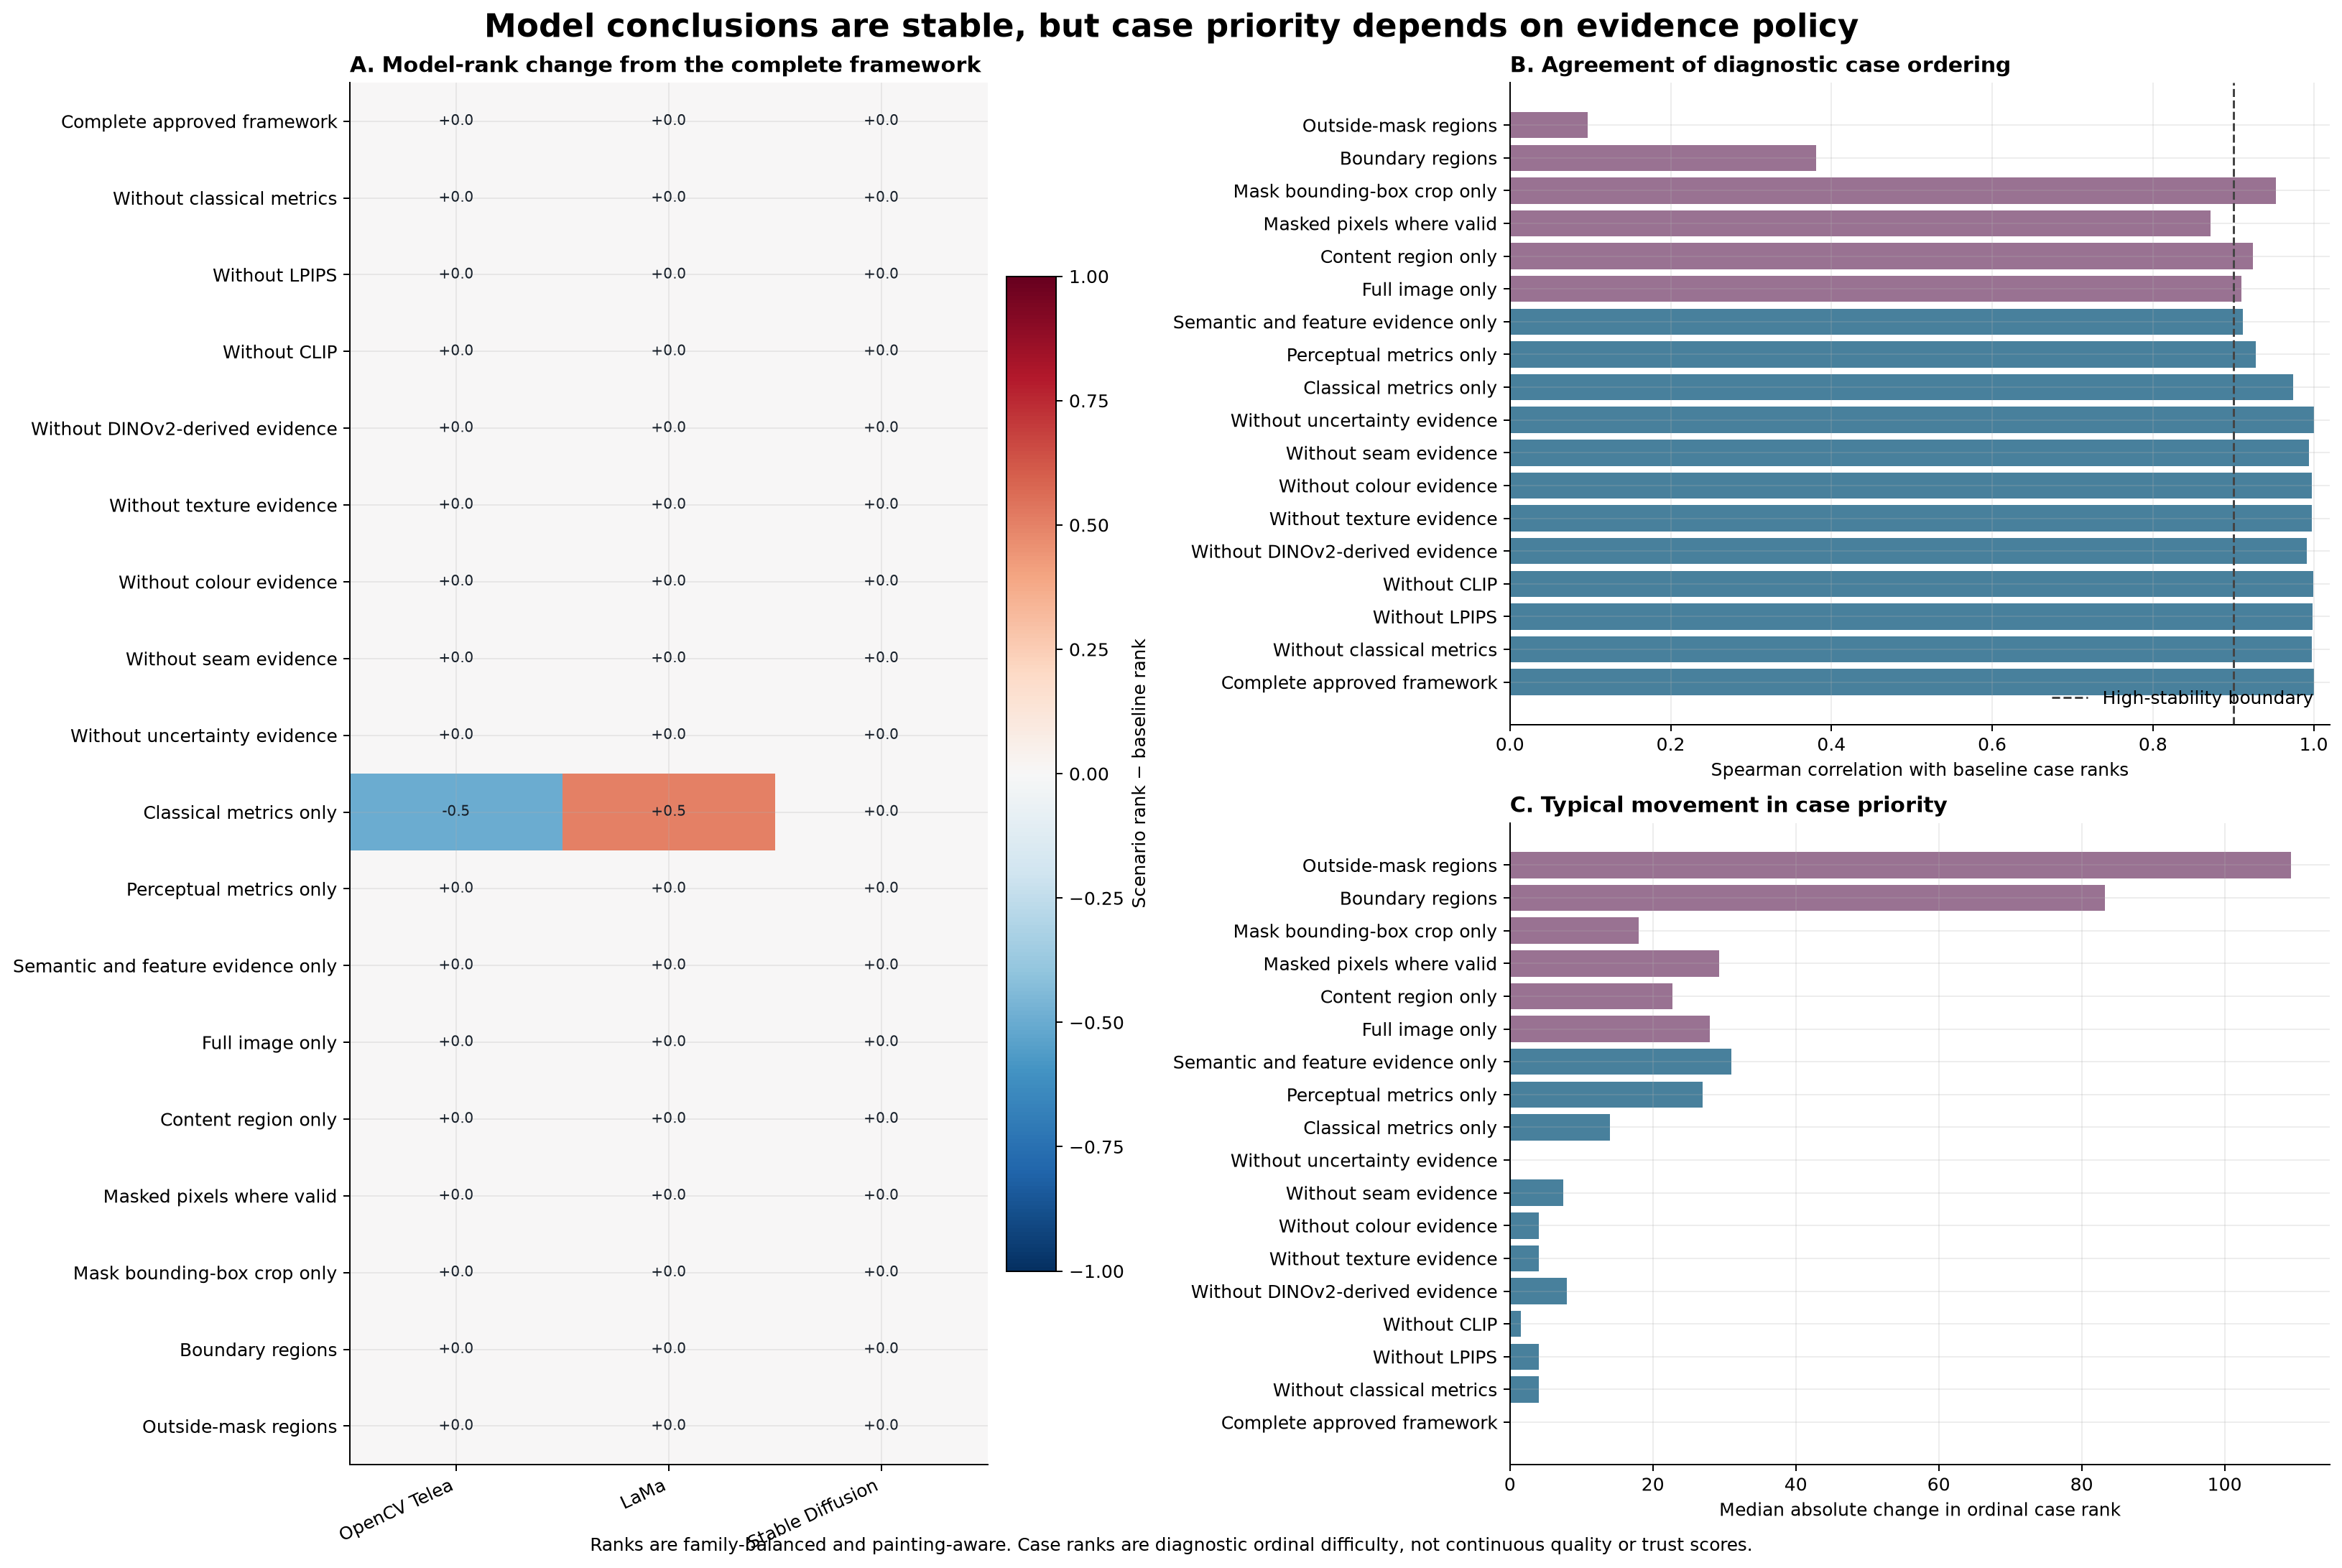

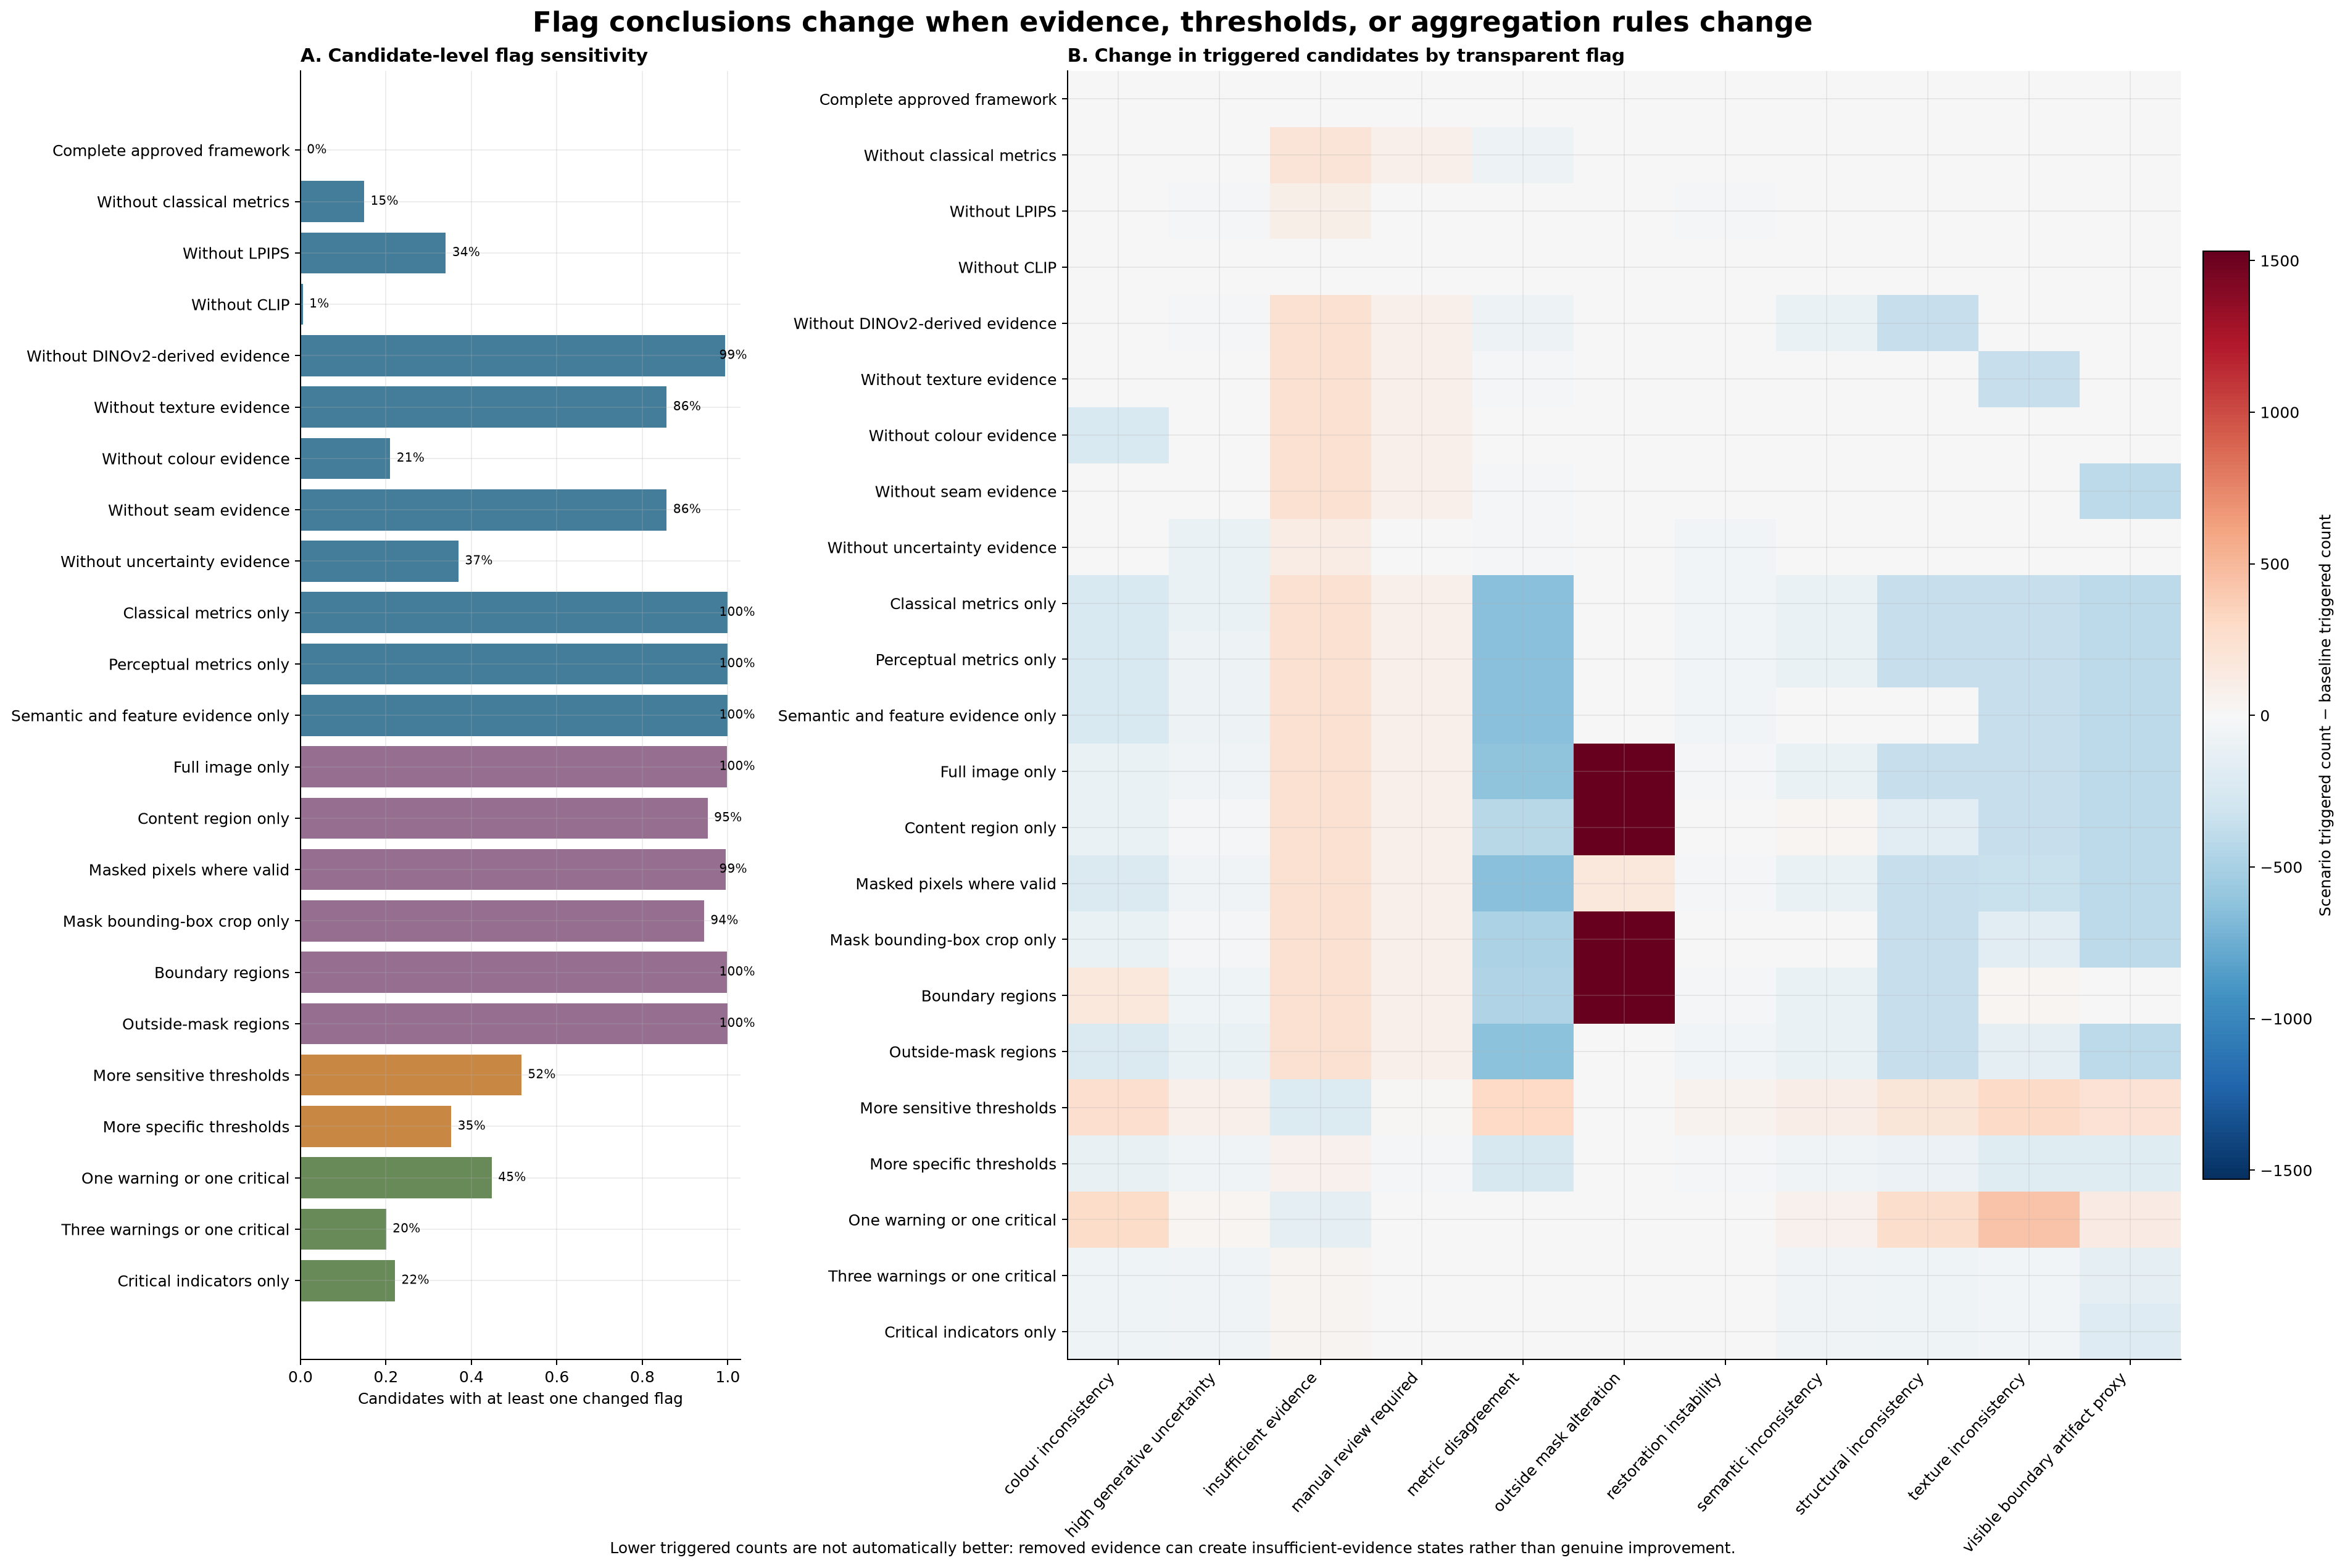

Canonical ablation figures generated.
Ranking figure: 3260 × 2183
Flag figure: 3800 × 2541


In [38]:
from matplotlib.colors import TwoSlopeNorm
from PIL import Image as PILImage


SCENARIO_COLOURS = {
    "metric": "#2f6f8f",
    "region": "#8b5e83",
    "threshold": "#c47a30",
    "aggregation": "#567d46",
}

MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
}

MODEL_ORDER = [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
]

ranking_plot_rows = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "ranking_applicable"
        ].astype(bool)
    ]
    .sort_values(
        "scenario_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

ranking_scenario_ids = (
    ranking_plot_rows[
        "scenario_id"
    ].astype(str).tolist()
)

ranking_labels = (
    ranking_plot_rows[
        "display_name"
    ].astype(str).tolist()
)

model_rank_change_matrix = (
    MODEL_RANK_RESULTS.pivot(
        index="scenario_id",
        columns="model_id",
        values="rank_change",
    )
    .reindex(
        index=ranking_scenario_ids,
        columns=MODEL_ORDER,
    )
    .astype(float)
)

figure = plt.figure(
    figsize=(18, 12),
    constrained_layout=True,
)

grid = figure.add_gridspec(
    2,
    2,
    width_ratios=[
        1.05,
        1.35,
    ],
)

model_axis = figure.add_subplot(
    grid[:, 0]
)

case_correlation_axis = (
    figure.add_subplot(
        grid[0, 1]
    )
)

case_change_axis = figure.add_subplot(
    grid[1, 1],
    sharey=case_correlation_axis,
)

rank_image = model_axis.imshow(
    model_rank_change_matrix.to_numpy(),
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-1.0,
        vcenter=0.0,
        vmax=1.0,
    ),
    aspect="auto",
)

model_axis.set_xticks(
    np.arange(len(MODEL_ORDER))
)

model_axis.set_xticklabels(
    [
        MODEL_LABELS[model_id]
        for model_id in MODEL_ORDER
    ],
    rotation=25,
    ha="right",
)

model_axis.set_yticks(
    np.arange(len(ranking_labels))
)

model_axis.set_yticklabels(
    ranking_labels,
)

model_axis.set_title(
    "A. Model-rank change from the complete framework",
    loc="left",
    weight="bold",
)

for row_index in range(
    model_rank_change_matrix.shape[0]
):
    for column_index in range(
        model_rank_change_matrix.shape[1]
    ):
        value = float(
            model_rank_change_matrix.iloc[
                row_index,
                column_index,
            ]
        )

        model_axis.text(
            column_index,
            row_index,
            f"{value:+.1f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if abs(value) >= 0.65
                else "#17202a"
            ),
        )

model_colourbar = figure.colorbar(
    rank_image,
    ax=model_axis,
    shrink=0.72,
    pad=0.03,
)

model_colourbar.set_label(
    "Scenario rank − baseline rank"
)

y_positions = np.arange(
    len(ranking_plot_rows)
)

ranking_bar_colours = [
    SCENARIO_COLOURS[
        str(scenario_family)
    ]
    for scenario_family
    in ranking_plot_rows[
        "scenario_family"
    ]
]

case_correlations = pd.to_numeric(
    ranking_plot_rows[
        "case_rank_spearman_rho"
    ],
    errors="coerce",
)

case_correlation_axis.barh(
    y_positions,
    case_correlations,
    color=ranking_bar_colours,
    alpha=0.88,
)

case_correlation_axis.axvline(
    0.90,
    color="#444444",
    linestyle="--",
    linewidth=1.2,
    label="High-stability boundary",
)

case_correlation_axis.set_xlim(
    0,
    1.02,
)

case_correlation_axis.set_yticks(
    y_positions
)

case_correlation_axis.set_yticklabels(
    ranking_labels,
)

case_correlation_axis.invert_yaxis()

case_correlation_axis.set_xlabel(
    "Spearman correlation with baseline case ranks"
)

case_correlation_axis.set_title(
    "B. Agreement of diagnostic case ordering",
    loc="left",
    weight="bold",
)

case_correlation_axis.legend(
    frameon=False,
    loc="lower right",
)

median_case_changes = pd.to_numeric(
    ranking_plot_rows[
        "median_absolute_case_rank_change"
    ],
    errors="coerce",
)

case_change_axis.barh(
    y_positions,
    median_case_changes,
    color=ranking_bar_colours,
    alpha=0.88,
)

case_change_axis.set_yticks(
    y_positions
)

case_change_axis.set_yticklabels(
    ranking_labels,
)

case_change_axis.invert_yaxis()

case_change_axis.set_xlabel(
    "Median absolute change in ordinal case rank"
)

case_change_axis.set_title(
    "C. Typical movement in case priority",
    loc="left",
    weight="bold",
)

figure.suptitle(
    "Model conclusions are stable, but case priority depends on evidence policy",
    fontsize=18,
    weight="bold",
)

figure.text(
    0.5,
    0.005,
    (
        "Ranks are family-balanced and painting-aware. "
        "Case ranks are diagnostic ordinal difficulty, "
        "not continuous quality or trust scores."
    ),
    ha="center",
    fontsize=10,
)

figure.savefig(
    OUTPUT_PATHS[
        "ablation_ranking_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.close(figure)

all_scenario_rows = (
    SCENARIO_ANALYSIS.sort_values(
        "scenario_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

all_scenario_ids = (
    all_scenario_rows[
        "scenario_id"
    ].astype(str).tolist()
)

all_scenario_labels = (
    all_scenario_rows[
        "display_name"
    ].astype(str).tolist()
)

FLAG_ORDER = sorted(
    SCENARIO_FLAG_SUMMARY[
        "flag_id"
    ].astype(str).unique()
)

flag_delta_matrix = (
    FLAG_SUMMARY_RESULTS.pivot(
        index="scenario_id",
        columns="flag_id",
        values="absolute_change",
    )
    .reindex(
        index=all_scenario_ids,
        columns=FLAG_ORDER,
    )
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .fillna(0.0)
)

flag_limit = float(
    np.abs(
        flag_delta_matrix.to_numpy(
            dtype=float
        )
    ).max()
)

flag_limit = max(
    flag_limit,
    1.0,
)

flag_figure = plt.figure(
    figsize=(21, 14),
    constrained_layout=True,
)

flag_grid = flag_figure.add_gridspec(
    1,
    2,
    width_ratios=[
        0.85,
        2.15,
    ],
)

candidate_axis = flag_figure.add_subplot(
    flag_grid[0, 0]
)

flag_axis = flag_figure.add_subplot(
    flag_grid[0, 1]
)

scenario_colours = [
    SCENARIO_COLOURS[
        str(scenario_family)
    ]
    for scenario_family
    in all_scenario_rows[
        "scenario_family"
    ]
]

changed_fractions = pd.to_numeric(
    all_scenario_rows[
        "changed_candidate_fraction"
    ],
    errors="coerce",
)

scenario_positions = np.arange(
    len(all_scenario_rows)
)

candidate_axis.barh(
    scenario_positions,
    changed_fractions,
    color=scenario_colours,
    alpha=0.9,
)

candidate_axis.set_yticks(
    scenario_positions
)

candidate_axis.set_yticklabels(
    all_scenario_labels,
)

candidate_axis.invert_yaxis()

candidate_axis.set_xlim(
    0,
    1.03,
)

candidate_axis.set_xlabel(
    "Candidates with at least one changed flag"
)

candidate_axis.set_title(
    "A. Candidate-level flag sensitivity",
    loc="left",
    weight="bold",
)

for position, value in zip(
    scenario_positions,
    changed_fractions,
):
    candidate_axis.text(
        min(float(value) + 0.015, 0.98),
        position,
        f"{float(value):.0%}",
        va="center",
        fontsize=8,
    )

flag_image = flag_axis.imshow(
    flag_delta_matrix.to_numpy(
        dtype=float
    ),
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-flag_limit,
        vcenter=0.0,
        vmax=flag_limit,
    ),
    aspect="auto",
)

flag_axis.set_yticks(
    scenario_positions
)

flag_axis.set_yticklabels(
    all_scenario_labels,
)

flag_axis.set_xticks(
    np.arange(len(FLAG_ORDER))
)

flag_axis.set_xticklabels(
    [
        flag_id.replace(
            "_",
            " ",
        )
        for flag_id in FLAG_ORDER
    ],
    rotation=48,
    ha="right",
)

flag_axis.set_title(
    "B. Change in triggered candidates by transparent flag",
    loc="left",
    weight="bold",
)

flag_colourbar = flag_figure.colorbar(
    flag_image,
    ax=flag_axis,
    shrink=0.72,
    pad=0.02,
)

flag_colourbar.set_label(
    "Scenario triggered count − baseline triggered count"
)

flag_figure.suptitle(
    "Flag conclusions change when evidence, thresholds, or aggregation rules change",
    fontsize=18,
    weight="bold",
)

flag_figure.text(
    0.5,
    0.005,
    (
        "Lower triggered counts are not automatically better: "
        "removed evidence can create insufficient-evidence states "
        "rather than genuine improvement."
    ),
    ha="center",
    fontsize=10,
)

flag_figure.savefig(
    OUTPUT_PATHS[
        "ablation_flag_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.close(flag_figure)

RANKING_FIGURE_IMAGE = PILImage.open(
    OUTPUT_PATHS[
        "ablation_ranking_figure"
    ]
)

FLAG_FIGURE_IMAGE = PILImage.open(
    OUTPUT_PATHS[
        "ablation_flag_figure"
    ]
)

display(RANKING_FIGURE_IMAGE)
display(FLAG_FIGURE_IMAGE)

print("Canonical ablation figures generated.")
print(
    "Ranking figure: "
    f"{RANKING_FIGURE_IMAGE.size[0]} × "
    f"{RANKING_FIGURE_IMAGE.size[1]}"
)
print(
    "Flag figure: "
    f"{FLAG_FIGURE_IMAGE.size[0]} × "
    f"{FLAG_FIGURE_IMAGE.size[1]}"
)

In [39]:
figure_validation_records = []

for figure_name, figure_path in (
    (
        "ablation_ranking_changes",
        OUTPUT_PATHS[
            "ablation_ranking_figure"
        ],
    ),
    (
        "ablation_flag_changes",
        OUTPUT_PATHS[
            "ablation_flag_figure"
        ],
    ),
):
    with PILImage.open(
        figure_path
    ) as image:
        image.verify()

    with PILImage.open(
        figure_path
    ) as image:
        figure_validation_records.append(
            {
                "figure": figure_name,
                "path": (
                    figure_path.relative_to(
                        PROJECT_ROOT
                    ).as_posix()
                ),
                "format": image.format,
                "mode": image.mode,
                "width": image.width,
                "height": image.height,
                "size_bytes": (
                    figure_path.stat().st_size
                ),
            }
        )

FIGURE_VALIDATION = pd.DataFrame(
    figure_validation_records
)

ranking_scenario_conclusions = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "ranking_applicable"
        ].astype(bool)
    ]
)

outside_case_row = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "scenario_id"
        ].astype(str).eq(
            "outside_mask_only"
        )
    ]
)

boundary_case_row = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "scenario_id"
        ].astype(str).eq(
            "boundary_regions"
        )
    ]
)

only_classical_row = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "scenario_id"
        ].astype(str).eq(
            "only_classical"
        )
    ]
)

canonical_files_after_batch_8 = sorted(
    path.relative_to(
        OUTPUT_ROOT
    ).as_posix()
    for path in CANONICAL_OUTPUT_PATHS
    if path.is_file()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="scenario_analysis_complete",
    description=(
        "The analysis summary contains one row "
        "for every approved ablation scenario."
    ),
    expected={
        "rows": 23,
        "families": 4,
    },
    observed={
        "rows": len(
            SCENARIO_ANALYSIS
        ),
        "families": (
            SCENARIO_ANALYSIS[
                "scenario_family"
            ].nunique()
        ),
    },
    passed=(
        len(
            SCENARIO_ANALYSIS
        )
        == 23
        and SCENARIO_ANALYSIS[
            "scenario_family"
        ].nunique()
        == 4
        and SCENARIO_ANALYSIS[
            "status"
        ].eq("ok").all()
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="model_conclusion_stability",
    description=(
        "LaMa remains a winner under every "
        "ranking-applicable scenario."
    ),
    expected={
        "ranking_scenarios": 18,
        "winner_retained": 18,
    },
    observed={
        "ranking_scenarios": len(
            ranking_scenario_conclusions
        ),
        "winner_retained": int(
            ranking_scenario_conclusions[
                "winner_retained"
            ].astype(str).str.lower().eq(
                "true"
            ).sum()
        ),
    },
    passed=(
        len(
            ranking_scenario_conclusions
        )
        == 18
        and ranking_scenario_conclusions[
            "winner_retained"
        ].astype(str).str.lower().eq(
            "true"
        ).all()
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="classical_only_tie_preserved",
    description=(
        "The classical-only scenario transparently "
        "retains the LaMa–Telea tie."
    ),
    expected="lama|opencv_telea",
    observed=(
        str(
            only_classical_row[
                "scenario_winner_id"
            ].iloc[0]
        )
        if len(
            only_classical_row
        )
        == 1
        else None
    ),
    passed=(
        len(
            only_classical_row
        )
        == 1
        and str(
            only_classical_row[
                "scenario_winner_id"
            ].iloc[0]
        )
        == "lama|opencv_telea"
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="case_region_sensitivity_visible",
    description=(
        "Boundary-only and outside-mask-only "
        "policies expose substantial case-order changes."
    ),
    expected={
        "outside_rho_below": 0.20,
        "boundary_rho_below": 0.50,
    },
    observed={
        "outside_rho": (
            float(
                outside_case_row[
                    "case_rank_spearman_rho"
                ].iloc[0]
            )
            if len(
                outside_case_row
            )
            == 1
            else None
        ),
        "boundary_rho": (
            float(
                boundary_case_row[
                    "case_rank_spearman_rho"
                ].iloc[0]
            )
            if len(
                boundary_case_row
            )
            == 1
            else None
        ),
    },
    passed=(
        len(outside_case_row) == 1
        and len(boundary_case_row) == 1
        and float(
            outside_case_row[
                "case_rank_spearman_rho"
            ].iloc[0]
        )
        < 0.20
        and float(
            boundary_case_row[
                "case_rank_spearman_rho"
            ].iloc[0]
        )
        < 0.50
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="subgroup_dimensions_supported",
    description=(
        "All six approved descriptive subgroup "
        "dimensions are represented after the "
        "five-painting gate."
    ),
    expected=sorted(
        subgroup_dimensions
    ),
    observed=sorted(
        SUBGROUP_STABILITY_SUMMARY[
            "subgroup_dimension"
        ].astype(str).unique()
    ),
    passed=(
        set(
            SUBGROUP_STABILITY_SUMMARY[
                "subgroup_dimension"
            ].astype(str)
        )
        == set(subgroup_dimensions)
        and SUBGROUP_STABILITY_SUMMARY[
            "paintings"
        ].ge(
            int(
                SUBGROUP_POLICY[
                    "minimum_independent_paintings"
                ]
            )
        ).all()
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="category_confounding_retained",
    description=(
        "Painting-category summaries remain explicitly "
        "labelled as controlled and painting-confounded."
    ),
    expected=True,
    observed=sorted(
        SUBGROUP_STABILITY_SUMMARY.loc[
            SUBGROUP_STABILITY_SUMMARY[
                "subgroup_dimension"
            ].eq(
                "painting_category"
            ),
            "interpretation_status",
        ].astype(str).unique()
    ),
    passed=(
        SUBGROUP_STABILITY_SUMMARY.loc[
            SUBGROUP_STABILITY_SUMMARY[
                "subgroup_dimension"
            ].eq(
                "painting_category"
            ),
            "interpretation_status",
        ].astype(str).eq(
            "controlled_descriptive_category_painting_confounding"
        ).all()
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="canonical_figures_valid",
    description=(
        "Both canonical analytical figures are "
        "valid non-trivial PNG images."
    ),
    expected={
        "figures": 2,
        "format": "PNG",
        "minimum_dimension": 1000,
    },
    observed=(
        FIGURE_VALIDATION.to_dict(
            orient="records"
        )
    ),
    passed=(
        len(
            FIGURE_VALIDATION
        )
        == 2
        and FIGURE_VALIDATION[
            "format"
        ].eq("PNG").all()
        and FIGURE_VALIDATION[
            "width"
        ].ge(1000).all()
        and FIGURE_VALIDATION[
            "height"
        ].ge(1000).all()
        and FIGURE_VALIDATION[
            "size_bytes"
        ].gt(100000).all()
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="canonical_write_scope",
    description=(
        "Batch 8 adds only the two canonical figures; "
        "the report and manifests remain pending."
    ),
    expected=[
        "figures/ablation_flag_changes.png",
        "figures/ablation_ranking_changes.png",
        "metrics/ablation_results.csv",
        "metrics/flag_stability.csv",
    ],
    observed=(
        canonical_files_after_batch_8
    ),
    passed=(
        canonical_files_after_batch_8
        == [
            "figures/ablation_flag_changes.png",
            "figures/ablation_ranking_changes.png",
            "metrics/ablation_results.csv",
            "metrics/flag_stability.csv",
        ]
    ),
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(BATCH_8_STAGE)
    ]
    .reset_index(drop=True)
)

display(FIGURE_VALIDATION)
display(BATCH_8_VALIDATION)

VALIDATION.raise_for_blocking()

print("Batch 8 analysis and figures passed.")
print(
    "Validation checks: "
    f"{len(BATCH_8_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_8_VALIDATION['passed']).sum()):,}"
)
print(
    "Supported subgroup rows: "
    f"{len(SUBGROUP_STABILITY_SUMMARY):,}"
)
print(
    "Canonical figures written: 2/2"
)
print(
    "Canonical files written: "
    f"{len(canonical_files_after_batch_8):,}/8"
)
print(
    "Next: self-contained report generation "
    "using the approved mock structure."
)

,figure,path,format,mode,width,height,size_bytes
0,ablation_ranking_changes,outputs/28_metric_and_region_policy_ablation/figures/ablation_ranking_changes.png,PNG,RGBA,3260,2183,516007
1,ablation_flag_changes,outputs/28_metric_and_region_policy_ablation/figures/ablation_flag_changes.png,PNG,RGBA,3800,2541,547320


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_analysis_and_figures,scenario_analysis_complete,The analysis summary contains one row for every approved ablation scenario.,blocking,"{""families"": 4, ""rows"": 23}","{""families"": 4, ""rows"": 23}",True,
1,batch_8_analysis_and_figures,model_conclusion_stability,LaMa remains a winner under every ranking-applicable scenario.,blocking,"{""ranking_scenarios"": 18, ""winner_retained"": 18}","{""ranking_scenarios"": 18, ""winner_retained"": 18}",True,
2,batch_8_analysis_and_figures,classical_only_tie_preserved,The classical-only scenario transparently retains the LaMa–Telea tie.,blocking,lama|opencv_telea,lama|opencv_telea,True,
3,batch_8_analysis_and_figures,case_region_sensitivity_visible,Boundary-only and outside-mask-only policies expose substantial case-order changes.,blocking,"{""boundary_rho_below"": 0.5, ""outside_rho_below"": 0.2}","{""boundary_rho"": 0.3812851477206887, ""outside_rho"": 0.09712245157966425}",True,
4,batch_8_analysis_and_figures,subgroup_dimensions_supported,All six approved descriptive subgroup dimensions are represented after the five-painting gate.,blocking,"[""damage_fraction"", ""damage_or_degradation_type"", ""experiment"", ""painting_category"", ""prompt_arm"", ""seed_coverage_role""]","[""damage_fraction"", ""damage_or_degradation_type"", ""experiment"", ""painting_category"", ""prompt_arm"", ""seed_coverage_role""]",True,
5,batch_8_analysis_and_figures,category_confounding_retained,Painting-category summaries remain explicitly labelled as controlled and painting-confounded.,blocking,True,"[""controlled_descriptive_category_painting_confounding""]",True,
6,batch_8_analysis_and_figures,canonical_figures_valid,Both canonical analytical figures are valid non-trivial PNG images.,blocking,"{""figures"": 2, ""format"": ""PNG"", ""minimum_dimension"": 1000}","[{""figure"": ""ablation_ranking_changes"", ""format"": ""PNG"", ""height"": 2183, ""mode"": ""RGBA"", ""path"": ""outputs/28_metric_and_region_policy_ablation/figures/ablation_ranking_changes....",True,
7,batch_8_analysis_and_figures,canonical_write_scope,Batch 8 adds only the two canonical figures; the report and manifests remain pending.,blocking,"[""figures/ablation_flag_changes.png"", ""figures/ablation_ranking_changes.png"", ""metrics/ablation_results.csv"", ""metrics/flag_stability.csv""]","[""figures/ablation_flag_changes.png"", ""figures/ablation_ranking_changes.png"", ""metrics/ablation_results.csv"", ""metrics/flag_stability.csv""]",True,


Batch 8 analysis and figures passed.
Validation checks: 8
Blocking failures: 0
Supported subgroup rows: 759
Canonical figures written: 2/2
Canonical files written: 4/8
Next: self-contained report generation using the approved mock structure.


## Batch 9 — Self-contained ablation report

Generate the approved twelve-section standalone HTML report.

The report preserves the approved mock structure while replacing planning examples with validated results. It embeds:

- both canonical figures;
- three additional presentation-only analytical views;
- six reproducibly selected diagnostic panels;
- eighteen restoration tiles.

All visual content is embedded as data URIs. The report has no external image dependency.

In [41]:
import base64
import io
import os
import time
from html import escape


BATCH_9_STAGE = (
    "batch_9_report_generation"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_9_STAGE,
)

REPORT_SECTION_IDS = list(
    map(
        str,
        REPORT_POLICY[
            "required_section_ids"
        ],
    )
)

REPORT_SECTION_TITLES = {
    "executive_findings": (
        "Executive findings"
    ),
    "what_was_tested": (
        "What was tested"
    ),
    "baseline_framework": (
        "The complete evaluation framework"
    ),
    "metric_family_ablation": (
        "Metric-family ablation"
    ),
    "region_policy_ablation": (
        "Region-policy ablation"
    ),
    "threshold_sensitivity": (
        "Threshold sensitivity"
    ),
    "aggregation_sensitivity": (
        "Aggregation-rule sensitivity"
    ),
    "flag_stability": (
        "Flag stability"
    ),
    "model_and_case_rank_stability": (
        "Model and case-rank stability"
    ),
    "subgroup_stability": (
        "Subgroup stability"
    ),
    "visual_policy_sensitive_atlas": (
        "Visual policy-sensitive atlas"
    ),
    "thesis_synthesis_limits_provenance": (
        "Thesis synthesis, limits, and provenance"
    ),
}

MOCK_TO_FINAL_TRACEABILITY = pd.DataFrame(
    [
        {
            "section_order": index,
            "section_id": section_id,
            "approved_mock_section": (
                REPORT_SECTION_TITLES[
                    section_id
                ]
            ),
            "final_status": (
                "upgraded_additively"
            ),
            "evidence_source": {
                "executive_findings": (
                    "validated scenario summaries"
                ),
                "what_was_tested": (
                    "scenario and population contracts"
                ),
                "baseline_framework": (
                    "N26 baseline and N27 flags"
                ),
                "metric_family_ablation": (
                    "metric-scenario ablation results"
                ),
                "region_policy_ablation": (
                    "N08 region policy and ablation results"
                ),
                "threshold_sensitivity": (
                    "threshold-scenario flag stability"
                ),
                "aggregation_sensitivity": (
                    "aggregation-scenario flag stability"
                ),
                "flag_stability": (
                    "canonical flag_stability.csv"
                ),
                "model_and_case_rank_stability": (
                    "canonical model and case ranks"
                ),
                "subgroup_stability": (
                    "validated subgroup summaries"
                ),
                "visual_policy_sensitive_atlas": (
                    "N21 deterministic representative cases"
                ),
                "thesis_synthesis_limits_provenance": (
                    "canonical artifacts and governing scope"
                ),
            }[section_id],
            "deviation_reason": "",
        }
        for index, section_id
        in enumerate(
            REPORT_SECTION_IDS,
            start=1,
        )
    ]
)

SELECTED_DIAGNOSTIC_SLOTS = [
    "slot_01_consensus_success",
    "slot_02_consensus_failure",
    (
        "slot_03_"
        "classical_perceptual_disagreement"
    ),
    (
        "slot_05_"
        "texture_seam_disagreement"
    ),
    "slot_07_high_sd_uncertainty",
    (
        "slot_09_"
        "scratch_thin_deterministic_advantage"
    ),
]

REPORT_DIAGNOSTIC_SELECTION = (
    REPRESENTATIVE_CASES.loc[
        REPRESENTATIVE_CASES[
            "selection_slot_id"
        ].astype(str).isin(
            SELECTED_DIAGNOSTIC_SLOTS
        )
        & REPRESENTATIVE_CASES[
            "model_id"
        ].astype(str).isin(
            MODEL_ORDER
        )
    ]
    .copy()
)

REPORT_DIAGNOSTIC_SELECTION[
    "_slot_order"
] = (
    REPORT_DIAGNOSTIC_SELECTION[
        "selection_slot_id"
    ].map(
        {
            slot_id: index
            for index, slot_id
            in enumerate(
                SELECTED_DIAGNOSTIC_SLOTS,
                start=1,
            )
        }
    )
)

REPORT_DIAGNOSTIC_SELECTION[
    "_model_order"
] = (
    REPORT_DIAGNOSTIC_SELECTION[
        "model_id"
    ].map(
        {
            model_id: index
            for index, model_id
            in enumerate(
                MODEL_ORDER,
                start=1,
            )
        }
    )
)

REPORT_DIAGNOSTIC_SELECTION = (
    REPORT_DIAGNOSTIC_SELECTION.sort_values(
        [
            "_slot_order",
            "_model_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

diagnostic_slot_counts = (
    REPORT_DIAGNOSTIC_SELECTION.groupby(
        "selection_slot_id"
    )["model_id"]
    .nunique()
)

if (
    len(
        REPORT_DIAGNOSTIC_SELECTION
    )
    != 18
    or len(
        diagnostic_slot_counts
    )
    != 6
    or not diagnostic_slot_counts.eq(3).all()
):
    raise RuntimeError(
        "The report atlas must contain exactly "
        "six panels and three core-model tiles "
        "per panel."
    )

missing_diagnostic_paths = []

for restored_path in (
    REPORT_DIAGNOSTIC_SELECTION[
        "restored_path"
    ].astype(str)
):
    resolved_path = (
        PROJECT_ROOT / restored_path
    )

    if not resolved_path.is_file():
        missing_diagnostic_paths.append(
            restored_path
        )

if missing_diagnostic_paths:
    raise FileNotFoundError(
        "Missing report diagnostic images: "
        f"{missing_diagnostic_paths[:5]}"
    )


def file_data_uri(
    path: Path,
    mime_type: str,
) -> str:
    """Embed a complete file as a data URI."""

    encoded = base64.b64encode(
        path.read_bytes()
    ).decode("ascii")

    return (
        f"data:{mime_type};base64,"
        f"{encoded}"
    )


def web_image_data_uri(
    path: Path,
    *,
    maximum_width: int = 720,
    quality: int = 84,
) -> str:
    """Create an in-memory web-sized JPEG data URI."""

    with PILImage.open(path) as image:
        image = image.convert("RGB")

        if image.width > maximum_width:
            ratio = (
                maximum_width
                / image.width
            )

            image = image.resize(
                (
                    maximum_width,
                    max(
                        1,
                        int(
                            image.height
                            * ratio
                        ),
                    ),
                ),
                PILImage.Resampling.LANCZOS,
            )

        buffer = io.BytesIO()

        image.save(
            buffer,
            format="JPEG",
            quality=quality,
            optimize=True,
            progressive=True,
        )

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return (
        "data:image/jpeg;base64,"
        f"{encoded}"
    )


def figure_data_uri(
    figure,
    *,
    dpi: int = 150,
) -> str:
    """Encode an in-memory analytical figure."""

    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(figure)

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return (
        "data:image/png;base64,"
        f"{encoded}"
    )


def formatted_report_table(
    frame: pd.DataFrame,
    *,
    maximum_rows: int = 30,
) -> str:
    """Render a compact escaped report table."""

    displayed = frame.head(
        maximum_rows
    ).copy()

    return displayed.to_html(
        index=False,
        escape=True,
        border=0,
        classes=[
            "report-table",
        ],
    )


def analytical_view(
    *,
    view_id: str,
    title: str,
    image_uri: str,
    caption: str,
) -> str:
    """Render one traceable analytical view."""

    return f"""
    <figure
      class="visual"
      data-analytical-view="{escape(view_id)}"
    >
      <h3>{escape(title)}</h3>
      <img
        src="{image_uri}"
        alt="{escape(title)}"
      />
      <figcaption>
        {escape(caption)}
      </figcaption>
    </figure>
    """


def conclusion_box(text: str) -> str:
    """Render a direct evidence-to-assertion conclusion."""

    return f"""
    <div class="conclusion">
      <strong>Conclusion.</strong>
      {escape(text)}
    </div>
    """


def limitation_box(text: str) -> str:
    """Render a nearby scientific limitation."""

    return f"""
    <div class="limitation">
      <strong>Limit.</strong>
      {escape(text)}
    </div>
    """


CANONICAL_RANKING_FIGURE_URI = (
    file_data_uri(
        OUTPUT_PATHS[
            "ablation_ranking_figure"
        ],
        "image/png",
    )
)

CANONICAL_FLAG_FIGURE_URI = (
    file_data_uri(
        OUTPUT_PATHS[
            "ablation_flag_figure"
        ],
        "image/png",
    )
)

DIAGNOSTIC_IMAGE_URIS = {
    restored_path: web_image_data_uri(
        PROJECT_ROOT / restored_path
    )
    for restored_path
    in REPORT_DIAGNOSTIC_SELECTION[
        "restored_path"
    ].astype(str).unique()
}

print("Report assets and mock traceability prepared.")
print(
    "Approved report sections: "
    f"{len(MOCK_TO_FINAL_TRACEABILITY):,}"
)
print(
    "Diagnostic panels: "
    f"{REPORT_DIAGNOSTIC_SELECTION['selection_slot_id'].nunique():,}"
)
print(
    "Diagnostic restoration tiles: "
    f"{len(REPORT_DIAGNOSTIC_SELECTION):,}"
)
print(
    "Missing diagnostic images: "
    f"{len(missing_diagnostic_paths):,}"
)

Report assets and mock traceability prepared.
Approved report sections: 12
Diagnostic panels: 6
Diagnostic restoration tiles: 18
Missing diagnostic images: 0


In [42]:
presentation_scenarios = (
    SCENARIO_ANALYSIS.sort_values(
        "scenario_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

presentation_labels = (
    presentation_scenarios[
        "display_name"
    ].astype(str).tolist()
)

presentation_positions = np.arange(
    len(presentation_scenarios)
)

presentation_colours = [
    SCENARIO_COLOURS[
        str(scenario_family)
    ]
    for scenario_family
    in presentation_scenarios[
        "scenario_family"
    ]
]

trigger_delta_figure, trigger_delta_axis = (
    plt.subplots(
        figsize=(11, 8),
    )
)

trigger_deltas = pd.to_numeric(
    presentation_scenarios[
        "triggered_flag_delta"
    ],
    errors="coerce",
)

trigger_delta_axis.barh(
    presentation_positions,
    trigger_deltas,
    color=presentation_colours,
    alpha=0.9,
)

trigger_delta_axis.axvline(
    0,
    color="#333333",
    linewidth=1.1,
)

trigger_delta_axis.set_yticks(
    presentation_positions
)

trigger_delta_axis.set_yticklabels(
    presentation_labels,
)

trigger_delta_axis.invert_yaxis()

trigger_delta_axis.set_xlabel(
    "Change in triggered flag rows from baseline"
)

trigger_delta_axis.set_title(
    "Triggered flags can rise or fall under policy changes",
    weight="bold",
)

trigger_delta_figure.tight_layout()

TRIGGER_DELTA_VIEW_URI = (
    figure_data_uri(
        trigger_delta_figure
    )
)

ranking_scatter_rows = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "ranking_applicable"
        ].astype(bool)
    ]
    .copy()
)

ranking_scatter_figure, ranking_scatter_axis = (
    plt.subplots(
        figsize=(9.5, 6.5),
    )
)

for scenario_family, group in (
    ranking_scatter_rows.groupby(
        "scenario_family"
    )
):
    ranking_scatter_axis.scatter(
        pd.to_numeric(
            group[
                "case_rank_spearman_rho"
            ],
            errors="coerce",
        ),
        pd.to_numeric(
            group[
                "changed_candidate_fraction"
            ],
            errors="coerce",
        ),
        s=75,
        alpha=0.85,
        color=SCENARIO_COLOURS[
            str(scenario_family)
        ],
        label=str(
            scenario_family
        ).title(),
    )

for scenario_id in (
    "outside_mask_only",
    "boundary_regions",
    "only_classical",
    "without_clip",
):
    labelled_row = (
        ranking_scatter_rows.loc[
            ranking_scatter_rows[
                "scenario_id"
            ].astype(str).eq(
                scenario_id
            )
        ]
    )

    if len(labelled_row) == 1:
        ranking_scatter_axis.annotate(
            str(
                labelled_row[
                    "display_name"
                ].iloc[0]
            ),
            (
                float(
                    labelled_row[
                        "case_rank_spearman_rho"
                    ].iloc[0]
                ),
                float(
                    labelled_row[
                        "changed_candidate_fraction"
                    ].iloc[0]
                ),
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

ranking_scatter_axis.set_xlim(
    0,
    1.03,
)

ranking_scatter_axis.set_ylim(
    -0.03,
    1.05,
)

ranking_scatter_axis.set_xlabel(
    "Agreement with baseline case ordering"
)

ranking_scatter_axis.set_ylabel(
    "Candidates with at least one changed flag"
)

ranking_scatter_axis.set_title(
    "Stable model winners do not imply stable case decisions",
    weight="bold",
)

ranking_scatter_axis.legend(
    frameon=False,
)

ranking_scatter_figure.tight_layout()

RANKING_SCATTER_VIEW_URI = (
    figure_data_uri(
        ranking_scatter_figure
    )
)

CATEGORY_VIEW_SCENARIOS = [
    "without_dinov2",
    "boundary_regions",
    "more_sensitive_thresholds",
]

category_view_rows = (
    SUBGROUP_STABILITY_SUMMARY.loc[
        SUBGROUP_STABILITY_SUMMARY[
            "subgroup_dimension"
        ].astype(str).eq(
            "painting_category"
        )
        & SUBGROUP_STABILITY_SUMMARY[
            "scenario_id"
        ].astype(str).isin(
            CATEGORY_VIEW_SCENARIOS
        )
    ]
    .copy()
)

category_matrix = (
    category_view_rows.pivot(
        index="subgroup_value",
        columns="scenario_id",
        values="changed_candidate_fraction",
    )
    .reindex(
        columns=CATEGORY_VIEW_SCENARIOS
    )
)

category_figure, category_axis = (
    plt.subplots(
        figsize=(9.5, 5.7),
    )
)

category_image = category_axis.imshow(
    category_matrix.to_numpy(
        dtype=float
    ),
    cmap="viridis",
    vmin=0,
    vmax=1,
    aspect="auto",
)

category_axis.set_yticks(
    np.arange(len(category_matrix.index))
)

category_axis.set_yticklabels(
    [
        str(value).replace(
            "_",
            " ",
        )
        for value in category_matrix.index
    ]
)

category_axis.set_xticks(
    np.arange(
        len(
            category_matrix.columns
        )
    )
)

category_axis.set_xticklabels(
    [
        SCENARIO_CATALOG.set_index(
            "scenario_id"
        ).loc[
            scenario_id,
            "display_name",
        ]
        for scenario_id
        in category_matrix.columns
    ],
    rotation=25,
    ha="right",
)

for row_index in range(
    category_matrix.shape[0]
):
    for column_index in range(
        category_matrix.shape[1]
    ):
        value = float(
            category_matrix.iloc[
                row_index,
                column_index,
            ]
        )

        category_axis.text(
            column_index,
            row_index,
            f"{value:.0%}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if value < 0.35
                or value > 0.75
                else "#17202a"
            ),
        )

category_axis.set_title(
    "Policy sensitivity across controlled painting categories",
    weight="bold",
)

category_colourbar = (
    category_figure.colorbar(
        category_image,
        ax=category_axis,
        shrink=0.8,
    )
)

category_colourbar.set_label(
    "Candidates with at least one changed flag"
)

category_figure.tight_layout()

CATEGORY_VIEW_URI = figure_data_uri(
    category_figure
)

DIAGNOSTIC_PANEL_TITLES = {
    "slot_01_consensus_success": (
        "Consensus success"
    ),
    "slot_02_consensus_failure": (
        "Consensus failure"
    ),
    (
        "slot_03_"
        "classical_perceptual_disagreement"
    ): (
        "Classical–perceptual disagreement"
    ),
    (
        "slot_05_"
        "texture_seam_disagreement"
    ): (
        "Texture–seam disagreement"
    ),
    "slot_07_high_sd_uncertainty": (
        "High Stable Diffusion uncertainty"
    ),
    (
        "slot_09_"
        "scratch_thin_deterministic_advantage"
    ): (
        "Thin-scratch deterministic advantage"
    ),
}

diagnostic_panel_html_blocks = []

for panel_number, slot_id in enumerate(
    SELECTED_DIAGNOSTIC_SLOTS,
    start=1,
):
    panel_rows = (
        REPORT_DIAGNOSTIC_SELECTION.loc[
            REPORT_DIAGNOSTIC_SELECTION[
                "selection_slot_id"
            ].astype(str).eq(
                slot_id
            )
        ]
        .sort_values(
            "_model_order",
            kind="stable",
        )
    )

    first_row = panel_rows.iloc[0]

    tile_blocks = []

    for tile_number, row in enumerate(
        panel_rows.itertuples(
            index=False
        ),
        start=1,
    ):
        model_label = MODEL_LABELS[
            str(row.model_id)
        ]

        tile_blocks.append(
            f"""
            <article
              class="diagnostic-tile"
              data-diagnostic-tile="{panel_number}-{tile_number}"
            >
              <img
                src="{DIAGNOSTIC_IMAGE_URIS[str(row.restored_path)]}"
                alt="{escape(model_label)} restoration for {escape(str(row.case_id))}"
              />
              <h4>{escape(model_label)}</h4>
              <p>
                Candidate:
                <code>{escape(str(row.candidate_id))}</code>
              </p>
            </article>
            """
        )

    diagnostic_panel_html_blocks.append(
        f"""
        <section
          class="diagnostic-panel"
          data-diagnostic-panel="{escape(slot_id)}"
        >
          <div class="panel-heading">
            <h3>
              {panel_number}. {escape(DIAGNOSTIC_PANEL_TITLES[slot_id])}
            </h3>
            <p>
              Painting <strong>{escape(str(first_row['painting_id']))}</strong>;
              case <code>{escape(str(first_row['case_id']))}</code>;
              {escape(str(first_row['category']).replace('_', ' '))}.
            </p>
            <p class="selection-rule">
              Selection rule:
              {escape(str(first_row['selection_reason']))}
            </p>
          </div>
          <div class="diagnostic-grid">
            {''.join(tile_blocks)}
          </div>
        </section>
        """
    )

DIAGNOSTIC_ATLAS_HTML = "\n".join(
    diagnostic_panel_html_blocks
)

ANALYTICAL_VIEWS = {
    "canonical_ranking": analytical_view(
        view_id="canonical_ranking",
        title=(
            "Model and case-rank sensitivity"
        ),
        image_uri=(
            CANONICAL_RANKING_FIGURE_URI
        ),
        caption=(
            "Model ordering remains stable, while "
            "case ordering changes sharply under "
            "boundary-only and outside-mask policies."
        ),
    ),
    "canonical_flags": analytical_view(
        view_id="canonical_flags",
        title=(
            "Candidate and flag sensitivity"
        ),
        image_uri=(
            CANONICAL_FLAG_FIGURE_URI
        ),
        caption=(
            "Candidate-level flag states change under "
            "metric, region, threshold, and aggregation "
            "alternatives. Lower counts may reflect "
            "missing evidence."
        ),
    ),
    "trigger_delta": analytical_view(
        view_id="trigger_delta",
        title=(
            "Net change in triggered flag rows"
        ),
        image_uri=(
            TRIGGER_DELTA_VIEW_URI
        ),
        caption=(
            "Positive values mean more triggered flag "
            "rows; negative values require inspection "
            "of insufficient-evidence states."
        ),
    ),
    "ranking_scatter": analytical_view(
        view_id="ranking_scatter",
        title=(
            "Case-rank agreement versus flag stability"
        ),
        image_uri=(
            RANKING_SCATTER_VIEW_URI
        ),
        caption=(
            "A stable model winner does not guarantee "
            "stable case priorities or screening flags."
        ),
    ),
    "category_view": analytical_view(
        view_id="category_view",
        title=(
            "Controlled category sensitivity"
        ),
        image_uri=(
            CATEGORY_VIEW_URI
        ),
        caption=(
            "Each category contains a limited set of "
            "paintings. These are descriptive, "
            "category–painting-confounded comparisons."
        ),
    ),
}

print("Presentation-only report views prepared.")
print(
    "Analytical views: "
    f"{len(ANALYTICAL_VIEWS):,}"
)
print(
    "Diagnostic panels: "
    f"{len(diagnostic_panel_html_blocks):,}"
)
print(
    "Diagnostic tiles: "
    f"{len(REPORT_DIAGNOSTIC_SELECTION):,}"
)

Presentation-only report views prepared.
Analytical views: 5
Diagnostic panels: 6
Diagnostic tiles: 18


In [45]:
def scenario_report_table(
    scenario_family: str,
) -> pd.DataFrame:
    """Return a concise scenario-family report table."""

    selected = (
        SCENARIO_ANALYSIS.loc[
            SCENARIO_ANALYSIS[
                "scenario_family"
            ].astype(str).eq(
                scenario_family
            )
        ]
        .copy()
    )

    selected[
        "Changed candidates"
    ] = (
        pd.to_numeric(
            selected[
                "changed_candidate_fraction"
            ],
            errors="coerce",
        ).map(
            lambda value: (
                f"{float(value):.1%}"
            )
        )
    )

    selected[
        "Triggered-flag change"
    ] = pd.to_numeric(
        selected[
            "triggered_flag_delta"
        ],
        errors="coerce",
    ).map(
        lambda value: (
            f"{float(value):+,.0f}"
        )
    )

    selected[
        "Case-rank rho"
    ] = pd.to_numeric(
        selected[
            "case_rank_spearman_rho"
        ],
        errors="coerce",
    ).map(
        lambda value: (
            f"{float(value):.3f}"
            if pd.notna(value)
            else "Not applicable"
        )
    )

    selected[
        "Winner"
    ] = (
        selected[
            "scenario_winner_id"
        ]
        .fillna("Not applicable")
        .astype(str)
        .str.replace(
            "lama",
            "LaMa",
            regex=False,
        )
        .str.replace(
            "opencv_telea",
            "Telea",
            regex=False,
        )
        .str.replace(
            "stable_diffusion_inpainting",
            "Stable Diffusion",
            regex=False,
        )
        .str.replace(
            "|",
            " / ",
            regex=False,
        )
    )

    return selected[
        [
            "display_name",
            "Changed candidates",
            "Triggered-flag change",
            "Case-rank rho",
            "Winner",
        ]
    ].rename(
        columns={
            "display_name": "Scenario",
        }
    )


metric_report_table = (
    scenario_report_table("metric")
)

region_report_table = (
    scenario_report_table("region")
)

threshold_report_table = (
    scenario_report_table("threshold")
)

aggregation_report_table = (
    scenario_report_table(
        "aggregation"
    )
)

baseline_model_table = (
    MODEL_RANK_RESULTS.loc[
        MODEL_RANK_RESULTS[
            "scenario_id"
        ].astype(str).eq(
            BASELINE_SCENARIO_ID
        )
    ]
    [
        [
            "model_id",
            "scenario_rank",
            "available_family_count",
            "available_anchor_count",
        ]
    ]
    .copy()
)

baseline_model_table[
    "model_id"
] = baseline_model_table[
    "model_id"
].map(MODEL_LABELS)

baseline_model_table = (
    baseline_model_table.rename(
        columns={
            "model_id": "Model",
            "scenario_rank": "Baseline rank",
            "available_family_count": (
                "Evidence families"
            ),
            "available_anchor_count": (
                "Quality anchors"
            ),
        }
    )
    .sort_values(
        "Baseline rank",
        kind="stable",
    )
)

most_changed_flag_rows = (
    FLAG_SUMMARY_RESULTS.loc[
        pd.to_numeric(
            FLAG_SUMMARY_RESULTS[
                "changed_count"
            ],
            errors="coerce",
        ).gt(0)
    ]
    .assign(
        changed_fraction_display=lambda frame: (
            pd.to_numeric(
                frame[
                    "changed_fraction"
                ],
                errors="coerce",
            ).map(
                lambda value: (
                    f"{float(value):.1%}"
                )
            )
        ),
        triggered_change_display=lambda frame: (
            pd.to_numeric(
                frame[
                    "absolute_change"
                ],
                errors="coerce",
            ).map(
                lambda value: (
                    f"{float(value):+,.0f}"
                )
            )
        ),
    )
    .sort_values(
        "changed_count",
        ascending=False,
        kind="stable",
    )
    .head(12)
    [
        [
            "scenario_id",
            "flag_id",
            "changed_fraction_display",
            "triggered_change_display",
            "insufficient_evidence_count",
        ]
    ]
    .rename(
        columns={
            "scenario_id": "Scenario",
            "flag_id": "Flag",
            "changed_fraction_display": (
                "Candidates changed"
            ),
            "triggered_change_display": (
                "Triggered-count change"
            ),
            "insufficient_evidence_count": (
                "Insufficient evidence"
            ),
        }
    )
)

subgroup_report_table = (
    subgroup_coverage_summary.rename(
        columns={
            "subgroup_dimension": (
                "Subgroup dimension"
            ),
            "retained_rows": (
                "Scenario–subgroup rows"
            ),
            "subgroup_levels": (
                "Levels"
            ),
            "minimum_paintings": (
                "Minimum paintings"
            ),
            "maximum_paintings": (
                "Maximum paintings"
            ),
        }
    )
)

population_report_table = pd.DataFrame(
    [
        {
            "Population": (
                "Core matched ranking population"
            ),
            "Cases": 410,
            "Candidates": 1230,
            "Use": (
                "Three-model quality and case-rank sensitivity"
            ),
        },
        {
            "Population": (
                "Nonzero quality population"
            ),
            "Cases": 360,
            "Candidates": 1080,
            "Use": (
                "Family-balanced ordinal ranking"
            ),
        },
        {
            "Population": (
                "Complete flag union"
            ),
            "Cases": (
                FLAG_POPULATION_CASES
            ),
            "Candidates": 1785,
            "Use": (
                "Candidate-level flag stability"
            ),
        },
        {
            "Population": (
                "Bounded SDXL subset"
            ),
            "Cases": 10,
            "Candidates": 10,
            "Use": (
                "Separate flag diagnostics only"
            ),
        },
    ]
)

canonical_artifact_table = pd.DataFrame(
    [
        {
            "Artifact": (
                "Ablation results"
            ),
            "Path": (
                "metrics/ablation_results.csv"
            ),
            "Rows/files": 7710,
        },
        {
            "Artifact": (
                "Flag stability"
            ),
            "Path": (
                "metrics/flag_stability.csv"
            ),
            "Rows/files": 41055,
        },
        {
            "Artifact": (
                "Ranking figure"
            ),
            "Path": (
                "figures/ablation_ranking_changes.png"
            ),
            "Rows/files": 1,
        },
        {
            "Artifact": (
                "Flag figure"
            ),
            "Path": (
                "figures/ablation_flag_changes.png"
            ),
            "Rows/files": 1,
        },
        {
            "Artifact": (
                "Standalone report"
            ),
            "Path": (
                "reports/ablation_study.html"
            ),
            "Rows/files": 1,
        },
    ]
)

REPORT_SECTIONS = []

REPORT_SECTIONS.append(
    f"""
    <section id="executive_findings">
      <h2>1. Executive findings</h2>

      <p class="lead">
        This study tested whether the thesis conclusions survive
        reasonable changes to metrics, evaluation regions, operational
        thresholds, and flag aggregation. Model ordering was stable.
        Case priorities and screening flags were much more sensitive.
      </p>

      <div class="kpi-grid">
        <article class="kpi">
          <span>Ranking scenarios</span>
          <strong>18 / 18</strong>
          <small>LaMa remained a winner</small>
        </article>
        <article class="kpi">
          <span>Most stable omission</span>
          <strong>10</strong>
          <small>candidates changed without CLIP</small>
        </article>
        <article class="kpi">
          <span>Outside-mask case agreement</span>
          <strong>0.097</strong>
          <small>Spearman correlation with baseline</small>
        </article>
        <article class="kpi">
          <span>More-sensitive thresholds</span>
          <strong>+1,285</strong>
          <small>triggered flag rows</small>
        </article>
      </div>

      <ul class="finding-list">
        <li>
          LaMa remained first under every complete, omitted-family,
          single-family, and region-policy ranking. The overall
          computational model conclusion is therefore robust.
        </li>
        <li>
          Classical metrics alone tied LaMa and Telea. Classical
          similarity is therefore not sufficient to separate those
          methods under this population.
        </li>
        <li>
          Outside-mask-only and boundary-only policies substantially
          reordered cases. They are useful diagnostics, but poor
          replacements for the complete region policy.
        </li>
        <li>
          Lower flag counts often accompanied more insufficient
          evidence. Fewer flags must not be interpreted as better
          restoration without checking evidence coverage.
        </li>
      </ul>

      {conclusion_box(
          "The main model conclusion is robust, but individual-case "
          "screening depends materially on which evidence and regions "
          "are available. Trustworthy evaluation therefore needs the "
          "complete transparent framework."
      )}

      {limitation_box(
          "These conclusions apply to the controlled_50 evidence and "
          "the declared computational metrics. They do not establish "
          "historical authenticity or conservation approval."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="what_was_tested">
      <h2>2. What was tested</h2>

      <p>
        The analysis evaluated 23 predeclared scenarios: twelve
        metric configurations including the baseline, six region
        policies, two threshold policies, and three aggregation rules.
        Restoration and feature inference were not rerun.
      </p>

      {formatted_report_table(population_report_table)}

      <div class="scope-grid">
        <article>
          <h3>RQ1 — Evidence beyond traditional similarity</h3>
          <p>
            Metric-family ablations test whether classical,
            perceptual, feature, texture, colour, seam, spatial,
            semantic, and uncertainty evidence contribute distinct
            conclusions.
          </p>
        </article>
        <article>
          <h3>RQ2 — Conditional model comparison</h3>
          <p>
            Model and case ranks are recomputed under reasonable
            alternatives to determine which comparisons remain stable.
          </p>
        </article>
        <article>
          <h3>RQ3 scope extension — Uncertainty-aware screening</h3>
          <p>
            Uncertainty is removed only from supported stochastic
            flags. It is never assigned artificially to deterministic
            methods or used in the cross-model quality rank.
          </p>
        </article>
      </div>

      {conclusion_box(
          "The experiment tests evaluation-policy sensitivity rather "
          "than restoration-model inference sensitivity."
      )}

      {limitation_box(
          "The 1,785-candidate flag union contains primary, repeated-"
          "seed, uncertainty-only, and bounded SDXL roles. Those roles "
          "remain separate and are not treated as independent models."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="baseline_framework">
      <h2>3. The complete evaluation framework</h2>

      <p>
        The baseline uses eleven quality anchors from ten evidence
        families and 36 operational indicators. Each evidence family
        contributes equally to model ranking after painting-level
        aggregation.
      </p>

      {formatted_report_table(baseline_model_table)}

      <ul>
        <li>LaMa ranked first.</li>
        <li>OpenCV Telea ranked second.</li>
        <li>Stable Diffusion ranked third.</li>
        <li>All 50 zero-damage controls remained explicitly unranked.</li>
        <li>Runtime and uncertainty were excluded from cross-model quality ranking.</li>
      </ul>

      {ANALYTICAL_VIEWS["trigger_delta"]}

      {conclusion_box(
          "The baseline preserves complementary evidence instead of "
          "compressing it into a universal score. LaMa is the strongest "
          "core model under this declared computational framework."
      )}

      {limitation_box(
          "Family-balanced rank is a descriptive comparison. It does "
          "not convert metric evidence into a conservation decision."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="metric_family_ablation">
      <h2>4. Metric-family ablation</h2>

      <p>
        Removing one metric family rarely changed the three-model
        order, but it often changed case priorities or flag states.
        Single-family configurations produced the largest evidence
        losses.
      </p>

      {formatted_report_table(metric_report_table)}

      {ANALYTICAL_VIEWS["ranking_scatter"]}

      <ul>
        <li>
          Removing CLIP changed only 10 candidates and left case
          ordering almost unchanged (rho 0.9996). CLIP had the least
          independent influence in this ablation.
        </li>
        <li>
          Removing DINOv2-derived evidence changed 1,773 candidates.
          DINOv2-related semantic and structural evidence therefore
          carries substantial screening information.
        </li>
        <li>
          Classical-only evidence changed every candidate and tied
          LaMa with Telea. Traditional metrics alone weakened model
          separation and removed important diagnostic coverage.
        </li>
        <li>
          Perceptual-only and semantic/feature-only configurations
          retained LaMa but changed every candidate's flag state.
          A stable winner does not mean the evaluation remained
          equivalent.
        </li>
      </ul>

      {conclusion_box(
          "Complementary metric families matter more for case review "
          "and failure screening than for the broad three-model order."
      )}

      {limitation_box(
          "A family omission changes evidence availability as well as "
          "the resulting flags. Reduced trigger counts cannot be read "
          "as improved restoration performance."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="region_policy_ablation">
      <h2>5. Region-policy ablation</h2>

      <p>
        Region policies changed which aspects of a restoration were
        measured. No single restricted region reproduced the complete
        framework for both ranking and screening.
      </p>

      {formatted_report_table(region_report_table)}

      <ul>
        <li>
          The mask-bounding-box policy had the highest case-rank
          agreement among restricted regions (rho 0.953).
          It was the closest restricted substitute, but still changed
          94% of candidate flag profiles.
        </li>
        <li>
          Boundary-only evidence reduced case-rank agreement to 0.381.
          Boundary diagnostics therefore emphasize a different set of
          difficult cases.
        </li>
        <li>
          Outside-mask-only evidence reduced agreement to 0.097 and
          moved the median case rank by 109.25 places. It cannot replace
          restoration-region evidence.
        </li>
      </ul>

      {conclusion_box(
          "The complete region policy is necessary because mask, crop, "
          "boundary, full-image, and outside-mask regions answer "
          "different restoration questions."
      )}

      {limitation_box(
          "Region metrics are comparable only within their declared "
          "semantics. A boundary result and a masked-region result do "
          "not measure interchangeable properties."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="threshold_sensitivity">
      <h2>6. Threshold sensitivity</h2>

      <p>
        Operational quantiles were shifted in both directions while
        leaving the evidence values unchanged.
      </p>

      {formatted_report_table(threshold_report_table)}

      <ul>
        <li>
          More-sensitive thresholds added 1,285 triggered flag rows
          and changed 923 candidates. They identify more cases for
          review but increase screening burden.
        </li>
        <li>
          More-specific thresholds removed 900 triggered rows and
          changed 630 candidates. They reduce alerts but risk missing
          moderate adverse evidence.
        </li>
      </ul>

      {conclusion_box(
          "Threshold choice changes review volume substantially. The "
          "approved thresholds should be treated as operational "
          "screening settings, not objective failure boundaries."
      )}

      {limitation_box(
          "These quantiles are not calibrated probabilities and were "
          "not validated against expert labels."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="aggregation_sensitivity">
      <h2>7. Aggregation-rule sensitivity</h2>

      <p>
        Aggregation ablations changed how independent indicator
        warnings became transparent candidate-level flags.
      </p>

      {formatted_report_table(aggregation_report_table)}

      <ul>
        <li>
          One warning or one critical indicator added 1,079 triggered
          rows and changed 799 candidates. This rule is more cautious
          but less selective.
        </li>
        <li>
          Three warnings or one critical indicator removed 371
          triggered rows and changed 358 candidates.
        </li>
        <li>
          Critical-only aggregation removed 420 triggered rows and
          changed 395 candidates. It suppresses warning-level evidence
          rather than proving those candidates are safe.
        </li>
      </ul>

      {conclusion_box(
          "Aggregation rules control screening strictness. The complete "
          "rule retains warning accumulation while allowing one "
          "critical indicator to trigger review."
      )}

      {limitation_box(
          "Flag aggregation is transparent decision support, not a "
          "learned or expert-validated diagnostic classifier."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="flag_stability">
      <h2>8. Flag stability</h2>

      {ANALYTICAL_VIEWS["canonical_flags"]}

      {formatted_report_table(most_changed_flag_rows)}

      <p>
        Metric-disagreement, semantic, structural, texture, seam, and
        outside-mask flags were especially sensitive when their source
        evidence or required region was removed.
      </p>

      <p>
        The large blue regions in the heatmap do not automatically
        represent improvement. Many coincide with explicit
        insufficient-evidence states.
      </p>

      {conclusion_box(
          "Flag stability is evidence-dependent by design. A trustworthy "
          "report must show why a flag changed, not only whether its "
          "trigger count rose or fell."
      )}

      {limitation_box(
          "The flags are computational rules. They are not human "
          "ratings, historical truth, or conservation ground truth."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="model_and_case_rank_stability">
      <h2>9. Model and case-rank stability</h2>

      {ANALYTICAL_VIEWS["canonical_ranking"]}

      <p>
        LaMa remained a winner in all 18 ranking scenarios. Only the
        classical-only scenario produced a tie with Telea. Stable
        Diffusion remained third in every tested ranking configuration.
      </p>

      <p>
        Case ranking behaved differently. Metric omissions generally
        retained high agreement, while boundary-only and outside-mask
        policies reordered the diagnostic queue substantially.
      </p>

      {conclusion_box(
          "The thesis can make a robust broad model comparison within "
          "the controlled population, but case-level review priority "
          "must retain the complete evidence policy."
      )}

      {limitation_box(
          "Ordinal case ranks identify relative diagnostic difficulty. "
          "They are not continuous quality scores or case trust scores."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="subgroup_stability">
      <h2>10. Subgroup stability</h2>

      <p>
        Descriptive summaries were retained only when at least five
        independent paintings contributed to the subgroup.
      </p>

      {formatted_report_table(subgroup_report_table)}

      {ANALYTICAL_VIEWS["category_view"]}

      <ul>
        <li>
          All six declared subgroup dimensions passed the minimum
          painting-count gate for at least one level.
        </li>
        <li>
          Category summaries contain limited paintings and remain
          category–painting confounded.
        </li>
        <li>
          Prompt-arm and seed-coverage summaries preserve their
          population roles rather than treating repeated candidates
          as independent paintings.
        </li>
      </ul>

      {conclusion_box(
          "Policy sensitivity is not uniform across every subgroup, "
          "but the available category evidence is descriptive rather "
          "than a general style-effect test."
      )}

      {limitation_box(
          "Five-painting groups support controlled description only. "
          "They do not establish broad category or style generalization."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="visual_policy_sensitive_atlas">
      <h2>11. Visual policy-sensitive atlas</h2>

      <p>
        Six cases were selected using the deterministic Notebook 21
        representative-case rules. Each panel shows the same case
        restored by Telea, LaMa, and Stable Diffusion.
      </p>

      <p>
        The panels illustrate consensus success and failure, metric
        disagreement, texture/seam disagreement, high diffusion
        uncertainty, and thin-scratch deterministic advantage.
        They illustrate validated conclusions but do not determine
        them.
      </p>

      <div class="atlas">
        {DIAGNOSTIC_ATLAS_HTML}
      </div>

      {conclusion_box(
          "Visual inspection confirms why globally plausible output "
          "can still contain local texture, colour, seam, structural, "
          "or uncertainty problems."
      )}

      {limitation_box(
          "These examples are reproducibly selected illustrations, "
          "not expert assessments or a substitute for reviewing the "
          "complete candidate population."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="thesis_synthesis_limits_provenance">
      <h2>12. Thesis synthesis, limits, and provenance</h2>

      <div class="scope-grid">
        <article>
          <h3>RQ1</h3>
          <p>
            Complementary evidence families materially affect failure
            screening and case ordering. Traditional similarity alone
            is insufficient.
          </p>
        </article>
        <article>
          <h3>RQ2</h3>
          <p>
            LaMa remains the strongest core model under every tested
            ranking policy, but case-level priorities depend on the
            full metric and region framework.
          </p>
        </article>
        <article>
          <h3>RQ3 scope extension</h3>
          <p>
            Removing supported uncertainty evidence changes stochastic
            screening but correctly leaves deterministic cross-model
            quality ranking unchanged.
          </p>
        </article>
      </div>

      <h3>Supported conclusions</h3>
      <ul>
        <li>
          LaMa has the most stable overall computational ranking in
          the controlled population.
        </li>
        <li>
          Metric families and evaluation regions provide
          non-interchangeable evidence.
        </li>
        <li>
          Case prioritization and operational flags are policy
          sensitive and must remain transparent.
        </li>
        <li>
          Missing evidence cannot be interpreted as successful
          restoration.
        </li>
        <li>
          The framework supports human review; it does not replace
          conservation judgement.
        </li>
      </ul>

      <h3>Claims not supported</h3>
      <ul>
        <li>historical authenticity;</li>
        <li>physical conservation suitability;</li>
        <li>museum approval;</li>
        <li>human-rated visual quality;</li>
        <li>calibrated probabilistic confidence;</li>
        <li>full-dataset SDXL superiority or inferiority;</li>
        <li>a universal trust score.</li>
      </ul>

      <h3>Canonical artifacts</h3>
      {formatted_report_table(canonical_artifact_table)}

      <h3>Approved mock-to-final traceability</h3>
      {formatted_report_table(MOCK_TO_FINAL_TRACEABILITY)}

      {conclusion_box(
          "The ablation study strengthens the thesis by separating "
          "stable model conclusions from policy-sensitive case and "
          "flag conclusions. That separation is central to trustworthy, "
          "museum-oriented evaluation."
      )}

      {limitation_box(
          "All results inherit the controlled dataset, synthetic-damage, "
          "pretrained-feature, partial SDXL, and computational-ground-"
          "truth limitations declared by the upstream notebooks."
      )}
    </section>
    """
)

REPORT_BODY = "\n".join(
    REPORT_SECTIONS
)

REPORT_HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8" />
<meta
  name="viewport"
  content="width=device-width, initial-scale=1"
/>
<title>
  {escape(REPORT_POLICY['title'])} —
  {escape(REPORT_POLICY['subtitle'])}
</title>
<style>
:root {{
  --ink: #18222d;
  --muted: #5d6875;
  --page: #eef2f5;
  --paper: #ffffff;
  --line: #d8dfe7;
  --navy: #183b4a;
  --teal: #2f6f78;
  --teal-soft: #eaf4f4;
  --green-soft: #edf7ef;
  --green-line: #4d8b59;
  --amber-soft: #fff5e7;
  --amber-line: #c77b25;
}}
* {{
  box-sizing: border-box;
}}
body {{
  margin: 0;
  background: var(--page);
  color: var(--ink);
  font-family:
    Inter, "Segoe UI", Arial, sans-serif;
  line-height: 1.58;
}}
main {{
  width: min(1240px, calc(100% - 28px));
  margin: 22px auto 60px;
  background: var(--paper);
  border-radius: 18px;
  overflow: hidden;
  box-shadow: 0 14px 38px rgba(24, 34, 45, 0.11);
}}
header {{
  padding: 58px 7%;
  color: white;
  background:
    linear-gradient(135deg, #183b4a, #2f6f78 62%, #66825c);
}}
header h1 {{
  margin: 0 0 10px;
  font-size: clamp(2.1rem, 5vw, 3.8rem);
  line-height: 1.05;
}}
header p {{
  max-width: 900px;
  margin: 0;
  font-size: 1.12rem;
  opacity: 0.94;
}}
.scope-strip {{
  display: flex;
  flex-wrap: wrap;
  gap: 9px;
  margin-top: 24px;
}}
.scope-strip span {{
  padding: 7px 11px;
  border-radius: 999px;
  background: rgba(255, 255, 255, 0.15);
  font-size: 0.86rem;
}}
section {{
  padding: 44px 7%;
  border-bottom: 1px solid var(--line);
}}
section:last-child {{
  border-bottom: 0;
}}
h2 {{
  margin: 0 0 18px;
  color: var(--navy);
  font-size: 1.9rem;
}}
h3 {{
  margin-top: 28px;
  color: #285767;
}}
h4 {{
  margin: 12px 0 4px;
}}
p,
ul {{
  max-width: 1000px;
}}
li {{
  margin-bottom: 8px;
}}
.lead {{
  font-size: 1.12rem;
}}
.kpi-grid,
.scope-grid {{
  display: grid;
  grid-template-columns:
    repeat(auto-fit, minmax(205px, 1fr));
  gap: 14px;
  margin: 24px 0;
}}
.kpi,
.scope-grid article {{
  padding: 18px;
  border: 1px solid var(--line);
  border-radius: 13px;
  background: #fafcfd;
}}
.kpi span,
.kpi small {{
  display: block;
  color: var(--muted);
}}
.kpi strong {{
  display: block;
  margin: 6px 0;
  color: var(--navy);
  font-size: 1.65rem;
}}
.finding-list {{
  padding: 20px 24px 12px 42px;
  border-left: 5px solid var(--teal);
  border-radius: 10px;
  background: var(--teal-soft);
}}
.report-table {{
  width: 100%;
  margin: 22px 0;
  border-collapse: collapse;
  font-size: 0.9rem;
}}
.report-table th {{
  background: var(--navy);
  color: white;
  text-align: left;
}}
.report-table th,
.report-table td {{
  padding: 9px 10px;
  border: 1px solid var(--line);
  vertical-align: top;
}}
.report-table tbody tr:nth-child(even) {{
  background: #f7f9fb;
}}
.visual {{
  margin: 28px 0;
  padding: 14px;
  border: 1px solid var(--line);
  border-radius: 13px;
  background: #fbfcfd;
}}
.visual img {{
  display: block;
  width: 100%;
  height: auto;
  border-radius: 8px;
}}
.visual figcaption {{
  padding: 11px 4px 2px;
  color: var(--muted);
  font-size: 0.92rem;
}}
.conclusion,
.limitation {{
  margin: 23px 0;
  padding: 16px 18px;
  border-radius: 10px;
}}
.conclusion {{
  border-left: 5px solid var(--green-line);
  background: var(--green-soft);
}}
.limitation {{
  border-left: 5px solid var(--amber-line);
  background: var(--amber-soft);
}}
.atlas {{
  display: grid;
  gap: 24px;
}}
.diagnostic-panel {{
  padding: 22px;
  border: 1px solid var(--line);
  border-radius: 14px;
  background: #fafcfd;
}}
.diagnostic-panel h3 {{
  margin-top: 0;
}}
.selection-rule {{
  color: var(--muted);
  font-size: 0.92rem;
}}
.diagnostic-grid {{
  display: grid;
  grid-template-columns:
    repeat(3, minmax(0, 1fr));
  gap: 13px;
}}
.diagnostic-tile {{
  padding: 10px;
  border: 1px solid var(--line);
  border-radius: 11px;
  background: white;
}}
.diagnostic-tile img {{
  width: 100%;
  height: 290px;
  object-fit: contain;
  background: #edf1f4;
  border-radius: 7px;
}}
.diagnostic-tile p {{
  margin: 0;
  color: var(--muted);
  font-size: 0.76rem;
  overflow-wrap: anywhere;
}}
code {{
  overflow-wrap: anywhere;
}}
footer {{
  padding: 26px 7%;
  color: #dce5ec;
  background: #18222d;
}}
@media (max-width: 800px) {{
  section,
  header {{
    padding-left: 5%;
    padding-right: 5%;
  }}
  .diagnostic-grid {{
    grid-template-columns: 1fr;
  }}
  .diagnostic-tile img {{
    height: auto;
  }}
  .report-table {{
    display: block;
    overflow-x: auto;
  }}
}}
</style>
</head>
<body>
<main>
<header>
  <h1>{escape(REPORT_POLICY['title'])}</h1>
  <p>{escape(REPORT_POLICY['subtitle'])}</p>
  <div class="scope-strip">
    <span>controlled_50</span>
    <span>23 ablation scenarios</span>
    <span>Painting is the independent unit</span>
    <span>Three complete core models</span>
    <span>Bounded SDXL diagnostics</span>
    <span>No universal trust score</span>
  </div>
</header>

{REPORT_BODY}

<footer>
  Notebook 28 — Metric and Region-Policy Ablation.
  Generated from validated canonical repository evidence.
</footer>
</main>
</body>
</html>
"""

report_temporary_path = (
    OUTPUT_PATHS["ablation_report"].with_name(
        f".{OUTPUT_PATHS["ablation_report"].name}."
        f"{os.getpid()}."
        f"{time.time_ns()}.tmp"
    )
)

report_temporary_path.write_text(
    REPORT_HTML,
    encoding="utf-8",
    newline="\n",
)

try:
    for attempt in range(5):
        try:
            os.replace(
                report_temporary_path,
                OUTPUT_PATHS["ablation_report"],
            )
            break
        except PermissionError:
            if attempt == 4:
                raise
            time.sleep(
                0.25
                * (attempt + 1)
            )
finally:
    if report_temporary_path.exists():
        report_temporary_path.unlink()

RELOADED_REPORT_HTML = (
    OUTPUT_PATHS["ablation_report"].read_text(
        encoding="utf-8"
    )
)

print("Self-contained report written and reloaded.")
print(
    "Report bytes: "
    f"{OUTPUT_PATHS["ablation_report"].stat().st_size:,}"
)
print(
    "Report size: "
    f"{OUTPUT_PATHS["ablation_report"].stat().st_size / (1024 ** 2):.2f} MiB"
)

Self-contained report written and reloaded.
Report bytes: 3,199,774
Report size: 3.05 MiB


In [48]:
import re

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_9_STAGE,
)

REPORT_VALIDATION = (
    validate_ablation_report_html(
        RELOADED_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

embedded_report_sources = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    RELOADED_REPORT_HTML,
    flags=re.IGNORECASE,
)

embedded_report_images = [
    source
    for source
    in embedded_report_sources
    if source.startswith(
        "data:image/"
    )
]

external_report_images = [
    source
    for source
    in embedded_report_sources
    if not source.startswith(
        "data:image/"
    )
]

section_positions = [
    RELOADED_REPORT_HTML.find(
        f'id="{section_id}"'
    )
    for section_id
    in REPORT_SECTION_IDS
]

report_section_order_valid = (
    all(
        position >= 0
        for position
        in section_positions
    )
    and section_positions
    == sorted(section_positions)
)

analytical_view_count = len(
    re.findall(
        r"data-analytical-view=",
        RELOADED_REPORT_HTML,
    )
)

diagnostic_panel_count = len(
    re.findall(
        r"data-diagnostic-panel=",
        RELOADED_REPORT_HTML,
    )
)

diagnostic_tile_count = len(
    re.findall(
        r"data-diagnostic-tile=",
        RELOADED_REPORT_HTML,
    )
)

conclusion_count = (
    RELOADED_REPORT_HTML.count(
        'class="conclusion"'
    )
)

limitation_count = (
    RELOADED_REPORT_HTML.count(
        'class="limitation"'
    )
)

traceability_complete = (
    len(
        MOCK_TO_FINAL_TRACEABILITY
    )
    == 12
    and MOCK_TO_FINAL_TRACEABILITY[
        "final_status"
    ].eq(
        "upgraded_additively"
    ).all()
    and MOCK_TO_FINAL_TRACEABILITY[
        "deviation_reason"
    ].astype(str).str.strip().eq("").all()
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="standalone_report_contract",
    description=(
        "The report passes the configured standalone "
        "HTML, embedded-media, and scope validation."
    ),
    expected=0,
    observed=int(
        (
            ~REPORT_VALIDATION[
                "passed"
            ]
        ).sum()
    ),
    passed=(
        REPORT_VALIDATION[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="approved_mock_structure",
    description=(
        "All twelve approved mock sections remain "
        "present, ordered, and upgraded additively."
    ),
    expected={
        "sections": 12,
        "ordered": True,
        "unapproved_deviations": 0,
    },
    observed={
        "sections": len(
            MOCK_TO_FINAL_TRACEABILITY
        ),
        "ordered": (
            report_section_order_valid
        ),
        "unapproved_deviations": int(
            MOCK_TO_FINAL_TRACEABILITY[
                "deviation_reason"
            ].astype(str).str.strip().ne("").sum()
        ),
    },
    passed=(
        traceability_complete
        and report_section_order_valid
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="report_visual_density",
    description=(
        "The report contains the approved analytical "
        "views, diagnostic panels, and restoration tiles."
    ),
    expected={
        "analytical_views": 5,
        "diagnostic_panels": 6,
        "diagnostic_tiles": 18,
        "minimum_embedded_images": 20,
        "external_images": 0,
    },
    observed={
        "analytical_views": (
            analytical_view_count
        ),
        "diagnostic_panels": (
            diagnostic_panel_count
        ),
        "diagnostic_tiles": (
            diagnostic_tile_count
        ),
        "embedded_images": len(
            embedded_report_images
        ),
        "external_images": len(
            external_report_images
        ),
    },
    passed=(
        analytical_view_count >= 5
        and diagnostic_panel_count == 6
        and diagnostic_tile_count == 18
        and len(
            embedded_report_images
        )
        >= 20
        and not external_report_images
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="evidence_to_assertion_density",
    description=(
        "Every approved report section includes "
        "a direct conclusion and nearby limitation."
    ),
    expected={
        "conclusions": 12,
        "limitations": 12,
    },
    observed={
        "conclusions": (
            conclusion_count
        ),
        "limitations": (
            limitation_count
        ),
    },
    passed=(
        conclusion_count == 12
        and limitation_count == 12
    ),
)

required_report_terms = [
    "RQ1",
    "RQ2",
    "RQ3 scope extension",
    "LaMa",
    "OpenCV Telea",
    "Stable Diffusion",
    "controlled_50",
    "independent unit",
    "missing evidence",
    "historical authenticity",
    "conservation approval",
    "No universal trust score",
]

missing_report_terms = [
    term
    for term in required_report_terms
    if term.lower()
    not in RELOADED_REPORT_HTML.lower()
]

add_check(
    stage=BATCH_9_STAGE,
    check_id="thesis_and_scope_language",
    description=(
        "The report retains the thesis questions, "
        "model scope, missing-evidence rule, and "
        "prohibited-claim language."
    ),
    expected=[],
    observed=(
        missing_report_terms
    ),
    passed=not missing_report_terms,
)

report_size_mib = (
    OUTPUT_PATHS[
        "ablation_report"
    ].stat().st_size
    / (1024 ** 2)
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="self_contained_report_size",
    description=(
        "The embedded standalone report remains "
        "within a practical size for repository use."
    ),
    severity="warning",
    expected="<= 30 MiB",
    observed=round(
        report_size_mib,
        3,
    ),
    passed=(
        report_size_mib <= 30
    ),
)

canonical_files_after_batch_9 = sorted(
    path.relative_to(
        OUTPUT_ROOT
    ).as_posix()
    for path in CANONICAL_OUTPUT_PATHS
    if path.is_file()
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="canonical_write_scope",
    description=(
        "Batch 9 adds only the canonical report; "
        "validation and manifests remain pending."
    ),
    expected=[
        "figures/ablation_flag_changes.png",
        "figures/ablation_ranking_changes.png",
        "metrics/ablation_results.csv",
        "metrics/flag_stability.csv",
        "reports/ablation_study.html",
    ],
    observed=(
        canonical_files_after_batch_9
    ),
    passed=(
        canonical_files_after_batch_9
        == [
            "figures/ablation_flag_changes.png",
            "figures/ablation_ranking_changes.png",
            "metrics/ablation_results.csv",
            "metrics/flag_stability.csv",
            "reports/ablation_study.html",
        ]
    ),
)

BATCH_9_VALIDATION = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(BATCH_9_STAGE)
    ]
    .reset_index(drop=True)
)

display(REPORT_VALIDATION)
display(BATCH_9_VALIDATION)

VALIDATION.raise_for_blocking()

report_relative_link = (
    "../outputs/"
    "28_metric_and_region_policy_ablation/"
    "reports/ablation_study.html"
)

display(
    HTML(
        f"""
        <div style="
          padding:14px 16px;
          border:1px solid #cbd5e1;
          border-radius:10px;
          background:#f8fafc;
        ">
          <strong>Notebook 28 report generated.</strong><br>
          <a
            href="{report_relative_link}"
            target="_blank"
          >
            Open the complete self-contained report
          </a>
          <iframe
            src="{report_relative_link}"
            style="
              width:100%;
              height:900px;
              border:1px solid #cbd5e1;
              margin-top:12px;
            "
          ></iframe>
        </div>
        """
    )
)

print("Batch 9 report generation passed.")
print(
    "Report sections: "
    f"{len(REPORT_SECTION_IDS):,}"
)
print(
    "Analytical views: "
    f"{analytical_view_count:,}"
)
print(
    "Diagnostic panels: "
    f"{diagnostic_panel_count:,}"
)
print(
    "Diagnostic tiles: "
    f"{diagnostic_tile_count:,}"
)
print(
    "Embedded images: "
    f"{len(embedded_report_images):,}"
)
print(
    "External image dependencies: "
    f"{len(external_report_images):,}"
)
print(
    "Report size: "
    f"{report_size_mib:.2f} MiB"
)
print(
    "Next: inspect the rendered report, then "
    "complete validation and manifests."
)

,check_id,passed,details
0,report_nonempty,True,bytes=3199774
1,report_title,True,title and subtitle
2,required_sections,True,required=12
3,section_order,True,approved order
4,embedded_images,True,embedded=23
5,no_external_images,True,external=[]
6,analytical_views,True,observed=5
7,diagnostic_panels,True,observed=6
8,no_file_uri,True,file URI prohibited
9,no_universal_trust_score_claim,True,prohibited affirmative claim


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_report_generation,standalone_report_contract,"The report passes the configured standalone HTML, embedded-media, and scope validation.",blocking,0,0,True,
1,batch_9_report_generation,approved_mock_structure,"All twelve approved mock sections remain present, ordered, and upgraded additively.",blocking,"{""ordered"": true, ""sections"": 12, ""unapproved_deviations"": 0}","{""ordered"": true, ""sections"": 12, ""unapproved_deviations"": 0}",True,
2,batch_9_report_generation,report_visual_density,"The report contains the approved analytical views, diagnostic panels, and restoration tiles.",blocking,"{""analytical_views"": 5, ""diagnostic_panels"": 6, ""diagnostic_tiles"": 18, ""external_images"": 0, ""minimum_embedded_images"": 20}","{""analytical_views"": 5, ""diagnostic_panels"": 6, ""diagnostic_tiles"": 18, ""embedded_images"": 23, ""external_images"": 0}",True,
3,batch_9_report_generation,evidence_to_assertion_density,Every approved report section includes a direct conclusion and nearby limitation.,blocking,"{""conclusions"": 12, ""limitations"": 12}","{""conclusions"": 12, ""limitations"": 12}",True,
4,batch_9_report_generation,thesis_and_scope_language,"The report retains the thesis questions, model scope, missing-evidence rule, and prohibited-claim language.",blocking,[],[],True,
5,batch_9_report_generation,self_contained_report_size,The embedded standalone report remains within a practical size for repository use.,warning,<= 30 MiB,3.052,True,
6,batch_9_report_generation,canonical_write_scope,Batch 9 adds only the canonical report; validation and manifests remain pending.,blocking,"[""figures/ablation_flag_changes.png"", ""figures/ablation_ranking_changes.png"", ""metrics/ablation_results.csv"", ""metrics/flag_stability.csv"", ""reports/ablation_study.html""]","[""figures/ablation_flag_changes.png"", ""figures/ablation_ranking_changes.png"", ""metrics/ablation_results.csv"", ""metrics/flag_stability.csv"", ""reports/ablation_study.html""]",True,


Batch 9 report generation passed.
Report sections: 12
Analytical views: 5
Diagnostic panels: 6
Diagnostic tiles: 18
Embedded images: 23
External image dependencies: 0
Report size: 3.05 MiB
Next: inspect the rendered report, then complete validation and manifests.


## Batch 10 — Final manifests, traceability, cleanup, and completion gate

Consolidate validation evidence, verify every Notebook 28 roadmap responsibility, remove only the five known runtime checkpoints, register the six non-self-referential artifacts, update the project-path registry, and enforce the final eight-file output contract.

In [49]:
import gc
import time

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)

BATCH_10_STAGE = (
    "batch_10_final_manifests_and_completion"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_10_STAGE,
)

prior_validation = (
    VALIDATION.to_dataframe()
)

prior_failed_checks = (
    prior_validation.loc[
        ~prior_validation["passed"].astype(bool)
    ]
)

metric_scenario_count = int(
    SCENARIO_CATALOG[
        "scenario_family"
    ].eq("metric").sum()
)

region_scenario_count = int(
    SCENARIO_CATALOG[
        "scenario_family"
    ].eq("region").sum()
)

threshold_scenario_count = int(
    SCENARIO_CATALOG[
        "scenario_family"
    ].eq("threshold").sum()
)

aggregation_scenario_count = int(
    SCENARIO_CATALOG[
        "scenario_family"
    ].eq("aggregation").sum()
)

disagreement_result_rows = (
    FLAG_SUMMARY_RESULTS.loc[
        FLAG_SUMMARY_RESULTS[
            "flag_id"
        ].astype(str).eq(
            "metric_disagreement"
        )
    ]
)

ranking_scenarios = (
    SCENARIO_ANALYSIS.loc[
        SCENARIO_ANALYSIS[
            "ranking_applicable"
        ].astype(bool)
    ]
)

roadmap_records = [
    {
        "responsibility": (
            "Metric-family ablations"
        ),
        "expected": (
            "12 scenarios including baseline"
        ),
        "observed": metric_scenario_count,
        "passed": (
            metric_scenario_count == 12
        ),
        "evidence": (
            "Complete framework plus eleven "
            "approved metric-family alternatives"
        ),
    },
    {
        "responsibility": (
            "Region-policy ablations"
        ),
        "expected": (
            "6 alternatives plus complete policy"
        ),
        "observed": {
            "scenario_rows": (
                region_scenario_count
            ),
            "membership_policies": (
                REGION_MEMBERSHIPS[
                    "ablation_policy_id"
                ].nunique()
            ),
        },
        "passed": (
            region_scenario_count == 6
            and REGION_MEMBERSHIPS[
                "ablation_policy_id"
            ].nunique()
            == 7
        ),
        "evidence": (
            "Full, content, mask, crop, boundary, "
            "outside-mask, and complete policies"
        ),
    },
    {
        "responsibility": (
            "Threshold sensitivity"
        ),
        "expected": "2 alternatives",
        "observed": threshold_scenario_count,
        "passed": (
            threshold_scenario_count == 2
        ),
        "evidence": (
            "More-sensitive and more-specific "
            "threshold policies"
        ),
    },
    {
        "responsibility": (
            "Aggregation sensitivity"
        ),
        "expected": "3 alternatives",
        "observed": aggregation_scenario_count,
        "passed": (
            aggregation_scenario_count == 3
        ),
        "evidence": (
            "One-warning, three-warning, and "
            "critical-only rules"
        ),
    },
    {
        "responsibility": (
            "Model-ranking changes"
        ),
        "expected": 54,
        "observed": len(
            MODEL_RANK_RESULTS
        ),
        "passed": (
            len(MODEL_RANK_RESULTS) == 54
        ),
        "evidence": (
            "Three models across eighteen "
            "ranking-applicable scenarios"
        ),
    },
    {
        "responsibility": (
            "Case-ranking changes"
        ),
        "expected": 7380,
        "observed": len(
            CASE_RANK_RESULTS
        ),
        "passed": (
            len(CASE_RANK_RESULTS) == 7380
        ),
        "evidence": (
            "410 matched cases across eighteen "
            "ranking-applicable scenarios"
        ),
    },
    {
        "responsibility": (
            "Candidate-level flag changes"
        ),
        "expected": 41055,
        "observed": len(
            RELOADED_FLAG_STABILITY
        ),
        "passed": (
            len(RELOADED_FLAG_STABILITY)
            == 41055
        ),
        "evidence": (
            "One compact row per candidate "
            "and scenario"
        ),
    },
    {
        "responsibility": (
            "Scenario-by-flag summaries"
        ),
        "expected": 253,
        "observed": len(
            FLAG_SUMMARY_RESULTS
        ),
        "passed": (
            len(FLAG_SUMMARY_RESULTS) == 253
        ),
        "evidence": (
            "Twenty-three scenarios by eleven "
            "independent flags"
        ),
    },
    {
        "responsibility": (
            "Supported subgroup changes"
        ),
        "expected": (
            "6 dimensions; at least 5 paintings"
        ),
        "observed": {
            "dimensions": (
                SUBGROUP_STABILITY_SUMMARY[
                    "subgroup_dimension"
                ].nunique()
            ),
            "minimum_paintings": int(
                SUBGROUP_STABILITY_SUMMARY[
                    "paintings"
                ].min()
            ),
        },
        "passed": (
            SUBGROUP_STABILITY_SUMMARY[
                "subgroup_dimension"
            ].nunique()
            == 6
            and SUBGROUP_STABILITY_SUMMARY[
                "paintings"
            ].ge(5).all()
        ),
        "evidence": (
            "Unsupported groups omitted and "
            "category confounding retained"
        ),
    },
    {
        "responsibility": (
            "Metric-disagreement changes"
        ),
        "expected": 23,
        "observed": len(
            disagreement_result_rows
        ),
        "passed": (
            len(disagreement_result_rows) == 23
        ),
        "evidence": (
            "Metric-disagreement flag summarized "
            "under every scenario"
        ),
    },
    {
        "responsibility": (
            "Conclusion stability"
        ),
        "expected": (
            "Baseline winner retained in 18/18"
        ),
        "observed": int(
            ranking_scenarios[
                "winner_retained"
            ].astype(str).str.lower().eq(
                "true"
            ).sum()
        ),
        "passed": (
            len(ranking_scenarios) == 18
            and ranking_scenarios[
                "winner_retained"
            ].astype(str).str.lower().eq(
                "true"
            ).all()
        ),
        "evidence": (
            "LaMa remains a winner; case rankings "
            "remain policy-sensitive"
        ),
    },
    {
        "responsibility": (
            "No universal trust score"
        ),
        "expected": True,
        "observed": {
            "combined_score_retained": (
                EVIDENCE_POLICY[
                    "combined_trust_score_retained"
                ]
            ),
            "quality_score_retained": (
                RANKING_POLICY[
                    "retain_continuous_combined_quality_score"
                ]
            ),
            "case_trust_score_retained": (
                RANKING_POLICY[
                    "retain_continuous_case_trust_score"
                ]
            ),
        },
        "passed": (
            not EVIDENCE_POLICY[
                "combined_trust_score_retained"
            ]
            and not RANKING_POLICY[
                "retain_continuous_combined_quality_score"
            ]
            and not RANKING_POLICY[
                "retain_continuous_case_trust_score"
            ]
        ),
        "evidence": (
            "Only transparent ordinal ranks and "
            "independent flags are retained"
        ),
    },
    {
        "responsibility": (
            "Approved report contract"
        ),
        "expected": {
            "sections": 12,
            "analytical_views": 5,
            "diagnostic_panels": 6,
            "diagnostic_tiles": 18,
            "external_images": 0,
        },
        "observed": {
            "sections": len(
                REPORT_SECTION_IDS
            ),
            "analytical_views": (
                analytical_view_count
            ),
            "diagnostic_panels": (
                diagnostic_panel_count
            ),
            "diagnostic_tiles": (
                diagnostic_tile_count
            ),
            "external_images": len(
                external_report_images
            ),
        },
        "passed": (
            len(REPORT_SECTION_IDS) == 12
            and analytical_view_count >= 5
            and diagnostic_panel_count == 6
            and diagnostic_tile_count == 18
            and not external_report_images
        ),
        "evidence": (
            "Approved mock structure retained "
            "and upgraded additively"
        ),
    },
]

ROADMAP_TRACEABILITY = pd.DataFrame(
    roadmap_records
)

roadmap_failures = (
    ROADMAP_TRACEABILITY.loc[
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ]
)

KNOWN_CHECKPOINT_PATHS = [
    FLAG_STABILITY_CHECKPOINT_PATH,
    FLAG_SUMMARY_CHECKPOINT_PATH,
    SCENARIO_SUMMARY_CHECKPOINT_PATH,
    MODEL_RANK_CHECKPOINT_PATH,
    CASE_RANK_CHECKPOINT_PATH,
]

work_files_before_cleanup = (
    sorted(
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    )
    if WORK_ROOT.exists()
    else []
)

known_checkpoint_resolutions = {
    path.resolve()
    for path in KNOWN_CHECKPOINT_PATHS
}

unexpected_work_files = [
    path
    for path in work_files_before_cleanup
    if path.resolve()
    not in known_checkpoint_resolutions
]

for checkpoint_path in (
    KNOWN_CHECKPOINT_PATHS
):
    checkpoint_path.unlink(
        missing_ok=True
    )

gc.collect()

if (
    WORK_ROOT.exists()
    and not any(
        WORK_ROOT.iterdir()
    )
):
    WORK_ROOT.rmdir()

work_files_after_cleanup = (
    sorted(
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    )
    if WORK_ROOT.exists()
    else []
)

canonical_sources_ready = sorted(
    path.relative_to(
        OUTPUT_ROOT
    ).as_posix()
    for path in (
        OUTPUT_PATHS[
            "ablation_results"
        ],
        OUTPUT_PATHS[
            "flag_stability"
        ],
        OUTPUT_PATHS[
            "ablation_ranking_figure"
        ],
        OUTPUT_PATHS[
            "ablation_flag_figure"
        ],
        OUTPUT_PATHS[
            "ablation_report"
        ],
    )
    if path.is_file()
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="prior_validation_complete",
    description=(
        "Every validation check from Batches 1–9 "
        "passed before final persistence."
    ),
    expected=0,
    observed=len(
        prior_failed_checks
    ),
    passed=prior_failed_checks.empty,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="roadmap_traceability_complete",
    description=(
        "Every Notebook 28 roadmap responsibility "
        "has direct completed evidence."
    ),
    expected=len(
        ROADMAP_TRACEABILITY
    ),
    observed=int(
        ROADMAP_TRACEABILITY[
            "passed"
        ].sum()
    ),
    passed=roadmap_failures.empty,
    details=(
        roadmap_failures[
            "responsibility"
        ].tolist()
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="known_checkpoint_cleanup",
    description=(
        "Only the five known runtime checkpoints "
        "were eligible for cleanup, and no work "
        "files remain."
    ),
    expected={
        "unexpected_before": 0,
        "remaining_after": 0,
    },
    observed={
        "known_before": len(
            work_files_before_cleanup
        ),
        "unexpected_before": len(
            unexpected_work_files
        ),
        "remaining_after": len(
            work_files_after_cleanup
        ),
    },
    passed=(
        not unexpected_work_files
        and not work_files_after_cleanup
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="canonical_sources_ready",
    description=(
        "Both metric tables, both figures, and the "
        "self-contained report exist before final "
        "validation and manifest persistence."
    ),
    expected=[
        "figures/ablation_flag_changes.png",
        "figures/ablation_ranking_changes.png",
        "metrics/ablation_results.csv",
        "metrics/flag_stability.csv",
        "reports/ablation_study.html",
    ],
    observed=canonical_sources_ready,
    passed=(
        canonical_sources_ready
        == [
            "figures/ablation_flag_changes.png",
            "figures/ablation_ranking_changes.png",
            "metrics/ablation_results.csv",
            "metrics/flag_stability.csv",
            "reports/ablation_study.html",
        ]
    ),
)

display(ROADMAP_TRACEABILITY)

print("Final traceability and cleanup completed.")
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Checkpoint files found: "
    f"{len(work_files_before_cleanup):,}"
)
print(
    "Unexpected work files: "
    f"{len(unexpected_work_files):,}"
)
print(
    "Work files remaining: "
    f"{len(work_files_after_cleanup):,}"
)

,responsibility,expected,observed,passed,evidence
0,Metric-family ablations,12 scenarios including baseline,12,True,Complete framework plus eleven approved metric-family alternatives
1,Region-policy ablations,6 alternatives plus complete policy,"{'scenario_rows': 6, 'membership_policies': 7}",True,"Full, content, mask, crop, boundary, outside-mask, and complete policies"
2,Threshold sensitivity,2 alternatives,2,True,More-sensitive and more-specific threshold policies
3,Aggregation sensitivity,3 alternatives,3,True,"One-warning, three-warning, and critical-only rules"
4,Model-ranking changes,54,54,True,Three models across eighteen ranking-applicable scenarios
5,Case-ranking changes,7380,7380,True,410 matched cases across eighteen ranking-applicable scenarios
6,Candidate-level flag changes,41055,41055,True,One compact row per candidate and scenario
7,Scenario-by-flag summaries,253,253,True,Twenty-three scenarios by eleven independent flags
8,Supported subgroup changes,6 dimensions; at least 5 paintings,"{'dimensions': 6, 'minimum_paintings': 5}",True,Unsupported groups omitted and category confounding retained
9,Metric-disagreement changes,23,23,True,Metric-disagreement flag summarized under every scenario


Final traceability and cleanup completed.
Roadmap responsibilities passed: 13/13
Checkpoint files found: 5
Unexpected work files: 0
Work files remaining: 0


In [50]:
VALIDATION.raise_for_blocking()

FINAL_VALIDATION_FRAME = (
    VALIDATION.to_dataframe()
)

failed_validation_rows = (
    FINAL_VALIDATION_FRAME.loc[
        ~FINAL_VALIDATION_FRAME[
            "passed"
        ].astype(bool)
    ]
)

if not failed_validation_rows.empty:
    raise RuntimeError(
        "Notebook 28 has failed validation checks: "
        + ", ".join(
            (
                failed_validation_rows[
                    "validation_stage"
                ].astype(str)
                + ":"
                + failed_validation_rows[
                    "check_id"
                ].astype(str)
            ).tolist()
        )
    )


def permission_retry(
    function,
    *args,
    attempts: int = 5,
    delay_seconds: float = 0.75,
):
    """Retry small atomic writes affected by Windows file locks."""

    last_error = None

    for attempt in range(
        1,
        attempts + 1,
    ):
        try:
            result = function(
                *args
            )

            return {
                "result": result,
                "attempts": attempt,
            }

        except PermissionError as error:
            last_error = error
            gc.collect()

            if attempt < attempts:
                time.sleep(
                    delay_seconds
                    * attempt
                )

    raise last_error


validation_write_result = (
    permission_retry(
        VALIDATION.write_csv,
        OUTPUT_PATHS[
            "validation"
        ],
    )
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

persisted_passed = (
    PERSISTED_VALIDATION[
        "passed"
    ].astype(str).str.strip().str.lower().eq(
        "true"
    )
)

persisted_validation_keys = set(
    zip(
        PERSISTED_VALIDATION[
            "validation_stage"
        ].astype(str),
        PERSISTED_VALIDATION[
            "check_id"
        ].astype(str),
    )
)

memory_validation_keys = set(
    zip(
        FINAL_VALIDATION_FRAME[
            "validation_stage"
        ].astype(str),
        FINAL_VALIDATION_FRAME[
            "check_id"
        ].astype(str),
    )
)

if (
    len(PERSISTED_VALIDATION)
    != len(FINAL_VALIDATION_FRAME)
    or persisted_validation_keys
    != memory_validation_keys
    or not persisted_passed.all()
):
    raise RuntimeError(
        "Consolidated validation did not survive "
        "persistence and reload."
    )

validation_stage_summary = (
    PERSISTED_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(validation_stage_summary)

print("Consolidated validation persisted.")
print(
    "Validation rows: "
    f"{len(PERSISTED_VALIDATION):,}"
)
print(
    "Failed checks: "
    f"{int((~persisted_passed).sum()):,}"
)
print(
    "Write attempts: "
    f"{validation_write_result['attempts']:,}"
)

,validation_stage,checks,passed
0,batch_10_final_manifests_and_completion,4,4
1,batch_1_preflight,27,27
2,batch_2_input_loading,14,14
3,batch_3_representative_smoke_test,11,11
4,batch_4_baseline_reconstruction,17,17
5,batch_5_flag_ablation,12,12
6,batch_6_ranking_sensitivity,12,12
7,batch_7_persistence_and_scientific_validation,10,10
8,batch_8_analysis_and_figures,8,8
9,batch_9_report_generation,7,7


Consolidated validation persisted.
Validation rows: 122
Failed checks: 0
Write attempts: 1


In [51]:
artifact_specifications = [
    {
        "artifact_key": (
            "metric_region_ablation.results"
        ),
        "path": OUTPUT_PATHS[
            "ablation_results"
        ],
        "artifact_type": (
            "normalized_ablation_table"
        ),
        "artifact_role": (
            "metric_region_threshold_and_"
            "aggregation_sensitivity_evidence"
        ),
        "schema_version": (
            ABLATION_RESULTS_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_ABLATION_RESULTS
        ),
    },
    {
        "artifact_key": (
            "metric_region_ablation.flag_stability"
        ),
        "path": OUTPUT_PATHS[
            "flag_stability"
        ],
        "artifact_type": (
            "normalized_flag_stability_table"
        ),
        "artifact_role": (
            "candidate_level_policy_sensitivity"
        ),
        "schema_version": (
            FLAG_STABILITY_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_FLAG_STABILITY
        ),
    },
    {
        "artifact_key": (
            "metric_region_ablation."
            "ranking_figure"
        ),
        "path": OUTPUT_PATHS[
            "ablation_ranking_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "model_and_case_ranking_sensitivity"
        ),
        "schema_version": (
            "ablation_ranking_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "metric_region_ablation."
            "flag_figure"
        ),
        "path": OUTPUT_PATHS[
            "ablation_flag_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "candidate_and_flag_policy_sensitivity"
        ),
        "schema_version": (
            "ablation_flag_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "metric_region_ablation.report"
        ),
        "path": OUTPUT_PATHS[
            "ablation_report"
        ],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_ablation_report"
        ),
        "schema_version": SETTINGS[
            "report_policy_id"
        ],
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "28_metric_and_region_policy_ablation"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope="controlled_50",
        experiment_id=(
            "evaluation_policy_ablation"
        ),
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(FINAL_ARTIFACTS) != int(
    EXPECTED["artifact_records"]
):
    raise RuntimeError(
        "Notebook 28 must register exactly six "
        "non-self-referential artifacts."
    )

artifact_write_result = (
    permission_retry(
        write_artifact_manifest,
        OUTPUT_PATHS["artifacts"],
        FINAL_ARTIFACT_RECORDS,
    )
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(
            project_paths_errors
        )
    )

registry_write_result = (
    permission_retry(
        write_project_paths_registry,
        updated_project_paths,
        PROJECT_ROOT,
    )
)

registry_json_path, registry_markdown_path = (
    registry_write_result["result"]
)


def infer_input_producer(
    input_path: Path,
) -> str:
    """Infer a concise producer from a repository path."""

    relative_path = to_repo_relative(
        input_path,
        PROJECT_ROOT,
    )

    parts = relative_path.split("/")

    if relative_path.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and len(parts[1]) >= 2
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(
            input_key
        ),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path
    in INPUT_PATHS.items()
]

output_artifact_types = {
    "ablation_results": "csv",
    "flag_stability": "csv",
    "ablation_ranking_figure": "png",
    "ablation_flag_figure": "png",
    "ablation_report": (
        "self_contained_html"
    ),
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": output_key,
        "relative_path": to_repo_relative(
            output_path,
            PROJECT_ROOT,
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path
    in OUTPUT_PATHS.items()
]

configuration_paths = [
    CONFIG_PATH,
    INPUT_PATHS[
        "failure_taxonomy_config_path"
    ],
    INPUT_PATHS[
        "grouped_analysis_config_path"
    ],
    INPUT_PATHS[
        "evidence_coverage_path"
    ],
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest
    in UPSTREAM_MANIFESTS.items()
}

RUN_COMPLETED_AT_UTC = utc_now_iso()

observed_counts = {
    "scenarios": int(
        SCENARIO_CATALOG[
            "scenario_id"
        ].nunique()
    ),
    "ranking_scenarios": int(
        SCENARIO_CATALOG[
            "ranking_applicable"
        ].sum()
    ),
    "core_candidates": int(
        CORE_PRIMARY_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "flag_candidates": int(
        CANDIDATE_POPULATION[
            "candidate_id"
        ].nunique()
    ),
    "matched_cases": int(
        CORE_PRIMARY_CANDIDATES[
            "case_id"
        ].nunique()
    ),
    "model_rank_rows": len(
        MODEL_RANK_RESULTS
    ),
    "case_rank_rows": len(
        CASE_RANK_RESULTS
    ),
    "flag_summary_rows": len(
        FLAG_SUMMARY_RESULTS
    ),
    "flag_stability_rows": len(
        RELOADED_FLAG_STABILITY
    ),
    "ablation_result_rows": len(
        RELOADED_ABLATION_RESULTS
    ),
    "subgroup_summary_rows": len(
        SUBGROUP_STABILITY_SUMMARY
    ),
    "roadmap_responsibilities": len(
        ROADMAP_TRACEABILITY
    ),
    "report_sections": len(
        REPORT_SECTION_IDS
    ),
    "report_embedded_images": len(
        embedded_report_images
    ),
    "report_external_images": len(
        external_report_images
    ),
    "artifact_record_count": len(
        PERSISTED_ARTIFACTS
    ),
    "validation_row_count": len(
        PERSISTED_VALIDATION
    ),
    "canonical_file_count": int(
        EXPECTED[
            "canonical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=SETTINGS["origin"],
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=RUN_COMPLETED_AT_UTC,
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "configuration_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "scenario_schema_version": (
            SCENARIO_SCHEMA_VERSION
        ),
        "ablation_results_schema_version": (
            ABLATION_RESULTS_SCHEMA_VERSION
        ),
        "flag_stability_schema_version": (
            FLAG_STABILITY_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "metric_region_ablation": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": (
            PATHS_MODULE_VERSION
        ),
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=observed_counts,
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SETTINGS[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
        "scipy",
    ),
    hardware={
        "analysis_mode": (
            "tabular_visual_and_self_contained_"
            "evaluation_policy_ablation"
        ),
        "restoration_inference_performed": (
            False
        ),
        "feature_inference_performed": (
            False
        ),
        "checkpoint_cleanup_performed": (
            True
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "report_policy_id": SETTINGS[
            "report_policy_id"
        ],
        "combined_trust_score_retained": (
            False
        ),
        "continuous_quality_score_retained": (
            False
        ),
        "continuous_case_trust_score_retained": (
            False
        ),
        "missing_evidence_counts_as_improvement": (
            False
        ),
        "runtime_in_quality_ranking": (
            False
        ),
        "uncertainty_in_cross_model_ranking": (
            False
        ),
        "historical_authenticity_established": (
            False
        ),
        "conservation_approval_established": (
            False
        ),
        "universal_model_superiority_claimed": (
            False
        ),
        "output_checksums": {
            str(
                record["artifact_key"]
            ): str(
                record["checksum"]
            )
            for record
            in FINAL_ARTIFACT_RECORDS
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": int(
            (
                ~ROADMAP_TRACEABILITY[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
        "report_visual_contract": {
            "required_sections": len(
                REPORT_SECTION_IDS
            ),
            "analytical_views": (
                analytical_view_count
            ),
            "diagnostic_panels": (
                diagnostic_panel_count
            ),
            "diagnostic_tiles": (
                diagnostic_tile_count
            ),
            "embedded_images": len(
                embedded_report_images
            ),
            "external_images": len(
                external_report_images
            ),
            "report_size_bytes": int(
                OUTPUT_PATHS[
                    "ablation_report"
                ].stat().st_size
            ),
        },
    }
)

run_manifest_write_result = (
    permission_retry(
        write_run_manifest,
        OUTPUT_PATHS[
            "run_manifest"
        ],
        FINAL_RUN_MANIFEST,
    )
)

display(PERSISTED_ARTIFACTS)

print("Final manifests and project paths persisted.")
print(
    "Artifact records: "
    f"{len(PERSISTED_ARTIFACTS):,}"
)
print(
    "Artifact-manifest write attempts: "
    f"{artifact_write_result['attempts']:,}"
)
print(
    "Run-manifest write attempts: "
    f"{run_manifest_write_result['attempts']:,}"
)
print(
    "Registry write attempts: "
    f"{registry_write_result['attempts']:,}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_c1e5545edcdaded832f4,metric_region_ablation.results,28_metric_and_region_policy_ablation,normalized_ablation_table,metric_region_threshold_and_aggregation_sensitivity_evidence,outputs/28_metric_and_region_policy_ablation/metrics/ablation_results.csv,csv,controlled_50,evaluation_policy_ablation,metric_region_ablation_results.v1,7710,1,2884754,9e6558b295ed7e27af51a24c6c815385c682c4ae48d9aa96043bf359146b5b74,passed
1,artifact_9d0799ab1a6ced1e3b33,metric_region_ablation.flag_stability,28_metric_and_region_policy_ablation,normalized_flag_stability_table,candidate_level_policy_sensitivity,outputs/28_metric_and_region_policy_ablation/metrics/flag_stability.csv,csv,controlled_50,evaluation_policy_ablation,ablation_flag_stability.v1,41055,1,21195571,4a37e3cf9cf69097de113a63ac6c6fd88ea1eac39880296d5be0cca3edeaba82,passed
2,artifact_8efe69f7d60e29428e9a,metric_region_ablation.ranking_figure,28_metric_and_region_policy_ablation,analytical_figure,model_and_case_ranking_sensitivity,outputs/28_metric_and_region_policy_ablation/figures/ablation_ranking_changes.png,png,controlled_50,evaluation_policy_ablation,ablation_ranking_figure.v1,,1,516007,af6a9693c3fcd8afc64a586281ac65e094733f47b325d93854b7a4e295ebcf7f,passed
3,artifact_8f15235cd81081ea8ae3,metric_region_ablation.flag_figure,28_metric_and_region_policy_ablation,analytical_figure,candidate_and_flag_policy_sensitivity,outputs/28_metric_and_region_policy_ablation/figures/ablation_flag_changes.png,png,controlled_50,evaluation_policy_ablation,ablation_flag_figure.v1,,1,547320,f083472862198f607709746aafe8510a1052f4a0815982ef0348330c58213750,passed
4,artifact_2e92a2522ba64c1dbea6,metric_region_ablation.report,28_metric_and_region_policy_ablation,self_contained_html_report,thesis_aligned_ablation_report,outputs/28_metric_and_region_policy_ablation/reports/ablation_study.html,html,controlled_50,evaluation_policy_ablation,approved_mock_aligned_self_contained_ablation_report.v1,,1,3199774,e3efc755696ed9dbbf6839154f8414bc85dec6f8cb183223ad06b782a9981d37,passed
5,artifact_1e221e968c4b4fc8e0d0,validation.28_metric_and_region_policy_ablation,28_metric_and_region_policy_ablation,validation_table,validation_evidence,outputs/28_metric_and_region_policy_ablation/validation/checks.csv,csv,controlled_50,evaluation_policy_ablation,validation_checks.v1,122,1,42605,dfb9fd3311bcd920b6e60a9bbf88c1ec6900c1b4ecbba09ee6a8152354dea551,passed


Final manifests and project paths persisted.
Artifact records: 6
Artifact-manifest write attempts: 1
Run-manifest write attempts: 1
Registry write attempts: 1
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [52]:
FINAL_ABLATION_RESULTS = pd.read_csv(
    OUTPUT_PATHS[
        "ablation_results"
    ],
    low_memory=False,
)

FINAL_FLAG_STABILITY = pd.read_csv(
    OUTPUT_PATHS[
        "flag_stability"
    ],
    low_memory=False,
)

FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS[
        "validation"
    ],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)

FINAL_REPORT_HTML = (
    OUTPUT_PATHS[
        "ablation_report"
    ].read_text(
        encoding="utf-8"
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_PROJECT_PATHS = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_ablation_contract = (
    validate_ablation_results(
        FINAL_ABLATION_RESULTS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

final_flag_contract = (
    validate_flag_stability(
        FINAL_FLAG_STABILITY,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

final_report_contract = (
    validate_ablation_report_html(
        FINAL_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

final_passed_values = (
    FINAL_VALIDATION[
        "passed"
    ].astype(str).str.strip().str.lower().eq(
        "true"
    )
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ].astype(str).eq(
            "blocking"
        )
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path in OUTPUT_PATHS.values()
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = [
    path
    for path in observed_final_files
    if (
        ".tmp" in path.name
        or ".building" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

registry_records = {
    str(
        record["artifact_key"]
    ): record
    for record
    in FINAL_PROJECT_PATHS[
        "artifacts"
    ]
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for record in (
    FINAL_ARTIFACT_MANIFEST.to_dict(
        orient="records"
    )
):
    artifact_key = str(
        record["artifact_key"]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record["relative_path"]
        )
    )

    observed_checksum = (
        sha256_file(
            artifact_path
        )
    )

    if observed_checksum != str(
        record["checksum"]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = (
        registry_records.get(
            artifact_key
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record["relative_path"]
        )
        or str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            record["checksum"]
        )
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
        != str(
            record["checksum"]
        )
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

final_report_sources = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    FINAL_REPORT_HTML,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source in final_report_sources
    if source.startswith(
        "data:image/"
    )
]

final_external_sources = [
    source
    for source in final_report_sources
    if not source.startswith(
        "data:image/"
    )
]

final_failures = []

if not final_ablation_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "ablation-results schema"
    )

if not final_flag_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "flag-stability schema"
    )

if not final_report_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "standalone report contract"
    )

if len(FINAL_ABLATION_RESULTS) != 7710:
    final_failures.append(
        "ablation-result row count"
    )

if len(FINAL_FLAG_STABILITY) != 41055:
    final_failures.append(
        "flag-stability row count"
    )

if len(FINAL_ARTIFACT_MANIFEST) != 6:
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(observed_final_files) != 8
):
    final_failures.append(
        "canonical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary or checkpoint files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ]["check_count"]
    )
    != len(FINAL_VALIDATION)
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    len(
        FINAL_RELOADED_RUN_MANIFEST[
            "outputs"
        ]
    )
    != 8
):
    final_failures.append(
        "run-manifest output count"
    )

if (
    len(final_embedded_sources) < 20
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 28 completion gate failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

final_output_summary = pd.DataFrame(
    [
        {
            "artifact": artifact_key,
            "relative_path": (
                output_path.relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "size_bytes": int(
                output_path.stat().st_size
            ),
        }
        for artifact_key, output_path
        in OUTPUT_PATHS.items()
    ]
).sort_values(
    "relative_path",
    kind="stable",
)

display(final_stage_summary)
display(FINAL_ARTIFACT_MANIFEST)
display(ROADMAP_TRACEABILITY)
display(final_output_summary)

print("Notebook 28 completion gate passed.")
print(
    "Ablation-result rows: "
    f"{len(FINAL_ABLATION_RESULTS):,}"
)
print(
    "Flag-stability rows: "
    f"{len(FINAL_FLAG_STABILITY):,}"
)
print(
    "Embedded report images: "
    f"{len(final_embedded_sources):,}"
)
print(
    "External report images: "
    f"{len(final_external_sources):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Canonical files: "
    f"{len(observed_final_files):,}/8"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}/6"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 28 is complete.")

,validation_stage,checks,passed
0,batch_10_final_manifests_and_completion,4,4
1,batch_1_preflight,27,27
2,batch_2_input_loading,14,14
3,batch_3_representative_smoke_test,11,11
4,batch_4_baseline_reconstruction,17,17
5,batch_5_flag_ablation,12,12
6,batch_6_ranking_sensitivity,12,12
7,batch_7_persistence_and_scientific_validation,10,10
8,batch_8_analysis_and_figures,8,8
9,batch_9_report_generation,7,7


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_c1e5545edcdaded832f4,metric_region_ablation.results,28_metric_and_region_policy_ablation,normalized_ablation_table,metric_region_threshold_and_aggregation_sensitivity_evidence,outputs/28_metric_and_region_policy_ablation/metrics/ablation_results.csv,csv,controlled_50,evaluation_policy_ablation,metric_region_ablation_results.v1,7710,1,2884754,9e6558b295ed7e27af51a24c6c815385c682c4ae48d9aa96043bf359146b5b74,passed
1,artifact_9d0799ab1a6ced1e3b33,metric_region_ablation.flag_stability,28_metric_and_region_policy_ablation,normalized_flag_stability_table,candidate_level_policy_sensitivity,outputs/28_metric_and_region_policy_ablation/metrics/flag_stability.csv,csv,controlled_50,evaluation_policy_ablation,ablation_flag_stability.v1,41055,1,21195571,4a37e3cf9cf69097de113a63ac6c6fd88ea1eac39880296d5be0cca3edeaba82,passed
2,artifact_8efe69f7d60e29428e9a,metric_region_ablation.ranking_figure,28_metric_and_region_policy_ablation,analytical_figure,model_and_case_ranking_sensitivity,outputs/28_metric_and_region_policy_ablation/figures/ablation_ranking_changes.png,png,controlled_50,evaluation_policy_ablation,ablation_ranking_figure.v1,,1,516007,af6a9693c3fcd8afc64a586281ac65e094733f47b325d93854b7a4e295ebcf7f,passed
3,artifact_8f15235cd81081ea8ae3,metric_region_ablation.flag_figure,28_metric_and_region_policy_ablation,analytical_figure,candidate_and_flag_policy_sensitivity,outputs/28_metric_and_region_policy_ablation/figures/ablation_flag_changes.png,png,controlled_50,evaluation_policy_ablation,ablation_flag_figure.v1,,1,547320,f083472862198f607709746aafe8510a1052f4a0815982ef0348330c58213750,passed
4,artifact_2e92a2522ba64c1dbea6,metric_region_ablation.report,28_metric_and_region_policy_ablation,self_contained_html_report,thesis_aligned_ablation_report,outputs/28_metric_and_region_policy_ablation/reports/ablation_study.html,html,controlled_50,evaluation_policy_ablation,approved_mock_aligned_self_contained_ablation_report.v1,,1,3199774,e3efc755696ed9dbbf6839154f8414bc85dec6f8cb183223ad06b782a9981d37,passed
5,artifact_1e221e968c4b4fc8e0d0,validation.28_metric_and_region_policy_ablation,28_metric_and_region_policy_ablation,validation_table,validation_evidence,outputs/28_metric_and_region_policy_ablation/validation/checks.csv,csv,controlled_50,evaluation_policy_ablation,validation_checks.v1,122,1,42605,dfb9fd3311bcd920b6e60a9bbf88c1ec6900c1b4ecbba09ee6a8152354dea551,passed


,responsibility,expected,observed,passed,evidence
0,Metric-family ablations,12 scenarios including baseline,12,True,Complete framework plus eleven approved metric-family alternatives
1,Region-policy ablations,6 alternatives plus complete policy,"{'scenario_rows': 6, 'membership_policies': 7}",True,"Full, content, mask, crop, boundary, outside-mask, and complete policies"
2,Threshold sensitivity,2 alternatives,2,True,More-sensitive and more-specific threshold policies
3,Aggregation sensitivity,3 alternatives,3,True,"One-warning, three-warning, and critical-only rules"
4,Model-ranking changes,54,54,True,Three models across eighteen ranking-applicable scenarios
5,Case-ranking changes,7380,7380,True,410 matched cases across eighteen ranking-applicable scenarios
6,Candidate-level flag changes,41055,41055,True,One compact row per candidate and scenario
7,Scenario-by-flag summaries,253,253,True,Twenty-three scenarios by eleven independent flags
8,Supported subgroup changes,6 dimensions; at least 5 paintings,"{'dimensions': 6, 'minimum_paintings': 5}",True,Unsupported groups omitted and category confounding retained
9,Metric-disagreement changes,23,23,True,Metric-disagreement flag summarized under every scenario


,artifact,relative_path,size_bytes
3,ablation_flag_figure,outputs/28_metric_and_region_policy_ablation/figures/ablation_flag_changes.png,547320
2,ablation_ranking_figure,outputs/28_metric_and_region_policy_ablation/figures/ablation_ranking_changes.png,516007
6,artifacts,outputs/28_metric_and_region_policy_ablation/manifests/artifacts.csv,2595
5,run_manifest,outputs/28_metric_and_region_policy_ablation/manifests/run_manifest.json,22403
0,ablation_results,outputs/28_metric_and_region_policy_ablation/metrics/ablation_results.csv,2884754
1,flag_stability,outputs/28_metric_and_region_policy_ablation/metrics/flag_stability.csv,21195571
4,ablation_report,outputs/28_metric_and_region_policy_ablation/reports/ablation_study.html,3199774
7,validation,outputs/28_metric_and_region_policy_ablation/validation/checks.csv,42605


Notebook 28 completion gate passed.
Ablation-result rows: 7,710
Flag-stability rows: 41,055
Embedded report images: 23
External report images: 0
Validation rows: 122
Blocking failures: 0
Warning failures: 0
Canonical files: 8/8
Artifact records: 6/6
Roadmap responsibilities passed: 13/13
Run status: completed
Completion gate: True
Notebook 28 is complete.
